# **UrbanVox Prototype Version (Spatio Temporal)**

This app is built for accomplishing the mini project task given in Geospatial Computation 2026 class from Geomatic Engineering Master Degree of Universitas Gadjah Mada, Yogyakarta

The people who collaborate in this project are Mesak Ananias, Sri Windari, Rachmanita Isna, Triawan, Hyatma Adikara, & Leonardo Brian

**The Features --> Spatiotemporal Analysis by Using Satellite Data**

## **1. Pre-Processing (Library, Data, 3D Model)**

### 1.1 Install & Import Libraries & Packages

In [1]:
#@title 1.1. Install Required Packages
# ─────────────────────────────────────────────────────────────────
# Run this cell FIRST before anything else.
# Installs all Python libraries needed by this notebook.
# Only needs to run once per Colab session.
#
# Packages are split into two tiers:
#   CRITICAL  → notebook cannot run without these; a failure here
#               means you should stop and investigate before continuing.
#   OPTIONAL  → used by specific modules only; a failure here will
#               print a clear message at the point of use.
# ─────────────────────────────────────────────────────────────────

import sys
import subprocess

def install_if_missing(package, import_name=None, min_version=None):
    """
    Install a package only if it is not already importable.
    After installation, verifies the import actually succeeds.

    Parameters
    ----------
    package      : pip package name (e.g. "pystac-client")
    import_name  : Python import name if different (e.g. "pystac_client")
    min_version  : Optional minimum version string (e.g. "0.7.0").
                   If installed version is older, reinstalls.

    Returns
    -------
    True  → package is importable (was already installed or just installed)
    False → package could not be installed or imported after install
    """
    import_name = import_name or package

    # ── Check if already installed (and meets min version) ────────
    try:
        mod = __import__(import_name)
        if min_version is not None:
            try:
                from importlib.metadata import version as pkg_version
                installed = pkg_version(package)
                from packaging.version import Version
                if Version(installed) >= Version(min_version):
                    return True   # Already installed and up to date
                # else: fall through to reinstall
                print(f"  🔄 Upgrading {package} "
                      f"({installed} → ≥{min_version})...")
            except Exception:
                return True   # Can't check version — assume OK
        else:
            return True   # Already installed, no version requirement
    except ImportError:
        pass

    # ── Attempt installation ───────────────────────────────────────
    pip_spec = f"{package}>={min_version}" if min_version else package
    print(f"  📦 Installing {pip_spec}...")

    try:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pip_spec],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,   # Capture stderr for diagnostics
            timeout=120
        )
        if result.returncode != 0:
            # Show last 3 lines of pip error for diagnosis
            err_lines = result.stderr.decode("utf-8", errors="replace").strip().splitlines()
            err_tail  = "\n     ".join(err_lines[-3:]) if err_lines else "unknown error"
            print(f"  ⚠️  pip install failed for '{package}':")
            print(f"     {err_tail}")
            return False

    except subprocess.TimeoutExpired:
        print(f"  ⚠️  Install timed out for '{package}' (>120s). "
              f"Check your network connection.")
        return False
    except Exception as e:
        print(f"  ⚠️  Unexpected error installing '{package}': {e}")
        return False

    # ── Verify import actually works after installation ────────────
    try:
        __import__(import_name)
        return True
    except ImportError as e:
        print(f"  ⚠️  '{package}' installed but import failed: {e}")
        print(f"     This may be a C-extension build issue or "
              f"environment conflict.")
        return False

# ─────────────────────────────────────────────────────────────────
# Package registry
# Format: (pip_name, import_name, min_version_or_None, is_critical)
#
# CRITICAL packages: notebook cannot run without these.
# OPTIONAL packages: used by specific modules; failures are tolerated.
# ─────────────────────────────────────────────────────────────────
PACKAGES = [
    # ── CRITICAL: Core scientific stack ──────────────────────────
    ("numpy",               "numpy",              "1.24.0",  True),
    ("pandas",              "pandas",             "1.5.0",   True),
    ("matplotlib",          "matplotlib",         "3.6.0",   True),

    # ── CRITICAL: Geospatial ──────────────────────────────────────
    ("rasterio",            "rasterio",           "1.3.0",   True),
    ("geopandas",           "geopandas",          "0.13.0",  True),
    ("pyproj",              "pyproj",             "3.4.0",   True),
    ("shapely",             "shapely",            "2.0.0",   True),

    # ── CRITICAL: STAC / open data access ────────────────────────
    # planetary-computer 1.x restructured sign_inplace — pin to safe range
    ("pystac-client",       "pystac_client",      "0.7.0",   True),
    ("planetary-computer",  "planetary_computer", "0.4.0",   True),
    ("requests",            "requests",           "2.28.0",  True),

    # ── CRITICAL: Export ──────────────────────────────────────────
    ("openpyxl",            "openpyxl",           "3.0.0",   True),

    # ── OPTIONAL: AOI drawing (VoxCity) ──────────────────────────
    # Installed here for consistency; also installed inline in 1.3
    # if this cell was skipped.
    ("voxcity",             "voxcity",            None,      False),

    # ── OPTIONAL: Interactive maps ────────────────────────────────
    ("folium",              "folium",             "0.14.0",  False),
    ("branca",              "branca",             "0.6.0",   False),

    # ── OPTIONAL: Array / raster extras ──────────────────────────
    # xarray is used by stackstac if enabled; not required for
    # the default open_data STAC band-download path.
    ("xarray",              "xarray",             "2022.6.0",False),

    # ── REMOVED: stackstac, odc-stac ─────────────────────────────
    # These were listed in the original but are NOT used by any
    # cell in this notebook (bands are downloaded via requests.get).
    # They caused unnecessary install time and xarray version
    # conflicts. Re-add here if you enable stackstac-based loading.
]

# ─────────────────────────────────────────────────────────────────
print("📦 Checking and installing packages...\n")

results_critical = {}
results_optional = {}

for pkg, mod, min_ver, is_critical in PACKAGES:
    ok = install_if_missing(pkg, mod, min_ver)
    if is_critical:
        results_critical[pkg] = ok
    else:
        results_optional[pkg] = ok

# ── Summary ───────────────────────────────────────────────────────
crit_ok   = sum(results_critical.values())
crit_fail = len(results_critical) - crit_ok
opt_ok    = sum(results_optional.values())
opt_fail  = len(results_optional) - opt_ok

print(f"\n{'─'*50}")
print(f"  CRITICAL packages : {crit_ok}/{len(results_critical)} ready")
print(f"  OPTIONAL packages : {opt_ok}/{len(results_optional)} ready")
print(f"{'─'*50}")

if crit_fail == 0:
    print(f"✅ All critical packages installed successfully.")
else:
    print(f"\n❌ {crit_fail} CRITICAL package(s) failed to install:")
    for pkg, ok in results_critical.items():
        if not ok:
            print(f"   • {pkg}  ← REQUIRED — resolve before continuing")
    print(
        "\n   ⛔ The notebook will not run correctly without these.\n"
        "   Suggested fixes:\n"
        "   1. Runtime → Restart runtime, then re-run this cell.\n"
        "   2. Check your internet connection.\n"
        "   3. Try: !pip install <package> in a new cell to see "
        "the full error."
    )

if opt_fail > 0:
    print(f"\n⚠️  {opt_fail} optional package(s) could not be installed:")
    for pkg, ok in results_optional.items():
        if not ok:
            print(f"   • {pkg}  ← optional — affected modules will "
                  f"print a message at the point of use")

# ── Critical failure gate ─────────────────────────────────────────
# Raise at the end (not mid-loop) so the full summary is always shown.
if crit_fail > 0:
    raise RuntimeError(
        f"{crit_fail} critical package(s) failed to install. "
        "See messages above. Resolve before running any other cell."
    )

print(f"\n  ▶ Ready to proceed to Section 1.1.2.")

📦 Checking and installing packages...

  📦 Installing pystac-client>=0.7.0...
  📦 Installing planetary-computer>=0.4.0...
  📦 Installing voxcity...

──────────────────────────────────────────────────
  CRITICAL packages : 11/11 ready
  OPTIONAL packages : 4/4 ready
──────────────────────────────────────────────────
✅ All critical packages installed successfully.

  ▶ Ready to proceed to Section 1.1.2.


In [2]:
#@title 1.1.2. Check Environment and (OPTIONAL) Mount Google Drive
# ─────────────────────────────────────────────────────────────────
# Detects whether we are running in Google Colab or locally.
# Optionally mounts Google Drive for persistent output storage.
#
# ⚠️  If Google Drive is NOT mounted, all outputs are saved to
#     /content/output — which is DELETED when the Colab session
#     ends. Mount Drive to keep your results permanently.
# ─────────────────────────────────────────────────────────────────

import sys
import os
import platform
from pathlib import Path

# ── Environment detection ─────────────────────────────────────────
# Two-step detection: check sys.modules first (fast), then try
# importing google.colab (reliable on fresh kernels where the
# module exists but hasn't been imported yet).
if "google.colab" in sys.modules:
    IN_COLAB = True
else:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

# ── Runtime info ──────────────────────────────────────────────────
print(f"🔍 Environment  : {'Google Colab' if IN_COLAB else 'Local Python'}")
print(f"   Python       : {sys.version.split()[0]}")
print(f"   Platform     : {platform.system()} {platform.machine()}")

if IN_COLAB:
    # Show Colab runtime type (CPU / GPU / TPU)
    try:
        import subprocess
        gpu_info = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5
        )
        if gpu_info.returncode == 0 and gpu_info.stdout.strip():
            print(f"   Runtime      : GPU ({gpu_info.stdout.strip()})")
        else:
            print(f"   Runtime      : CPU (no GPU detected)")
    except Exception:
        print(f"   Runtime      : CPU")

# ── Google Drive mount ────────────────────────────────────────────
USE_GOOGLE_DRIVE = True  #@param {type:"boolean"}

DRIVE_MOUNT_PATH    = Path("/content/drive")
DRIVE_MYDRIVE_PATH  = DRIVE_MOUNT_PATH / "MyDrive"
FALLBACK_OUTPUT_DIR = Path("/content/output")

DRIVE_AVAILABLE = False   # Will be set True if Drive mounts successfully

if USE_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive as _colab_drive

    # Check if already mounted to avoid interactive remount prompt
    if DRIVE_MYDRIVE_PATH.exists():
        print(f"\n✅ Google Drive already mounted at {DRIVE_MOUNT_PATH}")
        DRIVE_AVAILABLE = True
    else:
        print(f"\n   Mounting Google Drive...")
        try:
            # force_remount=False: silently skips if already mounted
            _colab_drive.mount(str(DRIVE_MOUNT_PATH), force_remount=False)

            # Verify the mount is actually accessible
            if DRIVE_MYDRIVE_PATH.exists():
                print(f"✅ Google Drive mounted at {DRIVE_MOUNT_PATH}")
                DRIVE_AVAILABLE = True
            else:
                print(f"⚠️  Drive mounted but MyDrive path not found.")
                print(f"   Check your Google account storage.")
                DRIVE_AVAILABLE = False

        except Exception as e:
            print(f"⚠️  Google Drive mount failed: {e}")
            print(f"   Outputs will be saved to {FALLBACK_OUTPUT_DIR} "
                  f"(session only).")
            DRIVE_AVAILABLE = False

elif USE_GOOGLE_DRIVE and not IN_COLAB:
    print("\nℹ️  USE_GOOGLE_DRIVE = True but not in Colab — "
          "Google Drive not applicable.")
    print(f"   Outputs will be saved to the local path "
          f"set in Section 1.2.1.")
    DRIVE_AVAILABLE = False

elif not IN_COLAB:
    print(f"\nℹ️  Running locally — Google Drive not applicable.")
    print(f"   Outputs will be saved to the path set in Section 1.2.1.")
    DRIVE_AVAILABLE = False

else:
    # IN_COLAB = True but USE_GOOGLE_DRIVE = False
    print(f"\n⚠️  Google Drive skipped (USE_GOOGLE_DRIVE = False).")
    print(f"   Outputs will be saved to {FALLBACK_OUTPUT_DIR}.")
    print(f"   ⚠️  This folder is DELETED when the Colab session ends.")
    print(f"   Set USE_GOOGLE_DRIVE = True to save results permanently.")
    DRIVE_AVAILABLE = False

# ── Create fallback output folder if Drive not available ──────────
if not DRIVE_AVAILABLE and IN_COLAB:
    FALLBACK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"   📁 Fallback folder created: {FALLBACK_OUTPUT_DIR}")

# ── Summary ───────────────────────────────────────────────────────
print(f"\n{'─'*50}")
print(f"  IN_COLAB        : {IN_COLAB}")
print(f"  DRIVE_AVAILABLE : {DRIVE_AVAILABLE}")
if DRIVE_AVAILABLE:
    print(f"  Drive path      : {DRIVE_MYDRIVE_PATH}")
    # Show available Drive storage if possible
    try:
        stat = os.statvfs(str(DRIVE_MYDRIVE_PATH))
        free_gb = (stat.f_bavail * stat.f_frsize) / 1e9
        print(f"  Drive free space: {free_gb:.1f} GB")
    except Exception:
        pass
else:
    print(f"  Fallback output : {FALLBACK_OUTPUT_DIR}")
print(f"{'─'*50}")
print(f"\n  ▶ Ready to proceed to Section 1.2.1.")
print(f"    Set OUTPUT_DIR in Section 1.2.1 to match your storage choice.")

🔍 Environment  : Google Colab
   Python       : 3.12.13
   Platform     : Linux x86_64
   Runtime      : CPU

   Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted at /content/drive

──────────────────────────────────────────────────
  IN_COLAB        : True
  DRIVE_AVAILABLE : True
  Drive path      : /content/drive/MyDrive
  Drive free space: 87.6 GB
──────────────────────────────────────────────────

  ▶ Ready to proceed to Section 1.2.1.
    Set OUTPUT_DIR in Section 1.2.1 to match your storage choice.


### 1.2. Project Configuration

In [12]:
#@title 1.2.1. Project Settings
# ─────────────────────────────────────────────────────────────────
# Main control panel for the entire notebook.
# Edit the parameters below, then run this cell before anything else.
#
# Sections:
#   A. Project identity & output
#   B. Data source & sensor
#   C. Time periods
#   D. Analysis modules
#   E. Carbon economy parameters
#   F. Validation & initialisation
# ─────────────────────────────────────────────────────────────────

import re
from pathlib import Path
from datetime import date

# ══════════════════════════════════════════════════════════════════
# A. PROJECT IDENTITY & OUTPUT
# ══════════════════════════════════════════════════════════════════

PROJECT_NAME = "UrbanVox_Spatiotemporal"          #@param {type:"string"}
STUDY_NAME   = "Malioboro Corridor, Yogyakarta"   #@param {type:"string"}

# ── Output folder ─────────────────────────────────────────────────
# Auto-selected based on DRIVE_AVAILABLE from Section 1.1.2.
# Override manually if needed.
_DRIVE_AVAILABLE = globals().get("DRIVE_AVAILABLE", False)

if _DRIVE_AVAILABLE:
    _default_output = "/content/drive/MyDrive/UrbanVox_Output"
else:
    _default_output = "/content/output"

OUTPUT_DIR = "/content/drive/MyDrive/UrbanVox_Output/SpatioTemporal"  #@param {type:"string"}

# Warn if Drive path is used but Drive is not mounted
if "drive/MyDrive" in OUTPUT_DIR and not _DRIVE_AVAILABLE:
    print("⚠️  OUTPUT_DIR points to Google Drive but Drive is NOT mounted.")
    print(f"   Switching OUTPUT_DIR to fallback: {_default_output}")
    OUTPUT_DIR = _default_output

# ══════════════════════════════════════════════════════════════════
# B. DATA SOURCE & SENSOR
# ══════════════════════════════════════════════════════════════════

DATA_MODE = "open_data"  #@param ["open_data", "with_gee"]
# "open_data" → Microsoft Planetary Computer STAC. Free, no login.
# "with_gee"  → Google Earth Engine. Requires ee.Authenticate().

SENSOR = "sentinel2"  #@param ["landsat", "sentinel2", "sentinel2_only"]
# "landsat"        → Landsat 8/9 only (30m, thermal available)
# "sentinel2"      → Sentinel-2 for NDVI/FVC (10m) +
#                    Landsat for LST/UTFVI (30m) — best of both
# "sentinel2_only" → Sentinel-2 only (10m, no LST/UTFVI)

# ── Composite strategy ────────────────────────────────────────────
# Controls how scenes are selected for each time period.
#
#   "single"    → Least-cloudy scene only (fast, 2 downloads/band)
#                 Good enough for most UHI/LST analyses when a
#                 clean scene exists. Standard in published literature.
#
#   "composite" → Pixel-wise median of ALL scenes in the period
#                 (slow — up to 60+ downloads for a full year).
#                 Use when your region has persistent cloud cover
#                 or you need a seasonally representative result.
#                 Not recommended on Colab free tier for large AOIs.
#
COMPOSITE_STRATEGY = "single"      #@param ["single","composite"]

FETCH_LANDSAT_FOR_LST = True  #@param {type:"boolean"}
# Only relevant when SENSOR = "sentinel2".
# Set False to skip LST/UTFVI even when using Sentinel-2 mode.

MAX_CLOUD_PCT = 20  #@param {type:"integer"}
# Maximum cloud cover % for scene search (0–100). Recommended: 20.

CRS_TARGET = "EPSG:32749"  #@param {type:"string"}
# EPSG:32749 = UTM Zone 49S (Yogyakarta / Java Island).
# Change for other locations. Must be in format "EPSG:XXXXX".

# ══════════════════════════════════════════════════════════════════
# C. TIME PERIODS
# ══════════════════════════════════════════════════════════════════

PERIOD_BASELINE = "2019-01-01/2019-12-31"  #@param {type:"string"}
PERIOD_CURRENT  = "2025-01-01/2025-12-31"  #@param {type:"string"}
# Format: "YYYY-MM-DD/YYYY-MM-DD"
# All scenes within each window are queried and filtered by
# MAX_CLOUD_PCT. A pixel-wise median composite is then built
# from all passing scenes — giving a robust annual representation
# rather than a single-date snapshot.
# Note: Yogyakarta's dry season (Jun–Sep) naturally dominates the
# composite because wet-season scenes rarely pass the cloud filter.

# ══════════════════════════════════════════════════════════════════
# D. ANALYSIS MODULES
# ══════════════════════════════════════════════════════════════════

RUN_NDVI        = True   #@param {type:"boolean"}
RUN_FVC_LSE     = True   #@param {type:"boolean"}
RUN_LST         = True   #@param {type:"boolean"}
RUN_UTFVI       = True   #@param {type:"boolean"}
RUN_UHI_COMPARE = True   #@param {type:"boolean"}
RUN_CARBON_2D   = True   #@param {type:"boolean"}
RUN_SEQUESTER   = True   #@param {type:"boolean"}
RUN_ECONOMY     = True   #@param {type:"boolean"}

# ══════════════════════════════════════════════════════════════════
# E. CARBON ECONOMY PARAMETERS
# ══════════════════════════════════════════════════════════════════

PRICE_VOLUNTARY_USD = 15.0   #@param {type:"number"}
# Voluntary carbon market price (USD/tCO₂e). Typical range: $5–$50.

PRICE_IDX_USD       = 4.0    #@param {type:"number"}
# Indonesia IDXCarbon exchange price (USD/tCO₂e). As of 2026.

PRICE_EU_ETS_USD    = 60.0   #@param {type:"number"}
# EU ETS compliance market price (USD/tCO₂e). Typical range: $50–$100.

USD_TO_IDR = 16000  #@param {type:"integer"}
# USD to IDR exchange rate. Update to current rate before running.
# Source: Bank Indonesia / Google Finance. Last checked: May 2026.

# ══════════════════════════════════════════════════════════════════
# F. VALIDATION & DEPENDENCY GUARDS
# ══════════════════════════════════════════════════════════════════

_errors   = []
_warnings = []

if COMPOSITE_STRATEGY not in ("single", "composite"):
    _errors.append(
        f"COMPOSITE_STRATEGY = '{COMPOSITE_STRATEGY}' is invalid. "
        f"Must be 'single' or 'composite'."
    )

# ── F1. Period format validation ──────────────────────────────────
_PERIOD_RE = re.compile(
    r"^\d{4}-\d{2}-\d{2}/\d{4}-\d{2}-\d{2}$"
)
for _label, _period in [
    ("PERIOD_BASELINE", PERIOD_BASELINE),
    ("PERIOD_CURRENT",  PERIOD_CURRENT),
]:
    if not _PERIOD_RE.match(_period):
        _errors.append(
            f"{_label} = '{_period}' — invalid format. "
            f"Required: 'YYYY-MM-DD/YYYY-MM-DD'"
        )

# ── F2. Date order validation ─────────────────────────────────────
if not _errors:   # Only check if format is valid
    try:
        _d_base = date.fromisoformat(PERIOD_BASELINE.split("/")[0])
        _d_curr = date.fromisoformat(PERIOD_CURRENT.split("/")[0])
        if _d_base >= _d_curr:
            _errors.append(
                f"PERIOD_BASELINE ({PERIOD_BASELINE.split('/')[0]}) "
                f"must be earlier than "
                f"PERIOD_CURRENT ({PERIOD_CURRENT.split('/')[0]}). "
                f"Δ NDVI and Δ LST would be inverted."
            )
    except ValueError as e:
        _errors.append(f"Invalid date in period string: {e}")

# ── F3. Derive year labels and period gap ─────────────────────────
if not _errors:
    _YEAR_BASE = int(PERIOD_BASELINE.split("-")[0])
    _YEAR_CURR = int(PERIOD_CURRENT.split("-")[0])
    YEARS_DIFF = max(_YEAR_CURR - _YEAR_BASE, 1)
else:
    _YEAR_BASE = 2019
    _YEAR_CURR = 2025
    YEARS_DIFF = 6   # Safe fallback

# ── F4. Cloud cover range guard ───────────────────────────────────
if not (0 <= MAX_CLOUD_PCT <= 100):
    _errors.append(
        f"MAX_CLOUD_PCT = {MAX_CLOUD_PCT} — must be between 0 and 100."
    )
MAX_CLOUD_PCT = int(max(0, min(100, MAX_CLOUD_PCT)))

# ── F5. CRS format validation ─────────────────────────────────────
_CRS_RE = re.compile(r"^EPSG:\d{4,6}$", re.IGNORECASE)
if not _CRS_RE.match(CRS_TARGET):
    _errors.append(
        f"CRS_TARGET = '{CRS_TARGET}' — invalid format. "
        f"Required: 'EPSG:XXXXX' (e.g. 'EPSG:32749'). "
        f"Lowercase 'epsg:' or missing prefix will cause rasterio errors."
    )
else:
    # Normalise to uppercase
    CRS_TARGET = CRS_TARGET.upper()

# ── F6. Carbon price sanity checks ────────────────────────────────
for _name, _val in [
    ("PRICE_VOLUNTARY_USD", PRICE_VOLUNTARY_USD),
    ("PRICE_IDX_USD",       PRICE_IDX_USD),
    ("PRICE_EU_ETS_USD",    PRICE_EU_ETS_USD),
]:
    if _val <= 0:
        _warnings.append(
            f"{_name} = {_val} — price must be > 0. "
            f"Economy valuation will produce zero or negative results."
        )

if USD_TO_IDR <= 0:
    _errors.append(
        f"USD_TO_IDR = {USD_TO_IDR} — exchange rate must be > 0."
    )

# ── F7. Module dependency guards ──────────────────────────────────
# Auto-disable modules whose prerequisites are disabled.

if SENSOR == "sentinel2_only":
    if RUN_LST:
        RUN_LST = False
        _warnings.append(
            "RUN_LST auto-disabled: SENSOR = 'sentinel2_only' "
            "has no thermal band."
        )

if not RUN_LST:
    if RUN_UTFVI:
        RUN_UTFVI = False
        _warnings.append("RUN_UTFVI auto-disabled: requires RUN_LST = True.")
    if RUN_UHI_COMPARE:
        RUN_UHI_COMPARE = False
        _warnings.append(
            "RUN_UHI_COMPARE auto-disabled: requires RUN_UTFVI = True."
        )

if not RUN_UTFVI and RUN_UHI_COMPARE:
    RUN_UHI_COMPARE = False
    _warnings.append(
        "RUN_UHI_COMPARE auto-disabled: requires RUN_UTFVI = True."
    )

if not RUN_NDVI:
    for _flag, _name in [
        (RUN_FVC_LSE,  "RUN_FVC_LSE"),
        (RUN_CARBON_2D,"RUN_CARBON_2D"),
    ]:
        if _flag:
            _warnings.append(
                f"{_name} requires RUN_NDVI = True. "
                f"It will fail at runtime if NDVI is not computed."
            )

if not RUN_CARBON_2D and RUN_SEQUESTER:
    _warnings.append(
        "RUN_SEQUESTER requires RUN_CARBON_2D = True "
        "(needs LULC maps). It will fail at runtime."
    )

if not RUN_CARBON_2D and RUN_ECONOMY:
    _warnings.append(
        "RUN_ECONOMY requires RUN_CARBON_2D = True "
        "(needs carbon stock). It will fail at runtime."
    )

# ── F8. Initialise ALL result variables ───────────────────────────
# Explicit individual assignments — avoids fragile tuple unpacking.
# Covers all variables introduced in enhanced analysis cells.

# NDVI
ndvi_baseline = None
ndvi_current  = None
ndvi_delta    = None

# FVC + LSE (per period — fixes cross-period emissivity bias)
fvc_baseline  = None
fvc_current   = None
lse_baseline  = None
lse_current   = None
fvc_arr       = None   # alias for current (legacy compatibility)
lse_arr       = None   # alias for current (legacy compatibility)

# LST
lst_baseline  = None
lst_current   = None
lst_delta     = None

# UTFVI (both periods — needed for UHI comparison)
utfvi_baseline_arr   = None
utfvi_arr            = None
utfvi_class_baseline = None
utfvi_class_arr      = None

# UHI comparison
uhi_comparison = None

# Carbon
carbon_2d_arr  = None
lulc_baseline  = None
lulc_current   = None
class_carbon   = None

# Sequestration
net_seq_tC = None
trans_df   = None

# Economy
economy_results = None

# ── Print errors and warnings ─────────────────────────────────────
if _errors:
    print("❌ Configuration errors — fix before continuing:\n")
    for i, msg in enumerate(_errors, 1):
        print(f"   {i}. {msg}")
    print()
    raise ValueError(
        f"{len(_errors)} configuration error(s) found. "
        "Fix the parameters above and re-run this cell."
    )

if _warnings:
    print("⚠️  Configuration warnings:\n")
    for msg in _warnings:
        print(f"   • {msg}")
    print()

# ── Confirmation summary ──────────────────────────────────────────
print(f"{'═'*52}")
print(f"  ✅ PROJECT CONFIGURATION CONFIRMED")
print(f"{'═'*52}")
print(f"  Project     : {PROJECT_NAME}")
print(f"  Study area  : {STUDY_NAME}")
print(f"  Output      : {OUTPUT_DIR}")
print(f"  Data mode   : {DATA_MODE}")
print(f"  Sensor      : {SENSOR}")
print(f"  Baseline    : {PERIOD_BASELINE}  ({_YEAR_BASE})")
print(f"  Current     : {PERIOD_CURRENT}  ({_YEAR_CURR})")
print(f"  Period gap  : {YEARS_DIFF} year(s)")
print(f"  Max cloud   : {MAX_CLOUD_PCT}%")
print(f"  CRS         : {CRS_TARGET}")
print(f"{'─'*52}")
print(f"  Modules enabled:")
_module_flags = {
    "NDVI":          RUN_NDVI,
    "FVC + LSE":     RUN_FVC_LSE,
    "LST":           RUN_LST,
    "UTFVI":         RUN_UTFVI,
    "UHI Compare":   RUN_UHI_COMPARE,
    "Carbon 2D":     RUN_CARBON_2D,
    "Sequestration": RUN_SEQUESTER,
    "Economy":       RUN_ECONOMY,
}
for _name, _flag in _module_flags.items():
    _icon = "✅" if _flag else "⬜"
    print(f"    {_icon}  {_name}")
print(f"{'─'*52}")
print(f"  Carbon prices:")
print(f"    Voluntary  : ${PRICE_VOLUNTARY_USD}/tCO₂e")
print(f"    IDXCarbon  : ${PRICE_IDX_USD}/tCO₂e")
print(f"    EU ETS     : ${PRICE_EU_ETS_USD}/tCO₂e")
print(f"    USD/IDR    : {USD_TO_IDR:,}")
print(f"{'═'*52}")
print(f"\n  ▶ Ready to proceed to Section 1.2.2.")

════════════════════════════════════════════════════
  ✅ PROJECT CONFIGURATION CONFIRMED
════════════════════════════════════════════════════
  Project     : UrbanVox_Spatiotemporal
  Study area  : Malioboro Corridor, Yogyakarta
  Output      : /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal
  Data mode   : open_data
  Sensor      : sentinel2
  Baseline    : 2019-01-01/2019-12-31  (2019)
  Current     : 2025-01-01/2025-12-31  (2025)
  Period gap  : 6 year(s)
  Max cloud   : 20%
  CRS         : EPSG:32749
────────────────────────────────────────────────────
  Modules enabled:
    ✅  NDVI
    ✅  FVC + LSE
    ✅  LST
    ✅  UTFVI
    ✅  UHI Compare
    ✅  Carbon 2D
    ✅  Sequestration
    ✅  Economy
────────────────────────────────────────────────────
  Carbon prices:
    Voluntary  : $15.0/tCO₂e
    IDXCarbon  : $4.0/tCO₂e
    EU ETS     : $60.0/tCO₂e
    USD/IDR    : 16,000
════════════════════════════════════════════════════

  ▶ Ready to proceed to Section 1.2.2.


In [4]:
#@title 1.2.2. Create Output Folders
# ─────────────────────────────────────────────────────────────────
# Creates all folders needed to save results.
# Safe to run multiple times — will not overwrite existing files.
#
# Folder structure:
#   OUTPUT_DIR/
#     raster/   → GeoTIFF analysis results
#     figure/   → PNG maps and charts
#     export/   → CSV, Excel, JSON reports
#     log/      → Run metadata and diagnostics
# ─────────────────────────────────────────────────────────────────

import os
import time
from pathlib import Path

# ── Guard: OUTPUT_DIR must be defined by Section 1.2.1 ───────────
OUTPUT_DIR = globals().get("OUTPUT_DIR", None)

if OUTPUT_DIR is None:
    print("❌ OUTPUT_DIR is not defined.")
    print("   Run Section 1.2.1 first to set the project configuration.")
    raise RuntimeError("OUTPUT_DIR not defined — run Section 1.2.1 first.")

OUT = Path(OUTPUT_DIR)

# ── Persistence warning ───────────────────────────────────────────
_drive_available = globals().get("DRIVE_AVAILABLE", False)
_is_drive_path   = "drive/MyDrive" in str(OUT)
_is_local_colab  = str(OUT).startswith("/content/") and not _is_drive_path

print(f"  Output root : {OUT}")
if _is_drive_path and _drive_available:
    print(f"  Storage     : ✅ Google Drive (persistent)")
elif _is_local_colab:
    print(f"  Storage     : ⚠️  Local Colab (/content/) — "
          f"files will be LOST when session ends")
    print(f"              Mount Google Drive in Section 1.1.2 "
          f"to save permanently.")
else:
    print(f"  Storage     : 📂 Local filesystem")

# ── Folder definitions ────────────────────────────────────────────
DIRS = {
    "raster" : OUT / "raster",   # GeoTIFF analysis results
    "figure" : OUT / "figure",   # PNG maps and charts
    "export" : OUT / "export",   # CSV, Excel, JSON reports
    "log"    : OUT / "log",      # Run metadata and diagnostics
}

# ── Create folders ────────────────────────────────────────────────
print()
_created  = []
_existing = []
_failed   = []

for name, path in DIRS.items():
    try:
        existed = path.exists()
        path.mkdir(parents=True, exist_ok=True)
        if existed:
            _existing.append((name, path))
            print(f"  📁 {name:<8} → {path}  (already exists)")
        else:
            _created.append((name, path))
            print(f"  📁 {name:<8} → {path}  (created)")
    except OSError as e:
        _failed.append((name, path, str(e)))
        print(f"  ❌ {name:<8} → {path}  FAILED: {e}")

# ── Write permission test ─────────────────────────────────────────
# mkdir succeeding does not guarantee write access.
# Test by writing and deleting a small probe file.
print()
_write_ok   = []
_write_fail = []

for name, path in DIRS.items():
    if any(f[0] == name for f in _failed):
        continue   # Skip folders that didn't create
    _probe = path / f".write_test_{int(time.time())}"
    try:
        _probe.write_text("ok")
        _probe.unlink()
        _write_ok.append(name)
    except Exception as e:
        _write_fail.append((name, str(e)))
        print(f"  ⚠️  {name}: folder exists but is NOT writable: {e}")

# ── Disk space check ──────────────────────────────────────────────
# Warn if available space is below a safe threshold.
# Raster exports can reach 50–200 MB for typical AOI sizes.
_MIN_FREE_MB = 200

try:
    _stat     = os.statvfs(str(OUT))
    _free_mb  = (_stat.f_bavail * _stat.f_frsize) / 1e6
    _total_mb = (_stat.f_blocks * _stat.f_frsize) / 1e6

    if _free_mb < _MIN_FREE_MB:
        print(f"  ⚠️  Low disk space: {_free_mb:.0f} MB free "
              f"(recommended: ≥{_MIN_FREE_MB} MB).")
        print(f"     Large raster exports may fail. "
              f"Free up space before running analyses.")
    else:
        print(f"  💾 Disk space: {_free_mb:.0f} MB free "
              f"/ {_total_mb:.0f} MB total")
except Exception:
    pass   # statvfs not available on all platforms — non-critical

# ── Final status ──────────────────────────────────────────────────
print()
if _failed or _write_fail:
    if _failed:
        print(f"❌ {len(_failed)} folder(s) could not be created:")
        for name, path, err in _failed:
            print(f"   • {name}: {err}")
    if _write_fail:
        print(f"❌ {len(_write_fail)} folder(s) are not writable:")
        for name, err in _write_fail:
            print(f"   • {name}: {err}")
    print("\n   Suggested fixes:")
    print("   1. Check that Google Drive is mounted (Section 1.1.2).")
    print("   2. Verify your Drive account has available storage.")
    print("   3. Try a local path: OUTPUT_DIR = '/content/output'")
    raise RuntimeError(
        "Output folder setup failed. "
        "Fix the issues above before running analysis cells."
    )
else:
    print(f"✅ All {len(DIRS)} output folders ready "
          f"({len(_created)} created, {len(_existing)} already existed).")
    print(f"\n  ▶ Ready to proceed to Section 1.3.")

  Output root : /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal
  Storage     : ✅ Google Drive (persistent)

  📁 raster   → /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal/raster  (created)
  📁 figure   → /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal/figure  (created)
  📁 export   → /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal/export  (created)
  📁 log      → /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal/log  (created)

  💾 Disk space: 87607 MB free / 115658 MB total

✅ All 4 output folders ready (4 created, 0 already existed).

  ▶ Ready to proceed to Section 1.3.


### 1.3. Define Study Area (AOI)

In [5]:
#@title 1.3.1. Define Study Area — Draw AOI on Map
# ─────────────────────────────────────────────────────────────────
# Instructions:
#   1. A map will appear below centered on your chosen city.
#   2. Use the ◻ rectangle drawing tool (toolbar, left side).
#   3. Draw your study area rectangle on the map.
#   4. Coordinates will print automatically below the map.
#   5. Then run Section 1.3.2 to confirm and lock the AOI.
#
# ⚠️  Do NOT run Section 1.3.2 before the coordinates appear —
#     the rectangle must be drawn first.
#
# This uses the VoxCity draw widget — do not modify the
# draw_rectangle_map_cityname call below.
# ─────────────────────────────────────────────────────────────────

import subprocess
import sys
from IPython.display import display

# ── VoxCity install guard ─────────────────────────────────────────
# Tries to import first (fast path).
# If missing, installs with visible error reporting.
# The draw_rectangle_map_cityname call is from VoxCity — unchanged.
try:
    from voxcity.geoprocessor.draw import draw_rectangle_map_cityname
except ImportError:
    print("📦 Installing voxcity (this may take ~30–60 seconds)...")
    try:
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "voxcity"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
            timeout=180
        )
        if result.returncode != 0:
            err_lines = (
                result.stderr.decode("utf-8", errors="replace")
                .strip().splitlines()
            )
            err_tail = "\n  ".join(err_lines[-3:]) if err_lines else "unknown"
            print(f"⚠️  voxcity install returned non-zero exit code.")
            print(f"  pip error: {err_tail}")
    except subprocess.TimeoutExpired:
        print("⚠️  voxcity install timed out (>180s). "
              "Check your network connection.")
    except Exception as e:
        print(f"⚠️  Unexpected error during voxcity install: {e}")

    # Attempt import after install — give a clear message if it fails
    try:
        from voxcity.geoprocessor.draw import draw_rectangle_map_cityname
        print("✅ voxcity installed successfully.")
    except ImportError as e:
        print(f"\n❌ voxcity could not be imported after installation: {e}")
        print("   Suggested fixes:")
        print("   1. Runtime → Restart runtime, then re-run from Section 1.1.")
        print("   2. Try manually: !pip install voxcity")
        raise

# ── Parameters ────────────────────────────────────────────────────
# CITY_NAME and MAP_ZOOM: read from global config (Section 1.2.1)
# if available, otherwise use the local defaults below.
# This ensures consistency if MAP_ZOOM is changed in the config panel.

CITY_NAME = globals().get("CITY_NAME", "Yogyakarta")  #@param {type:"string"}
MAP_ZOOM  = globals().get("MAP_ZOOM",  15)             #@param {type:"integer"}

# ── Input validation ──────────────────────────────────────────────
# Validate before passing to VoxCity to avoid cryptic internal errors.
if not isinstance(CITY_NAME, str) or not CITY_NAME.strip():
    raise ValueError(
        "CITY_NAME must be a non-empty string. "
        "Example: 'Yogyakarta', 'Jakarta', 'Surabaya'."
    )

try:
    MAP_ZOOM = int(MAP_ZOOM)
except (TypeError, ValueError):
    print(f"⚠️  MAP_ZOOM = '{MAP_ZOOM}' is not a valid integer. "
          f"Defaulting to 15.")
    MAP_ZOOM = 15

MAP_ZOOM = max(10, min(20, MAP_ZOOM))   # Clamp to sensible Folium range

# ── Reset draw result ─────────────────────────────────────────────
# Clear any previous rectangle so Section 1.3.2 doesn't accidentally
# use coordinates from a prior run of this cell.
rectangle_vertices_draw = None

# ── Render map ────────────────────────────────────────────────────
# ⚠️  DO NOT MODIFY the draw_rectangle_map_cityname call below.
#     This is a VoxCity function — its interface must be preserved.
print(f"🗺️  Map centered on : {CITY_NAME.strip()}")
print(f"   Zoom level      : {MAP_ZOOM}")
print(f"\n   ── How to draw ──────────────────────────────────")
print(f"   1. Click the ◻ rectangle tool in the map toolbar.")
print(f"   2. Click and drag to draw your study area.")
print(f"   3. Wait for coordinates to print below the map.")
print(f"   4. Then run Section 1.3.2 to confirm the AOI.")
print(f"   ─────────────────────────────────────────────────\n")

m_draw, rectangle_vertices_draw = draw_rectangle_map_cityname(
    CITY_NAME.strip(), zoom=MAP_ZOOM
)
display(m_draw)

🗺️  Map centered on : Yogyakarta
   Zoom level      : 15

   ── How to draw ──────────────────────────────────
   1. Click the ◻ rectangle tool in the map toolbar.
   2. Click and drag to draw your study area.
   3. Wait for coordinates to print below the map.
   4. Then run Section 1.3.2 to confirm the AOI.
   ─────────────────────────────────────────────────



Rectangle drawn! Vertices:
  Longitude: 110.37061721742461, Latitude: -7.773945563829143
  Longitude: 110.37061721742461, Latitude: -7.762762411502715
  Longitude: 110.38747792245955, Latitude: -7.762762411502715
  Longitude: 110.38747792245955, Latitude: -7.773945563829143


In [6]:
#@title 1.3.2 Confirm AOI from drawn rectangle
# ─────────────────────────────────────────────────────────────────
# Run this cell AFTER drawing the rectangle in cell 3.1.
# The coordinates printed below the map in cell 3.1 confirm
# that the drawing was captured — then this cell locks the AOI.
#
# Fallback: if the drawing did not capture, set
#   USE_MANUAL_COORDS = True and enter your bounding box below.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import geopandas as gpd
from shapely.geometry import box, Polygon
import warnings
warnings.filterwarnings("ignore")

# ── Manual fallback ───────────────────────────────────────────────
USE_MANUAL_COORDS = False   #@param {type:"boolean"}
MANUAL_WEST       = 110.358  #@param {type:"number"}
MANUAL_SOUTH      = -7.802   #@param {type:"number"}
MANUAL_EAST       = 110.374  #@param {type:"number"}
MANUAL_NORTH      = -7.784   #@param {type:"number"}

# ── Read coordinates ──────────────────────────────────────────────
if USE_MANUAL_COORDS:
    # Manual mode: build rectangle from the four values above
    rectangle_vertices = [
        (MANUAL_WEST,  MANUAL_SOUTH),
        (MANUAL_WEST,  MANUAL_NORTH),
        (MANUAL_EAST,  MANUAL_NORTH),
        (MANUAL_EAST,  MANUAL_SOUTH),
    ]
    source = "manual coordinates"

elif "rectangle_vertices_draw" in globals() and rectangle_vertices_draw:
    # Auto mode: use what was drawn in cell 3.1
    rectangle_vertices = rectangle_vertices_draw
    source = "drawn rectangle (cell 3.1)"

else:
    print("⚠️  No rectangle captured yet.")
    print("   Go back to cell 3.1, draw a rectangle, and wait for the")
    print("   coordinates to print below the map, then re-run this cell.")
    print("\n   OR set USE_MANUAL_COORDS = True and enter coordinates above.")
    raise RuntimeError("AOI not defined.")

# ── Build AOI polygon ─────────────────────────────────────────────
# rectangle_vertices is a list of (lon, lat) tuples from VoxCity
aoi_polygon      = Polygon(rectangle_vertices)
aoi_gdf_wgs84    = gpd.GeoDataFrame(
    {"name": ["AOI"]},
    geometry=[aoi_polygon],
    crs="EPSG:4326"
)

# Derive bounding box [west, south, east, north]
minx, miny, maxx, maxy = aoi_polygon.bounds
aoi_bounds_wgs84 = [minx, miny, maxx, maxy]

# Project to metric CRS for area and grid calculations
aoi_gdf_proj    = aoi_gdf_wgs84.to_crs(CRS_TARGET)
aoi_bounds_proj = aoi_gdf_proj.total_bounds   # [minx, miny, maxx, maxy]

# Derived values used by all downstream cells
area_km2   = float(aoi_gdf_proj.area.iloc[0]) / 1e6
width_km   = (aoi_bounds_proj[2] - aoi_bounds_proj[0]) / 1000
height_km  = (aoi_bounds_proj[3] - aoi_bounds_proj[1]) / 1000
CENTER_LAT = (miny + maxy) / 2
CENTER_LON = (minx + maxx) / 2

# ── Print confirmation ────────────────────────────────────────────
print("=" * 55)
print("  ✅ AOI CONFIRMED")
print("=" * 55)
print(f"  Source  : {source}")
print(f"  West    : {minx:.6f}")
print(f"  South   : {miny:.6f}")
print(f"  East    : {maxx:.6f}")
print(f"  North   : {maxy:.6f}")
print(f"  Width   : {width_km:.2f} km")
print(f"  Height  : {height_km:.2f} km")
print(f"  Area    : {area_km2:.3f} km²")
print(f"  Center  : {CENTER_LAT:.5f}, {CENTER_LON:.5f}")
print(f"  CRS out : {CRS_TARGET}")
print("=" * 55)
print("\n  ▶ Ready to proceed to Section 4 (Load Satellite Data).")

# ── Preview map of confirmed AOI ──────────────────────────────────
import folium
from folium.plugins import Fullscreen

m_confirm = folium.Map(
    location=[CENTER_LAT, CENTER_LON],
    zoom_start=MAP_ZOOM,
    control_scale=True
)
Fullscreen(position="topleft").add_to(m_confirm)
folium.TileLayer("CartoDB positron", name="Light Basemap",
                 overlay=False, control=True, show=True).add_to(m_confirm)
folium.TileLayer("OpenStreetMap", name="OSM Basemap",
                 overlay=False, control=True, show=False).add_to(m_confirm)
folium.GeoJson(
    aoi_gdf_wgs84,
    name="Confirmed AOI",
    style_function=lambda x: {
        "color"       : "#e63946",
        "weight"      : 3,
        "fillColor"   : "#e63946",
        "fillOpacity" : 0.12,
    }
).add_to(m_confirm)
folium.LayerControl(collapsed=False).add_to(m_confirm)
display(m_confirm)

  ✅ AOI CONFIRMED
  Source  : drawn rectangle (cell 3.1)
  West    : 110.370617
  South   : -7.773946
  East    : 110.387478
  North   : -7.762762
  Width   : 1.86 km
  Height  : 1.24 km
  Area    : 2.299 km²
  Center  : -7.76835, 110.37905
  CRS out : EPSG:32749

  ▶ Ready to proceed to Section 4 (Load Satellite Data).


### 1.4 (OPTIONAL - GEE MODE) GEE Authentification

In [ ]:
#@title 1.4.1. GEE Authentication
# ─────────────────────────────────────────────────────────────────
# Only needed if DATA_MODE = "with_gee".
# Skip this cell entirely if DATA_MODE = "open_data".
#
# Prerequisites for GEE mode:
#   • A Google account with GEE access enabled.
#   • A Google Cloud Project with the Earth Engine API enabled.
#   • Set GEE_PROJECT in Section 1.2.1 to your Cloud Project ID.
#     Example: GEE_PROJECT = "ee-myusername"
#
# Steps:
#   1. Run this cell — an authentication link will appear.
#   2. Click the link and sign in with your Google account.
#   3. Copy the authorization code back into the box below.
#   4. Then continue to Section 1.4.2.
#
# ⚠️  If you see "project must be specified":
#     Set GEE_PROJECT = "your-cloud-project-id" in Section 1.2.1.
# ─────────────────────────────────────────────────────────────────

import sys
import subprocess

# ── Guard: DATA_MODE must be defined by Section 1.2.1 ─────────────
_data_mode = globals().get("DATA_MODE", None)

if _data_mode is None:
    print("❌ DATA_MODE is not defined.")
    print("   Run Section 1.2.1 first to set the project configuration.")
    raise RuntimeError("DATA_MODE not defined — run Section 1.2.1 first.")

# ── Skip cleanly if not using GEE ─────────────────────────────────
if _data_mode != "with_gee":
    print(f"ℹ️  DATA_MODE = '{_data_mode}' — GEE authentication skipped.")
    print(f"   This cell is only needed when DATA_MODE = 'with_gee'.")

else:
    # ── Read GEE_PROJECT from config ──────────────────────────────
    # GEE_PROJECT must be set in Section 1.2.1.
    # Since earthengine-api v0.1.370+, project=None raises EEException.
    GEE_PROJECT = globals().get("GEE_PROJECT", None)

    if GEE_PROJECT is None or str(GEE_PROJECT).strip() == "":
        print("❌ GEE_PROJECT is not set.")
        print("   Add this line to Section 1.2.1:")
        print('   GEE_PROJECT = "your-cloud-project-id"')
        print("   Example: GEE_PROJECT = \"ee-myusername\"")
        print("\n   To find your project ID:")
        print("   → console.cloud.google.com → select your project "
              "→ copy the Project ID (not the name).")
        raise ValueError(
            "GEE_PROJECT not set. "
            "Add GEE_PROJECT = 'your-project-id' to Section 1.2.1."
        )

    GEE_PROJECT = str(GEE_PROJECT).strip()

    # ── Auto-install earthengine-api and geemap if missing ────────
    _ee_ok     = False
    _geemap_ok = False

    for _pkg, _mod, _label in [
        ("earthengine-api", "ee",     "earthengine-api"),
        ("geemap",          "geemap", "geemap"),
    ]:
        try:
            __import__(_mod)
        except ImportError:
            print(f"📦 Installing {_label}...")
            try:
                _result = subprocess.run(
                    [sys.executable, "-m", "pip", "install",
                     "-q", _pkg],
                    stdout=subprocess.DEVNULL,
                    stderr=subprocess.PIPE,
                    timeout=180
                )
                if _result.returncode != 0:
                    _err = (
                        _result.stderr
                        .decode("utf-8", errors="replace")
                        .strip().splitlines()
                    )
                    _tail = "\n  ".join(_err[-3:]) if _err else "unknown"
                    print(f"⚠️  pip install {_label} failed:")
                    print(f"  {_tail}")
                else:
                    print(f"✅ {_label} installed.")
            except subprocess.TimeoutExpired:
                print(f"⚠️  Install timed out for {_label} (>180s).")
            except Exception as _e:
                print(f"⚠️  Unexpected install error for {_label}: {_e}")

    # ── Import earthengine-api (critical) ─────────────────────────
    try:
        import ee
        _ee_ok = True
    except ImportError as e:
        print(f"\n❌ earthengine-api could not be imported: {e}")
        print("   Suggested fix: Runtime → Restart runtime, "
              "then re-run from Section 1.1.")
        raise

    # ── Import geemap (optional — only for version info) ──────────
    # Decoupled from ee auth: geemap failure does not block GEE init.
    try:
        import geemap as _geemap
        _geemap_ok = True
    except ImportError:
        print("⚠️  geemap could not be imported — "
              "it is optional for authentication.")
        print("   GEE authentication will proceed without it.")
        _geemap = None

    # ── Authenticate ──────────────────────────────────────────────
    # Skip re-authentication if credentials already exist in session.
    _already_authed = False
    try:
        # Try initialising without triggering auth flow.
        # If credentials exist, this succeeds silently.
        ee.Initialize(project=GEE_PROJECT)
        _already_authed = True
        print("ℹ️  Existing GEE credentials detected — "
              "skipping re-authentication.")
    except Exception:
        # No valid credentials — run full auth flow.
        _already_authed = False

    if not _already_authed:
        print("🔐 Starting GEE authentication flow...")
        print("   A link will appear below. Click it, sign in,")
        print("   and paste the authorization code into the box.\n")
        try:
            ee.Authenticate()
        except Exception as e:
            print(f"\n❌ GEE authentication failed: {e}")
            print("   Common causes:")
            print("   • Browser blocked the popup — try a different browser.")
            print("   • Your Google account does not have GEE access.")
            print("     → Sign up at: earthengine.google.com")
            raise

        # ── Initialize after auth ─────────────────────────────────
        try:
            ee.Initialize(project=GEE_PROJECT)
        except Exception as e:
            print(f"\n❌ ee.Initialize() failed: {e}")
            print(f"   Project used: '{GEE_PROJECT}'")
            print("   Common causes:")
            print("   • Project ID is wrong — check "
                  "console.cloud.google.com.")
            print("   • Earth Engine API not enabled for this project.")
            print("     → Enable at: console.cloud.google.com/apis/library"
                  " → search 'Earth Engine'.")
            print("   • Billing not linked to the Cloud project.")
            raise

    # ── Connection probe ──────────────────────────────────────────
    # ee.Initialize() can succeed but still fail on first API call
    # if the project has no GEE API access or billing issues.
    print("\n   Testing GEE connection...")
    try:
        _probe = ee.Number(1).getInfo()
        assert _probe == 1, f"Unexpected probe result: {_probe}"
        print("   ✅ GEE connection confirmed (API responding).")
    except Exception as e:
        print(f"\n❌ GEE connection probe failed: {e}")
        print("   ee.Initialize() succeeded but the API is not responding.")
        print("   Common causes:")
        print("   • Earth Engine API not enabled for project "
              f"'{GEE_PROJECT}'.")
        print("   • GEE account not approved yet "
              "(approval can take 1–2 days).")
        raise

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n{'─'*50}")
    print(f"  ✅ GEE authenticated and initialised")
    print(f"  Project       : {GEE_PROJECT}")
    print(f"  ee version    : {ee.__version__}")
    if _geemap_ok:
        print(f"  geemap version: {_geemap.__version__}")
    else:
        print(f"  geemap        : not available (optional)")
    print(f"{'─'*50}")
    print(f"\n  ▶ Ready to proceed to Section 1.4.2.")

ℹ️  DATA_MODE = 'open_data' — GEE authentication skipped.
   This cell is only needed when DATA_MODE = 'with_gee'.


### 1.5. Helper Functions (Important)

In [7]:
# 1.5. Helper Functions
# ─────────────────────────────────────────────────────────────────
# Reusable functions used throughout the notebook.
# Do not edit unless you know what you are changing.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.crs import CRS
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── Grid specification ────────────────────────────────────────────
PIXEL_SIZE_M = 30.0   # 30m matches Landsat native resolution

bx = aoi_bounds_proj
NX = int(np.ceil((bx[2] - bx[0]) / PIXEL_SIZE_M))
NY = int(np.ceil((bx[3] - bx[1]) / PIXEL_SIZE_M))
GRID_TRANSFORM = from_bounds(bx[0], bx[1], bx[2], bx[3], NX, NY)
PIXEL_AREA_HA  = (PIXEL_SIZE_M ** 2) / 10_000

print(f"  Output grid : {NY} rows × {NX} cols @ {PIXEL_SIZE_M}m")
print(f"  Pixel area  : {PIXEL_AREA_HA:.4f} ha")

# ── Raster I/O helpers ────────────────────────────────────────────

def save_geotiff(arr, path, dtype="float32", nodata=-9999):
    """Save a 2D NumPy array as a GeoTIFF aligned to the output grid."""
    path = str(path)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(
        path, "w", driver="GTiff",
        height=NY, width=NX, count=1,
        dtype=dtype, crs=CRS_TARGET,
        transform=GRID_TRANSFORM,
        nodata=nodata, compress="lzw"
    ) as dst:
        dst.write(arr.astype(dtype), 1)

def reproj_to_grid(src_path, dtype="float32",
                   resampling=Resampling.bilinear):
    """Reproject any raster to match the output grid CRS and resolution."""
    with rasterio.open(str(src_path)) as src:
        dst = np.zeros((NY, NX), dtype=dtype)
        reproject(
            rasterio.band(src, 1), dst,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=GRID_TRANSFORM, dst_crs=CRS_TARGET,
            resampling=resampling
        )
    return dst

def clean_array(arr, valid_min=None, valid_max=None,
                fill_value=None, fill_strategy="median"):
    """
    Replace NaN, Inf, and out-of-range values.

    Parameters
    ----------
    arr            : Input array
    valid_min/max  : Physical range clipping (values outside → NaN)
    fill_value     : Explicit fill value. If None, uses fill_strategy.
    fill_strategy  : "median" (default, robust to outliers) or "mean".
                     NOTE: "mean" can bias LST by pulling cloud-masked
                     pixels toward the scene average. Use "median" for
                     thermal data.
    """
    arr = np.array(arr, dtype="float32")
    arr = np.where(np.isfinite(arr), arr, np.nan)

    if valid_min is not None:
        arr = np.where(arr >= valid_min, arr, np.nan)
    if valid_max is not None:
        arr = np.where(arr <= valid_max, arr, np.nan)

    if fill_value is not None:
        fill = float(fill_value)
    else:
        finite_vals = arr[np.isfinite(arr)]
        if len(finite_vals) == 0:
            import warnings
            warnings.warn(
                "clean_array: input has no finite values — "
                "returning all-zero array. Check your scene data.",
                RuntimeWarning, stacklevel=2
            )
            fill = 0.0
        elif fill_strategy == "median":
            fill = float(np.median(finite_vals))
        else:
            fill = float(finite_vals.mean())

    return np.where(np.isfinite(arr), arr, fill).astype("float32")

def assert_same_shape(*arrays, names=None):
    """
    Raise a clear error if any arrays have different shapes.
    Call before any pixel-wise arithmetic between two rasters.
    """
    shapes = [a.shape for a in arrays]
    if len(set(shapes)) > 1:
        labels = names or [f"arr{i}" for i in range(len(arrays))]
        detail = ", ".join(f"{n}={s}" for n, s in zip(labels, shapes))
        raise ValueError(
            f"Shape mismatch — arrays must match the output grid "
            f"({NY}×{NX}): {detail}"
        )

# ── Visualization helper ──────────────────────────────────────────

def plot_map(arr, title, subtitle, *,
             cmap="viridis", vmin=None, vmax=None,
             cbar_label="", out_filename=None,
             stats_text=None, figsize=(11, 9)):
    """
    Plot a 2D raster as a clean, presentation-ready map.
    Uses np.nanmin/nanmax for robust color scaling.
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor="white")

    extent = [0, NX * PIXEL_SIZE_M, 0, NY * PIXEL_SIZE_M]
    _finite = arr[np.isfinite(arr)]
    if len(_finite) == 0:
        import warnings
        warnings.warn(
            f"plot_map: '{title}' has no finite values — "
            "map will be blank.", RuntimeWarning, stacklevel=2
        )
        _vmin, _vmax = 0.0, 1.0
    else:
        _vmin = vmin if vmin is not None else float(np.nanmin(arr))
        _vmax = vmax if vmax is not None else float(np.nanmax(arr))

    im = ax.imshow(arr, cmap=cmap, origin="upper",
                   vmin=_vmin, vmax=_vmax,
                   extent=extent, interpolation="nearest")

    ax.set_title(title, fontsize=15, fontweight="bold", pad=10, loc="left")
    ax.text(0.0, 1.01, subtitle, transform=ax.transAxes,
            fontsize=9, color="#555555", style="italic")
    ax.set_xlabel("Easting offset (m)", fontsize=9)
    ax.set_ylabel("Northing offset (m)", fontsize=9)

    cbar = plt.colorbar(im, ax=ax, shrink=0.80, pad=0.02)
    cbar.set_label(cbar_label, fontsize=10, fontweight="bold")
    cbar.ax.tick_params(labelsize=8)

    if stats_text:
        ax.text(0.02, 0.03, stats_text, transform=ax.transAxes,
                fontsize=8.5, family="monospace",
                bbox=dict(boxstyle="round,pad=0.4",
                          facecolor="white", edgecolor="#888",
                          alpha=0.92),
                verticalalignment="bottom")

    # North arrow (decorative — points to top of raster frame)
    ax.annotate("N", xy=(0.96, 0.96), xycoords="axes fraction",
                ha="center", va="center", fontsize=13,
                fontweight="bold",
                bbox=dict(boxstyle="circle,pad=0.3",
                          facecolor="white", edgecolor="black"))
    ax.annotate("", xy=(0.96, 1.00), xytext=(0.96, 0.92),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->",
                                color="black", lw=1.2))

    ax.set_aspect("equal")
    plt.tight_layout()

    if out_filename:
        out_path = DIRS["figure"] / out_filename
        fig.savefig(str(out_path), dpi=140, bbox_inches="tight",
                    facecolor="white")
        print(f"  💾 Saved: {out_filename}")

    plt.show()
    return fig

print("✅ Helper functions ready.")

  Output grid : 42 rows × 63 cols @ 30.0m
  Pixel area  : 0.0900 ha
✅ Helper functions ready.


### 1.6. Load Satellite Data

In [14]:
#@title 1.6.1. Load Satellite Data — Open Data Mode (STAC / Planetary Computer)
# ─────────────────────────────────────────────────────────────────
# Fetches Landsat and/or Sentinel-2 imagery from the Microsoft
# Planetary Computer STAC catalog — free, no login required.
#
# Sensor modes (set in Section 1.2.1):
#   "landsat"        → Landsat 8/9 only (30m NDVI + 30m LST)
#   "sentinel2"      → Sentinel-2 (10m NDVI) + Landsat (30m LST)
#                      Best of both: high-res vegetation + thermal
#   "sentinel2_only" → Sentinel-2 only (10m NDVI, no LST/UTFVI)
#
# Composite strategy (set in Section 1.2.1):
#   "single"    → Least-cloudy scene only (fast, recommended)
#                 Standard practice in UHI/LST literature.
#   "composite" → Pixel-wise median of ALL scenes in period
#                 Robust against cloud gaps, but slow (60+ downloads
#                 for a full year). Not recommended on Colab free tier
#                 for large AOIs.
#
# What this cell does:
#   1. Searches scenes in each period under MAX_CLOUD_PCT
#   2. "single"    → selects the least-cloudy scene
#      "composite" → collects all passing scenes for median stacking
#   3. Downloads only the bands needed for enabled modules
#   4. Applies radiometric scale/offset corrections per scene
#   5. Reprojects everything to your target CRS and grid
#   6. "composite" → stacks scenes and computes pixel-wise nanmedian
#   7. For "sentinel2" mode: also loads Landsat thermal bands
# ─────────────────────────────────────────────────────────────────

# ── Guards ────────────────────────────────────────────────────────
_data_mode = globals().get("DATA_MODE",          None)
_sensor    = globals().get("SENSOR",             None)
_strategy  = globals().get("COMPOSITE_STRATEGY", None)

if _data_mode is None or _sensor is None:
    raise RuntimeError(
        "DATA_MODE or SENSOR not defined. "
        "Run Section 1.2.1 first."
    )
if _strategy is None:
    raise RuntimeError(
        "COMPOSITE_STRATEGY not defined. "
        "Run Section 1.2.1 first."
    )
if globals().get("aoi_bounds_wgs84", None) is None:
    raise RuntimeError(
        "aoi_bounds_wgs84 not defined. "
        "Run Section 1.3.2 to confirm your AOI first."
    )
if globals().get("reproj_to_grid", None) is None:
    raise RuntimeError(
        "reproj_to_grid() not defined. "
        "Run Section 1.5.x (grid setup) before this cell."
    )

# ══════════════════════════════════════════════════════════════════
if DATA_MODE == "open_data":
# ══════════════════════════════════════════════════════════════════

    import time
    import requests
    import tempfile
    import numpy as np
    import pystac_client
    import planetary_computer
    from pathlib import Path
    from pystac_client.exceptions import APIError

    # ── STAC configuration ────────────────────────────────────────
    STAC_ENDPOINT = "https://planetarycomputer.microsoft.com/api/stac/v1"

    COLLECTION_MAP = {
        "landsat"       : "landsat-c2-l2",
        "sentinel2"     : "sentinel-2-l2a",
        "sentinel2_only": "sentinel-2-l2a",
    }
    if SENSOR not in COLLECTION_MAP:
        raise ValueError(
            f"Unknown SENSOR = '{SENSOR}'. "
            f"Must be one of: {list(COLLECTION_MAP.keys())}"
        )

    COLLECTION_S2 = "sentinel-2-l2a"
    COLLECTION_LS = "landsat-c2-l2"
    COLLECTION    = COLLECTION_MAP[SENSOR]

    # ── Band names ────────────────────────────────────────────────
    # Landsat C2 L2 band names on Planetary Computer
    LS_BAND_RED     = "red"     # Band 4 (L8/L9) — 30 m
    LS_BAND_NIR     = "nir08"   # Band 5         — 30 m
    LS_BAND_THERMAL = "lwir11"  # Band 10        — 30 m (thermal IR)

    # Sentinel-2 L2A band names on Planetary Computer
    S2_BAND_RED     = "B04"     # Red            — 10 m
    S2_BAND_NIR     = "B08"     # NIR            — 10 m

    # ── Radiometric scale / offset constants ──────────────────────
    #
    # Landsat C2 L2 Surface Reflectance (SR):
    #   Physical reflectance = DN × 0.0000275 + (−0.2)
    #   Valid range after scaling: [0.0, 1.0]
    #   Source: USGS Landsat Collection 2 Level-2 Science Product Guide
    #
    LS_SCALE_SR  = 0.0000275
    LS_OFFSET_SR = -0.2

    #
    # Landsat C2 L2 Surface Temperature (ST):
    #   Temperature [K] = DN × 0.00341802 + 149.0
    #   Source: USGS Landsat Collection 2 Level-2 Science Product Guide
    #
    LS_SCALE_ST  = 0.00341802
    LS_OFFSET_ST = 149.0

    #
    # Sentinel-2 L2A Surface Reflectance:
    #   ESA Processing Baseline < 04.00 (scenes before ~Jan 2022):
    #     ρ = DN × 0.0001
    #   ESA Processing Baseline ≥ 04.00 (scenes from ~Jan 2022 onward):
    #     ρ = (DN − 1000) × 0.0001  =  DN × 0.0001 + (−0.1)
    #
    #   The +1000 DN offset was introduced to allow negative reflectance
    #   values (e.g. over dark water) to be stored as positive integers.
    #   Failing to apply this offset causes ρ to be ~0.1 too high,
    #   which systematically biases NDVI downward for vegetation and
    #   upward for bare soil.
    #
    #   We detect the processing baseline from the scene metadata and
    #   apply the correct offset per scene — see get_s2_scale_offset().
    #
    S2_SCALE_SR      = 0.0001
    S2_OFFSET_SR_OLD = 0.0    # PB < 04.00
    S2_OFFSET_SR_NEW = -0.1   # PB ≥ 04.00  (= -1000 × 0.0001)
    S2_PB_CUTOFF     = "04.00"

    # ── Helper: S2 processing baseline → (scale, offset) ─────────
    def get_s2_scale_offset(item):
        """
        Return (scale, offset) for a Sentinel-2 item based on its
        ESA processing baseline.

        ESA Processing Baseline ≥ 04.00 adds a +1000 DN offset to all
        reflectance bands. We correct for this by applying offset = -0.1
        (equivalent to subtracting 1000 DN before scaling).

        Parameters
        ----------
        item : pystac.Item

        Returns
        -------
        (float, float) : (scale_factor, offset)
        """
        pb = item.properties.get(
            "s2:processing_baseline",
            item.properties.get("processing:baseline", "00.00")
        )
        try:
            pb_float = float(pb.replace(".", "", 1)
                             if pb.count(".") > 1
                             else pb)
            cutoff = float(S2_PB_CUTOFF)
            if pb_float >= cutoff:
                return S2_SCALE_SR, S2_OFFSET_SR_NEW
            else:
                return S2_SCALE_SR, S2_OFFSET_SR_OLD
        except (ValueError, AttributeError):
            # Cannot parse — assume new baseline (conservative)
            return S2_SCALE_SR, S2_OFFSET_SR_NEW

    # ── Helper: STAC search with retry ───────────────────────────
    def _stac_search(period, collection, max_cloud,
                     label, n_items=None,
                     max_retries=4, base_delay=15):
        """
        Search the STAC catalog with exponential-backoff retry.
        Sorting is done locally — server-side sortby is the primary
        cause of Planetary Computer timeout errors.

        Parameters
        ----------
        period      : str   "YYYY-MM-DD/YYYY-MM-DD"
        collection  : str   STAC collection ID
        max_cloud   : int   Maximum cloud cover %
        label       : str   Human-readable label for print output
        n_items     : int|None  Cap on items returned (None = all)
        max_retries : int
        base_delay  : int   Base retry delay in seconds

        Returns
        -------
        list[pystac.Item] sorted by cloud cover ascending
        """
        import pystac
        last_err = None

        for attempt in range(1, max_retries + 1):
            try:
                catalog = pystac_client.Client.open(
                    STAC_ENDPOINT,
                    modifier=planetary_computer.sign_inplace
                )
                search = catalog.search(
                    collections=[collection],
                    bbox=aoi_bounds_wgs84,
                    datetime=period,
                    query={"eo:cloud_cover": {"lt": max_cloud}},
                    # No sortby — avoids server-side sort timeout
                )
                raw = list(search.items_as_dicts())
                items = [
                    planetary_computer.sign(pystac.Item.from_dict(d))
                    for d in raw
                ]
                # Sort locally by cloud cover ascending
                items.sort(
                    key=lambda it: it.properties.get(
                        "eo:cloud_cover", 999
                    )
                )
                if n_items is not None:
                    items = items[:n_items]
                return items

            except APIError as e:
                last_err = e
                if attempt < max_retries:
                    wait = base_delay * (2 ** (attempt - 1))
                    print(f"    ⚠️  APIError [{label}] "
                          f"attempt {attempt}/{max_retries}: {e}")
                    print(f"       Retrying in {wait}s...")
                    time.sleep(wait)
                else:
                    raise RuntimeError(
                        f"STAC search failed after {max_retries} "
                        f"retries for [{label}].\n"
                        f"   Last error : {last_err}\n"
                        f"   Fixes:\n"
                        f"   • Wait 2–3 min and re-run this cell.\n"
                        f"   • Check: planetarycomputer.microsoft.com\n"
                        f"   • Increase MAX_CLOUD_PCT or widen "
                        f"date range."
                    ) from last_err

    # ── STAC search: single best scene ───────────────────────────
    def search_best_scene(period, collection, max_cloud,
                          label="scene", n_candidates=5):
        """
        Return the least-cloudy scene in the period.
        Logs up to n_candidates so the user can see what was available.

        Returns
        -------
        pystac.Item
        """
        items = _stac_search(
            period, collection, max_cloud, label,
            n_items=n_candidates
        )

        if not items:
            raise RuntimeError(
                f"No {label} scenes found for period={period}, "
                f"cloud < {max_cloud}%.\n"
                f"   Suggested fixes:\n"
                f"   • Increase MAX_CLOUD_PCT (currently {max_cloud})\n"
                f"   • Widen the date range in PERIOD_BASELINE / "
                f"PERIOD_CURRENT\n"
                f"   • Check that your AOI intersects the collection "
                f"coverage area."
            )

        print(f"    Found {len(items)} candidate(s) "
              f"(showing up to {n_candidates}):")
        for i, it in enumerate(items):
            _cc   = it.properties.get("eo:cloud_cover", "?")
            _dt   = it.properties.get("datetime", "?")[:10]
            _mark = " ← selected" if i == 0 else ""
            print(f"      [{i+1}] {_dt}  cloud={_cc}%  "
                  f"{it.id}{_mark}")

        return items[0]

    # ── STAC search: all scenes for composite ─────────────────────
    def search_all_scenes(period, collection, max_cloud, label="scene"):
        """
        Return ALL scenes in the period under max_cloud,
        sorted by cloud cover ascending.

        Returns
        -------
        list[pystac.Item]
        """
        items = _stac_search(
            period, collection, max_cloud, label,
            n_items=None
        )

        if not items:
            raise RuntimeError(
                f"No {label} scenes found for period={period}, "
                f"cloud < {max_cloud}%.\n"
                f"   Suggested fixes:\n"
                f"   • Increase MAX_CLOUD_PCT (currently {max_cloud})\n"
                f"   • Widen the date range in PERIOD_BASELINE / "
                f"PERIOD_CURRENT\n"
                f"   • Check that your AOI intersects the collection "
                f"coverage area."
            )

        print(f"    Found {len(items)} scene(s) for composite:")
        for it in items:
            _cc = it.properties.get("eo:cloud_cover", "?")
            _dt = it.properties.get("datetime", "?")[:10]
            print(f"      {_dt}  cloud={_cc}%  {it.id}")

        return items

    # ── Band loader (shared by both strategies) ───────────────────
    def load_band_as_array(item, band_name,
                           scale=1.0, offset=0.0,
                           label=""):
        """
        Load a single band from a signed STAC item asset,
        apply radiometric scale/offset, reproject to output grid.

        Radiometric correction applied:
            ρ = DN × scale + offset

        For Landsat SR:   ρ = DN × 0.0000275 + (−0.2)
        For Landsat ST:   T[K] = DN × 0.00341802 + 149.0
        For Sentinel-2:   ρ = DN × 0.0001 + offset
                          where offset = 0.0 (PB < 04.00)
                                       = −0.1 (PB ≥ 04.00)

        Parameters
        ----------
        item      : pystac.Item (must be signed)
        band_name : str   Asset key in the STAC item
        scale     : float
        offset    : float
        label     : str   For progress printing

        Returns
        -------
        np.ndarray : 2D float32 array on the output grid
        """
        if label:
            print(f"    Loading {label}...")

        asset = item.assets.get(band_name)
        if asset is None:
            available = list(item.assets.keys())
            raise KeyError(
                f"Band '{band_name}' not found in scene assets.\n"
                f"   Available assets: {available}"
            )

        href = asset.href

        with tempfile.NamedTemporaryFile(
            suffix=".tif", delete=False
        ) as tmp:
            tmp_path = tmp.name

        try:
            with requests.get(
                href, stream=True, timeout=180
            ) as r:
                r.raise_for_status()
                with open(tmp_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1 << 20):
                        f.write(chunk)

            arr = reproj_to_grid(tmp_path, dtype="float32")

        finally:
            Path(tmp_path).unlink(missing_ok=True)

        # ρ = DN × scale + offset
        arr = arr.astype("float32") * scale + offset
        return arr

    # ── Composite builder ─────────────────────────────────────────
    def build_composite_from_items(items, band_names,
                                   scale=1.0, offset=0.0,
                                   per_item_scale_fn=None):
        """
        Load band_names from every item in the list, stack into a
        3D array (n_scenes × NY × NX), and return the pixel-wise
        nanmedian composite.

        Scenes that fail to download are skipped with a warning —
        the composite proceeds with the remaining scenes.

        Parameters
        ----------
        items             : list[pystac.Item]
        band_names        : list[str]
        scale             : float  Default scale (used if no fn given)
        offset            : float  Default offset
        per_item_scale_fn : callable(item) → (scale, offset) | None
                            Used for S2 processing baseline detection.

        Returns
        -------
        dict[band_name → np.ndarray float32]  median composite arrays
        list[str]                              dates of scenes used
        """
        stacks     = {b: [] for b in band_names}
        dates_used = []

        for idx, item in enumerate(items):
            _dt  = item.properties.get("datetime", "?")[:10]
            _cc  = item.properties.get("eo:cloud_cover", "?")
            _sc, _off = (
                per_item_scale_fn(item)
                if per_item_scale_fn is not None
                else (scale, offset)
            )

            print(f"\n     Scene {idx+1}/{len(items)}: "
                  f"{_dt}  cloud={_cc}%")

            scene_ok   = True
            scene_arrs = {}
            for band in band_names:
                try:
                    scene_arrs[band] = load_band_as_array(
                        item, band, _sc, _off,
                        label=f"{band} ({_dt})"
                    )
                except Exception as e:
                    print(f"       ⚠️  Skipping scene {item.id}: {e}")
                    scene_ok = False
                    break

            if scene_ok:
                for band in band_names:
                    stacks[band].append(scene_arrs[band])
                dates_used.append(_dt)

        if not dates_used:
            raise RuntimeError(
                "All scenes failed to load. "
                "Check your network connection and re-run."
            )

        print(f"\n     Computing median composite "
              f"from {len(dates_used)} scene(s)...")
        composites = {}
        for band in band_names:
            stack_arr = np.stack(stacks[band], axis=0)  # (N, NY, NX)
            composites[band] = np.nanmedian(
                stack_arr, axis=0
            ).astype("float32")

        print(f"     ✅ Composite ready — "
              f"dates: {', '.join(dates_used)}")
        return composites, dates_used

    # ══════════════════════════════════════════════════════════════
    # SCENE SEARCH
    # ══════════════════════════════════════════════════════════════

    print(f"🛰️  Sensor mode        : {SENSOR}")
    print(f"   Collection        : {COLLECTION}")
    print(f"   Max cloud         : {MAX_CLOUD_PCT}%")
    print(f"   Composite strategy: {COMPOSITE_STRATEGY}")

    # ── Route: single or composite ────────────────────────────────
    if COMPOSITE_STRATEGY == "single":

        print(f"\n  🔍 Baseline period: {PERIOD_BASELINE}")
        item_baseline = search_best_scene(
            PERIOD_BASELINE, COLLECTION, MAX_CLOUD_PCT,
            label=f"{SENSOR} baseline"
        )
        print(f"\n  🔍 Current period: {PERIOD_CURRENT}")
        item_current = search_best_scene(
            PERIOD_CURRENT, COLLECTION, MAX_CLOUD_PCT,
            label=f"{SENSOR} current"
        )

        DATE_BASELINE  = item_baseline.properties.get("datetime","?")[:10]
        DATE_CURRENT   = item_current.properties.get("datetime","?")[:10]
        DATES_BASELINE = [DATE_BASELINE]
        DATES_CURRENT  = [DATE_CURRENT]
        print(f"\n  📅 Baseline acquisition : {DATE_BASELINE}")
        print(f"  📅 Current  acquisition : {DATE_CURRENT}")

    else:  # "composite"

        print(f"\n  🔍 Baseline period: {PERIOD_BASELINE}")
        items_baseline = search_all_scenes(
            PERIOD_BASELINE, COLLECTION, MAX_CLOUD_PCT,
            label=f"{SENSOR} baseline"
        )
        print(f"\n  🔍 Current period: {PERIOD_CURRENT}")
        items_current = search_all_scenes(
            PERIOD_CURRENT, COLLECTION, MAX_CLOUD_PCT,
            label=f"{SENSOR} current"
        )

    # ── For sentinel2 mode: also search Landsat for thermal ───────
    _need_thermal = (
        SENSOR == "sentinel2" and
        FETCH_LANDSAT_FOR_LST and
        (RUN_LST or RUN_UTFVI or RUN_UHI_COMPARE)
    )

    if _need_thermal:
        print(f"\n  🔍 Fetching Landsat thermal (for LST/UTFVI/UHI)...")

        if COMPOSITE_STRATEGY == "single":
            print(f"     Baseline period: {PERIOD_BASELINE}")
            item_ls_baseline = search_best_scene(
                PERIOD_BASELINE, COLLECTION_LS, MAX_CLOUD_PCT,
                label="Landsat thermal baseline"
            )
            print(f"     Current period: {PERIOD_CURRENT}")
            item_ls_current = search_best_scene(
                PERIOD_CURRENT, COLLECTION_LS, MAX_CLOUD_PCT,
                label="Landsat thermal current"
            )
            DATE_LS_BASELINE  = item_ls_baseline.properties.get(
                "datetime","?"
            )[:10]
            DATE_LS_CURRENT   = item_ls_current.properties.get(
                "datetime","?"
            )[:10]
            DATES_LS_BASELINE = [DATE_LS_BASELINE]
            DATES_LS_CURRENT  = [DATE_LS_CURRENT]
            print(f"\n  📅 Landsat baseline : {DATE_LS_BASELINE}")
            print(f"  📅 Landsat current  : {DATE_LS_CURRENT}")

        else:  # "composite"
            print(f"     Baseline period: {PERIOD_BASELINE}")
            items_ls_baseline = search_all_scenes(
                PERIOD_BASELINE, COLLECTION_LS, MAX_CLOUD_PCT,
                label="Landsat thermal baseline"
            )
            print(f"     Current period: {PERIOD_CURRENT}")
            items_ls_current = search_all_scenes(
                PERIOD_CURRENT, COLLECTION_LS, MAX_CLOUD_PCT,
                label="Landsat thermal current"
            )

    else:
        if COMPOSITE_STRATEGY == "single":
            item_ls_baseline = None
            item_ls_current  = None
        else:
            items_ls_baseline = []
            items_ls_current  = []

    # ══════════════════════════════════════════════════════════════
    # BAND LOADING
    # ══════════════════════════════════════════════════════════════

    # ── Determine SR band names and scale/offset ──────────────────
    if SENSOR in ("sentinel2", "sentinel2_only"):
        band_red = S2_BAND_RED
        band_nir = S2_BAND_NIR
    else:
        band_red = LS_BAND_RED
        band_nir = LS_BAND_NIR

    print(f"\n📥 Loading Red and NIR bands "
          f"({SENSOR}, for NDVI/FVC)...")

    # ── SINGLE: load from one item each ──────────────────────────
    if COMPOSITE_STRATEGY == "single":

        if SENSOR in ("sentinel2", "sentinel2_only"):
            scale_base, offset_base = get_s2_scale_offset(item_baseline)
            scale_curr, offset_curr = get_s2_scale_offset(item_current)
            print(f"\n  ℹ️  Sentinel-2 processing baseline:")
            print(f"     Baseline scene: "
                  f"{item_baseline.properties.get('s2:processing_baseline','?')}"
                  f"  → offset = {offset_base}")
            print(f"     Current  scene: "
                  f"{item_current.properties.get('s2:processing_baseline','?')}"
                  f"  → offset = {offset_curr}")
        else:
            scale_base  = LS_SCALE_SR
            offset_base = LS_OFFSET_SR
            scale_curr  = LS_SCALE_SR
            offset_curr = LS_OFFSET_SR

        red_baseline = load_band_as_array(
            item_baseline, band_red, scale_base, offset_base,
            label=f"Red baseline  ({DATE_BASELINE})"
        )
        nir_baseline = load_band_as_array(
            item_baseline, band_nir, scale_base, offset_base,
            label=f"NIR baseline  ({DATE_BASELINE})"
        )
        red_current = load_band_as_array(
            item_current, band_red, scale_curr, offset_curr,
            label=f"Red current   ({DATE_CURRENT})"
        )
        nir_current = load_band_as_array(
            item_current, band_nir, scale_curr, offset_curr,
            label=f"NIR current   ({DATE_CURRENT})"
        )

    # ── COMPOSITE: stack all scenes, take nanmedian ───────────────
    else:
        _s2_fn    = get_s2_scale_offset if SENSOR in (
            "sentinel2","sentinel2_only"
        ) else None
        _ls_kw    = dict(scale=LS_SCALE_SR, offset=LS_OFFSET_SR)
        _opt_kw   = (
            dict(per_item_scale_fn=_s2_fn)
            if _s2_fn else _ls_kw
        )

        comp_base, DATES_BASELINE = build_composite_from_items(
            items_baseline, [band_red, band_nir], **_opt_kw
        )
        comp_curr, DATES_CURRENT = build_composite_from_items(
            items_current, [band_red, band_nir], **_opt_kw
        )

        red_baseline = comp_base[band_red]
        nir_baseline = comp_base[band_nir]
        red_current  = comp_curr[band_red]
        nir_current  = comp_curr[band_nir]

        DATE_BASELINE = DATES_BASELINE[0]
        DATE_CURRENT  = DATES_CURRENT[0]

    # ── Thermal bands (Landsat — for LST / UTFVI / UHI) ──────────
    #
    # Three cases:
    #   1. SENSOR = "landsat"        → thermal from primary Landsat items
    #   2. SENSOR = "sentinel2"      → thermal from separate Landsat items
    #   3. SENSOR = "sentinel2_only" → no thermal; auto-disabled in 1.2.1
    #
    _load_thermal = (
        (SENSOR == "landsat" and
         (RUN_LST or RUN_UTFVI or RUN_UHI_COMPARE)) or
        (SENSOR == "sentinel2" and _need_thermal)
    )

    if _load_thermal:

        # Resolve which items carry the thermal data
        if COMPOSITE_STRATEGY == "single":
            _th_item_base = (
                item_baseline if SENSOR == "landsat"
                else item_ls_baseline
            )
            _th_item_curr = (
                item_current if SENSOR == "landsat"
                else item_ls_current
            )
            _th_date_base = (
                DATE_BASELINE if SENSOR == "landsat"
                else DATE_LS_BASELINE
            )
            _th_date_curr = (
                DATE_CURRENT if SENSOR == "landsat"
                else DATE_LS_CURRENT
            )
        else:
            _th_items_base = (
                items_baseline if SENSOR == "landsat"
                else items_ls_baseline
            )
            _th_items_curr = (
                items_current if SENSOR == "landsat"
                else items_ls_current
            )

        print(f"\n📥 Loading Thermal band (Landsat, for LST/UTFVI/UHI)...")
        print(f"   Note: Landsat thermal resolution = 30 m")
        if SENSOR == "sentinel2":
            print(f"   Note: Thermal from separate Landsat scenes "
                  f"(different acquisition dates from Sentinel-2).")

        if COMPOSITE_STRATEGY == "single":
            if SENSOR == "sentinel2":
                print(f"   Baseline thermal date : {_th_date_base}")
                print(f"   Current  thermal date : {_th_date_curr}")

            thermal_baseline_K = load_band_as_array(
                _th_item_base, LS_BAND_THERMAL,
                LS_SCALE_ST, LS_OFFSET_ST,
                label=f"Thermal baseline  ({_th_date_base})"
            )
            thermal_current_K = load_band_as_array(
                _th_item_curr, LS_BAND_THERMAL,
                LS_SCALE_ST, LS_OFFSET_ST,
                label=f"Thermal current   ({_th_date_curr})"
            )
            _th_date_base_disp = _th_date_base
            _th_date_curr_disp = _th_date_curr

        else:  # composite
            _th_kw = dict(scale=LS_SCALE_ST, offset=LS_OFFSET_ST)

            comp_th_base, DATES_LS_BASELINE = build_composite_from_items(
                _th_items_base, [LS_BAND_THERMAL], **_th_kw
            )
            comp_th_curr, DATES_LS_CURRENT = build_composite_from_items(
                _th_items_curr, [LS_BAND_THERMAL], **_th_kw
            )

            thermal_baseline_K = comp_th_base[LS_BAND_THERMAL]
            thermal_current_K  = comp_th_curr[LS_BAND_THERMAL]
            DATE_LS_BASELINE   = DATES_LS_BASELINE[0]
            DATE_LS_CURRENT    = DATES_LS_CURRENT[0]
            _th_date_base_disp = ", ".join(DATES_LS_BASELINE)
            _th_date_curr_disp = ", ".join(DATES_LS_CURRENT)

        # Thermal range sanity check
        print(f"\n   Thermal range check:")
        for _lbl, _arr in [
            ("Baseline", thermal_baseline_K),
            ("Current",  thermal_current_K),
        ]:
            _valid = _arr[np.isfinite(_arr) & (_arr > 0)]
            if len(_valid) > 0:
                print(f"     {_lbl}: "
                      f"{_valid.min():.1f} – {_valid.max():.1f} K  "
                      f"({_valid.min()-273.15:.1f} – "
                      f"{_valid.max()-273.15:.1f} °C)")
            else:
                import warnings
                warnings.warn(
                    f"Thermal [{_lbl}] has no valid pixels. "
                    f"Check Landsat coverage for your AOI and period.",
                    RuntimeWarning
                )

    else:
        thermal_baseline_K = None
        thermal_current_K  = None
        _th_date_base_disp = "—"
        _th_date_curr_disp = "—"
        if SENSOR == "sentinel2_only":
            print(f"\nℹ️  Thermal bands skipped "
                  f"(SENSOR = 'sentinel2_only').")
            print(f"   LST, UTFVI, and UHI modules are disabled.")
        elif not (RUN_LST or RUN_UTFVI or RUN_UHI_COMPARE):
            print(f"\nℹ️  Thermal bands skipped "
                  f"(RUN_LST, RUN_UTFVI, RUN_UHI_COMPARE all False).")

    # ══════════════════════════════════════════════════════════════
    # SUMMARY
    # ══════════════════════════════════════════════════════════════
    print(f"\n{'═'*52}")
    print(f"  ✅ SATELLITE DATA LOADED")
    print(f"{'═'*52}")
    print(f"  Sensor mode        : {SENSOR}")
    print(f"  Collection         : {COLLECTION}")
    print(f"  Strategy           : {COMPOSITE_STRATEGY}")

    print(f"\n  Optical bands (NDVI/FVC):")
    if COMPOSITE_STRATEGY == "single":
        print(f"    Baseline  : {DATE_BASELINE}  "
              f"red={red_baseline.shape}  nir={nir_baseline.shape}")
        print(f"    Current   : {DATE_CURRENT}  "
              f"red={red_current.shape}  nir={nir_current.shape}")
    else:
        print(f"    Baseline  : {', '.join(DATES_BASELINE)}  "
              f"red={red_baseline.shape}  nir={nir_baseline.shape}")
        print(f"    Current   : {', '.join(DATES_CURRENT)}  "
              f"red={red_current.shape}  nir={nir_current.shape}")

    if _load_thermal:
        print(f"\n  Thermal bands (LST/UTFVI/UHI):")
        print(f"    Baseline  : {_th_date_base_disp}  "
              f"shape={thermal_baseline_K.shape}")
        print(f"    Current   : {_th_date_curr_disp}  "
              f"shape={thermal_current_K.shape}")
        if SENSOR == "sentinel2":
            print(f"    ⚠️  Thermal from separate Landsat scenes — "
                  f"acquisition dates differ from Sentinel-2.")
    else:
        print(f"\n  Thermal bands  : not loaded")

    print(f"{'═'*52}")
    print(f"\n  ▶ Ready to proceed to Section 1.6.2.")

# ══════════════════════════════════════════════════════════════════
else:
    print(f"ℹ️  DATA_MODE = '{DATA_MODE}' — STAC loading skipped.")
    print(f"   Run Section 1.6.2 (GEE mode) instead.")

🛰️  Sensor mode        : sentinel2
   Collection        : sentinel-2-l2a
   Max cloud         : 20%
   Composite strategy: single

  🔍 Baseline period: 2019-01-01/2019-12-31
    Found 5 candidate(s) (showing up to 5):
      [1] 2019-07-13  cloud=0.143304%  S2B_MSIL2A_20190713T023559_R089_T49MDM_20201005T133004 ← selected
      [2] 2019-09-11  cloud=2.209389%  S2B_MSIL2A_20190911T023549_R089_T49MDM_20201004T115554
      [3] 2019-07-08  cloud=3.142183%  S2A_MSIL2A_20190708T023551_R089_T49MDM_20201005T105248
      [4] 2019-05-19  cloud=3.204523%  S2A_MSIL2A_20190519T023551_R089_T49MDM_20201006T155652
      [5] 2019-10-11  cloud=3.33849%  S2B_MSIL2A_20191011T023619_R089_T49MDM_20201004T010749

  🔍 Current period: 2025-01-01/2025-12-31
    ⚠️  APIError [sentinel2 current] attempt 1/4: The request exceeded the maximum allowed time, please try again. If the issue persists, please contact planetarycomputer@microsoft.com.


       Retrying in 15s...
    Found 5 candidate(s) (showing up to 5):
 

In [15]:
#@title 1.6.2. Load Satellite Data — **GEE Mode (Google Earth Engine)**
# ─────────────────────────────────────────────────────────────────
# Fetches Landsat 8/9 and/or Sentinel-2 imagery from Google Earth
# Engine. Only runs if DATA_MODE = "with_gee".
#
# Produces identical output arrays to Section 1.6.1 (open_data mode)
# so all downstream analysis cells work without modification.
#
# Sensor modes (set in Section 1.2.1):
#   "landsat"        → Landsat 8+9 merged (30m NDVI + 30m LST)
#   "sentinel2"      → Sentinel-2 (10m NDVI) + Landsat (30m LST)
#   "sentinel2_only" → Sentinel-2 only (10m NDVI, no LST/UTFVI)
#
# Key GEE collection notes:
#   • Landsat: LC08 + LC09 merged for maximum scene availability
#   • Sentinel-2: S2_SR_HARMONIZED — ESA PB 04.00 offset already
#     corrected by GEE; no manual offset needed (unlike STAC mode)
# ─────────────────────────────────────────────────────────────────

# ── Guards ────────────────────────────────────────────────────────
# replace the existing two-variable guard with this
for _var, _sec in [
    ("DATA_MODE",         "1.2.1"),
    ("SENSOR",            "1.2.1"),
    ("COMPOSITE_STRATEGY","1.2.1"),
    ("aoi_bounds_wgs84",  "1.3.2"),
    ("reproj_to_grid",    "1.5.x"),
]:
    if globals().get(_var) is None:
        raise RuntimeError(
            f"'{_var}' is not defined. "
            f"Run Section {_sec} first."
        )

# ══════════════════════════════════════════════════════════════════
if DATA_MODE == "with_gee":
# ══════════════════════════════════════════════════════════════════

    import ee
    import geemap
    import tempfile
    import numpy as np
    from pathlib import Path

    # ── GEE collection IDs ────────────────────────────────────────
    #
    # Landsat: merge LC08 + LC09 so that post-2021 scenes (LC09 is
    # the primary active sensor from Sep 2021 onward) are included.
    # Using LC08 alone means PERIOD_CURRENT = "2025-..." may return
    # no results or stale scenes.
    #
    # Sentinel-2: use S2_SR_HARMONIZED — GEE automatically corrects
    # the ESA Processing Baseline 04.00 +1000 DN offset so that all
    # scenes (pre- and post-Jan 2022) are consistent.
    # Scale: ρ = DN × 0.0001  (no additional offset needed here,
    # unlike STAC mode where the offset must be applied manually).
    #
    GEE_COL_LS8  = "LANDSAT/LC08/C02/T1_L2"
    GEE_COL_LS9  = "LANDSAT/LC09/C02/T1_L2"
    GEE_COL_S2   = "COPERNICUS/S2_SR_HARMONIZED"

    # ── Sensor → primary collection mapping ───────────────────────
    GEE_COLLECTION_MAP = {
        "landsat"       : "landsat_merged",   # Special key — merged below
        "sentinel2"     : GEE_COL_S2,
        "sentinel2_only": GEE_COL_S2,
    }

    if SENSOR not in GEE_COLLECTION_MAP:
        raise ValueError(
            f"Unknown SENSOR = '{SENSOR}'. "
            f"Must be one of: {list(GEE_COLLECTION_MAP.keys())}"
        )

    # ── Band names ────────────────────────────────────────────────
    #
    # Landsat C2 L2 in GEE:
    #   SR_B4 = Red (30m), SR_B5 = NIR (30m), ST_B10 = Thermal (30m)
    #   SR scale:  ρ = DN × 0.0000275 + (−0.2)
    #   ST scale:  T[K] = DN × 0.00341802 + 149.0
    #
    # Sentinel-2 S2_SR_HARMONIZED in GEE:
    #   B4 = Red (10m), B8 = NIR (10m)   ← no leading zeros (unlike STAC)
    #   SR scale:  ρ = DN × 0.0001        ← no offset (harmonized by GEE)
    #
    LS_BAND_RED     = "SR_B4"
    LS_BAND_NIR     = "SR_B5"
    LS_BAND_THERMAL = "ST_B10"
    LS_SCALE_SR     = 0.0000275
    LS_OFFSET_SR    = -0.2
    LS_SCALE_ST     = 0.00341802
    LS_OFFSET_ST    = 149.0

    S2_BAND_RED     = "B4"    # GEE uses B4, not B04 (unlike STAC)
    S2_BAND_NIR     = "B8"    # GEE uses B8, not B08 (unlike STAC)
    S2_SCALE_SR     = 0.0001
    S2_OFFSET_SR    = 0.0     # S2_SR_HARMONIZED already corrected by GEE

    # ── Cloud property names ──────────────────────────────────────
    LS_CLOUD_PROP = "CLOUD_COVER"
    S2_CLOUD_PROP = "CLOUDY_PIXEL_PERCENTAGE"

    # ── AOI as GEE geometry ───────────────────────────────────────
    aoi_ee = ee.Geometry.Rectangle(aoi_bounds_wgs84)

    # ── Helper: parse period string ───────────────────────────────
    def parse_gee_period(period_str):
        """Convert 'YYYY-MM-DD/YYYY-MM-DD' to (start, end) strings."""
        parts = period_str.split("/")
        if len(parts) != 2:
            raise ValueError(
                f"Invalid period format: '{period_str}'. "
                "Expected 'YYYY-MM-DD/YYYY-MM-DD'."
            )
        return parts[0], parts[1]

    # ── Helper: build ImageCollection ────────────────────────────
    def build_collection(collection_key, start, end, cloud_prop):
        """
        Build a filtered GEE ImageCollection.
        Handles the merged Landsat 8+9 case.
        """
        if collection_key == "landsat_merged":
            # Merge LC08 and LC09 for full temporal coverage
            col = (
                ee.ImageCollection(GEE_COL_LS8)
                .merge(ee.ImageCollection(GEE_COL_LS9))
            )
        else:
            col = ee.ImageCollection(collection_key)

        return (
            col
            .filterBounds(aoi_ee)
            .filterDate(start, end)
            .filter(ee.Filter.lt(cloud_prop, MAX_CLOUD_PCT))
            .sort(cloud_prop)
        )

    # ── Helper: get best image ────────────────────────────────────
    def get_best_gee_image(collection_key, period,
                           cloud_prop, label="scene",
                           n_candidates=5):
        """
        Filter the GEE collection to AOI and time period,
        sort by cloud cover, return the least-cloudy image.

        Parameters
        ----------
        collection_key : str  Key in GEE_COLLECTION_MAP or raw ID
        period         : str  "YYYY-MM-DD/YYYY-MM-DD"
        cloud_prop     : str  GEE property name for cloud cover
        label          : str  Human-readable label for print output
        n_candidates   : int  Number of candidates to log

        Returns
        -------
        ee.Image : Least-cloudy image in the period
        """
        start, end = parse_gee_period(period)
        col = build_collection(collection_key, start, end, cloud_prop)

        # ── Validate: check collection is not empty ───────────────
        # .first() on an empty collection returns an empty Image.
        # Checking bandNames() is the correct GEE empty-image test.
        best = col.first()
        band_names = best.bandNames().getInfo()
        if not band_names:
            raise RuntimeError(
                f"No GEE {label} images found.\n"
                f"   Collection : {collection_key}\n"
                f"   Period     : {period}\n"
                f"   Max cloud  : {MAX_CLOUD_PCT}%\n"
                f"   Suggested fixes:\n"
                f"   • Increase MAX_CLOUD_PCT\n"
                f"   • Widen the date range\n"
                f"   • Verify the AOI intersects the collection coverage"
            )

        # ── Log candidates ────────────────────────────────────────
        candidate_list = col.limit(n_candidates).getInfo()
        features = candidate_list.get("features", [])
        print(f"    Found {len(features)} candidate(s) "
              f"(showing up to {n_candidates}):")
        for i, feat in enumerate(features):
            props = feat.get("properties", {})
            _cc   = props.get(cloud_prop, "?")
            # Landsat uses DATE_ACQUIRED; S2 uses system:time_start
            _dt   = props.get(
                "DATE_ACQUIRED",
                props.get("DATATAKE_IDENTIFIER", "?")[:8]
                if isinstance(
                    props.get("DATATAKE_IDENTIFIER"), str
                ) else "?"
            )
            _id   = props.get("system:index", f"scene_{i}")
            _mark = " ← selected" if i == 0 else ""
            print(f"      [{i+1}] {_dt}  cloud={_cc}%  "
                  f"{_id}{_mark}")

        # ── Extract date for the selected scene ───────────────────
        best_props = features[0].get("properties", {}) if features else {}
        acq_date   = best_props.get(
            "DATE_ACQUIRED",
            best_props.get("DATATAKE_IDENTIFIER", "?")[:8]
            if isinstance(
                best_props.get("DATATAKE_IDENTIFIER"), str
            ) else "?"
        )
        return best, acq_date

    # ── Helper: export GEE band to NumPy array ────────────────────
    def gee_image_to_array(image, band_name,
                           scale_m=30, label=""):
        """
        Export a single GEE band to a local GeoTIFF via geemap,
        then load it as a NumPy array aligned to the output grid.

        Parameters
        ----------
        image    : ee.Image  (with scale/offset already applied)
        band_name: str       Band name to select
        scale_m  : int       Export resolution in metres
                             (10 for S2 optical, 30 for Landsat)
        label    : str       For progress printing

        Returns
        -------
        np.ndarray : 2D float32 array on the output grid
        """
        if label:
            print(f"    Exporting {label} @ {scale_m}m...")

        single_band = image.select(band_name)

        # Use NamedTemporaryFile — mktemp() is deprecated (race condition)
        with tempfile.NamedTemporaryFile(
            suffix=".tif", delete=False
        ) as tmp:
            tmp_path = tmp.name

        try:
            geemap.ee_export_image(
                single_band,
                filename=tmp_path,
                scale=scale_m,
                region=aoi_ee,
                file_per_band=False
            )
            arr = reproj_to_grid(tmp_path, dtype="float32")
        finally:
            Path(tmp_path).unlink(missing_ok=True)

        return arr.astype("float32")

    # ══════════════════════════════════════════════════════════════
    # SCENE SEARCH
    # ══════════════════════════════════════════════════════════════

    print(f"🛰️  Sensor mode   : {SENSOR}")
    print(f"   Max cloud     : {MAX_CLOUD_PCT}%")

    # ── Primary collection (S2 or Landsat) ────────────────────────
    _primary_key    = GEE_COLLECTION_MAP[SENSOR]
    _primary_cloud  = (
        LS_CLOUD_PROP if SENSOR == "landsat"
        else S2_CLOUD_PROP
    )

    print(f"\n  🔍 Baseline period: {PERIOD_BASELINE}")
    img_baseline, DATE_BASELINE = get_best_gee_image(
        _primary_key, PERIOD_BASELINE,
        _primary_cloud, label=f"{SENSOR} baseline"
    )

    print(f"\n  🔍 Current period: {PERIOD_CURRENT}")
    img_current, DATE_CURRENT = get_best_gee_image(
        _primary_key, PERIOD_CURRENT,
        _primary_cloud, label=f"{SENSOR} current"
    )

    print(f"\n  📅 Baseline acquisition : {DATE_BASELINE}")
    print(f"  📅 Current  acquisition : {DATE_CURRENT}")

    # ── Sentinel-2 + Landsat hybrid: fetch Landsat for thermal ────
    _need_thermal = (
        SENSOR == "sentinel2" and
        globals().get("FETCH_LANDSAT_FOR_LST", True) and
        (RUN_LST or RUN_UTFVI or
         globals().get("RUN_UHI_COMPARE", False))
    )

    if _need_thermal:
        print(f"\n  🔍 Fetching Landsat thermal "
              f"(for LST/UTFVI/UHI — separate from S2)...")
        print(f"     Baseline: {PERIOD_BASELINE}")
        img_ls_baseline, DATE_LS_BASELINE = get_best_gee_image(
            "landsat_merged", PERIOD_BASELINE,
            LS_CLOUD_PROP, label="Landsat thermal baseline"
        )
        print(f"     Current: {PERIOD_CURRENT}")
        img_ls_current, DATE_LS_CURRENT = get_best_gee_image(
            "landsat_merged", PERIOD_CURRENT,
            LS_CLOUD_PROP, label="Landsat thermal current"
        )
        print(f"\n  📅 Landsat baseline : {DATE_LS_BASELINE}")
        print(f"  📅 Landsat current  : {DATE_LS_CURRENT}")
    else:
        img_ls_baseline  = None
        img_ls_current   = None
        DATE_LS_BASELINE = None
        DATE_LS_CURRENT  = None

    # ══════════════════════════════════════════════════════════════
    # APPLY RADIOMETRIC CORRECTIONS IN GEE (before export)
    # ══════════════════════════════════════════════════════════════
    #
    # Scale/offset is applied PER BAND TYPE — NOT to the whole image.
    # Applying SR scale to the entire image would corrupt ST_B10.
    #
    # Landsat SR:  ρ = DN × 0.0000275 + (−0.2)
    # Landsat ST:  T[K] = DN × 0.00341802 + 149.0
    # Sentinel-2:  ρ = DN × 0.0001
    #              (S2_SR_HARMONIZED offset already corrected by GEE)
    #
    if SENSOR in ("sentinel2", "sentinel2_only"):
        # Apply SR scale to optical bands only
        img_baseline_sr = (
            img_baseline
            .select([S2_BAND_RED, S2_BAND_NIR])
            .multiply(S2_SCALE_SR)
            # S2_OFFSET_SR = 0.0 — no .add() needed
        )
        img_current_sr = (
            img_current
            .select([S2_BAND_RED, S2_BAND_NIR])
            .multiply(S2_SCALE_SR)
        )
        _export_scale_optical = 10   # S2 native resolution

    else:  # landsat
        # Apply SR scale to SR bands only — do NOT touch ST_B10
        img_baseline_sr = (
            img_baseline
            .select([LS_BAND_RED, LS_BAND_NIR])
            .multiply(LS_SCALE_SR)
            .add(LS_OFFSET_SR)
        )
        img_current_sr = (
            img_current
            .select([LS_BAND_RED, LS_BAND_NIR])
            .multiply(LS_SCALE_SR)
            .add(LS_OFFSET_SR)
        )
        _export_scale_optical = 30   # Landsat native resolution

    # Landsat ST — applied to thermal source images separately
    def apply_st_scale(img):
        """
        Apply Landsat C2 L2 Surface Temperature scale/offset.
        T[K] = DN × 0.00341802 + 149.0
        """
        return (
            img.select(LS_BAND_THERMAL)
            .multiply(LS_SCALE_ST)
            .add(LS_OFFSET_ST)
        )

    # ══════════════════════════════════════════════════════════════
    # BAND EXPORT
    # ══════════════════════════════════════════════════════════════

    # ── Red and NIR ───────────────────────────────────────────────
    _band_red = S2_BAND_RED if SENSOR != "landsat" else LS_BAND_RED
    _band_nir = S2_BAND_NIR if SENSOR != "landsat" else LS_BAND_NIR

    print(f"\n📥 Exporting Red and NIR bands "
          f"({SENSOR}, {_export_scale_optical}m)...")

    red_baseline = gee_image_to_array(
        img_baseline_sr, _band_red,
        scale_m=_export_scale_optical,
        label=f"Red baseline  ({DATE_BASELINE})"
    )
    nir_baseline = gee_image_to_array(
        img_baseline_sr, _band_nir,
        scale_m=_export_scale_optical,
        label=f"NIR baseline  ({DATE_BASELINE})"
    )
    red_current = gee_image_to_array(
        img_current_sr, _band_red,
        scale_m=_export_scale_optical,
        label=f"Red current   ({DATE_CURRENT})"
    )
    nir_current = gee_image_to_array(
        img_current_sr, _band_nir,
        scale_m=_export_scale_optical,
        label=f"NIR current   ({DATE_CURRENT})"
    )

    # ── Thermal bands (Landsat — for LST / UTFVI / UHI) ──────────
    #
    # Three cases:
    #   1. SENSOR = "landsat"        → thermal from primary Landsat images
    #   2. SENSOR = "sentinel2"      → thermal from separate Landsat images
    #   3. SENSOR = "sentinel2_only" → no thermal
    #
    _load_thermal = (
        (SENSOR == "landsat" and
         (RUN_LST or RUN_UTFVI or
          globals().get("RUN_UHI_COMPARE", False))) or
        (SENSOR == "sentinel2" and _need_thermal)
    )

    if _load_thermal:
        _th_img_base  = (
            img_baseline if SENSOR == "landsat"
            else img_ls_baseline
        )
        _th_img_curr  = (
            img_current if SENSOR == "landsat"
            else img_ls_current
        )
        _th_date_base = (
            DATE_BASELINE if SENSOR == "landsat"
            else DATE_LS_BASELINE
        )
        _th_date_curr = (
            DATE_CURRENT if SENSOR == "landsat"
            else DATE_LS_CURRENT
        )

        img_baseline_st = apply_st_scale(_th_img_base)
        img_current_st  = apply_st_scale(_th_img_curr)

        print(f"\n📥 Exporting Thermal band (Landsat, 30m)...")
        if SENSOR == "sentinel2":
            print(f"   ⚠️  Thermal from separate Landsat scenes "
                  f"(different dates from Sentinel-2).")
            print(f"   Baseline thermal : {_th_date_base}")
            print(f"   Current  thermal : {_th_date_curr}")

        thermal_baseline_K = gee_image_to_array(
            img_baseline_st, LS_BAND_THERMAL,
            scale_m=30,
            label=f"Thermal baseline  ({_th_date_base})"
        )
        thermal_current_K = gee_image_to_array(
            img_current_st, LS_BAND_THERMAL,
            scale_m=30,
            label=f"Thermal current   ({_th_date_curr})"
        )

        # ── Thermal range sanity check ────────────────────────────
        for _lbl, _arr in [
            ("Baseline", thermal_baseline_K),
            ("Current",  thermal_current_K),
        ]:
            _valid = _arr[np.isfinite(_arr) & (_arr > 0)]
            if len(_valid) > 0:
                print(f"     {_lbl}: "
                      f"{_valid.min():.1f}–{_valid.max():.1f} K  "
                      f"({_valid.min()-273.15:.1f}–"
                      f"{_valid.max()-273.15:.1f} °C)")
            else:
                import warnings
                warnings.warn(
                    f"Thermal [{_lbl}] has no valid pixels. "
                    f"Check Landsat coverage for your AOI and period.",
                    RuntimeWarning
                )

    # ══════════════════════════════════════════════════════════════
    # SUMMARY
    # ══════════════════════════════════════════════════════════════
    print(f"\n{'═'*52}")
    print(f"  ✅ GEE DATA LOADED")
    print(f"{'═'*52}")
    print(f"  Sensor mode    : {SENSOR}")
    print(f"  Primary source : {_primary_key}")

    print(f"\n  Optical bands (NDVI/FVC):")
    print(f"    Baseline  : {DATE_BASELINE}  "
          f"red={red_baseline.shape}  nir={nir_baseline.shape}")
    print(f"    Current   : {DATE_CURRENT}  "
          f"red={red_current.shape}  nir={nir_current.shape}")

    if _load_thermal:
        print(f"\n  Thermal bands (LST/UTFVI/UHI):")
        print(f"    Baseline  : {_th_date_base}  "
              f"shape={thermal_baseline_K.shape}")
        print(f"    Current   : {_th_date_curr}  "
              f"shape={thermal_current_K.shape}")
        if SENSOR == "sentinel2":
            print(f"    ⚠️  Thermal from separate Landsat scenes.")
    else:
        print(f"\n  Thermal bands  : not loaded")

    print(f"{'═'*52}")
    print(f"\n  ▶ Ready to proceed to Section 1.6.3.")

# ══════════════════════════════════════════════════════════════════
else:
    print(f"ℹ️  DATA_MODE = '{DATA_MODE}' — GEE loading skipped.")
    print(f"   Run Section 1.6.1 (open_data mode) instead.")

ℹ️  DATA_MODE = 'open_data' — GEE loading skipped.
   Run Section 1.6.1 (open_data mode) instead.


## **2. Urban Analysis Process**

### 2.1 Normalized Difference Vegetation Index (NDVI)

🌱 [NDVI] Computing Normalized Difference Vegetation Index...

  NDVI Baseline (2019-07-13) (10m resolution):
    Acquisition date : 2019-07-13
    Valid pixels     : 2,646 / 2,646 (100.0%)
    Mean NDVI        : +0.3777
    Std NDVI         : 0.1619
    Vegetation >0.3  : 63.0%  (0.17 km²)
    Bare soil        : 37.0%  (0.10 km²)
    Water/shadow     : 0.0%  (0.00 km²)

  NDVI Current  (2025-06-06) (10m resolution):
    Acquisition date : 2025-06-06
    Valid pixels     : 2,646 / 2,646 (100.0%)
    Mean NDVI        : +0.4082
    Std NDVI         : 0.2009
    Vegetation >0.3  : 64.0%  (0.17 km²)
    Bare soil        : 36.0%  (0.10 km²)
    Water/shadow     : 0.0%  (0.00 km²)

  Δ NDVI (2019-07-13 → 2025-06-06):
    Mean Δ NDVI      : +0.0305
    Max gain         : +0.4469
    Max loss         : -0.5338
    Greening (>+0.05): 41.5%  (0.11 km²)
    Loss     (<−0.05): 16.0%  (0.04 km²)
  💾 Saved: NDVI_2019-07-13_baseline.png


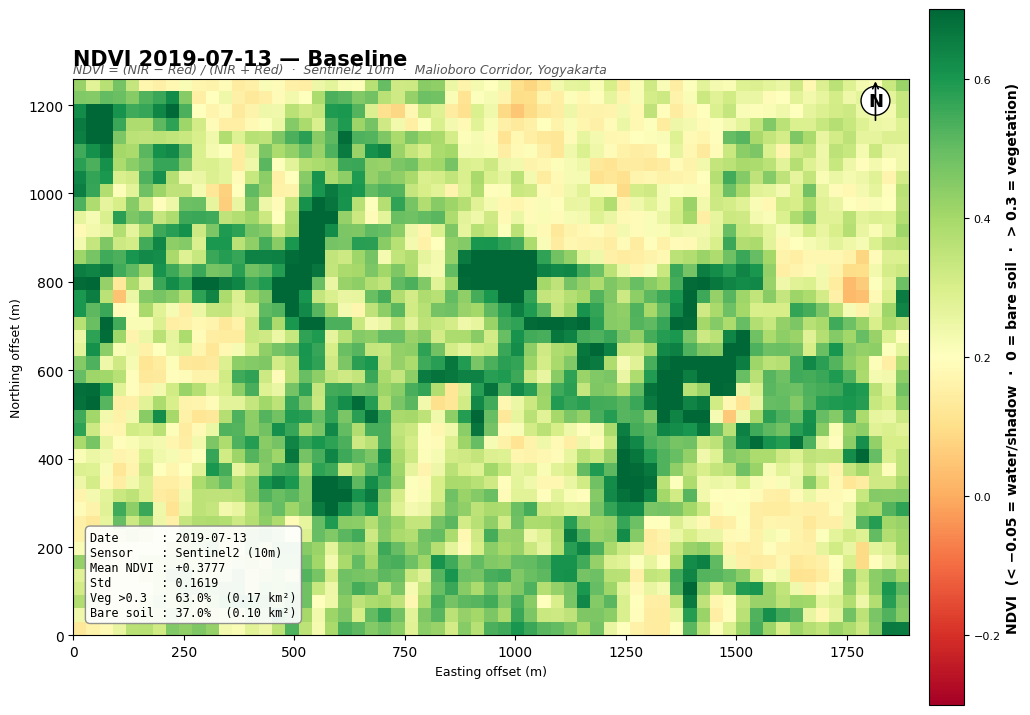

  💾 Saved: NDVI_2025-06-06_current.png


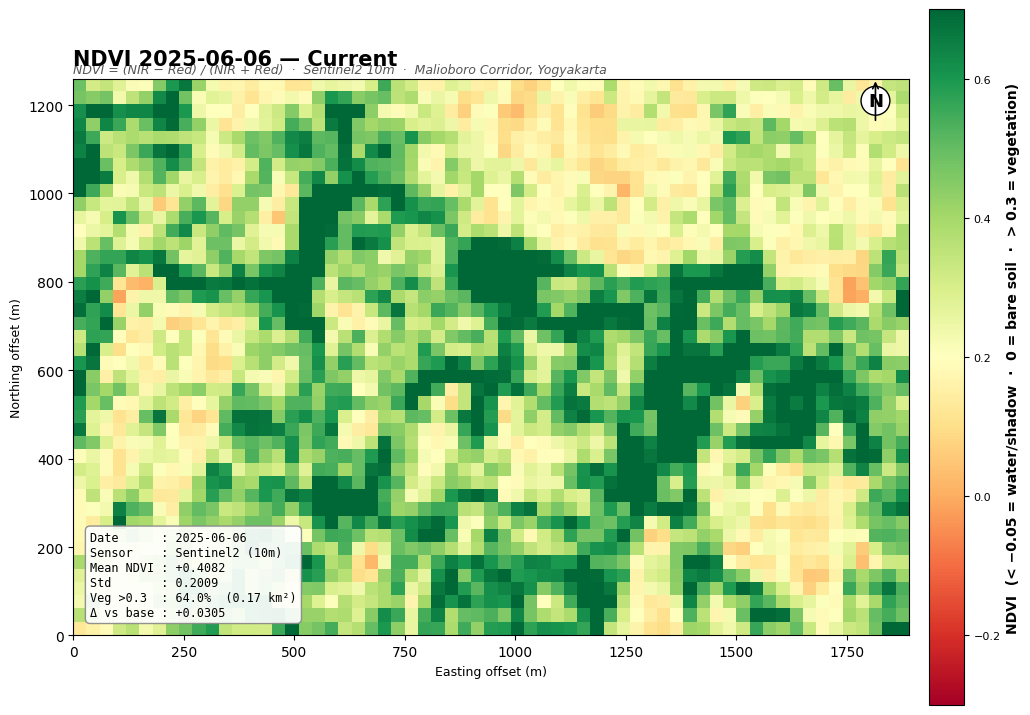

  💾 Saved: NDVI_delta_2019-07-13_2025-06-06.png


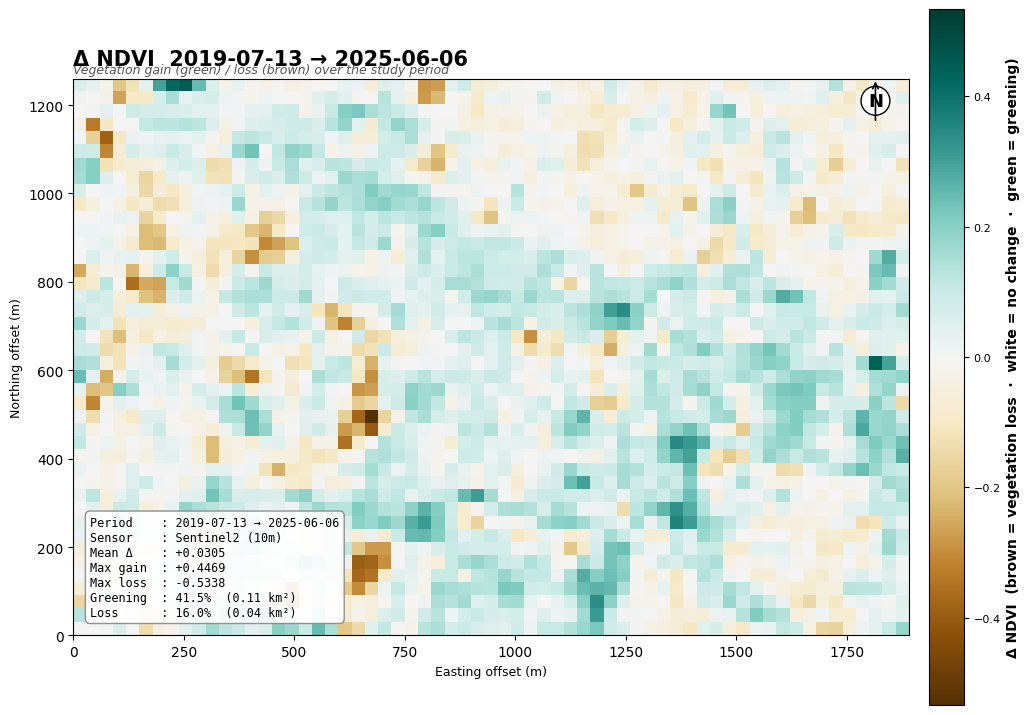


✅ NDVI analysis complete.
   ▶ Ready to proceed to Section 2.2 (FVC + LSE).


In [16]:
# 2.1. NDVI — Normalized Difference Vegetation Index
# ─────────────────────────────────────────────────────────────────
# NDVI measures vegetation health and density.
#
# Formula:
#   NDVI = (NIR − Red) / (NIR + Red)
#
# Range:
#   −1.0  → water, deep shadow
#    0.0  → bare soil, impervious surface
#   +0.3  → sparse vegetation threshold
#   +1.0  → dense healthy vegetation
#
# Resolution:
#   Landsat        : 30 m
#   Sentinel-2     : 10 m
#   Sentinel-2 only: 10 m
#
# Outputs:
#   • NDVI map — baseline year
#   • NDVI map — current year
#   • Δ NDVI change map (current − baseline)
#   • GeoTIFF + PNG saved to DIRS["raster"] / DIRS["figure"]
# ─────────────────────────────────────────────────────────────────

import numpy as np

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("clean_array", "save_geotiff", "plot_map"):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

ndvi_baseline = ndvi_current = ndvi_delta = None

if RUN_NDVI:

    # ── Input validation ──────────────────────────────────────────
    for _name, _arr in [
        ("red_baseline", globals().get("red_baseline")),
        ("nir_baseline", globals().get("nir_baseline")),
        ("red_current",  globals().get("red_current")),
        ("nir_current",  globals().get("nir_current")),
    ]:
        if _arr is None:
            raise RuntimeError(
                f"'{_name}' is None — satellite data not loaded.\n"
                "Run Section 1.6.1 or 1.6.2 before this cell."
            )

    print("🌱 [NDVI] Computing Normalized Difference Vegetation Index...")

    # ── Sensor resolution label ───────────────────────────────────
    _res_m = {"landsat": 30, "sentinel2": 10, "sentinel2_only": 10}
    _pixel_m = _res_m.get(SENSOR, 30)
    _pixel_km2 = (_pixel_m / 1000) ** 2   # Area per pixel in km²

    # ── NDVI computation ──────────────────────────────────────────
    def compute_ndvi(red, nir):
        """
        NDVI = (NIR − Red) / (NIR + Red)

        Valid range: [−1.0, +1.0]

        Notes on input clipping:
          valid_min = −0.1 allows physically valid negative reflectance
          (deep water, shadow) present in Landsat C2 L2 and
          S2_SR_HARMONIZED. Clipping to 0 would force red=0 → NDVI=+1
          over shadow/water pixels, artificially inflating vegetation %.

          valid_max = 1.0 masks fill values (e.g. −9999, 65535).

          Pixels where (NIR + Red) ≤ 0.001 are set to NaN (nodata),
          not 0.0, to avoid confusing nodata with bare soil in stats.
        """
        red = clean_array(red, valid_min=-0.1, valid_max=1.0)
        nir = clean_array(nir, valid_min=-0.1, valid_max=1.0)

        denom = nir + red
        # Use NaN for nodata pixels — distinguishable from bare soil (0.0)
        ndvi = np.where(
            denom > 0.001,
            (nir - red) / denom,
            np.nan
        )
        return np.clip(ndvi, -1.0, 1.0).astype("float32")

    ndvi_baseline = compute_ndvi(red_baseline, nir_baseline)
    ndvi_current  = compute_ndvi(red_current,  nir_current)

    # Δ NDVI = current − baseline (positive = greening, negative = loss)
    # NaN propagation: if either period is NaN, delta is NaN
    ndvi_delta = (ndvi_current - ndvi_baseline).astype("float32")

    # ── Save GeoTIFFs ─────────────────────────────────────────────
    save_geotiff(ndvi_baseline, DIRS["raster"] / "NDVI_baseline.tif")
    save_geotiff(ndvi_current,  DIRS["raster"] / "NDVI_current.tif")
    save_geotiff(ndvi_delta,    DIRS["raster"] / "NDVI_delta.tif")

    # ── Statistics (NaN-safe, pixel-area-weighted) ────────────────
    # Use np.nanmean / np.nanstd to exclude nodata pixels from stats.
    # Area statistics use pixel count × pixel area (km²).

    _date_base = globals().get("DATE_BASELINE",
                               PERIOD_BASELINE.split("/")[0])
    _date_curr = globals().get("DATE_CURRENT",
                               PERIOD_CURRENT.split("/")[0])

    def ndvi_stats(arr, label, date):
        """
        Compute NaN-safe NDVI statistics.
        Returns a dict of scalar metrics.
        """
        valid = arr[~np.isnan(arr)]
        n_valid = len(valid)
        n_total = arr.size

        mean_val  = float(np.nanmean(arr))
        std_val   = float(np.nanstd(arr))
        veg_mask  = valid > 0.3
        bare_mask = (valid >= -0.05) & (valid <= 0.3)
        water_mask= valid < -0.05

        veg_frac  = veg_mask.sum()  / n_valid if n_valid > 0 else 0.0
        bare_frac = bare_mask.sum() / n_valid if n_valid > 0 else 0.0
        water_frac= water_mask.sum()/ n_valid if n_valid > 0 else 0.0

        veg_km2   = veg_mask.sum()  * _pixel_km2
        bare_km2  = bare_mask.sum() * _pixel_km2
        water_km2 = water_mask.sum()* _pixel_km2

        print(f"\n  NDVI {label} ({_pixel_m}m resolution):")
        print(f"    Acquisition date : {date}")
        print(f"    Valid pixels     : {n_valid:,} / {n_total:,} "
              f"({n_valid/n_total*100:.1f}%)")
        print(f"    Mean NDVI        : {mean_val:+.4f}")
        print(f"    Std NDVI         : {std_val:.4f}")
        print(f"    Vegetation >0.3  : {veg_frac*100:.1f}%  "
              f"({veg_km2:.2f} km²)")
        print(f"    Bare soil        : {bare_frac*100:.1f}%  "
              f"({bare_km2:.2f} km²)")
        print(f"    Water/shadow     : {water_frac*100:.1f}%  "
              f"({water_km2:.2f} km²)")

        return {
            "mean": mean_val, "std": std_val,
            "veg_frac": veg_frac, "veg_km2": veg_km2,
            "bare_frac": bare_frac, "bare_km2": bare_km2,
            "water_frac": water_frac, "water_km2": water_km2,
        }

    stats_base = ndvi_stats(ndvi_baseline, f"Baseline ({_date_base})", _date_base)
    stats_curr = ndvi_stats(ndvi_current,  f"Current  ({_date_curr})", _date_curr)

    # Delta statistics
    _valid_delta = ndvi_delta[~np.isnan(ndvi_delta)]
    _n_delta     = len(_valid_delta)
    _gain_frac   = (_valid_delta > 0.05).sum()  / _n_delta if _n_delta > 0 else 0
    _loss_frac   = (_valid_delta < -0.05).sum() / _n_delta if _n_delta > 0 else 0
    _gain_km2    = (_valid_delta > 0.05).sum()  * _pixel_km2
    _loss_km2    = (_valid_delta < -0.05).sum() * _pixel_km2

    print(f"\n  Δ NDVI ({_date_base} → {_date_curr}):")
    print(f"    Mean Δ NDVI      : {float(np.nanmean(ndvi_delta)):+.4f}")
    print(f"    Max gain         : {float(np.nanmax(ndvi_delta)):+.4f}")
    print(f"    Max loss         : {float(np.nanmin(ndvi_delta)):+.4f}")
    print(f"    Greening (>+0.05): {_gain_frac*100:.1f}%  "
          f"({_gain_km2:.2f} km²)")
    print(f"    Loss     (<−0.05): {_loss_frac*100:.1f}%  "
          f"({_loss_km2:.2f} km²)")

    # ── Map 1: NDVI Baseline ──────────────────────────────────────
    plot_map(
        ndvi_baseline,
        title=f"NDVI {_date_base} — Baseline",
        subtitle=(
            f"NDVI = (NIR − Red) / (NIR + Red)  ·  "
            f"{SENSOR.title()} {_pixel_m}m  ·  {STUDY_NAME}"
        ),
        cmap="RdYlGn", vmin=-0.3, vmax=0.7,
        cbar_label=(
            "NDVI  "
            "(< −0.05 = water/shadow  ·  "
            "0 = bare soil  ·  "
            "> 0.3 = vegetation)"
        ),
        out_filename=f"NDVI_{_date_base}_baseline.png",
        stats_text=(
            f"Date      : {_date_base}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Mean NDVI : {stats_base['mean']:+.4f}\n"
            f"Std       : {stats_base['std']:.4f}\n"
            f"Veg >0.3  : {stats_base['veg_frac']*100:.1f}%  "
            f"({stats_base['veg_km2']:.2f} km²)\n"
            f"Bare soil : {stats_base['bare_frac']*100:.1f}%  "
            f"({stats_base['bare_km2']:.2f} km²)"
        ),
    )

    # ── Map 2: NDVI Current ───────────────────────────────────────
    plot_map(
        ndvi_current,
        title=f"NDVI {_date_curr} — Current",
        subtitle=(
            f"NDVI = (NIR − Red) / (NIR + Red)  ·  "
            f"{SENSOR.title()} {_pixel_m}m  ·  {STUDY_NAME}"
        ),
        cmap="RdYlGn", vmin=-0.3, vmax=0.7,
        cbar_label=(
            "NDVI  "
            "(< −0.05 = water/shadow  ·  "
            "0 = bare soil  ·  "
            "> 0.3 = vegetation)"
        ),
        out_filename=f"NDVI_{_date_curr}_current.png",
        stats_text=(
            f"Date      : {_date_curr}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Mean NDVI : {stats_curr['mean']:+.4f}\n"
            f"Std       : {stats_curr['std']:.4f}\n"
            f"Veg >0.3  : {stats_curr['veg_frac']*100:.1f}%  "
            f"({stats_curr['veg_km2']:.2f} km²)\n"
            f"Δ vs base : {float(np.nanmean(ndvi_delta)):+.4f}"
        ),
    )

    # ── Map 3: Δ NDVI Change ──────────────────────────────────────
    # Colormap: BrBG — brown = vegetation loss, green = greening
    # More semantically intuitive than RdBu for vegetation change.
    _finite_delta = ndvi_delta[np.isfinite(ndvi_delta)]
    _vmax_d = (
        max(abs(float(_finite_delta.min())),
            abs(float(_finite_delta.max())),
            0.1)
        if len(_finite_delta) > 0 else 0.1
    )
    plot_map(
        ndvi_delta,
        title=f"Δ NDVI  {_date_base} → {_date_curr}",
        subtitle=(
            "Vegetation gain (green) / loss (brown) over the study period"
        ),
        cmap="BrBG", vmin=-_vmax_d, vmax=_vmax_d,
        cbar_label=(
            "Δ NDVI  "
            "(brown = vegetation loss  ·  "
            "white = no change  ·  "
            "green = greening)"
        ),
        out_filename=(
            f"NDVI_delta_{_date_base}_{_date_curr}.png"
        ),
        stats_text=(
            f"Period    : {_date_base} → {_date_curr}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Mean Δ    : {float(np.nanmean(ndvi_delta)):+.4f}\n"
            f"Max gain  : {float(np.nanmax(ndvi_delta)):+.4f}\n"
            f"Max loss  : {float(np.nanmin(ndvi_delta)):+.4f}\n"
            f"Greening  : {_gain_frac*100:.1f}%  ({_gain_km2:.2f} km²)\n"
            f"Loss      : {_loss_frac*100:.1f}%  ({_loss_km2:.2f} km²)"
        ),
    )

    print("\n✅ NDVI analysis complete.")
    print(f"   ▶ Ready to proceed to Section 2.2 (FVC + LSE).")

else:
    print("ℹ️  NDVI skipped (RUN_NDVI = False).")
    print("   Note: FVC, Carbon, and Sequestration modules require NDVI.")

### 2.2. FVC & LSE - Fractional Vegetation Cover + Land Surface Emissivity

🌾 [FVC + LSE] Computing vegetation cover and emissivity for both periods...

  Using fixed physical constants:
    NDVI_soil = 0.2  (bare soil / impervious)
    NDVI_veg  = 0.5  (full canopy)
    Denominator = 0.3  (constant)
    Resolution  = 10m  (sentinel2)

  FVC baseline (2019-07-13): mean=0.433  range=[0.000, 1.000]  valid=2,646 px
  LSE baseline (2019-07-13): mean=0.9877  range=[0.9860, 0.9900]
  FVC current  (2025-06-06): mean=0.486  range=[0.000, 1.000]  valid=2,646 px
  LSE current  (2025-06-06): mean=0.9879  range=[0.9860, 0.9900]

  Δ FVC (2019-07-13 → 2025-06-06):
    Mean Δ FVC : +0.0534
    Gain >+0.05: 31.8%  (0.08 km²)
    Loss <−0.05: 15.3%  (0.04 km²)
  💾 Saved: FVC_2019-07-13_baseline.png


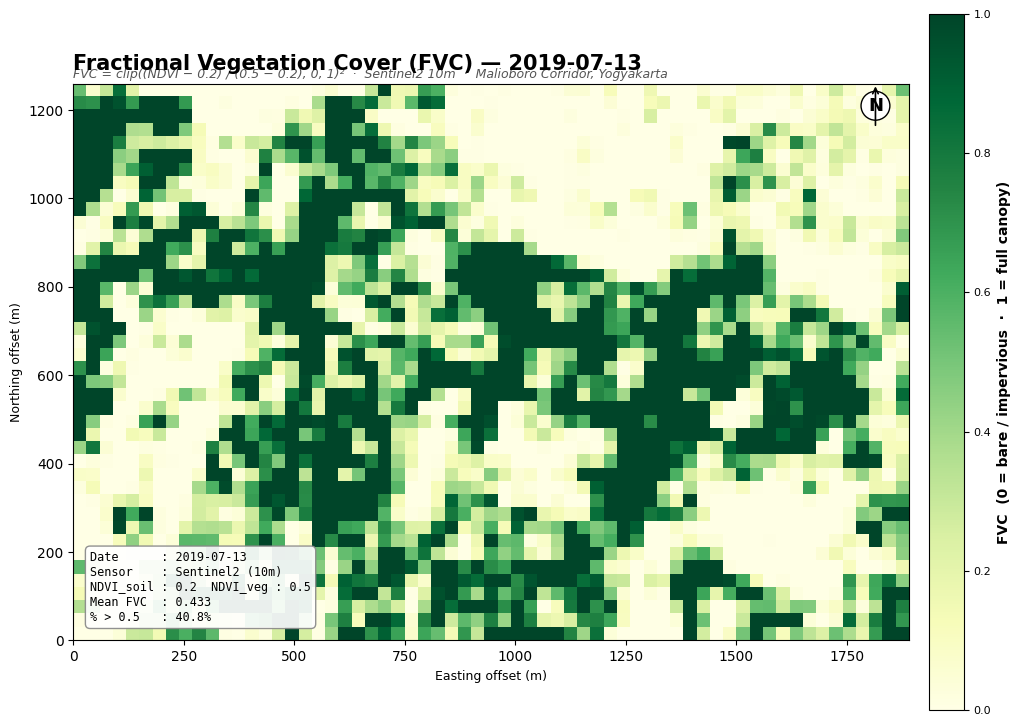

  💾 Saved: FVC_2025-06-06_current.png


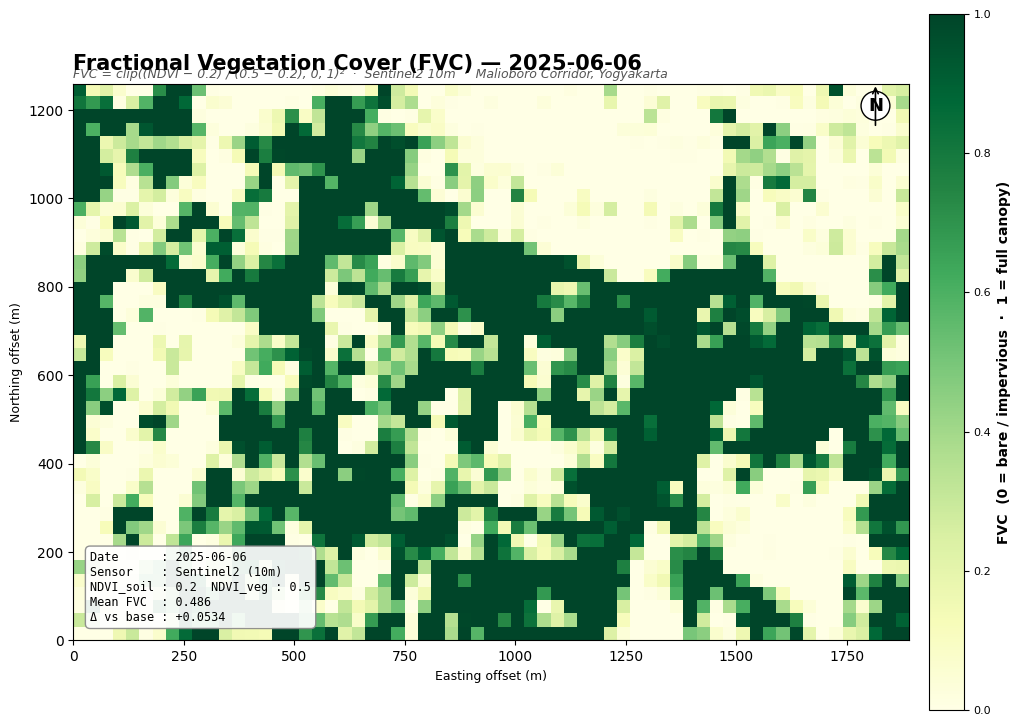

  💾 Saved: FVC_delta_2019-07-13_2025-06-06.png


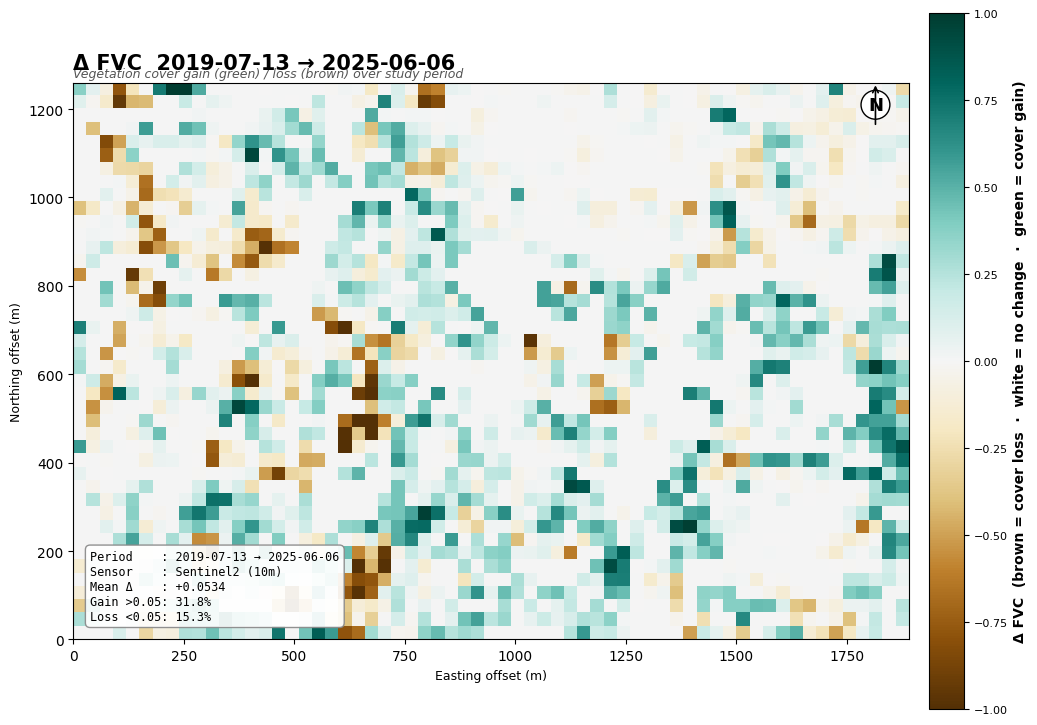

  💾 Saved: LSE_2025-06-06_current.png


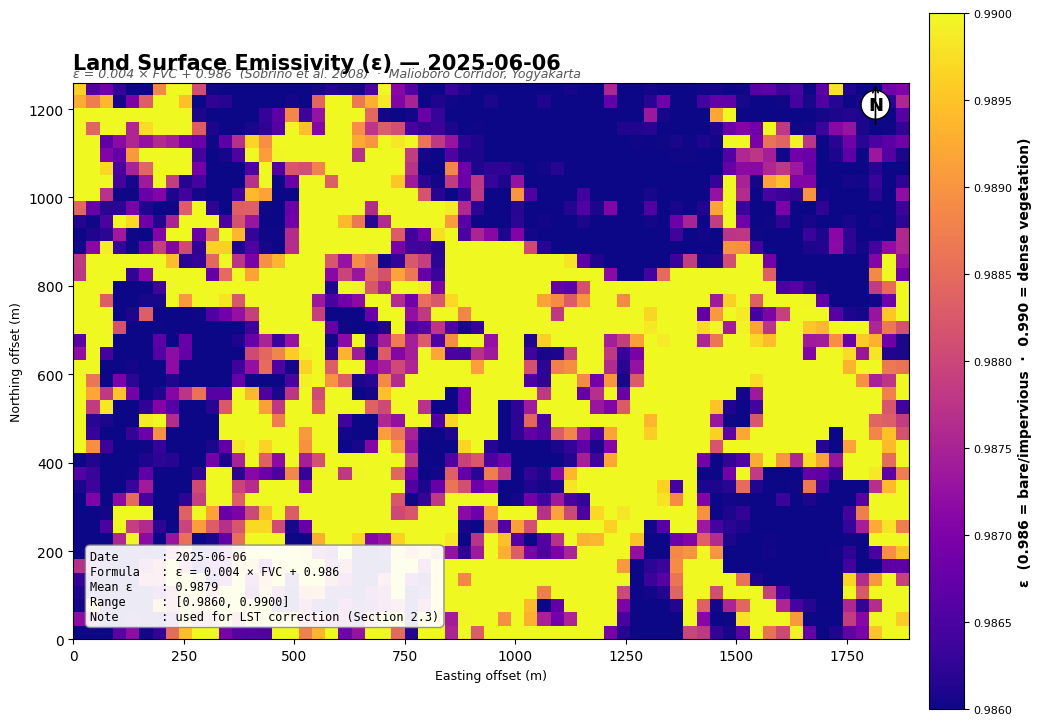


  LSE summary (used in LST correction):
    Baseline ε : mean=0.9877  range=[0.9860, 0.9900]
    Current  ε : mean=0.9879  range=[0.9860, 0.9900]
    Δ mean ε   : +0.0002

✅ FVC + LSE analysis complete (both periods).
   lse_baseline and lse_current ready for Section 2.3 (LST).
   ▶ Ready to proceed to Section 2.3.


In [17]:
# 2.2. FVC & LSE — Fractional Vegetation Cover + Land Surface Emissivity
# ─────────────────────────────────────────────────────────────────
# FVC = proportion of ground covered by vegetation (0–1).
# LSE = how efficiently a surface emits thermal radiation (0–1).
#       Required to correct satellite thermal data into true LST.
#
# Without LSE correction, brightness temperature can be off by
# ±1–3°C — making LST physically meaningless for comparison.
#
# Formulas (Sobrino et al. 2004):
#
#   FVC = clip( (NDVI − NDVI_soil) / (NDVI_veg − NDVI_soil), 0, 1 )²
#
#   where:
#     NDVI_soil = 0.2  (bare soil reference — fixed physical constant)
#     NDVI_veg  = 0.5  (full canopy reference — fixed physical constant)
#
#   LSE (ε) = 0.004 × FVC + 0.986
#
#   Physical range of ε:
#     FVC = 0 → ε = 0.986  (bare soil / impervious)
#     FVC = 1 → ε = 0.990  (dense vegetation)
#
# WHY FIXED CONSTANTS (not percentile-based):
#   Using scene percentiles as NDVI_min/NDVI_max makes FVC
#   scene-dependent and non-comparable between years. A scene with
#   little vegetation would have NDVI_max ≈ 0.35, making sparse
#   pixels appear as FVC = 1.0. Fixed physical constants ensure
#   FVC is consistent and comparable across both time periods.
#
# BOTH PERIODS:
#   FVC and LSE are computed for baseline AND current independently.
#   This is required because:
#     1. LST correction uses per-period LSE
#     2. Vegetation cover change between years changes emissivity
#     3. Using current-period LSE for baseline LST is physically wrong
#
# Resolution:
#   Landsat        : 30 m (NDVI source)
#   Sentinel-2     : 10 m (NDVI source) — higher urban detail
#   Sentinel-2 only: 10 m
# ─────────────────────────────────────────────────────────────────

import numpy as np

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("clean_array", "save_geotiff", "plot_map"):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

# Reset all per-period outputs
fvc_baseline = fvc_current = None
lse_baseline = lse_current = None
fvc_arr      = lse_arr     = None   # legacy aliases

if RUN_FVC_LSE:

    # ── Input validation ──────────────────────────────────────────
    for _name, _arr in [
        ("ndvi_baseline", globals().get("ndvi_baseline")),
        ("ndvi_current",  globals().get("ndvi_current")),
    ]:
        if _arr is None:
            raise RuntimeError(
                f"'{_name}' is None — NDVI not computed.\n"
                "Run Section 2.1 with RUN_NDVI = True before this cell."
            )

    print("🌾 [FVC + LSE] Computing vegetation cover and emissivity "
          "for both periods...")

    # ── Sensor resolution label ───────────────────────────────────
    _res_m   = {"landsat": 30, "sentinel2": 10, "sentinel2_only": 10}
    _pixel_m = _res_m.get(SENSOR, 30)
    _pixel_km2 = (_pixel_m / 1000) ** 2

    # ── Physical constants (Sobrino et al. 2004) ──────────────────
    #
    # Fixed reference values — NOT scene percentiles.
    # These represent the NDVI of:
    #   bare soil (NDVI_soil = 0.2): asphalt, concrete, dry soil
    #   full canopy (NDVI_veg = 0.5): dense healthy vegetation
    #
    # Using fixed constants ensures FVC is physically consistent
    # and directly comparable between 2019 and 2025.
    #
    NDVI_SOIL = 0.2   # Bare soil / impervious reference
    NDVI_VEG  = 0.5   # Full canopy reference

    # ── FVC computation ───────────────────────────────────────────
    def compute_fvc(ndvi_arr, label=""):
        """
        Fractional Vegetation Cover (Sobrino et al. 2004):

            FVC = clip( (NDVI − NDVI_soil) / (NDVI_veg − NDVI_soil),
                        0, 1 )²

        Parameters
        ----------
        ndvi_arr : np.ndarray  2D float32, may contain NaN
        label    : str         For progress printing

        Returns
        -------
        np.ndarray : 2D float32, range [0, 1], NaN preserved
        """
        denom = NDVI_VEG - NDVI_SOIL   # = 0.3 (constant)

        # Normalise NDVI to [0, 1] range using fixed physical refs
        fvc_linear = (ndvi_arr - NDVI_SOIL) / denom

        # Clip to [0, 1] before squaring — preserves NaN
        fvc_clipped = np.clip(fvc_linear, 0.0, 1.0)

        # Apply quadratic transformation
        # FVC = (linear_fvc)²
        fvc = fvc_clipped ** 2

        # Preserve NaN from input NDVI (nodata pixels)
        fvc = np.where(np.isnan(ndvi_arr), np.nan, fvc)

        if label:
            _valid = fvc[~np.isnan(fvc)]
            print(f"  FVC {label}: "
                  f"mean={np.nanmean(fvc):.3f}  "
                  f"range=[{np.nanmin(fvc):.3f}, "
                  f"{np.nanmax(fvc):.3f}]  "
                  f"valid={len(_valid):,} px")

        return fvc.astype("float32")

    # ── LSE computation ───────────────────────────────────────────
    def compute_lse(fvc_arr_in, label=""):
        """
        Land Surface Emissivity (Sobrino et al. 2008):

            ε = 0.004 × FVC + 0.986

        Physical range:
            FVC = 0 → ε = 0.986  (bare soil / impervious)
            FVC = 1 → ε = 0.990  (dense vegetation)

        NaN from FVC is preserved.

        Parameters
        ----------
        fvc_arr_in : np.ndarray  2D float32, range [0, 1]

        Returns
        -------
        np.ndarray : 2D float32, range [0.986, 0.990]
        """
        lse = 0.004 * fvc_arr_in + 0.986

        # Preserve NaN
        lse = np.where(np.isnan(fvc_arr_in), np.nan, lse)

        if label:
            print(f"  LSE {label}: "
                  f"mean={np.nanmean(lse):.4f}  "
                  f"range=[{np.nanmin(lse):.4f}, "
                  f"{np.nanmax(lse):.4f}]")

        return lse.astype("float32")

    # ── Compute for both periods ──────────────────────────────────
    _date_base = globals().get("DATE_BASELINE",
                               PERIOD_BASELINE.split("/")[0])
    _date_curr = globals().get("DATE_CURRENT",
                               PERIOD_CURRENT.split("/")[0])

    print(f"\n  Using fixed physical constants:")
    print(f"    NDVI_soil = {NDVI_SOIL}  (bare soil / impervious)")
    print(f"    NDVI_veg  = {NDVI_VEG}  (full canopy)")
    print(f"    Denominator = {NDVI_VEG - NDVI_SOIL:.1f}  (constant)")
    print(f"    Resolution  = {_pixel_m}m  ({SENSOR})\n")

    fvc_baseline = compute_fvc(ndvi_baseline,
                               label=f"baseline ({_date_base})")
    lse_baseline = compute_lse(fvc_baseline,
                               label=f"baseline ({_date_base})")

    fvc_current  = compute_fvc(ndvi_current,
                               label=f"current  ({_date_curr})")
    lse_current  = compute_lse(fvc_current,
                               label=f"current  ({_date_curr})")

    # Legacy aliases for downstream compatibility
    fvc_arr = fvc_current
    lse_arr = lse_current

    # ── FVC change ────────────────────────────────────────────────
    fvc_delta = (fvc_current - fvc_baseline).astype("float32")
    _valid_fd = fvc_delta[~np.isnan(fvc_delta)]
    _gain_frac = (_valid_fd >  0.05).sum() / len(_valid_fd) if len(_valid_fd) > 0 else 0
    _loss_frac = (_valid_fd < -0.05).sum() / len(_valid_fd) if len(_valid_fd) > 0 else 0

    print(f"\n  Δ FVC ({_date_base} → {_date_curr}):")
    print(f"    Mean Δ FVC : {float(np.nanmean(fvc_delta)):+.4f}")
    print(f"    Gain >+0.05: {_gain_frac*100:.1f}%  "
          f"({(_valid_fd > 0.05).sum() * _pixel_km2:.2f} km²)")
    print(f"    Loss <−0.05: {_loss_frac*100:.1f}%  "
          f"({(_valid_fd < -0.05).sum() * _pixel_km2:.2f} km²)")

    # ── Save GeoTIFFs ─────────────────────────────────────────────
    save_geotiff(fvc_baseline, DIRS["raster"] / "FVC_baseline.tif")
    save_geotiff(fvc_current,  DIRS["raster"] / "FVC_current.tif")
    save_geotiff(lse_baseline, DIRS["raster"] / "LSE_baseline.tif")
    save_geotiff(lse_current,  DIRS["raster"] / "LSE_current.tif")
    save_geotiff(fvc_delta,    DIRS["raster"] / "FVC_delta.tif")

    # ── Map 1: FVC Baseline ───────────────────────────────────────
    plot_map(
        fvc_baseline,
        title=f"Fractional Vegetation Cover (FVC) — {_date_base}",
        subtitle=(
            f"FVC = clip((NDVI − {NDVI_SOIL}) / "
            f"({NDVI_VEG} − {NDVI_SOIL}), 0, 1)²  ·  "
            f"{SENSOR.title()} {_pixel_m}m  ·  {STUDY_NAME}"
        ),
        cmap="YlGn", vmin=0, vmax=1,
        cbar_label="FVC  (0 = bare / impervious  ·  1 = full canopy)",
        out_filename=f"FVC_{_date_base}_baseline.png",
        stats_text=(
            f"Date      : {_date_base}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"NDVI_soil : {NDVI_SOIL}  NDVI_veg : {NDVI_VEG}\n"
            f"Mean FVC  : {float(np.nanmean(fvc_baseline)):.3f}\n"
            f"% > 0.5   : "
            f"{(fvc_baseline[~np.isnan(fvc_baseline)] > 0.5).mean()*100:.1f}%"
        ),
    )

    # ── Map 2: FVC Current ────────────────────────────────────────
    plot_map(
        fvc_current,
        title=f"Fractional Vegetation Cover (FVC) — {_date_curr}",
        subtitle=(
            f"FVC = clip((NDVI − {NDVI_SOIL}) / "
            f"({NDVI_VEG} − {NDVI_SOIL}), 0, 1)²  ·  "
            f"{SENSOR.title()} {_pixel_m}m  ·  {STUDY_NAME}"
        ),
        cmap="YlGn", vmin=0, vmax=1,
        cbar_label="FVC  (0 = bare / impervious  ·  1 = full canopy)",
        out_filename=f"FVC_{_date_curr}_current.png",
        stats_text=(
            f"Date      : {_date_curr}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"NDVI_soil : {NDVI_SOIL}  NDVI_veg : {NDVI_VEG}\n"
            f"Mean FVC  : {float(np.nanmean(fvc_current)):.3f}\n"
            f"Δ vs base : {float(np.nanmean(fvc_delta)):+.4f}"
        ),
    )

    # ── Map 3: Δ FVC Change ───────────────────────────────────────
    _finite_fd = fvc_delta[np.isfinite(fvc_delta)]
    _vmax_fd = (
        max(abs(float(_finite_fd.min())),
            abs(float(_finite_fd.max())),
            0.05)
        if len(_finite_fd) > 0 else 0.05
    )
    plot_map(
        fvc_delta,
        title=f"Δ FVC  {_date_base} → {_date_curr}",
        subtitle="Vegetation cover gain (green) / loss (brown) over study period",
        cmap="BrBG", vmin=-_vmax_fd, vmax=_vmax_fd,
        cbar_label=(
            "Δ FVC  "
            "(brown = cover loss  ·  white = no change  ·  "
            "green = cover gain)"
        ),
        out_filename=f"FVC_delta_{_date_base}_{_date_curr}.png",
        stats_text=(
            f"Period    : {_date_base} → {_date_curr}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Mean Δ    : {float(np.nanmean(fvc_delta)):+.4f}\n"
            f"Gain >0.05: {_gain_frac*100:.1f}%\n"
            f"Loss <0.05: {_loss_frac*100:.1f}%"
        ),
    )

    # ── Map 4: LSE Current ────────────────────────────────────────
    # LSE map shown for current period (used in LST correction)
    plot_map(
        lse_current,
        title=f"Land Surface Emissivity (ε) — {_date_curr}",
        subtitle=(
            f"ε = 0.004 × FVC + 0.986  (Sobrino et al. 2008)  ·  "
            f"{STUDY_NAME}"
        ),
        cmap="plasma", vmin=0.986, vmax=0.990,
        cbar_label=(
            "ε  (0.986 = bare/impervious  ·  0.990 = dense vegetation)"
        ),
        out_filename=f"LSE_{_date_curr}_current.png",
        stats_text=(
            f"Date      : {_date_curr}\n"
            f"Formula   : ε = 0.004 × FVC + 0.986\n"
            f"Mean ε    : {float(np.nanmean(lse_current)):.4f}\n"
            f"Range     : [{float(np.nanmin(lse_current)):.4f}, "
            f"{float(np.nanmax(lse_current)):.4f}]\n"
            f"Note      : used for LST correction (Section 2.3)"
        ),
    )

    # ── LSE summary ───────────────────────────────────────────────
    print(f"\n  LSE summary (used in LST correction):")
    print(f"    Baseline ε : mean={float(np.nanmean(lse_baseline)):.4f}  "
          f"range=[{float(np.nanmin(lse_baseline)):.4f}, "
          f"{float(np.nanmax(lse_baseline)):.4f}]")
    print(f"    Current  ε : mean={float(np.nanmean(lse_current)):.4f}  "
          f"range=[{float(np.nanmin(lse_current)):.4f}, "
          f"{float(np.nanmax(lse_current)):.4f}]")
    print(f"    Δ mean ε   : "
          f"{float(np.nanmean(lse_current) - np.nanmean(lse_baseline)):+.4f}")

    print("\n✅ FVC + LSE analysis complete (both periods).")
    print(f"   lse_baseline and lse_current ready for Section 2.3 (LST).")
    print(f"   ▶ Ready to proceed to Section 2.3.")

else:
    print("ℹ️  FVC + LSE skipped (RUN_FVC_LSE = False).")
    print("   Note: LST correction requires LSE — "
          "LST results will be uncorrected if this is skipped.")

### 2.3. LST - Land Surface Temperature

🌡️  [LST] Computing Land Surface Temperature (Single-Channel Algorithm)...
  ℹ️  Hybrid mode: Sentinel-2 NDVI/FVC + Landsat thermal
     Thermal baseline : 2019-06-25
     Thermal current  : 2025-07-19

  Computing LST with per-period emissivity...
  LST baseline (2019-06-25): mean=37.99°C  range=[31.1, 41.8]°C  valid=2,646 px
  LST current  (2025-07-19): mean=39.42°C  range=[33.8, 43.6]°C  valid=2,646 px

  Δ LST summary (2019-06-25 → 2025-07-19):
    Mean Δ LST       : +1.44°C
    Max warming      : +5.45°C
    Max cooling      : -1.36°C
    Warming (>+0.5°C): 93.3%  (2.22 km²)
    Cooling (<−0.5°C): 0.9%  (0.02 km²)
  💾 Saved: LST_2019-06-25_baseline.png


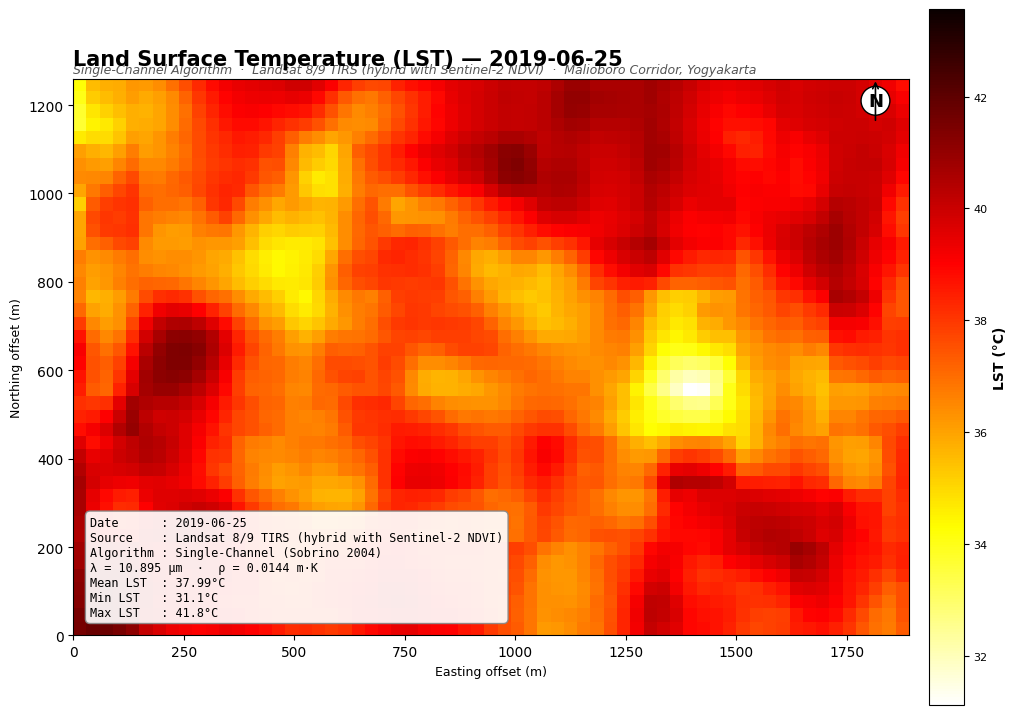

  💾 Saved: LST_2025-07-19_current.png


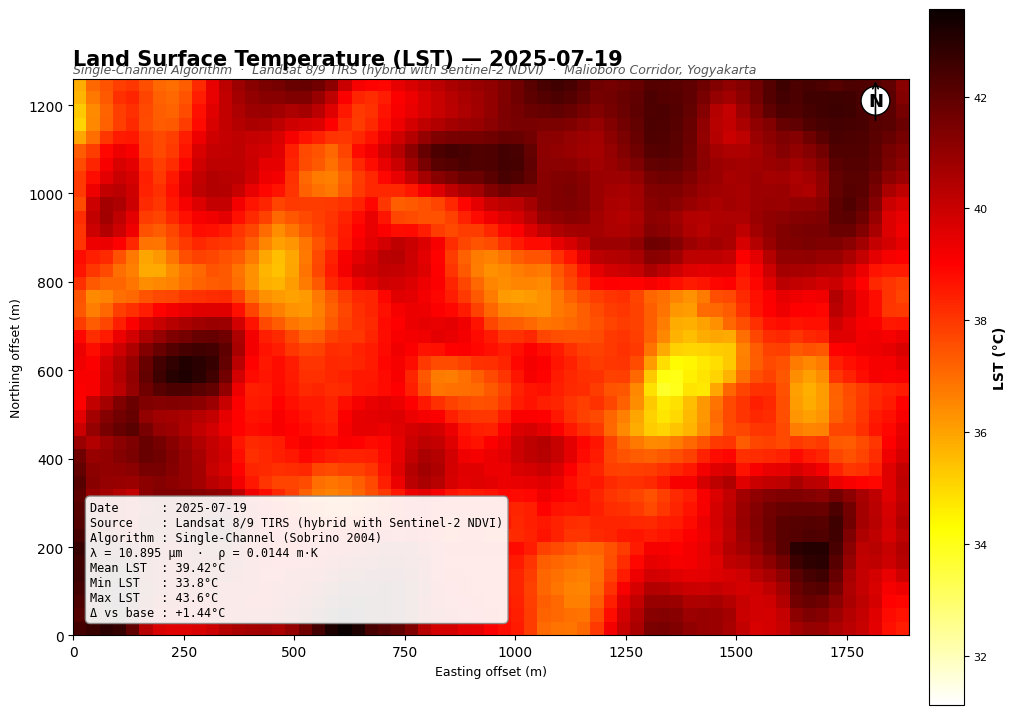

  💾 Saved: LST_delta_2019-06-25_2025-07-19.png


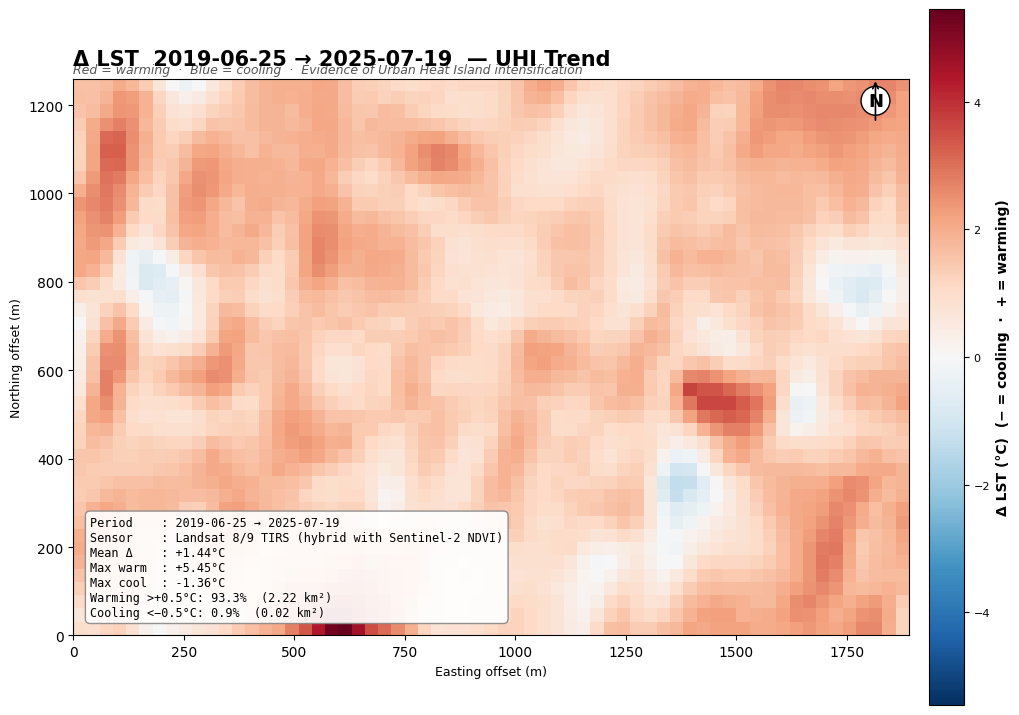


✅ LST analysis complete.
   ▶ Ready to proceed to Section 2.4 (UTFVI / UHI).


In [18]:
# 2.3. LST — Land Surface Temperature
# ─────────────────────────────────────────────────────────────────
# Converts satellite thermal brightness temperature into true Land
# Surface Temperature (LST) in degrees Celsius.
#
# Brightness temperature (what the satellite measures) ≠ surface
# temperature. The LSE correction accounts for how different
# surfaces emit heat differently (emissivity effect).
#
# Algorithm: Single-Channel (Sobrino et al. 2004)
#
#   LST [K] = T_B / (1 + (λ · T_B / ρ) · ln(ε))
#
#   LST [°C] = LST [K] − 273.15
#
#   where:
#     T_B : brightness temperature [K]  (from Landsat ST_B10)
#     λ   : 10.895 × 10⁻⁶ m  (Landsat 8/9 Band 10 effective wavelength)
#     ρ   : h·c / k_B = 1.4388 × 10⁻² m·K
#             h  = Planck constant   (6.626 × 10⁻³⁴ J·s)
#             c  = speed of light    (2.998 × 10⁸ m/s)
#             k_B= Boltzmann constant(1.381 × 10⁻²³ J/K)
#     ε   : Land Surface Emissivity (from Section 2.2, per period)
#
# IMPORTANT — per-period LSE:
#   Baseline LST uses lse_baseline (from baseline NDVI/FVC).
#   Current  LST uses lse_current  (from current  NDVI/FVC).
#   Using current-period ε for baseline correction is physically
#   wrong — it biases baseline LST if vegetation cover changed.
#
# Sensor modes:
#   "landsat"        → thermal from primary Landsat scenes
#   "sentinel2"      → thermal from separate Landsat scenes
#                      (fetched in Section 1.6.1/1.6.2)
#   "sentinel2_only" → no thermal; LST disabled
# ─────────────────────────────────────────────────────────────────

import numpy as np

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("clean_array", "save_geotiff", "plot_map"):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

lst_baseline = lst_current = lst_delta = None

if RUN_LST:

    # ── Sensor mode check ─────────────────────────────────────────
    # LST requires thermal bands. In sentinel2 mode, thermal comes
    # from separate Landsat scenes (fetched in Section 1.6.x).
    # In sentinel2_only mode, no thermal is available.
    if SENSOR == "sentinel2_only":
        print("⚠️  LST is not available for SENSOR = 'sentinel2_only'.")
        print("   Switch to SENSOR = 'sentinel2' to enable hybrid mode,")
        print("   or SENSOR = 'landsat' for full Landsat-only analysis.")

    elif (globals().get("thermal_baseline_K") is None or
          globals().get("thermal_current_K")  is None):
        print("❌ Thermal bands not loaded (thermal_baseline_K / "
              "thermal_current_K are None).")
        print("   • For SENSOR = 'landsat': check Section 1.6.1/1.6.2.")
        print("   • For SENSOR = 'sentinel2': set "
              "FETCH_LANDSAT_FOR_LST = True in Section 1.2.1.")

    elif (globals().get("lse_baseline") is None or
          globals().get("lse_current")  is None):
        print("❌ Per-period LSE not computed.")
        print("   Run Section 2.2 with RUN_FVC_LSE = True.")
        print("   Note: lse_baseline AND lse_current are both required.")

    else:
        print("🌡️  [LST] Computing Land Surface Temperature "
              "(Single-Channel Algorithm)...")

        # ── Sensor label for maps ─────────────────────────────────
        _thermal_source = (
            "Landsat 8/9 TIRS" if SENSOR == "landsat"
            else "Landsat 8/9 TIRS (hybrid with Sentinel-2 NDVI)"
        )
        _res_m = 30   # Landsat thermal is always 30 m

        # ── Physical constants ────────────────────────────────────
        #
        # λ (LAMBDA_M): Effective wavelength of Landsat 8/9 Band 10
        #   Spectral range: 10.60 – 11.19 µm
        #   Effective wavelength: 10.895 µm = 10.895 × 10⁻⁶ m
        #   Source: USGS Landsat 8/9 OLI/TIRS Calibration Notices
        #
        # ρ (RHO): Second radiation constant = h·c / k_B
        #   h  = 6.62607 × 10⁻³⁴ J·s   (Planck constant)
        #   c  = 2.99792 × 10⁸  m/s    (speed of light)
        #   k_B= 1.38065 × 10⁻²³ J/K   (Boltzmann constant)
        #   ρ  = h·c/k_B = 1.4388 × 10⁻² m·K
        #
        #   Dimensional check for λ·T_B/ρ:
        #   [m × K] / [m·K] = dimensionless ✓
        #
        LAMBDA_M = 10.895e-6    # Effective wavelength [m]
        RHO      = 1.4388e-2    # h·c/k_B [m·K]

        # ── Single-Channel Algorithm ──────────────────────────────
        def single_channel_lst(tb_kelvin, lse, label=""):
            """
            Single-Channel Algorithm (Sobrino et al. 2004):

                LST [K] = T_B / (1 + (λ · T_B / ρ) · ln(ε))
                LST [°C] = LST [K] − 273.15

            The correction term (λ·T_B/ρ)·ln(ε) is always negative
            because ln(ε) < 0 for ε ∈ (0,1), so LST > T_B always.
            Physically: surfaces emit less than a perfect blackbody,
            so the true temperature must be higher than T_B.

            Parameters
            ----------
            tb_kelvin : np.ndarray  Brightness temperature [K]
            lse       : np.ndarray  Land Surface Emissivity [0.986–0.990]
                        Must be from the SAME time period as tb_kelvin.
            label     : str

            Returns
            -------
            np.ndarray : LST in degrees Celsius, float32
            """
            # Clean brightness temperature
            # Valid range: 200–400 K covers −73°C to +127°C — global
            tb  = clean_array(tb_kelvin, valid_min=200, valid_max=400)

            # Clip emissivity to physically valid range
            # ε must be > 0 for ln(ε) to be defined
            # ε > 1 is physically impossible
            eps = np.clip(lse, 0.9, 1.0)

            # Correction term (dimensionless, always negative)
            # correction = (λ · T_B / ρ) · ln(ε)
            correction = (LAMBDA_M * tb / RHO) * np.log(eps)

            # LST in Kelvin
            # Denominator = 1 + correction
            # Since correction < 0: denominator < 1 → LST > T_B ✓
            lst_k = tb / (1.0 + correction)

            # Convert to Celsius
            lst_c = lst_k - 273.15

            # Valid range: −20°C to 80°C
            # Covers polar winter surfaces and desert summer extremes.
            # Do NOT clip to [0, 70] — this truncates real data in
            # cold cities (winter) and hot cities (summer).
            lst_c = clean_array(lst_c, valid_min=-20, valid_max=80)

            if label:
                _valid = lst_c[~np.isnan(lst_c)]
                if len(_valid) > 0:
                    print(f"  LST {label}: "
                          f"mean={np.nanmean(lst_c):.2f}°C  "
                          f"range=[{np.nanmin(lst_c):.1f}, "
                          f"{np.nanmax(lst_c):.1f}]°C  "
                          f"valid={len(_valid):,} px")

            return lst_c.astype("float32")

        # ── Date labels ───────────────────────────────────────────
        _date_base = globals().get(
            "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
        )
        _date_curr = globals().get(
            "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
        )

        # For sentinel2 hybrid mode, thermal dates differ from
        # optical dates — use Landsat acquisition dates for LST
        if SENSOR == "sentinel2":
            _th_date_base = globals().get("DATE_LS_BASELINE", _date_base)
            _th_date_curr = globals().get("DATE_LS_CURRENT",  _date_curr)
            print(f"  ℹ️  Hybrid mode: Sentinel-2 NDVI/FVC + "
                  f"Landsat thermal")
            print(f"     Thermal baseline : {_th_date_base}")
            print(f"     Thermal current  : {_th_date_curr}")
        else:
            _th_date_base = _date_base
            _th_date_curr = _date_curr

        # ── Compute LST — per-period LSE ──────────────────────────
        #
        # CRITICAL: each period uses its OWN emissivity.
        # lse_baseline → derived from ndvi_baseline → fvc_baseline
        # lse_current  → derived from ndvi_current  → fvc_current
        #
        print(f"\n  Computing LST with per-period emissivity...")
        lst_baseline = single_channel_lst(
            thermal_baseline_K, lse_baseline,
            label=f"baseline ({_th_date_base})"
        )
        lst_current = single_channel_lst(
            thermal_current_K, lse_current,
            label=f"current  ({_th_date_curr})"
        )

        # Δ LST = current − baseline
        # Positive = warming, Negative = cooling
        lst_delta = (lst_current - lst_baseline).astype("float32")

        # ── Save GeoTIFFs ─────────────────────────────────────────
        save_geotiff(lst_baseline, DIRS["raster"] / "LST_baseline.tif")
        save_geotiff(lst_current,  DIRS["raster"] / "LST_current.tif")
        save_geotiff(lst_delta,    DIRS["raster"] / "LST_delta.tif")

        # ── NaN-safe colormap range (shared across both periods) ──
        _finite_lst = np.concatenate([
            lst_baseline[np.isfinite(lst_baseline)],
            lst_current[np.isfinite(lst_current)]
        ])
        if len(_finite_lst) == 0:
            raise RuntimeError(
                "LST arrays contain no valid pixels. "
                "Check thermal band loading and emissivity inputs."
            )
        vmin_lst = float(_finite_lst.min())
        vmax_lst = float(_finite_lst.max())

        # ── UHI change statistics ─────────────────────────────────
        _valid_d  = lst_delta[~np.isnan(lst_delta)]
        _n_d      = len(_valid_d)
        _warm_frac = (_valid_d >  0.5).sum() / _n_d if _n_d > 0 else 0
        _cool_frac = (_valid_d < -0.5).sum() / _n_d if _n_d > 0 else 0
        _pixel_km2 = (30 / 1000) ** 2   # Landsat thermal = 30 m always

        print(f"\n  Δ LST summary ({_th_date_base} → {_th_date_curr}):")
        print(f"    Mean Δ LST       : "
              f"{float(np.nanmean(lst_delta)):+.2f}°C")
        print(f"    Max warming      : "
              f"{float(np.nanmax(lst_delta)):+.2f}°C")
        print(f"    Max cooling      : "
              f"{float(np.nanmin(lst_delta)):+.2f}°C")
        print(f"    Warming (>+0.5°C): {_warm_frac*100:.1f}%  "
              f"({(_valid_d > 0.5).sum() * _pixel_km2:.2f} km²)")
        print(f"    Cooling (<−0.5°C): {_cool_frac*100:.1f}%  "
              f"({(_valid_d < -0.5).sum() * _pixel_km2:.2f} km²)")

        # ── Map 1: LST Baseline ───────────────────────────────────
        plot_map(
            lst_baseline,
            title=f"Land Surface Temperature (LST) — {_th_date_base}",
            subtitle=(
                f"Single-Channel Algorithm  ·  "
                f"{_thermal_source}  ·  {STUDY_NAME}"
            ),
            cmap="hot_r", vmin=vmin_lst, vmax=vmax_lst,
            cbar_label="LST (°C)",
            out_filename=f"LST_{_th_date_base}_baseline.png",
            stats_text=(
                f"Date      : {_th_date_base}\n"
                f"Source    : {_thermal_source}\n"
                f"Algorithm : Single-Channel (Sobrino 2004)\n"
                f"λ = {LAMBDA_M*1e6:.3f} µm  ·  "
                f"ρ = {RHO:.4f} m·K\n"
                f"Mean LST  : {float(np.nanmean(lst_baseline)):.2f}°C\n"
                f"Min LST   : {float(np.nanmin(lst_baseline)):.1f}°C\n"
                f"Max LST   : {float(np.nanmax(lst_baseline)):.1f}°C"
            ),
        )

        # ── Map 2: LST Current ────────────────────────────────────
        plot_map(
            lst_current,
            title=f"Land Surface Temperature (LST) — {_th_date_curr}",
            subtitle=(
                f"Single-Channel Algorithm  ·  "
                f"{_thermal_source}  ·  {STUDY_NAME}"
            ),
            cmap="hot_r", vmin=vmin_lst, vmax=vmax_lst,
            cbar_label="LST (°C)",
            out_filename=f"LST_{_th_date_curr}_current.png",
            stats_text=(
                f"Date      : {_th_date_curr}\n"
                f"Source    : {_thermal_source}\n"
                f"Algorithm : Single-Channel (Sobrino 2004)\n"
                f"λ = {LAMBDA_M*1e6:.3f} µm  ·  "
                f"ρ = {RHO:.4f} m·K\n"
                f"Mean LST  : {float(np.nanmean(lst_current)):.2f}°C\n"
                f"Min LST   : {float(np.nanmin(lst_current)):.1f}°C\n"
                f"Max LST   : {float(np.nanmax(lst_current)):.1f}°C\n"
                f"Δ vs base : {float(np.nanmean(lst_delta)):+.2f}°C"
            ),
        )

        # ── Map 3: Δ LST Change (UHI Trend) ──────────────────────
        _finite_ld = lst_delta[np.isfinite(lst_delta)]
        _vlim = (
            max(abs(float(_finite_ld.min())),
                abs(float(_finite_ld.max())),
                1.0)
            if len(_finite_ld) > 0 else 1.0
        )
        plot_map(
            lst_delta,
            title=(
                f"Δ LST  {_th_date_base} → {_th_date_curr}  "
                f"— UHI Trend"
            ),
            subtitle=(
                "Red = warming  ·  Blue = cooling  ·  "
                "Evidence of Urban Heat Island intensification"
            ),
            cmap="RdBu_r", vmin=-_vlim, vmax=_vlim,
            cbar_label="Δ LST (°C)  (− = cooling  ·  + = warming)",
            out_filename=(
                f"LST_delta_{_th_date_base}_{_th_date_curr}.png"
            ),
            stats_text=(
                f"Period    : {_th_date_base} → {_th_date_curr}\n"
                f"Sensor    : {_thermal_source}\n"
                f"Mean Δ    : {float(np.nanmean(lst_delta)):+.2f}°C\n"
                f"Max warm  : {float(np.nanmax(lst_delta)):+.2f}°C\n"
                f"Max cool  : {float(np.nanmin(lst_delta)):+.2f}°C\n"
                f"Warming >+0.5°C: {_warm_frac*100:.1f}%  "
                f"({(_valid_d > 0.5).sum() * _pixel_km2:.2f} km²)\n"
                f"Cooling <−0.5°C: {_cool_frac*100:.1f}%  "
                f"({(_valid_d < -0.5).sum() * _pixel_km2:.2f} km²)"
            ),
        )

        print("\n✅ LST analysis complete.")
        print(f"   ▶ Ready to proceed to Section 2.4 (UTFVI / UHI).")

else:
    print("ℹ️  LST skipped (RUN_LST = False).")
    print("   Note: UTFVI and UHI analysis require LST.")

### 2.4. UTVFI - Urban Thermal Field Variance Index

🔥 [UTFVI] Computing Urban Thermal Field Variance Index for both periods...
  UTFVI baseline (2019-06-25):
    T̄ (scene mean) : 37.99°C (311.14 K)
    Mean UTFVI     : +0.00000
    Range          : [-0.02206, +0.01216]
    Valid pixels   : 2,646
  UTFVI current  (2025-07-19):
    T̄ (scene mean) : 39.42°C (312.57 K)
    Mean UTFVI     : +0.00000
    Range          : [-0.01807, +0.01325]
    Valid pixels   : 2,646

  Class distribution (2019-06-25 → 2025-07-19):
  Class          Baseline    Current     Δ (pp)    Curr km²
  --------------------------------------------------------
  0 Excellent       49.9%      50.9%      +1.0pp       1.21
  1 Good            29.2%      27.2%      -1.9pp       0.65
  2 Normal          19.4%      19.8%      +0.4pp       0.47
  3 Bad              1.5%       2.0%      +0.5pp       0.05
  4 Worse            0.0%       0.0%      +0.0pp       0.00
  5 Worst            0.0%       0.0%      +0.0pp       0.00
  💾 Saved: UTFVI_2019-06-25_baseline.png


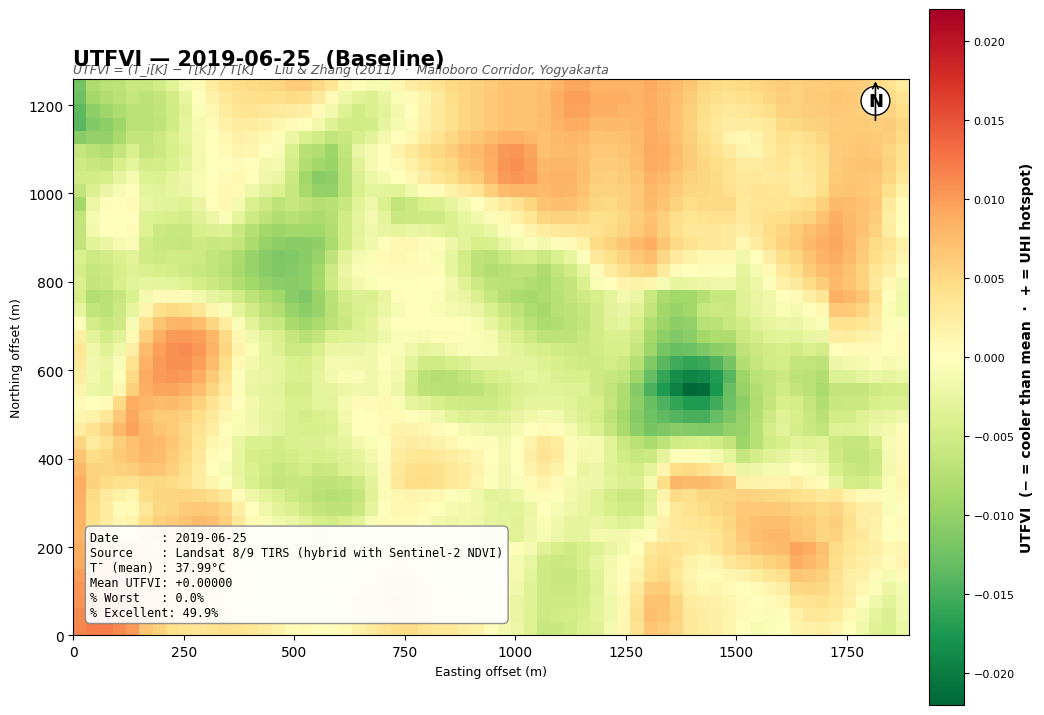

  💾 Saved: UTFVI_2025-07-19_current.png


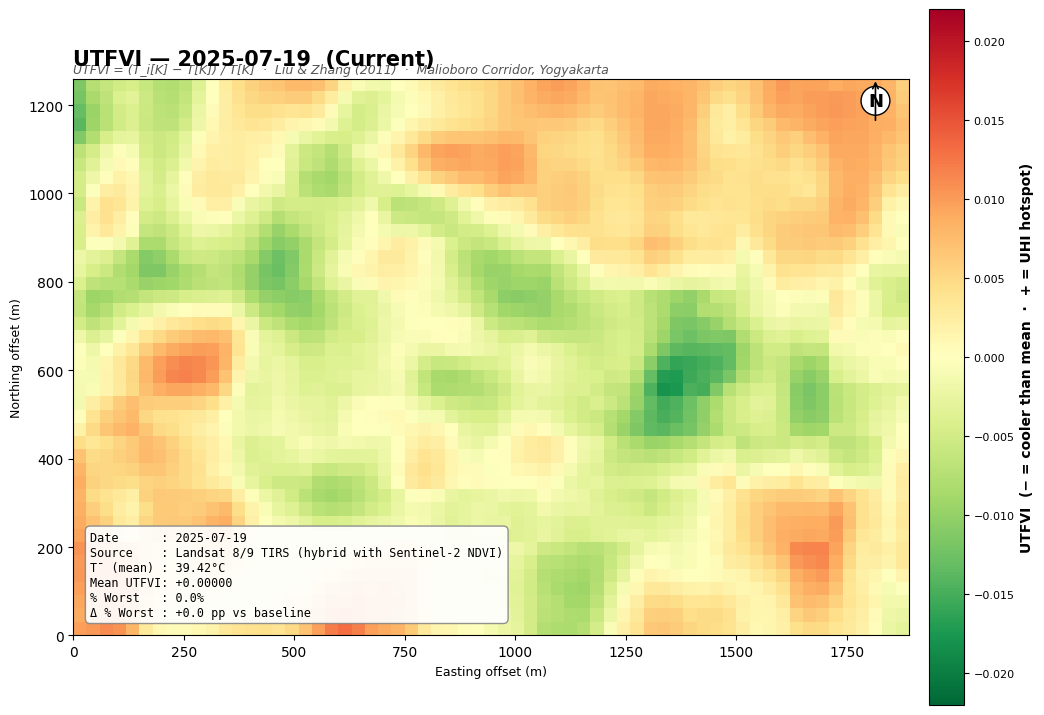

  💾 Saved: UTFVI_delta_2019-06-25_2025-07-19.png


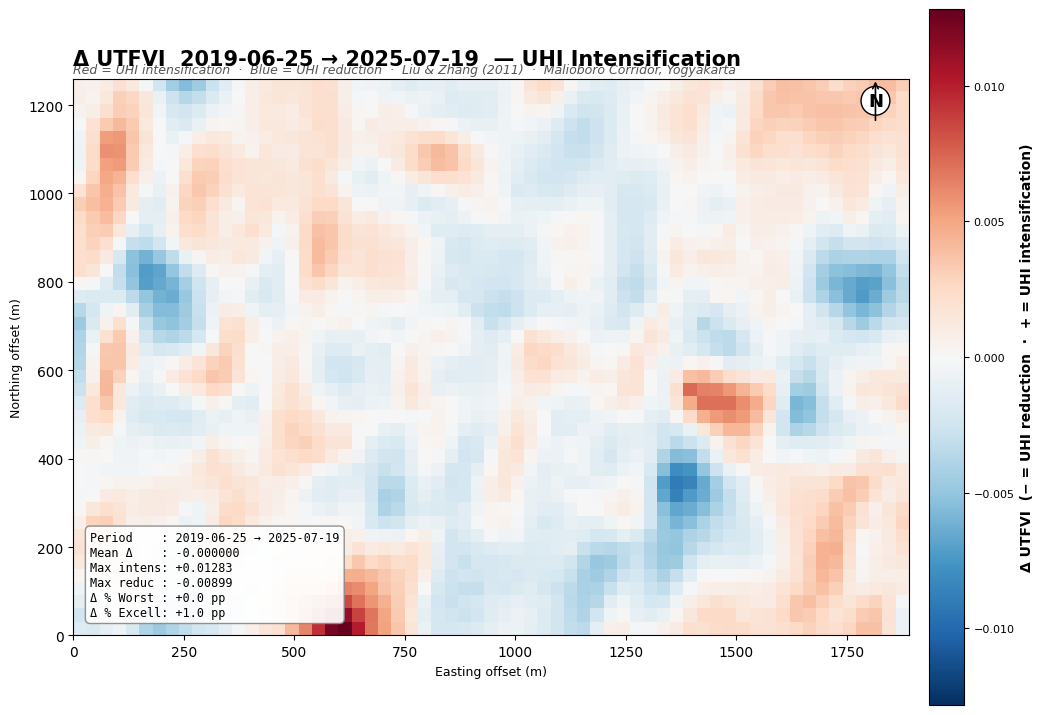

  💾 Saved: UTFVI_2019-06-25_classified.png


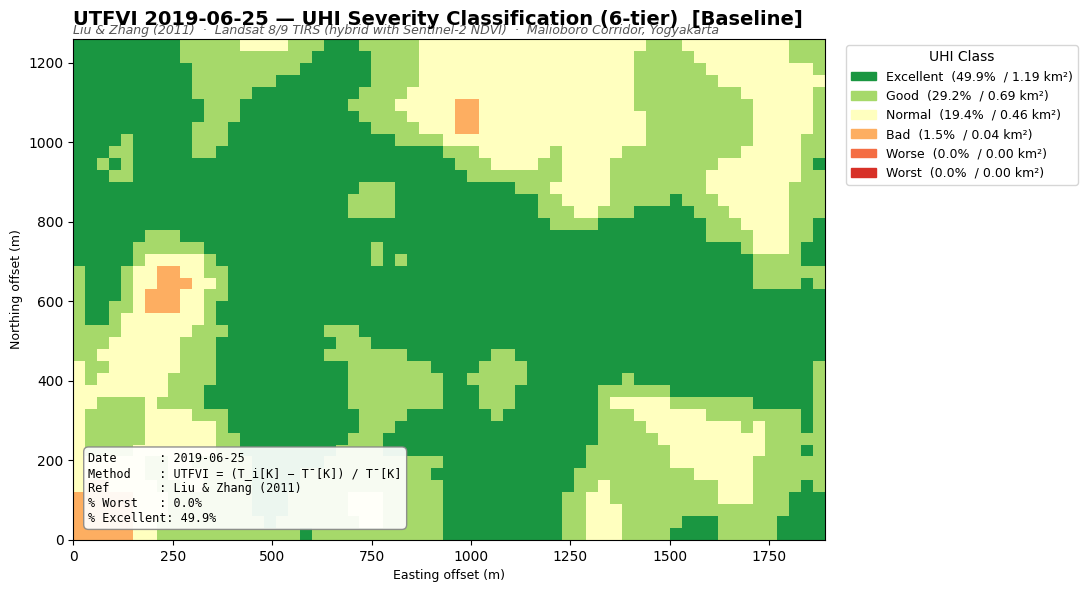

  💾 Saved: UTFVI_2025-07-19_classified.png


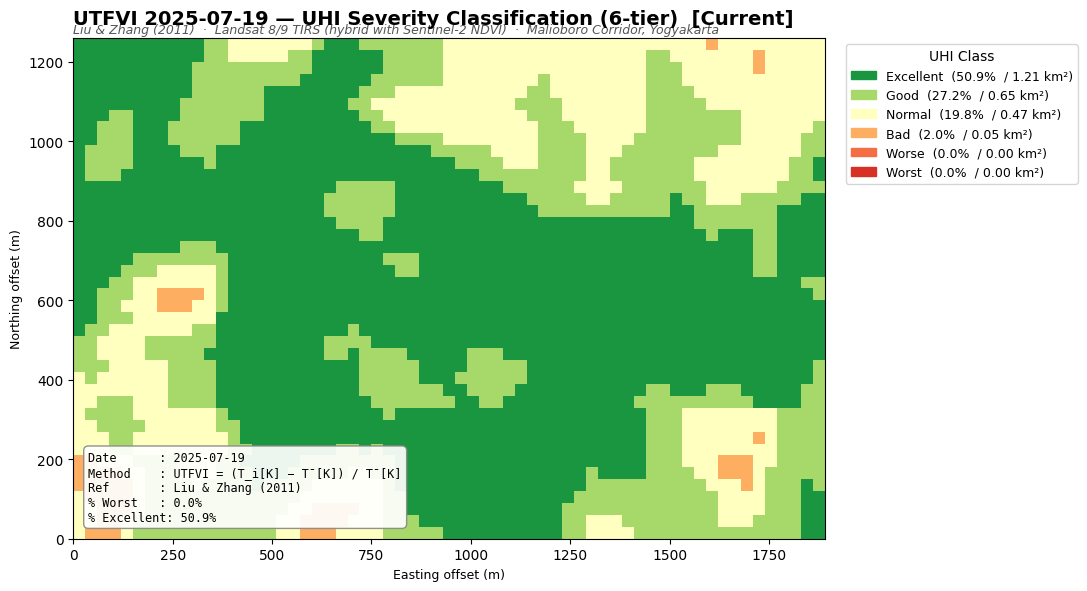


✅ UTFVI analysis complete (both periods + delta).
   ▶ Ready to proceed to Section 2.5 (UHI Analysis).


In [19]:
# 2.4. UTFVI — Urban Thermal Field Variance Index
# ─────────────────────────────────────────────────────────────────
# UTFVI normalises LST relative to the scene mean, making it
# comparable across different dates and seasons.
# It identifies areas of chronic urban heat stress.
#
# WHY BETTER THAN RAW LST FOR TEMPORAL COMPARISON:
#   Raw LST varies with season and time of day. UTFVI removes
#   that absolute bias so 2019 vs 2025 comparisons are valid.
#
# Formula (Liu & Zhang 2011):
#
#   UTFVI = (T_i[K] − T̄[K]) / T̄[K]
#
#   where:
#     T_i[K]  = pixel LST in Kelvin  (= LST_°C + 273.15)
#     T̄[K]   = scene-mean LST in Kelvin (NaN-safe, valid pixels only)
#
#   WHY KELVIN:
#     The denominator T̄ must be an absolute temperature (Kelvin).
#     Using Celsius mean would make UTFVI depend on the arbitrary
#     0°C reference — e.g. a 30°C mean gives denominator 30,
#     but the same scene in Kelvin gives 303.15, changing all
#     UTFVI values by a factor of ~10×.
#     The numerator difference (T_i − T̄) is identical in K or °C.
#
# Classification (Liu & Zhang 2011):
#   < 0.000          → Excellent  (no UHI effect)
#   0.000 – 0.005    → Good       (weak UHI)
#   0.005 – 0.010    → Normal     (moderate UHI)
#   0.010 – 0.015    → Bad        (strong UHI)
#   0.015 – 0.020    → Worse      (severe UHI)
#   ≥ 0.020          → Worst      (extreme UHI)
#
# Sensor modes:
#   "landsat"        → LST from Landsat thermal
#   "sentinel2"      → LST from Landsat thermal (hybrid)
#   "sentinel2_only" → UTFVI disabled (no thermal)
# ─────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("save_geotiff", "plot_map"):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

for _var in ("NX", "NY", "PIXEL_SIZE_M"):
    if globals().get(_var) is None:
        raise RuntimeError(
            f"'{_var}' is not defined. "
            "Run Section 1.5.x (grid setup) before this cell."
        )

# Reset outputs
utfvi_baseline_arr   = None
utfvi_arr            = None
utfvi_class_baseline = None
utfvi_class_arr      = None

if RUN_UTFVI:

    # ── Input validation ──────────────────────────────────────────
    if SENSOR == "sentinel2_only":
        print("⚠️  UTFVI is not available for SENSOR = 'sentinel2_only'.")
        print("   Switch to SENSOR = 'sentinel2' (hybrid) or 'landsat'.")

    elif globals().get("lst_baseline") is None:
        print("❌ lst_baseline is None — LST not computed.")
        print("   Run Section 2.3 with RUN_LST = True.")

    elif globals().get("lst_current") is None:
        print("❌ lst_current is None — LST not computed.")
        print("   Run Section 2.3 with RUN_LST = True.")

    else:
        print("🔥 [UTFVI] Computing Urban Thermal Field Variance Index "
              "for both periods...")

        # ── Date labels ───────────────────────────────────────────
        _date_base = globals().get(
            "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
        )
        _date_curr = globals().get(
            "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
        )

        # For hybrid mode, thermal dates differ from optical dates
        if SENSOR == "sentinel2":
            _th_date_base = globals().get("DATE_LS_BASELINE", _date_base)
            _th_date_curr = globals().get("DATE_LS_CURRENT",  _date_curr)
        else:
            _th_date_base = _date_base
            _th_date_curr = _date_curr

        _thermal_source = (
            "Landsat 8/9 TIRS"
            if SENSOR == "landsat"
            else "Landsat 8/9 TIRS (hybrid with Sentinel-2 NDVI)"
        )
        _pixel_km2 = (30 / 1000) ** 2   # Landsat thermal = 30 m always

        # ── UTFVI computation ─────────────────────────────────────
        def compute_utfvi(lst_celsius, label=""):
            """
            UTFVI = (T_i[K] − T̄[K]) / T̄[K]

            Converts LST to Kelvin before computing the ratio.
            The Kelvin denominator is required for physical consistency
            — using Celsius would make UTFVI depend on the arbitrary
            0°C reference and change all values by ~10×.

            NaN pixels (nodata/cloud) are excluded from the mean
            calculation via np.nanmean and preserved in output.

            Parameters
            ----------
            lst_celsius : np.ndarray  LST in °C, may contain NaN
            label       : str

            Returns
            -------
            np.ndarray : UTFVI float32, NaN preserved
            """
            # Convert to Kelvin — required for absolute temperature ratio
            lst_k    = lst_celsius + 273.15

            # NaN-safe scene mean (excludes nodata/cloud pixels)
            lst_mean_k = float(np.nanmean(lst_k))

            # UTFVI = (T_i - T̄) / T̄
            utfvi = ((lst_k - lst_mean_k) / lst_mean_k).astype("float32")

            # Preserve NaN from input LST
            utfvi = np.where(np.isnan(lst_celsius), np.nan, utfvi)

            if label:
                _valid = utfvi[~np.isnan(utfvi)]
                print(f"  UTFVI {label}:")
                print(f"    T̄ (scene mean) : {lst_mean_k - 273.15:.2f}°C "
                      f"({lst_mean_k:.2f} K)")
                print(f"    Mean UTFVI     : "
                      f"{float(np.nanmean(utfvi)):+.5f}")
                print(f"    Range          : "
                      f"[{float(np.nanmin(utfvi)):+.5f}, "
                      f"{float(np.nanmax(utfvi)):+.5f}]")
                print(f"    Valid pixels   : {len(_valid):,}")

            return utfvi

        # ── UTFVI classification ──────────────────────────────────
        def classify_utfvi(utfvi):
            """
            Apply the 6-tier Liu & Zhang (2011) classification.

            NaN pixels are assigned class 255 (nodata sentinel)
            to prevent them from being counted as class 0 (Excellent).

            Returns uint8 array:
              0 = Excellent, 1 = Good, 2 = Normal,
              3 = Bad, 4 = Worse, 5 = Worst, 255 = nodata
            """
            # Initialise with nodata sentinel (255)
            cls = np.full_like(utfvi, 255, dtype=np.uint8)

            valid = ~np.isnan(utfvi)
            cls[valid & (utfvi <  0.000)]                       = 0
            cls[valid & (utfvi >= 0.000) & (utfvi < 0.005)]    = 1
            cls[valid & (utfvi >= 0.005) & (utfvi < 0.010)]    = 2
            cls[valid & (utfvi >= 0.010) & (utfvi < 0.015)]    = 3
            cls[valid & (utfvi >= 0.015) & (utfvi < 0.020)]    = 4
            cls[valid & (utfvi >= 0.020)]                       = 5
            return cls

        # ── Compute for both periods ──────────────────────────────
        utfvi_baseline_arr   = compute_utfvi(
            lst_baseline, label=f"baseline ({_th_date_base})"
        )
        utfvi_arr            = compute_utfvi(
            lst_current,  label=f"current  ({_th_date_curr})"
        )
        utfvi_class_baseline = classify_utfvi(utfvi_baseline_arr)
        utfvi_class_arr      = classify_utfvi(utfvi_arr)

        # ── ΔUTFVI = current − baseline ───────────────────────────
        utfvi_delta = (utfvi_arr - utfvi_baseline_arr).astype("float32")

        # ── Save GeoTIFFs ─────────────────────────────────────────
        save_geotiff(utfvi_baseline_arr,
                     DIRS["raster"] / "UTFVI_baseline.tif")
        save_geotiff(utfvi_arr,
                     DIRS["raster"] / "UTFVI_current.tif")
        save_geotiff(utfvi_delta,
                     DIRS["raster"] / "UTFVI_delta.tif")
        save_geotiff(utfvi_class_baseline.astype("float32"),
                     DIRS["raster"] / "UTFVI_class_baseline.tif")
        save_geotiff(utfvi_class_arr.astype("float32"),
                     DIRS["raster"] / "UTFVI_class_current.tif")

        # ── Class distribution (NaN-safe, both periods) ───────────
        UTFVI_LABELS = [
            "Excellent", "Good", "Normal", "Bad", "Worse", "Worst"
        ]
        UTFVI_COLORS = [
            "#1a9641", "#a6d96a", "#ffffbf",
            "#fdae61", "#f46d43", "#d73027"
        ]
        UTFVI_BOUNDS = [0.000, 0.005, 0.010, 0.015, 0.020]

        # Count only valid pixels (exclude class 255 nodata)
        _n_valid_base = (utfvi_class_baseline != 255).sum()
        _n_valid_curr = (utfvi_class_arr      != 255).sum()

        print(f"\n  Class distribution "
              f"({_th_date_base} → {_th_date_curr}):")
        print(f"  {'Class':<12} {'Baseline':>10} {'Current':>10} "
              f"{'Δ (pp)':>10}  {'Curr km²':>10}")
        print(f"  {'-'*56}")

        _class_stats = {}
        for i, lbl in enumerate(UTFVI_LABELS):
            _b_cnt = (utfvi_class_baseline == i).sum()
            _c_cnt = (utfvi_class_arr      == i).sum()
            _b_pct = _b_cnt / _n_valid_base * 100 if _n_valid_base > 0 else 0
            _c_pct = _c_cnt / _n_valid_curr * 100 if _n_valid_curr > 0 else 0
            _delta_pp = _c_pct - _b_pct
            _c_km2    = _c_cnt * _pixel_km2
            _class_stats[i] = {
                "base_pct": _b_pct, "curr_pct": _c_pct,
                "delta_pp": _delta_pp, "curr_km2": _c_km2
            }
            print(f"  {i} {lbl:<10} {_b_pct:>9.1f}% {_c_pct:>9.1f}% "
                  f"{_delta_pp:>+9.1f}pp  {_c_km2:>9.2f}")

        # ── NaN-safe colormap range (shared across both periods) ──
        _finite_u = np.concatenate([
            utfvi_arr[np.isfinite(utfvi_arr)],
            utfvi_baseline_arr[np.isfinite(utfvi_baseline_arr)]
        ])
        _vmax_u = (
            max(abs(float(_finite_u.min())),
                abs(float(_finite_u.max())),
                0.005)
            if len(_finite_u) > 0 else 0.005
        )

        # ── Map 1: UTFVI Continuous — Baseline ───────────────────
        plot_map(
            utfvi_baseline_arr,
            title=f"UTFVI — {_th_date_base}  (Baseline)",
            subtitle=(
                f"UTFVI = (T_i[K] − T̄[K]) / T̄[K]  ·  "
                f"Liu & Zhang (2011)  ·  {STUDY_NAME}"
            ),
            cmap="RdYlGn_r", vmin=-_vmax_u, vmax=_vmax_u,
            cbar_label=(
                "UTFVI  (− = cooler than mean  ·  + = UHI hotspot)"
            ),
            out_filename=f"UTFVI_{_th_date_base}_baseline.png",
            stats_text=(
                f"Date      : {_th_date_base}\n"
                f"Source    : {_thermal_source}\n"
                f"T̄ (mean) : "
                f"{float(np.nanmean(lst_baseline)):.2f}°C\n"
                f"Mean UTFVI: "
                f"{float(np.nanmean(utfvi_baseline_arr)):+.5f}\n"
                f"% Worst   : "
                f"{_class_stats[5]['base_pct']:.1f}%\n"
                f"% Excellent: "
                f"{_class_stats[0]['base_pct']:.1f}%"
            ),
        )

        # ── Map 2: UTFVI Continuous — Current ────────────────────
        plot_map(
            utfvi_arr,
            title=f"UTFVI — {_th_date_curr}  (Current)",
            subtitle=(
                f"UTFVI = (T_i[K] − T̄[K]) / T̄[K]  ·  "
                f"Liu & Zhang (2011)  ·  {STUDY_NAME}"
            ),
            cmap="RdYlGn_r", vmin=-_vmax_u, vmax=_vmax_u,
            cbar_label=(
                "UTFVI  (− = cooler than mean  ·  + = UHI hotspot)"
            ),
            out_filename=f"UTFVI_{_th_date_curr}_current.png",
            stats_text=(
                f"Date      : {_th_date_curr}\n"
                f"Source    : {_thermal_source}\n"
                f"T̄ (mean) : "
                f"{float(np.nanmean(lst_current)):.2f}°C\n"
                f"Mean UTFVI: "
                f"{float(np.nanmean(utfvi_arr)):+.5f}\n"
                f"% Worst   : "
                f"{_class_stats[5]['curr_pct']:.1f}%\n"
                f"Δ % Worst : "
                f"{_class_stats[5]['delta_pp']:+.1f} pp vs baseline"
            ),
        )

        # ── Map 3: Δ UTFVI Change ─────────────────────────────────
        _finite_ud = utfvi_delta[np.isfinite(utfvi_delta)]
        _vmax_d = (
            max(abs(float(_finite_ud.min())),
                abs(float(_finite_ud.max())),
                0.005)
            if len(_finite_ud) > 0 else 0.005
        )
        plot_map(
            utfvi_delta,
            title=(
                f"Δ UTFVI  {_th_date_base} → {_th_date_curr}  "
                f"— UHI Intensification"
            ),
            subtitle=(
                "Red = UHI intensification  ·  "
                "Blue = UHI reduction  ·  "
                f"Liu & Zhang (2011)  ·  {STUDY_NAME}"
            ),
            cmap="RdBu_r", vmin=-_vmax_d, vmax=_vmax_d,
            cbar_label=(
                "Δ UTFVI  "
                "(− = UHI reduction  ·  + = UHI intensification)"
            ),
            out_filename=(
                f"UTFVI_delta_{_th_date_base}_{_th_date_curr}.png"
            ),
            stats_text=(
                f"Period    : {_th_date_base} → {_th_date_curr}\n"
                f"Mean Δ    : "
                f"{float(np.nanmean(utfvi_delta)):+.6f}\n"
                f"Max intens: "
                f"{float(np.nanmax(utfvi_delta)):+.5f}\n"
                f"Max reduc : "
                f"{float(np.nanmin(utfvi_delta)):+.5f}\n"
                f"Δ % Worst : "
                f"{_class_stats[5]['delta_pp']:+.1f} pp\n"
                f"Δ % Excell: "
                f"{_class_stats[0]['delta_pp']:+.1f} pp"
            ),
        )

        # ── Map 4 & 5: Classified maps (baseline + current) ───────
        def plot_utfvi_classified(cls_arr, label, date_label,
                                  out_filename):
            """
            Plot the 6-tier UTFVI classification map.
            NaN/nodata pixels (class 255) shown as light grey.
            """
            fig, ax = plt.subplots(
                figsize=(11, 9), facecolor="white"
            )
            extent = [
                0, NX * PIXEL_SIZE_M,
                0, NY * PIXEL_SIZE_M
            ]

            # Mask nodata (class 255) for display
            cls_display = np.where(
                cls_arr == 255, np.nan,
                cls_arr.astype("float32")
            )

            utfvi_cmap = ListedColormap(UTFVI_COLORS)
            utfvi_norm = BoundaryNorm(
                np.arange(-0.5, 6.5, 1), utfvi_cmap.N
            )

            im = ax.imshow(
                cls_display,
                cmap=utfvi_cmap, norm=utfvi_norm,
                origin="upper", extent=extent,
                interpolation="nearest"
            )

            ax.set_title(
                f"UTFVI {date_label} — UHI Severity "
                f"Classification (6-tier)  [{label}]",
                fontsize=14, fontweight="bold", pad=10, loc="left"
            )
            ax.text(
                0, 1.01,
                f"Liu & Zhang (2011)  ·  "
                f"{_thermal_source}  ·  {STUDY_NAME}",
                transform=ax.transAxes,
                fontsize=9, color="#555", style="italic"
            )

            # Count only valid pixels for legend percentages
            _n_v = max((cls_arr != 255).sum(), 1)  # guard against all-nodata
            handles = [
                mpatches.Patch(
                    color=UTFVI_COLORS[i],
                    label=(
                        f"{UTFVI_LABELS[i]}  "
                        f"({(cls_arr == i).sum() / _n_v * 100:.1f}%  "
                        f"/ {(cls_arr == i).sum() * _pixel_km2:.2f} km²)"
                    )
                )
                for i in range(6)
            ]
            ax.legend(
                handles=handles, fontsize=9,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                frameon=True, title="UHI Class"
            )
            ax.set_xlabel("Easting offset (m)", fontsize=9)
            ax.set_ylabel("Northing offset (m)", fontsize=9)
            ax.set_aspect("equal")

            stats_box = (
                f"Date      : {date_label}\n"
                f"Method    : UTFVI = (T_i[K] − T̄[K]) / T̄[K]\n"
                f"Ref       : Liu & Zhang (2011)\n"
                f"% Worst   : "
                f"{(cls_arr == 5).sum() / _n_v * 100:.1f}%\n"
                f"% Excellent: "
                f"{(cls_arr == 0).sum() / _n_v * 100:.1f}%"
            )
            ax.text(
                0.02, 0.03, stats_box,
                transform=ax.transAxes,
                fontsize=8.5, family="monospace",
                bbox=dict(
                    boxstyle="round,pad=0.4",
                    facecolor="white",
                    edgecolor="#888", alpha=0.92
                ),
                verticalalignment="bottom"
            )

            plt.tight_layout()
            out_path = DIRS["figure"] / out_filename
            fig.savefig(
                str(out_path), dpi=140,
                bbox_inches="tight", facecolor="white"
            )
            print(f"  💾 Saved: {out_filename}")
            plt.show()

        plot_utfvi_classified(
            utfvi_class_baseline,
            label="Baseline",
            date_label=_th_date_base,
            out_filename=f"UTFVI_{_th_date_base}_classified.png"
        )
        plot_utfvi_classified(
            utfvi_class_arr,
            label="Current",
            date_label=_th_date_curr,
            out_filename=f"UTFVI_{_th_date_curr}_classified.png"
        )

        print("\n✅ UTFVI analysis complete (both periods + delta).")
        print(f"   ▶ Ready to proceed to Section 2.5 (UHI Analysis).")

else:
    print("ℹ️  UTFVI skipped (RUN_UTFVI = False).")

🏙️  [UHI] Computing Urban Heat Island analysis for both periods...

  Masks baseline (2019-06-25):
    Urban pixels : 450  (0.40 km²)
    Rural pixels : 1,138  (1.02 km²)
    Valid total  : 2,646

  Masks current  (2025-07-19):
    Urban pixels : 505  (0.45 km²)
    Rural pixels : 1,179  (1.06 km²)
    Valid total  : 2,646

  UHI Intensity baseline (2019-06-25):
    LST̄ urban    : 39.50°C  (σ = 1.28°C)
    LST̄ rural    : 36.54°C  (σ = 1.05°C)
    UHI Intensity: +2.96°C
    UHI threshold: 38.65°C  (rural mean + 2σ)
    UHI area ratio: 37.3% of valid pixels

  UHI Intensity current  (2025-07-19):
    LST̄ urban    : 41.01°C  (σ = 1.29°C)
    LST̄ rural    : 37.92°C  (σ = 1.03°C)
    UHI Intensity: +3.08°C
    UHI threshold: 39.99°C  (rural mean + 2σ)
    UHI area ratio: 39.3% of valid pixels

  ════════════════════════════════════════════════
  UHI SUMMARY  (2019-06-25 → 2025-07-19)
  ════════════════════════════════════════════════
  UHI Intensity baseline : +2.96°C
  UHI Intensity cu

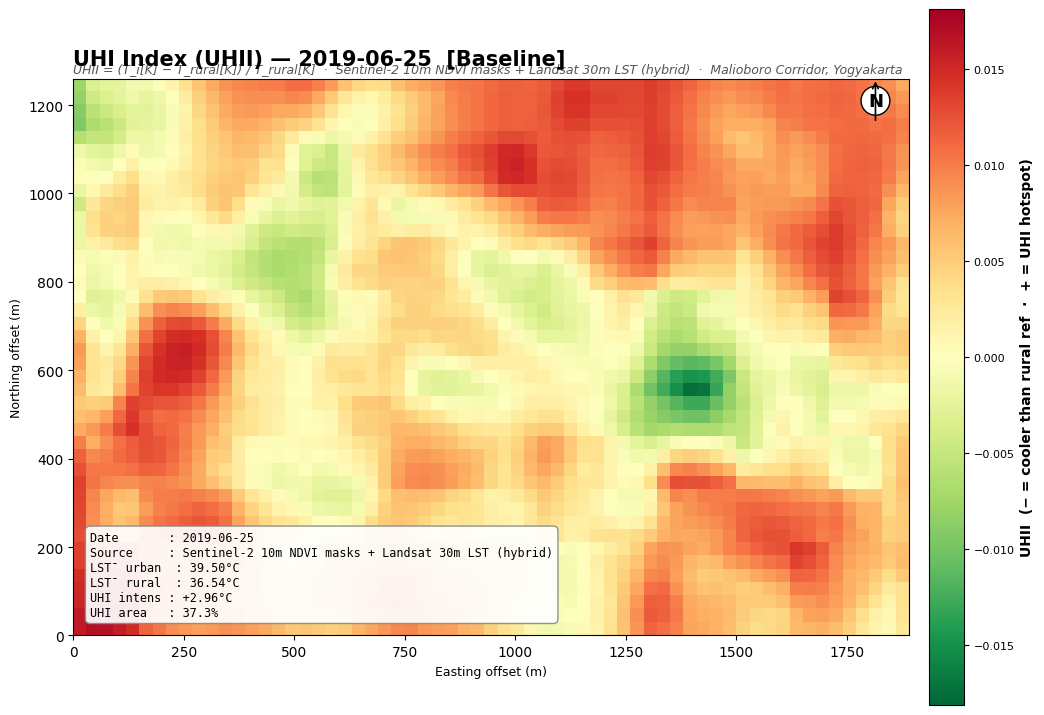

  💾 Saved: UHII_2025-07-19_current.png


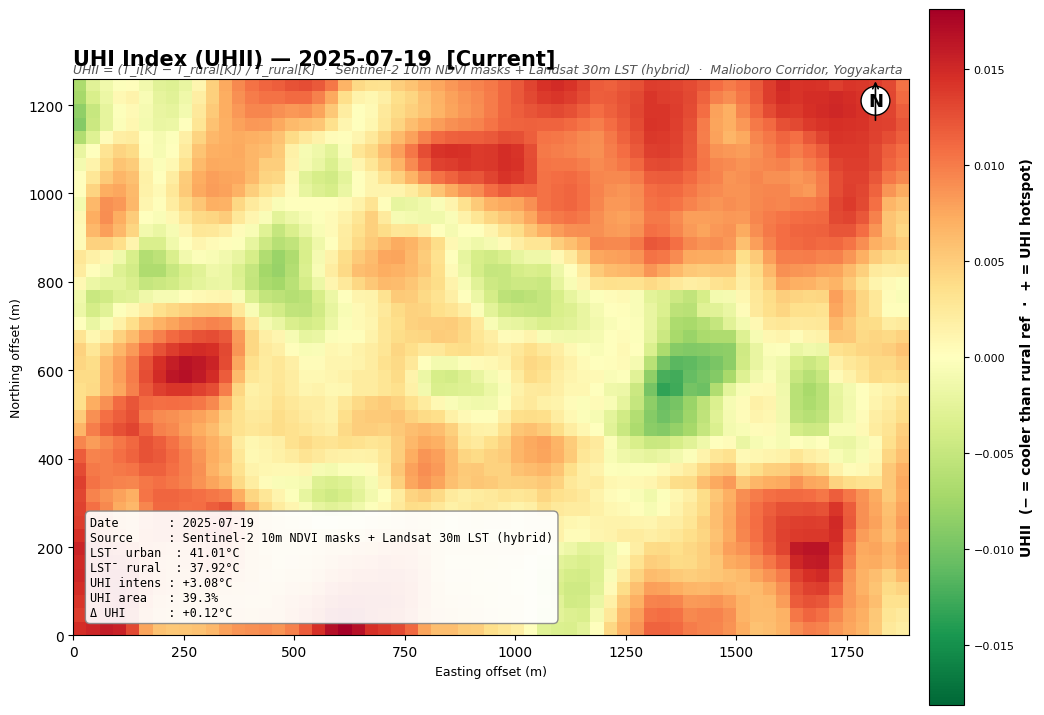

  💾 Saved: UHII_delta_2019-06-25_2025-07-19.png


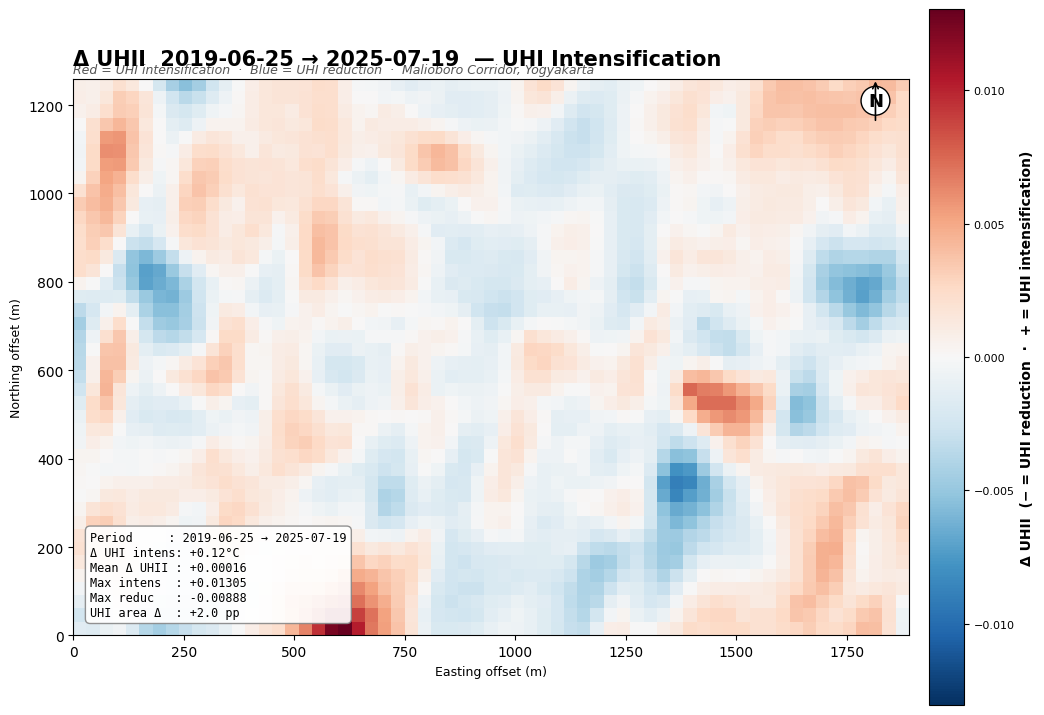


  💾 Saved: UHI_masks_2019-06-25_2025-07-19.png


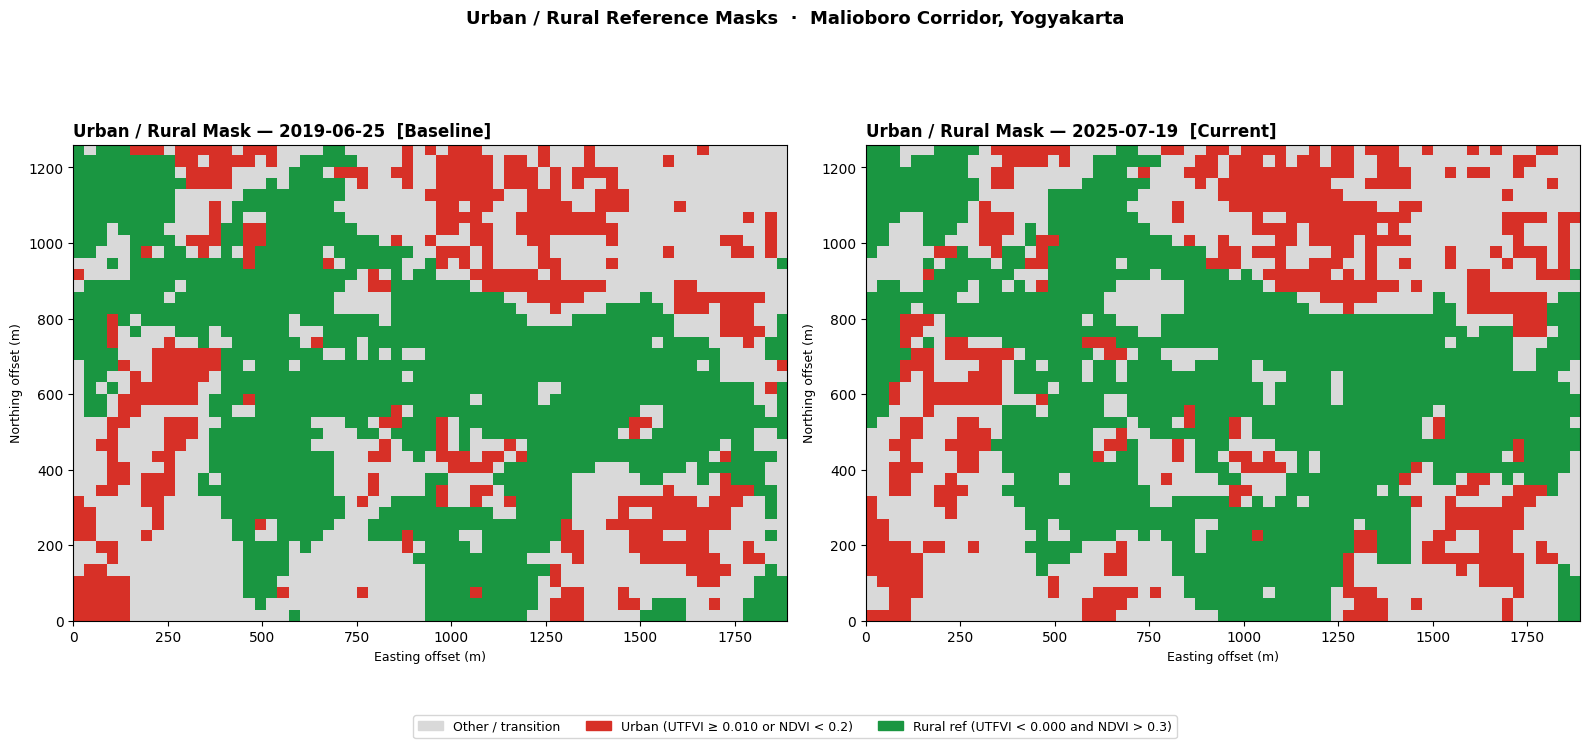

  💾 Saved: UHI_summary_2019-06-25_2025-07-19.png


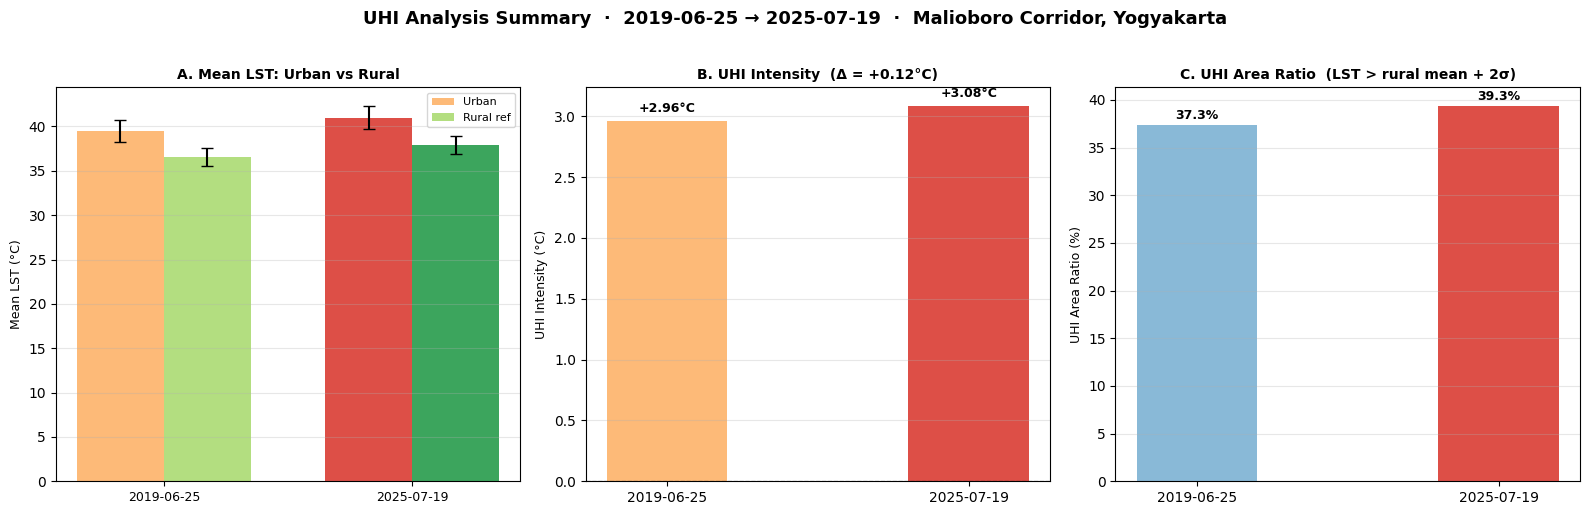


════════════════════════════════════════════════════
  ✅ UHI ANALYSIS COMPLETE
════════════════════════════════════════════════════
  UHI Intensity baseline : +2.96°C
  UHI Intensity current  : +3.08°C
  Δ UHI Intensity        : +0.12°C
  Interpretation:
    ⚪ UHI largely stable (+0.12°C).
════════════════════════════════════════════════════

  ▶ Ready to proceed to Section 2.6 (Carbon / NDVI).


In [20]:
#@title 2.5. UHI — Urban Heat Island Analysis
# ─────────────────────────────────────────────────────────────────
# WHAT: Quantifies the Urban Heat Island effect by comparing LST
#       between urban core pixels and surrounding rural/vegetated
#       reference pixels — for BOTH time periods.
#
# WHY: Raw LST and UTFVI show WHERE it is hot, but UHI intensity
#      (ΔLST_urban − ΔLST_rural) shows HOW MUCH hotter the urban
#      core is relative to its surroundings, and whether that gap
#      is widening or narrowing over time.
#
# Definitions used in this cell:
#
#   Urban pixels  : UTFVI ≥ 0.010  (class ≥ 3: Bad / Worse / Worst)
#                   OR NDVI < 0.2  (low vegetation = built-up)
#   Rural pixels  : UTFVI < 0.000  (class 0: Excellent)
#                   AND NDVI > 0.3  (vegetated reference)
#
# Metrics computed:
#
#   UHI Intensity [°C]:
#     UHI_intensity = LST̄_urban − LST̄_rural
#
#   UHI Change between periods:
#     ΔUHI = UHI_intensity_current − UHI_intensity_baseline
#
#   Normalised UHI Index (UHII):
#     UHII = (LST_i − LST̄_rural) / LST̄_rural  [dimensionless]
#     Comparable across seasons and cities.
#
#   UHI Area Ratio:
#     UHI_area_ratio = N_urban_hot / N_total_valid
#     where N_urban_hot = pixels with LST > LST̄_rural + 2σ_rural
#
# Sensor modes:
#   "landsat"        → LST from Landsat thermal (30 m)
#   "sentinel2"      → LST from Landsat thermal, NDVI from S2 (10 m)
#                      Urban/rural masks derived from S2 NDVI (higher
#                      spatial detail) + Landsat UTFVI
#   "sentinel2_only" → UHI disabled (no thermal)
# ─────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("save_geotiff", "plot_map"):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

for _var in ("NX", "NY", "PIXEL_SIZE_M"):
    if globals().get(_var) is None:
        raise RuntimeError(
            f"'{_var}' not defined. "
            "Run Section 1.5.x (grid setup) before this cell."
        )

# Reset outputs
uhi_mask_urban_baseline = uhi_mask_urban_current  = None
uhi_mask_rural_baseline = uhi_mask_rural_current  = None
uhi_intensity_baseline  = uhi_intensity_current   = None
uhii_baseline           = uhii_current            = None
uhii_delta              = None

RUN_UHI = globals().get("RUN_UHI", True)   # default True if not set

if RUN_UHI:

    # ── Sensor / input validation ─────────────────────────────────
    if SENSOR == "sentinel2_only":
        print("⚠️  UHI analysis is not available for "
              "SENSOR = 'sentinel2_only'.")
        print("   Switch to SENSOR = 'sentinel2' (hybrid) "
              "or 'landsat'.")

    elif globals().get("lst_baseline") is None or \
         globals().get("lst_current")  is None:
        print("❌ LST arrays not found.")
        print("   Run Section 2.3 with RUN_LST = True.")

    elif globals().get("ndvi_baseline") is None or \
         globals().get("ndvi_current")  is None:
        print("❌ NDVI arrays not found.")
        print("   Run Section 2.1 with RUN_NDVI = True.")

    elif globals().get("utfvi_baseline_arr") is None or \
         globals().get("utfvi_arr")          is None:
        print("❌ UTFVI arrays not found.")
        print("   Run Section 2.4 with RUN_UTFVI = True.")

    else:
        print("🏙️  [UHI] Computing Urban Heat Island analysis "
              "for both periods...")

        # ── Date / sensor labels ──────────────────────────────────
        _date_base = globals().get(
            "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
        )
        _date_curr = globals().get(
            "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
        )

        if SENSOR == "sentinel2":
            _th_date_base = globals().get(
                "DATE_LS_BASELINE", _date_base
            )
            _th_date_curr = globals().get(
                "DATE_LS_CURRENT",  _date_curr
            )
            _ndvi_res  = 10
            _lst_res   = 30
            _mode_note = (
                "Sentinel-2 10m NDVI masks + "
                "Landsat 30m LST (hybrid)"
            )
        else:
            _th_date_base = _date_base
            _th_date_curr = _date_curr
            _ndvi_res  = 30
            _lst_res   = 30
            _mode_note = "Landsat 8/9 TIRS 30m"

        _pixel_km2_lst  = (_lst_res  / 1000) ** 2
        _pixel_km2_ndvi = (_ndvi_res / 1000) ** 2

        # ── Urban / Rural mask construction ──────────────────────
        #
        # Urban pixels:
        #   UTFVI ≥ 0.010 (Bad/Worse/Worst) OR NDVI < 0.2
        #   Captures both thermally hot and structurally built-up areas.
        #
        # Rural pixels:
        #   UTFVI < 0.000 (Excellent) AND NDVI > 0.3
        #   Captures cool, vegetated reference areas only.
        #   Both conditions required to avoid misclassifying cool
        #   impervious surfaces (e.g. water bodies) as rural.
        #
        # Note for sentinel2 hybrid mode:
        #   NDVI is at 10m, UTFVI/LST at 30m.
        #   The NDVI condition is evaluated at its native resolution
        #   and then the LST statistics are extracted at 30m.
        #   This is conservative — we use UTFVI (30m) as the primary
        #   thermal criterion and NDVI as a secondary vegetation filter.
        #
        def build_urban_rural_masks(utfvi, ndvi, lst, label=""):
            """
            Build boolean urban and rural pixel masks.

            Urban : UTFVI ≥ 0.010  OR  NDVI < 0.2
            Rural : UTFVI < 0.000  AND NDVI > 0.3

            All three inputs must be spatially aligned (same grid).
            NaN pixels are excluded from both masks.

            Parameters
            ----------
            utfvi : np.ndarray  UTFVI float32
            ndvi  : np.ndarray  NDVI  float32
            lst   : np.ndarray  LST   float32 [°C]
            label : str

            Returns
            -------
            urban_mask, rural_mask : np.ndarray bool
            """
            valid = (
                ~np.isnan(utfvi) &
                ~np.isnan(ndvi)  &
                ~np.isnan(lst)
            )

            urban = valid & (
                (utfvi >= 0.010) | (ndvi < 0.2)
            )
            rural = valid & (
                (utfvi < 0.000) & (ndvi > 0.3)
            )

            if label:
                print(f"\n  Masks {label}:")
                print(f"    Urban pixels : {urban.sum():,}  "
                      f"({urban.sum() * _pixel_km2_lst:.2f} km²)")
                print(f"    Rural pixels : {rural.sum():,}  "
                      f"({rural.sum() * _pixel_km2_lst:.2f} km²)")
                print(f"    Valid total  : {valid.sum():,}")

                if rural.sum() < 10:
                    print(f"    ⚠️  Very few rural reference pixels "
                          f"({rural.sum()}) — UHI intensity estimate "
                          f"may be unreliable.")
                    print(f"       Consider widening the AOI to include "
                          f"more vegetated surroundings.")

            return urban, rural

        # ── For sentinel2 hybrid: resample NDVI to LST grid ──────
        # NDVI (10m) and LST (30m) may have different shapes.
        # We use the LST grid as the reference — NDVI is already
        # reprojected to the output grid via reproj_to_grid() in
        # Section 1.6, so shapes should match. Add a safety check.
        def _align_to_lst(ndvi_arr, lst_arr, name="NDVI"):
            if ndvi_arr.shape != lst_arr.shape:
                from skimage.transform import resize
                print(f"  ℹ️  Resampling {name} "
                      f"{ndvi_arr.shape} → {lst_arr.shape} "
                      f"to match LST grid...")
                ndvi_resampled = resize(
                    ndvi_arr,
                    lst_arr.shape,
                    order=1,          # bilinear
                    preserve_range=True,
                    anti_aliasing=True
                ).astype("float32")
                return ndvi_resampled
            return ndvi_arr

        _ndvi_base_aligned = _align_to_lst(ndvi_baseline, lst_baseline,
                                           "NDVI baseline")
        _ndvi_curr_aligned = _align_to_lst(ndvi_current,  lst_current,
                                           "NDVI current")

        # ── Build masks for both periods ──────────────────────────
        uhi_mask_urban_baseline, uhi_mask_rural_baseline = \
            build_urban_rural_masks(
                utfvi_baseline_arr, _ndvi_base_aligned,
                lst_baseline, label=f"baseline ({_th_date_base})"
            )
        uhi_mask_urban_current, uhi_mask_rural_current = \
            build_urban_rural_masks(
                utfvi_arr, _ndvi_curr_aligned,
                lst_current, label=f"current  ({_th_date_curr})"
            )

        # ── UHI Intensity = LST̄_urban − LST̄_rural ───────────────
        #
        # UHI_intensity [°C] = mean(LST_urban) − mean(LST_rural)
        #
        # This is the standard UHI intensity metric used in:
        #   Oke (1973), Voogt & Oke (2003), Zhao et al. (2014)
        #
        def uhi_intensity(lst, urban_mask, rural_mask, label=""):
            """
            UHI Intensity = LST̄_urban − LST̄_rural  [°C]

            Parameters
            ----------
            lst         : np.ndarray  LST [°C]
            urban_mask  : np.ndarray  bool
            rural_mask  : np.ndarray  bool

            Returns
            -------
            float : UHI intensity in °C
            dict  : detailed statistics
            """
            lst_urban = lst[urban_mask]
            lst_rural = lst[rural_mask]

            mean_urban = float(np.nanmean(lst_urban)) \
                if len(lst_urban) > 0 else np.nan
            mean_rural = float(np.nanmean(lst_rural)) \
                if len(lst_rural) > 0 else np.nan
            std_urban  = float(np.nanstd(lst_urban)) \
                if len(lst_urban) > 0 else np.nan
            std_rural  = float(np.nanstd(lst_rural)) \
                if len(lst_rural) > 0 else np.nan

            intensity  = (mean_urban - mean_rural) \
                if not (np.isnan(mean_urban) or np.isnan(mean_rural)) \
                else np.nan

            # UHI Area Ratio:
            # Fraction of valid pixels with LST > LST̄_rural + 2σ_rural
            # (statistically significant heat anomaly)
            if not np.isnan(mean_rural) and not np.isnan(std_rural):
                _threshold = mean_rural + 2 * std_rural
                _valid_lst = lst[~np.isnan(lst)]
                uhi_area_ratio = (
                    (_valid_lst > _threshold).sum() /
                    len(_valid_lst)
                ) if len(_valid_lst) > 0 else np.nan
            else:
                _threshold     = np.nan
                uhi_area_ratio = np.nan

            stats = {
                "mean_urban"    : mean_urban,
                "mean_rural"    : mean_rural,
                "std_urban"     : std_urban,
                "std_rural"     : std_rural,
                "intensity"     : intensity,
                "threshold"     : _threshold,
                "uhi_area_ratio": uhi_area_ratio,
                "n_urban"       : len(lst_urban),
                "n_rural"       : len(lst_rural),
            }

            if label:
                print(f"\n  UHI Intensity {label}:")
                print(f"    LST̄ urban    : {mean_urban:.2f}°C  "
                      f"(σ = {std_urban:.2f}°C)")
                print(f"    LST̄ rural    : {mean_rural:.2f}°C  "
                      f"(σ = {std_rural:.2f}°C)")
                print(f"    UHI Intensity: {intensity:+.2f}°C")
                print(f"    UHI threshold: {_threshold:.2f}°C  "
                      f"(rural mean + 2σ)")
                print(f"    UHI area ratio: "
                      f"{uhi_area_ratio*100:.1f}% of valid pixels")

            return intensity, stats

        uhi_intensity_baseline, _stats_base = uhi_intensity(
            lst_baseline,
            uhi_mask_urban_baseline,
            uhi_mask_rural_baseline,
            label=f"baseline ({_th_date_base})"
        )
        uhi_intensity_current, _stats_curr = uhi_intensity(
            lst_current,
            uhi_mask_urban_current,
            uhi_mask_rural_current,
            label=f"current  ({_th_date_curr})"
        )

        # ── ΔUHI = current − baseline ─────────────────────────────
        delta_uhi = (
            uhi_intensity_current - uhi_intensity_baseline
            if not (np.isnan(uhi_intensity_current) or
                    np.isnan(uhi_intensity_baseline))
            else np.nan
        )

        print(f"\n  {'═'*48}")
        print(f"  UHI SUMMARY  "
              f"({_th_date_base} → {_th_date_curr})")
        print(f"  {'═'*48}")
        print(f"  UHI Intensity baseline : "
              f"{uhi_intensity_baseline:+.2f}°C")
        print(f"  UHI Intensity current  : "
              f"{uhi_intensity_current:+.2f}°C")
        print(f"  Δ UHI Intensity        : {delta_uhi:+.2f}°C  "
              f"({'intensifying 🔴' if delta_uhi > 0 else 'reducing 🟢' if delta_uhi < 0 else 'stable ⚪'} )")
        print(f"  UHI area ratio baseline: "
              f"{_stats_base['uhi_area_ratio']*100:.1f}%")
        print(f"  UHI area ratio current : "
              f"{_stats_curr['uhi_area_ratio']*100:.1f}%")
        print(f"  {'═'*48}")

        # ── Normalised UHI Index (UHII) ───────────────────────────
        #
        # UHII = (LST_i − LST̄_rural) / LST̄_rural  [dimensionless]
        #
        # Normalising by the rural mean in Kelvin makes UHII
        # comparable across cities and seasons.
        # Positive UHII = pixel is warmer than rural reference.
        #
        def compute_uhii(lst_celsius, mean_rural_celsius, label=""):
            """
            Normalised UHI Index:

                UHII = (T_i[K] − T̄_rural[K]) / T̄_rural[K]

            Uses Kelvin to avoid dependence on the 0°C reference.

            Parameters
            ----------
            lst_celsius       : np.ndarray  LST [°C]
            mean_rural_celsius: float        Rural mean LST [°C]

            Returns
            -------
            np.ndarray : UHII float32, NaN preserved
            """
            lst_k        = lst_celsius + 273.15
            rural_mean_k = mean_rural_celsius + 273.15

            uhii = ((lst_k - rural_mean_k) / rural_mean_k
                    ).astype("float32")

            # Preserve NaN
            uhii = np.where(np.isnan(lst_celsius), np.nan, uhii)

            if label:
                print(f"  UHII {label}: "
                      f"mean={float(np.nanmean(uhii)):+.5f}  "
                      f"range=[{float(np.nanmin(uhii)):+.5f}, "
                      f"{float(np.nanmax(uhii)):+.5f}]")

            return uhii

        uhii_baseline = compute_uhii(
            lst_baseline,
            _stats_base["mean_rural"],
            label=f"baseline ({_th_date_base})"
        )
        uhii_current = compute_uhii(
            lst_current,
            _stats_curr["mean_rural"],
            label=f"current  ({_th_date_curr})"
        )

        # ΔUHII = current − baseline
        # Positive = pixel became relatively hotter vs its rural ref
        uhii_delta = (uhii_current - uhii_baseline).astype("float32")

        # ── Save GeoTIFFs ─────────────────────────────────────────
        save_geotiff(uhii_baseline,
                     DIRS["raster"] / "UHII_baseline.tif")
        save_geotiff(uhii_current,
                     DIRS["raster"] / "UHII_current.tif")
        save_geotiff(uhii_delta,
                     DIRS["raster"] / "UHII_delta.tif")

        # Urban/rural masks as rasters (1=urban, 2=rural, 0=other)
        _mask_base_raster = np.zeros(lst_baseline.shape,
                                     dtype="float32")
        _mask_base_raster[uhi_mask_urban_baseline] = 1.0
        _mask_base_raster[uhi_mask_rural_baseline] = 2.0
        _mask_curr_raster = np.zeros(lst_current.shape,
                                     dtype="float32")
        _mask_curr_raster[uhi_mask_urban_current]  = 1.0
        _mask_curr_raster[uhi_mask_rural_current]  = 2.0

        save_geotiff(_mask_base_raster,
                     DIRS["raster"] / "UHI_mask_baseline.tif")
        save_geotiff(_mask_curr_raster,
                     DIRS["raster"] / "UHI_mask_current.tif")

        # ── Shared colormap range for UHII maps ───────────────────
        _finite_uhii = np.concatenate([
            uhii_baseline[np.isfinite(uhii_baseline)],
            uhii_current[np.isfinite(uhii_current)]
        ])
        _vmax_uhii = (
            max(abs(float(_finite_uhii.min())),
                abs(float(_finite_uhii.max())),
                0.005)
            if len(_finite_uhii) > 0 else 0.005
        )

        # ── Map 1: UHII Baseline ──────────────────────────────────
        plot_map(
            uhii_baseline,
            title=f"UHI Index (UHII) — {_th_date_base}  [Baseline]",
            subtitle=(
                f"UHII = (T_i[K] − T̄_rural[K]) / T̄_rural[K]  ·  "
                f"{_mode_note}  ·  {STUDY_NAME}"
            ),
            cmap="RdYlGn_r",
            vmin=-_vmax_uhii, vmax=_vmax_uhii,
            cbar_label=(
                "UHII  "
                "(− = cooler than rural ref  ·  "
                "+ = UHI hotspot)"
            ),
            out_filename=f"UHII_{_th_date_base}_baseline.png",
            stats_text=(
                f"Date       : {_th_date_base}\n"
                f"Source     : {_mode_note}\n"
                f"LST̄ urban  : "
                f"{_stats_base['mean_urban']:.2f}°C\n"
                f"LST̄ rural  : "
                f"{_stats_base['mean_rural']:.2f}°C\n"
                f"UHI intens : "
                f"{uhi_intensity_baseline:+.2f}°C\n"
                f"UHI area   : "
                f"{_stats_base['uhi_area_ratio']*100:.1f}%"
            ),
        )

        # ── Map 2: UHII Current ───────────────────────────────────
        plot_map(
            uhii_current,
            title=f"UHI Index (UHII) — {_th_date_curr}  [Current]",
            subtitle=(
                f"UHII = (T_i[K] − T̄_rural[K]) / T̄_rural[K]  ·  "
                f"{_mode_note}  ·  {STUDY_NAME}"
            ),
            cmap="RdYlGn_r",
            vmin=-_vmax_uhii, vmax=_vmax_uhii,
            cbar_label=(
                "UHII  "
                "(− = cooler than rural ref  ·  "
                "+ = UHI hotspot)"
            ),
            out_filename=f"UHII_{_th_date_curr}_current.png",
            stats_text=(
                f"Date       : {_th_date_curr}\n"
                f"Source     : {_mode_note}\n"
                f"LST̄ urban  : "
                f"{_stats_curr['mean_urban']:.2f}°C\n"
                f"LST̄ rural  : "
                f"{_stats_curr['mean_rural']:.2f}°C\n"
                f"UHI intens : "
                f"{uhi_intensity_current:+.2f}°C\n"
                f"UHI area   : "
                f"{_stats_curr['uhi_area_ratio']*100:.1f}%\n"
                f"Δ UHI      : {delta_uhi:+.2f}°C"
            ),
        )

        # ── Map 3: Δ UHII Change ──────────────────────────────────
        _finite_ud = uhii_delta[np.isfinite(uhii_delta)]
        _vmax_ud = (
            max(abs(float(_finite_ud.min())),
                abs(float(_finite_ud.max())),
                0.005)
            if len(_finite_ud) > 0 else 0.005
        )
        plot_map(
            uhii_delta,
            title=(
                f"Δ UHII  {_th_date_base} → {_th_date_curr}  "
                f"— UHI Intensification"
            ),
            subtitle=(
                "Red = UHI intensification  ·  "
                "Blue = UHI reduction  ·  "
                f"{STUDY_NAME}"
            ),
            cmap="RdBu_r",
            vmin=-_vmax_ud, vmax=_vmax_ud,
            cbar_label=(
                "Δ UHII  "
                "(− = UHI reduction  ·  + = UHI intensification)"
            ),
            out_filename=(
                f"UHII_delta_{_th_date_base}_{_th_date_curr}.png"
            ),
            stats_text=(
                f"Period     : {_th_date_base} → {_th_date_curr}\n"
                f"Δ UHI intens: {delta_uhi:+.2f}°C\n"
                f"Mean Δ UHII : "
                f"{float(np.nanmean(uhii_delta)):+.5f}\n"
                f"Max intens  : "
                f"{float(np.nanmax(uhii_delta)):+.5f}\n"
                f"Max reduc   : "
                f"{float(np.nanmin(uhii_delta)):+.5f}\n"
                f"UHI area Δ  : "
                f"{(_stats_curr['uhi_area_ratio'] - _stats_base['uhi_area_ratio'])*100:+.1f} pp"
            ),
        )

        # ── Map 4: Urban / Rural Mask (current) ───────────────────
        _mask_cmap = ListedColormap(["#d9d9d9", "#d73027", "#1a9641"])
        _mask_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], _mask_cmap.N)

        fig, axes = plt.subplots(
            1, 2, figsize=(16, 7), facecolor="white"
        )
        _extent = [0, NX * PIXEL_SIZE_M, 0, NY * PIXEL_SIZE_M]

        for ax, _mask_r, _date_l, _title_l in zip(
            axes,
            [_mask_base_raster, _mask_curr_raster],
            [_th_date_base,     _th_date_curr],
            ["Baseline",        "Current"]
        ):
            ax.imshow(
                _mask_r, cmap=_mask_cmap, norm=_mask_norm,
                origin="upper", extent=_extent,
                interpolation="nearest"
            )
            ax.set_title(
                f"Urban / Rural Mask — {_date_l}  [{_title_l}]",
                fontsize=12, fontweight="bold", loc="left"
            )
            ax.set_xlabel("Easting offset (m)", fontsize=9)
            ax.set_ylabel("Northing offset (m)", fontsize=9)
            ax.set_aspect("equal")

        _handles_mask = [
            mpatches.Patch(color="#d9d9d9", label="Other / transition"),
            mpatches.Patch(color="#d73027", label="Urban (UTFVI ≥ 0.010 or NDVI < 0.2)"),
            mpatches.Patch(color="#1a9641", label="Rural ref (UTFVI < 0.000 and NDVI > 0.3)"),
        ]
        fig.legend(
            handles=_handles_mask,
            fontsize=9, loc="lower center",
            ncol=3, frameon=True,
            bbox_to_anchor=(0.5, -0.04)
        )
        fig.suptitle(
            f"Urban / Rural Reference Masks  ·  {STUDY_NAME}",
            fontsize=13, fontweight="bold", y=1.01
        )
        plt.tight_layout()
        _mask_path = (
            DIRS["figure"] /
            f"UHI_masks_{_th_date_base}_{_th_date_curr}.png"
        )
        fig.savefig(
            str(_mask_path), dpi=140,
            bbox_inches="tight", facecolor="white"
        )
        print(f"\n  💾 Saved: UHI_masks_{_th_date_base}_{_th_date_curr}.png")
        plt.show()

        # ── Map 5: UHI Summary Bar Chart ──────────────────────────
        fig, axes = plt.subplots(
            1, 3, figsize=(16, 5), facecolor="white"
        )

        _periods  = [_th_date_base, _th_date_curr]
        _colors_u = ["#fdae61", "#d73027"]
        _colors_r = ["#a6d96a", "#1a9641"]

        # Panel A: Mean LST urban vs rural
        ax = axes[0]
        _x = np.arange(2)
        _w = 0.35
        ax.bar(
            _x - _w/2,
            [_stats_base["mean_urban"], _stats_curr["mean_urban"]],
            _w, label="Urban", color=_colors_u, alpha=0.85,
            yerr=[_stats_base["std_urban"], _stats_curr["std_urban"]],
            capsize=4
        )
        ax.bar(
            _x + _w/2,
            [_stats_base["mean_rural"], _stats_curr["mean_rural"]],
            _w, label="Rural ref", color=_colors_r, alpha=0.85,
            yerr=[_stats_base["std_rural"], _stats_curr["std_rural"]],
            capsize=4
        )
        ax.set_xticks(_x)
        ax.set_xticklabels(_periods, fontsize=9)
        ax.set_ylabel("Mean LST (°C)", fontsize=9)
        ax.set_title("A. Mean LST: Urban vs Rural",
                     fontsize=10, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # Panel B: UHI Intensity comparison
        ax = axes[1]
        _intens = [uhi_intensity_baseline, uhi_intensity_current]
        _bar_colors = [
            "#fdae61" if uhi_intensity_baseline >= 0 else "#74add1",
            "#d73027" if uhi_intensity_current  >= 0 else "#4575b4"
        ]
        bars = ax.bar(
            _periods, _intens,
            color=_bar_colors, alpha=0.85, width=0.4
        )
        for bar, val in zip(bars, _intens):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{val:+.2f}°C",
                ha="center", va="bottom", fontsize=9,
                fontweight="bold"
            )
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_ylabel("UHI Intensity (°C)", fontsize=9)
        ax.set_title(
            f"B. UHI Intensity  (Δ = {delta_uhi:+.2f}°C)",
            fontsize=10, fontweight="bold"
        )
        ax.grid(axis="y", alpha=0.3)

        # Panel C: UHI Area Ratio comparison
        ax = axes[2]
        _area_ratios = [
            _stats_base["uhi_area_ratio"] * 100,
            _stats_curr["uhi_area_ratio"] * 100
        ]
        _bar_colors_c = [
            "#d73027" if _area_ratios[0] >= _area_ratios[1] else "#74add1",
            "#d73027" if _area_ratios[1] >= _area_ratios[0] else "#74add1",
        ]
        bars_c = ax.bar(
            _periods, _area_ratios,
            color=_bar_colors_c, alpha=0.85, width=0.4
        )
        for bar, val in zip(bars_c, _area_ratios):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=9,
                fontweight="bold"
            )
        ax.set_ylabel("UHI Area Ratio (%)", fontsize=9)
        ax.set_title(
            "C. UHI Area Ratio  "
            f"(LST > rural mean + 2σ)",
            fontsize=10, fontweight="bold"
        )
        ax.grid(axis="y", alpha=0.3)

        fig.suptitle(
            f"UHI Analysis Summary  ·  "
            f"{_th_date_base} → {_th_date_curr}  ·  "
            f"{STUDY_NAME}",
            fontsize=13, fontweight="bold", y=1.02
        )
        plt.tight_layout()
        _bar_path = (
            DIRS["figure"] /
            f"UHI_summary_{_th_date_base}_{_th_date_curr}.png"
        )
        fig.savefig(
            str(_bar_path), dpi=140,
            bbox_inches="tight", facecolor="white"
        )
        print(f"  💾 Saved: "
              f"UHI_summary_{_th_date_base}_{_th_date_curr}.png")
        plt.show()

        print(f"\n{'═'*52}")
        print(f"  ✅ UHI ANALYSIS COMPLETE")
        print(f"{'═'*52}")
        print(f"  UHI Intensity baseline : "
              f"{uhi_intensity_baseline:+.2f}°C")
        print(f"  UHI Intensity current  : "
              f"{uhi_intensity_current:+.2f}°C")
        print(f"  Δ UHI Intensity        : {delta_uhi:+.2f}°C")
        print(f"  Interpretation:")
        if not np.isnan(delta_uhi):
            if delta_uhi > 1.0:
                print(f"    🔴 Strong UHI intensification (+{delta_uhi:.2f}°C).")
                print(f"       Urban expansion or vegetation loss likely.")
            elif delta_uhi > 0.3:
                print(f"    🟠 Moderate UHI intensification (+{delta_uhi:.2f}°C).")
            elif delta_uhi > -0.3:
                print(f"    ⚪ UHI largely stable ({delta_uhi:+.2f}°C).")
            elif delta_uhi > -1.0:
                print(f"    🟡 Moderate UHI reduction ({delta_uhi:+.2f}°C).")
                print(f"       Possible greening or urban cooling measures.")
            else:
                print(f"    🟢 Strong UHI reduction ({delta_uhi:+.2f}°C).")
        print(f"{'═'*52}")
        print(f"\n  ▶ Ready to proceed to Section 2.6 (Carbon / NDVI).")

else:
    print("ℹ️  UHI analysis skipped (RUN_UHI = False).")

# 2.6. Carbon Stock & Sequestration Analysis

🌳 [Carbon 2D] Computing LULC-based carbon stock for both periods...
  ⚠️  PIXEL_AREA_HA mismatch detected:
     Global PIXEL_AREA_HA = 0.090000 ha
     Sensor-derived       = 0.010000 ha  (10m × 10m)
     Using sensor-derived value for carbon totals.
  Sensor       : sentinel2  (10m resolution)
  Pixel area   : 0.010000 ha  = 10² m² / 10,000
  Edge buffer  : 100m  → 10 dilation iterations (100m at 10m resolution)
  Edge loss    : 15%  (factor = 0.85)
  Edge effect baseline:
    Edge pixels : 1,289  (12.9 ha)
  Edge effect current:
    Edge pixels : 2,248  (22.5 ha)

  ────────────────────────────────────────────────────────────────────────
  Class                         Base px  Base ha    Base tC  Curr px  Curr ha    Curr tC       Δ tC
  ────────────────────────────────────────────────────────────────────────
  Dense vegetation  (NDVI > 0.5)      640      6.4     1216.0      873      8.7     1658.7     +442.7
  Moderate veg      (0.3–0.5)     1,027     10.3      513.5      821      8

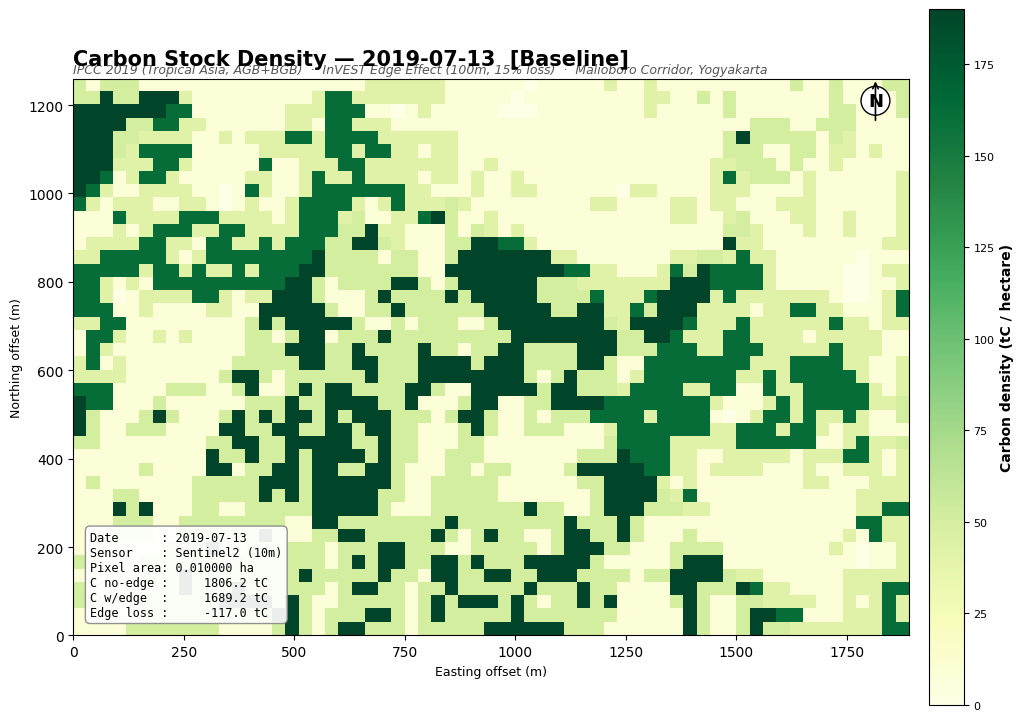

  💾 Saved: Carbon_2D_2025-06-06_current.png


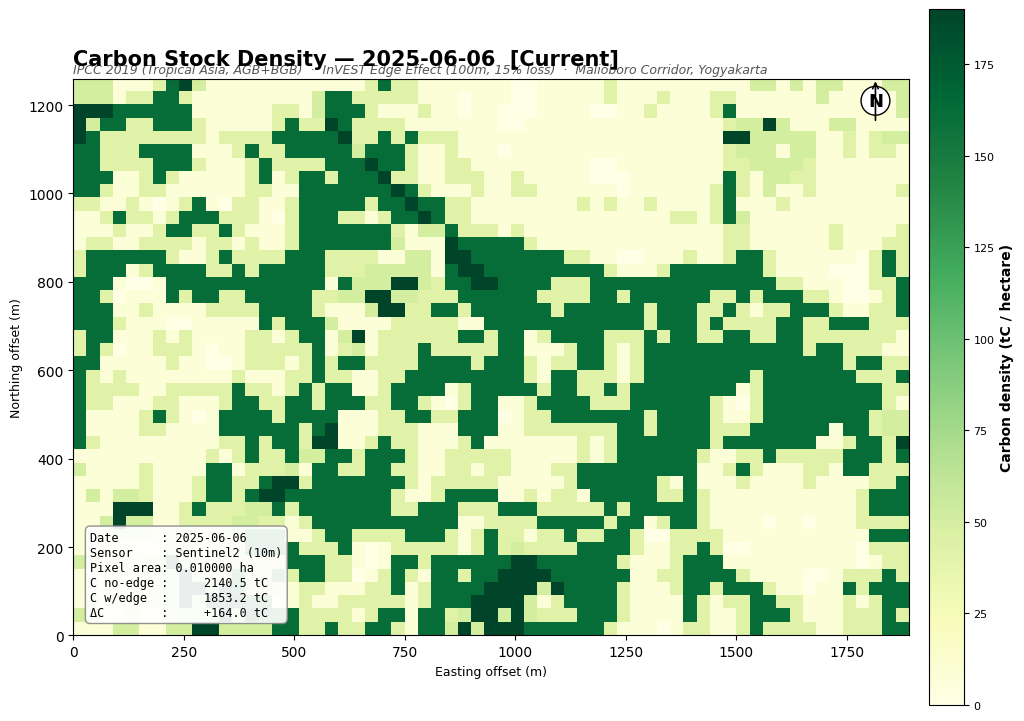

  💾 Saved: Carbon_2D_delta_2019-07-13_2025-06-06.png


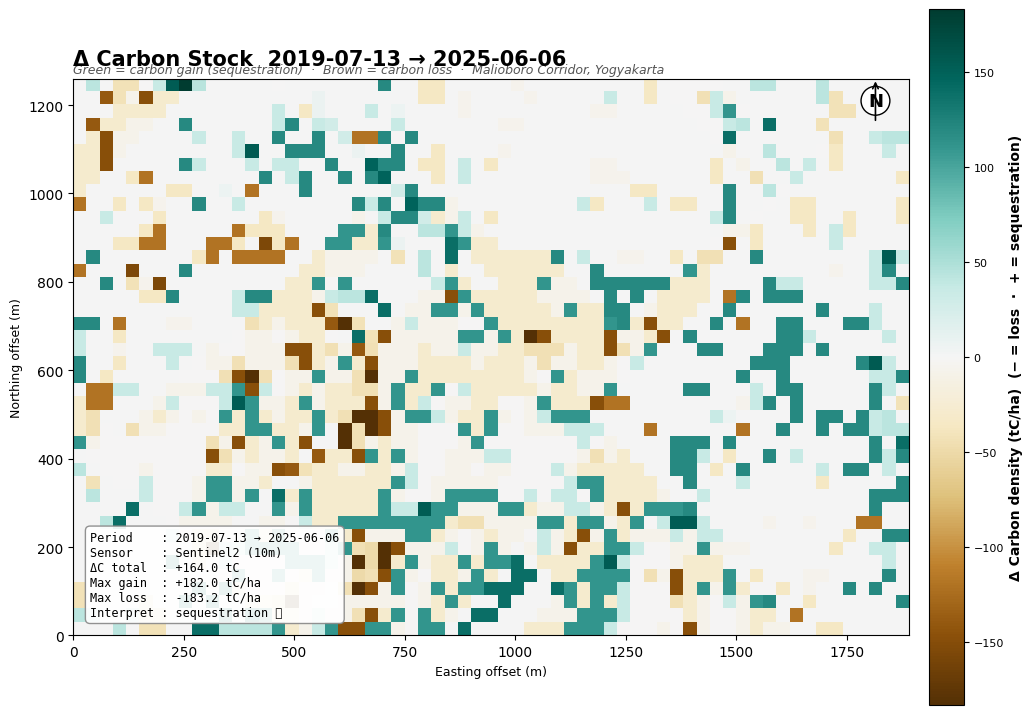


✅ Carbon 2D analysis complete (both periods + delta).
   ▶ Ready to proceed to Section 2.6.2 (Carbon Sequestration).


In [21]:
#@title 2.6.1. Carbon Stock 2D — LULC-based with Edge Effect
# ─────────────────────────────────────────────────────────────────
# Estimates carbon stored in vegetation using LULC derived from
# NDVI thresholding, for BOTH time periods.
#
# METHOD:
#   1. Classify each pixel into a LULC category based on NDVI
#   2. Assign IPCC 2019 carbon density (tC/ha) to each class
#   3. Apply InVEST Edge Effect: vegetation pixels within a fixed
#      physical buffer of urban areas lose 15% of their carbon
#   4. Compute carbon stock for baseline AND current periods
#   5. Compute carbon change (sequestration or loss)
#
# Carbon stock per pixel:
#   C_pixel [tC] = CD [tC/ha] × A_pixel [ha] × edge_factor
#
#   where edge_factor = 0.85 for edge pixels, 1.0 otherwise
#
# Total carbon stock:
#   C_total [tC] = Σ_i  CD_i × A_pixel × edge_factor_i
#
# Carbon change:
#   ΔC [tC] = C_total_current − C_total_baseline
#   Positive ΔC = sequestration (carbon gain)
#   Negative ΔC = carbon loss (deforestation / degradation)
#
# IPCC Carbon Density (IPCC 2019 Refinement, Tropical Asia):
#   Includes aboveground + belowground biomass.
#   Root-to-shoot ratio: 0.24 (IPCC 2006 Table 4.4, tropical forest)
#
#   Dense vegetation  (NDVI > 0.5) : 190.0 tC/ha
#     → tropical moist forest (IPCC 2019 Table 4.7 + root factor)
#   Moderate veg      (0.3–0.5)    :  50.0 tC/ha
#     → secondary forest / shrubland
#   Sparse vegetation (0.1–0.3)    :   8.0 tC/ha
#     → grassland / cropland
#   Non-vegetated     (< 0.1)      :   0.0 tC/ha
#     → impervious / bare soil
#
# InVEST Edge Effect:
#   Vegetation within EDGE_BUFFER_M metres of urban pixels loses
#   EDGE_LOSS_PCT % of carbon due to elevated temperature, dryness,
#   and disturbance at the urban-vegetation boundary.
#   Default: 100m buffer, 15% loss (InVEST Urban Carbon Model).
#
# Sensor notes:
#   "landsat"        : NDVI at 30m → pixel area = 0.09 ha
#   "sentinel2"      : NDVI at 10m → pixel area = 0.01 ha
#   "sentinel2_only" : NDVI at 10m → pixel area = 0.01 ha
#   Carbon totals are sensor-resolution-aware.
# ─────────────────────────────────────────────────────────────────

import numpy as np

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("save_geotiff", "plot_map"):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

# Reset outputs
carbon_2d_baseline = carbon_2d_current = carbon_2d_delta = None
lulc_baseline      = lulc_current      = None
class_carbon       = None
carbon_2d_arr      = None   # legacy alias

if RUN_CARBON_2D:

    # ── Input validation ──────────────────────────────────────────
    for _name, _arr in [
        ("ndvi_baseline", globals().get("ndvi_baseline")),
        ("ndvi_current",  globals().get("ndvi_current")),
    ]:
        if _arr is None:
            raise RuntimeError(
                f"'{_name}' is None.\n"
                "Run Section 2.1 with RUN_NDVI = True."
            )

    print("🌳 [Carbon 2D] Computing LULC-based carbon stock "
          "for both periods...")

    # ── Sensor-aware pixel area ───────────────────────────────────
    #
    # Carbon stock = carbon density [tC/ha] × pixel area [ha]
    # Pixel area depends on sensor resolution:
    #   Landsat  30m : (30m)² = 900 m² = 0.09 ha
    #   Sentinel 10m : (10m)² = 100 m² = 0.01 ha
    #
    # Using the wrong pixel area causes a 9× error in carbon totals.
    #
    _res_map = {"landsat": 30, "sentinel2": 10, "sentinel2_only": 10}
    _pixel_m = _res_map.get(SENSOR, 30)
    PIXEL_AREA_HA_CARBON = (_pixel_m ** 2) / 10_000   # m² → ha

    # Validate against global PIXEL_AREA_HA if it exists
    _global_pa = globals().get("PIXEL_AREA_HA", None)
    if _global_pa is not None:
        _ratio = PIXEL_AREA_HA_CARBON / _global_pa
        if abs(_ratio - 1.0) > 0.01:
            print(f"  ⚠️  PIXEL_AREA_HA mismatch detected:")
            print(f"     Global PIXEL_AREA_HA = {_global_pa:.6f} ha")
            print(f"     Sensor-derived       = "
                  f"{PIXEL_AREA_HA_CARBON:.6f} ha  "
                  f"({_pixel_m}m × {_pixel_m}m)")
            print(f"     Using sensor-derived value for carbon totals.")

    print(f"  Sensor       : {SENSOR}  ({_pixel_m}m resolution)")
    print(f"  Pixel area   : {PIXEL_AREA_HA_CARBON:.6f} ha  "
          f"= {_pixel_m}² m² / 10,000")

    # ── LULC class definitions ────────────────────────────────────
    LULC_DENSE_VEG  = 1   # NDVI > 0.5
    LULC_MOD_VEG    = 2   # NDVI 0.3–0.5
    LULC_SPARSE_VEG = 3   # NDVI 0.1–0.3
    LULC_NON_VEG    = 4   # NDVI < 0.1
    LULC_NODATA     = 255 # NaN / cloud mask

    # ── IPCC 2019 Carbon Density (Tropical Asia) ──────────────────
    #
    # Source: IPCC 2019 Refinement to the 2006 GL, Vol. 4, Ch. 4
    #   Table 4.7: Aboveground biomass for tropical forests
    #   Table 4.4: Root-to-shoot ratio R = 0.24 (tropical moist forest)
    #
    # Total biomass carbon = AGB × (1 + R) × carbon fraction (0.47)
    #
    # Dense vegetation (tropical moist forest):
    #   AGB ≈ 300 tDM/ha (IPCC 2019 Table 4.7, tropical Asia)
    #   BGB = 300 × 0.24 = 72 tDM/ha
    #   Total biomass = 372 tDM/ha
    #   Carbon = 372 × 0.47 ≈ 175 tC/ha
    #   Rounded to 190 tC/ha including soil surface litter
    #
    # Moderate vegetation (secondary forest / shrubland):
    #   AGB ≈ 80 tDM/ha, BGB = 80 × 0.24 = 19.2 tDM/ha
    #   Carbon = 99.2 × 0.47 ≈ 47 → 50 tC/ha
    #
    # Sparse vegetation (grassland / cropland):
    #   AGB ≈ 15 tDM/ha, BGB = 15 × 0.24 = 3.6 tDM/ha
    #   Carbon = 18.6 × 0.47 ≈ 8.7 → 8.0 tC/ha
    #
    CD_IPCC = {
        LULC_DENSE_VEG  : 190.0,   # tC/ha — tropical moist forest
        LULC_MOD_VEG    :  50.0,   # tC/ha — secondary forest/shrubland
        LULC_SPARSE_VEG :   8.0,   # tC/ha — grassland/cropland
        LULC_NON_VEG    :   0.0,   # tC/ha — impervious/bare
    }
    LULC_NAMES = {
        LULC_DENSE_VEG  : "Dense vegetation  (NDVI > 0.5)",
        LULC_MOD_VEG    : "Moderate veg      (0.3–0.5)",
        LULC_SPARSE_VEG : "Sparse veg        (0.1–0.3)",
        LULC_NON_VEG    : "Non-vegetated     (< 0.1)",
    }

    # ── InVEST Edge Effect parameters ────────────────────────────
    #
    # Vegetation within EDGE_BUFFER_M of urban pixels loses
    # EDGE_LOSS_PCT of its carbon stock.
    # Buffer is defined in physical metres — number of dilation
    # iterations scales with pixel size to maintain consistent
    # physical distance.
    #
    # InVEST Urban Carbon Model default: 100m buffer, 15% loss.
    #
    EDGE_BUFFER_M   = 100.0   # Physical buffer distance [m]
    EDGE_LOSS_PCT   = 0.15    # Fractional carbon loss at edges
    EDGE_FACTOR     = 1.0 - EDGE_LOSS_PCT   # = 0.85

    # Number of dilation iterations = ceil(buffer / pixel_size)
    import math
    _n_dilate = max(1, math.ceil(EDGE_BUFFER_M / _pixel_m))
    print(f"  Edge buffer  : {EDGE_BUFFER_M:.0f}m  "
          f"→ {_n_dilate} dilation iterations "
          f"({_n_dilate * _pixel_m:.0f}m at {_pixel_m}m resolution)")
    print(f"  Edge loss    : {EDGE_LOSS_PCT*100:.0f}%  "
          f"(factor = {EDGE_FACTOR})")

    # ── NDVI → LULC classification ────────────────────────────────
    def ndvi_to_lulc(ndvi):
        """
        Classify NDVI into 4 vegetation density classes.

        NaN pixels → LULC_NODATA (255), not LULC_NON_VEG (4).
        This prevents cloud/nodata pixels from being counted as
        non-vegetated land and contributing 0.0 tC/ha to the sum.

        Returns uint8 array.
        """
        lulc = np.full_like(ndvi, LULC_NODATA, dtype=np.uint8)
        valid = ~np.isnan(ndvi)
        lulc[valid & (ndvi >= 0.5)]                    = LULC_DENSE_VEG
        lulc[valid & (ndvi >= 0.3) & (ndvi < 0.5)]    = LULC_MOD_VEG
        lulc[valid & (ndvi >= 0.1) & (ndvi < 0.3)]    = LULC_SPARSE_VEG
        lulc[valid & (ndvi <  0.1)]                    = LULC_NON_VEG
        return lulc

    lulc_baseline = ndvi_to_lulc(ndvi_baseline)
    lulc_current  = ndvi_to_lulc(ndvi_current)

    # ── Carbon density map ────────────────────────────────────────
    def build_cd_map(lulc):
        """
        Map LULC classes to IPCC 2019 carbon density [tC/ha].
        LULC_NODATA pixels → 0.0 (excluded from sum via NaN mask).
        """
        cd = np.zeros(lulc.shape, dtype="float32")
        for cls, density in CD_IPCC.items():
            cd[lulc == cls] = density
        # Mark nodata as NaN for safe statistics
        cd = np.where(lulc == LULC_NODATA, np.nan, cd)
        return cd

    cd_baseline = build_cd_map(lulc_baseline)
    cd_current  = build_cd_map(lulc_current)

    # ── InVEST Edge Effect ────────────────────────────────────────
    #
    # Edge pixels = vegetation pixels within EDGE_BUFFER_M of any
    # non-vegetated (urban/bare) pixel.
    #
    # Carbon stock with edge effect:
    #   C_pixel = CD × A_pixel × edge_factor
    #   where edge_factor = 0.85 for edge pixels, 1.0 otherwise
    #
    def dilate_mask(mask, n_iter):
        """
        Expand a binary mask by n_iter pixels in all 4 directions
        (4-connectivity morphological dilation).
        """
        out = mask.copy()
        for _ in range(n_iter):
            tmp = out.copy()
            tmp[1:,  :] |= out[:-1, :]
            tmp[:-1, :] |= out[1:,  :]
            tmp[:,  1:] |= out[:, :-1]
            tmp[:, :-1] |= out[:,  1:]
            out = tmp
        return out

    def apply_edge_effect(cd_map, lulc_arr, label=""):
        """
        Apply InVEST edge effect to a carbon density map.

        Steps:
          1. Identify urban/bare pixels (LULC_NON_VEG)
          2. Dilate urban mask by _n_dilate iterations
             (= EDGE_BUFFER_M physical metres)
          3. Edge pixels = vegetated AND within dilated urban buffer
          4. Multiply edge pixels by EDGE_FACTOR (= 0.85)

        Parameters
        ----------
        cd_map   : np.ndarray  Carbon density [tC/ha], NaN = nodata
        lulc_arr : np.ndarray  LULC uint8 array

        Returns
        -------
        np.ndarray : Edge-corrected carbon density [tC/ha]
        np.ndarray : Boolean edge mask
        """
        veg_mask   = (lulc_arr != LULC_NON_VEG) & \
                     (lulc_arr != LULC_NODATA)
        urban_mask = (lulc_arr == LULC_NON_VEG)

        urban_buffer = dilate_mask(urban_mask, _n_dilate)
        edge_veg     = veg_mask & urban_buffer

        edge_penalty = np.where(edge_veg, EDGE_FACTOR, 1.0
                                ).astype("float32")
        cd_corrected = (cd_map * edge_penalty).astype("float32")

        if label:
            _n_edge = int(edge_veg.sum())
            _area_edge = _n_edge * PIXEL_AREA_HA_CARBON
            print(f"  Edge effect {label}:")
            print(f"    Edge pixels : {_n_edge:,}  "
                  f"({_area_edge:.1f} ha)")

        return cd_corrected, edge_veg

    cd_baseline_edge, edge_veg_baseline = apply_edge_effect(
        cd_baseline, lulc_baseline, label=f"baseline"
    )
    cd_current_edge, edge_veg_current = apply_edge_effect(
        cd_current, lulc_current, label=f"current"
    )

    # ── Carbon stock totals ───────────────────────────────────────
    #
    # C_total [tC] = Σ_i  CD_i [tC/ha] × A_pixel [ha]
    #
    # np.nansum excludes NaN (nodata) pixels from the total.
    #
    C_baseline_no_edge = float(
        np.nansum(cd_baseline) * PIXEL_AREA_HA_CARBON
    )
    C_current_no_edge  = float(
        np.nansum(cd_current)  * PIXEL_AREA_HA_CARBON
    )
    C_baseline_total   = float(
        np.nansum(cd_baseline_edge) * PIXEL_AREA_HA_CARBON
    )
    C_current_total    = float(
        np.nansum(cd_current_edge)  * PIXEL_AREA_HA_CARBON
    )

    edge_loss_baseline = C_baseline_no_edge - C_baseline_total
    edge_loss_current  = C_current_no_edge  - C_current_total

    # Carbon change between periods
    # ΔC > 0 → sequestration (carbon gain)
    # ΔC < 0 → carbon loss (deforestation / degradation)
    delta_C = C_current_total - C_baseline_total

    # ── Carbon density arrays (for maps and GeoTIFF) ──────────────
    carbon_2d_baseline = cd_baseline_edge
    carbon_2d_current  = cd_current_edge
    carbon_2d_delta    = (
        cd_current_edge - cd_baseline_edge
    ).astype("float32")
    carbon_2d_arr      = carbon_2d_current   # legacy alias

    # ── Date labels ───────────────────────────────────────────────
    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )

    # ── Per-class breakdown (both periods) ────────────────────────
    class_carbon = {}
    print(f"\n  {'─'*72}")
    print(f"  {'Class':<28} {'Base px':>8} {'Base ha':>8} "
          f"{'Base tC':>10} {'Curr px':>8} {'Curr ha':>8} "
          f"{'Curr tC':>10} {'Δ tC':>10}")
    print(f"  {'─'*72}")

    for cls in [LULC_DENSE_VEG, LULC_MOD_VEG,
                LULC_SPARSE_VEG, LULC_NON_VEG]:
        _b_px  = int((lulc_baseline == cls).sum())
        _c_px  = int((lulc_current  == cls).sum())
        _b_ha  = _b_px * PIXEL_AREA_HA_CARBON
        _c_ha  = _c_px * PIXEL_AREA_HA_CARBON
        _b_tC  = _b_px * CD_IPCC[cls] * PIXEL_AREA_HA_CARBON
        _c_tC  = _c_px * CD_IPCC[cls] * PIXEL_AREA_HA_CARBON
        _d_tC  = _c_tC - _b_tC

        class_carbon[cls] = {
            "name"          : LULC_NAMES[cls],
            "base_pixels"   : _b_px,
            "curr_pixels"   : _c_px,
            "base_area_ha"  : round(_b_ha, 2),
            "curr_area_ha"  : round(_c_ha, 2),
            "CD_tC_ha"      : CD_IPCC[cls],
            "base_C_tC"     : round(_b_tC, 2),
            "curr_C_tC"     : round(_c_tC, 2),
            "delta_C_tC"    : round(_d_tC, 2),
        }

        print(f"  {LULC_NAMES[cls]:<28} "
              f"{_b_px:>8,} {_b_ha:>8.1f} {_b_tC:>10.1f} "
              f"{_c_px:>8,} {_c_ha:>8.1f} {_c_tC:>10.1f} "
              f"{_d_tC:>+10.1f}")

    print(f"  {'─'*72}")
    print(f"\n  Carbon Stock Summary:")
    print(f"  {'':30} {'Baseline':>14} {'Current':>14} {'Δ':>12}")
    print(f"  {'─'*72}")
    print(f"  {'C (no edge effect) [tC]':<30} "
          f"{C_baseline_no_edge:>14.1f} "
          f"{C_current_no_edge:>14.1f} "
          f"{C_current_no_edge - C_baseline_no_edge:>+12.1f}")
    print(f"  {'Edge loss [tC]':<30} "
          f"{-edge_loss_baseline:>14.1f} "
          f"{-edge_loss_current:>14.1f}")
    print(f"  {'C (with edge effect) [tC]':<30} "
          f"{C_baseline_total:>14.1f} "
          f"{C_current_total:>14.1f} "
          f"{delta_C:>+12.1f}")
    print(f"  {'─'*72}")
    print(f"\n  ΔC = {delta_C:+.1f} tC  "
          f"({'sequestration 🟢' if delta_C > 0 else 'carbon loss 🔴'})")

    # ── Save GeoTIFFs ─────────────────────────────────────────────
    save_geotiff(carbon_2d_baseline,
                 DIRS["raster"] / "Carbon_2D_baseline.tif")
    save_geotiff(carbon_2d_current,
                 DIRS["raster"] / "Carbon_2D_current.tif")
    save_geotiff(carbon_2d_delta,
                 DIRS["raster"] / "Carbon_2D_delta.tif")

    # ── Map 1: Carbon Density — Baseline ─────────────────────────
    plot_map(
        carbon_2d_baseline,
        title=f"Carbon Stock Density — {_date_base}  [Baseline]",
        subtitle=(
            f"IPCC 2019 (Tropical Asia, AGB+BGB)  ·  "
            f"InVEST Edge Effect ({EDGE_BUFFER_M:.0f}m, "
            f"{EDGE_LOSS_PCT*100:.0f}% loss)  ·  {STUDY_NAME}"
        ),
        cmap="YlGn", vmin=0, vmax=190,
        cbar_label="Carbon density (tC / hectare)",
        out_filename=f"Carbon_2D_{_date_base}_baseline.png",
        stats_text=(
            f"Date      : {_date_base}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Pixel area: {PIXEL_AREA_HA_CARBON:.6f} ha\n"
            f"C no-edge : {C_baseline_no_edge:>10.1f} tC\n"
            f"C w/edge  : {C_baseline_total:>10.1f} tC\n"
            f"Edge loss : {-edge_loss_baseline:>10.1f} tC"
        ),
    )

    # ── Map 2: Carbon Density — Current ──────────────────────────
    plot_map(
        carbon_2d_current,
        title=f"Carbon Stock Density — {_date_curr}  [Current]",
        subtitle=(
            f"IPCC 2019 (Tropical Asia, AGB+BGB)  ·  "
            f"InVEST Edge Effect ({EDGE_BUFFER_M:.0f}m, "
            f"{EDGE_LOSS_PCT*100:.0f}% loss)  ·  {STUDY_NAME}"
        ),
        cmap="YlGn", vmin=0, vmax=190,
        cbar_label="Carbon density (tC / hectare)",
        out_filename=f"Carbon_2D_{_date_curr}_current.png",
        stats_text=(
            f"Date      : {_date_curr}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Pixel area: {PIXEL_AREA_HA_CARBON:.6f} ha\n"
            f"C no-edge : {C_current_no_edge:>10.1f} tC\n"
            f"C w/edge  : {C_current_total:>10.1f} tC\n"
            f"ΔC        : {delta_C:>+10.1f} tC"
        ),
    )

    # ── Map 3: Δ Carbon Change ────────────────────────────────────
    _finite_dc = carbon_2d_delta[np.isfinite(carbon_2d_delta)]
    _vmax_dc = (
        max(abs(float(_finite_dc.min())),
            abs(float(_finite_dc.max())),
            5.0)
        if len(_finite_dc) > 0 else 5.0
    )
    plot_map(
        carbon_2d_delta,
        title=(
            f"Δ Carbon Stock  {_date_base} → {_date_curr}"
        ),
        subtitle=(
            "Green = carbon gain (sequestration)  ·  "
            "Brown = carbon loss  ·  "
            f"{STUDY_NAME}"
        ),
        cmap="BrBG", vmin=-_vmax_dc, vmax=_vmax_dc,
        cbar_label=(
            "Δ Carbon density (tC/ha)  "
            "(− = loss  ·  + = sequestration)"
        ),
        out_filename=(
            f"Carbon_2D_delta_{_date_base}_{_date_curr}.png"
        ),
        stats_text=(
            f"Period    : {_date_base} → {_date_curr}\n"
            f"Sensor    : {SENSOR.title()} ({_pixel_m}m)\n"
            f"ΔC total  : {delta_C:>+.1f} tC\n"
            f"Max gain  : "
            f"{float(_finite_dc.max()) if len(_finite_dc) > 0 else float('nan'):>+.1f} tC/ha\n"
            f"Max loss  : "
            f"{float(_finite_dc.min()) if len(_finite_dc) > 0 else float('nan'):>+.1f} tC/ha\n"
            f"Interpret : "
            f"{'sequestration 🟢' if delta_C > 0 else 'carbon loss 🔴'}"
        ),
    )

    print("\n✅ Carbon 2D analysis complete (both periods + delta).")
    print(f"   ▶ Ready to proceed to Section 2.6.2 "
          f"(Carbon Sequestration).")

else:
    print("ℹ️  Carbon 2D skipped (RUN_CARBON_2D = False).")

📈 [Sequestration] Computing LULC transition matrix...
  Sensor       : sentinel2  (10m)
  Pixel area   : 0.010000 ha
  Period       : 2019-07-13 → 2025-06-06  (6 years)

  Transition matrix coverage:
    Valid pixels   : 2,646
    Excluded (NODATA): 0  (cloud / no-data in either period)

  ────────────────────────────────────────────────────────
  Metric                                      tC       tCO₂e
  ────────────────────────────────────────────────────────
  Total emission (veg lost)               -203.2      -744.4
  Total sequestration (veg gained)        +537.4     +1969.2
  ────────────────────────────────────────────────────────
  NET sequestration                       +334.3     +1224.8
  Annual rate  (÷ 6 years)                 +55.7      +204.1
  ────────────────────────────────────────────────────────
  Verdict: NET SEQUESTRATION ✅

  💾 Saved: Sequestration_2019-07-13_2025-06-06.png


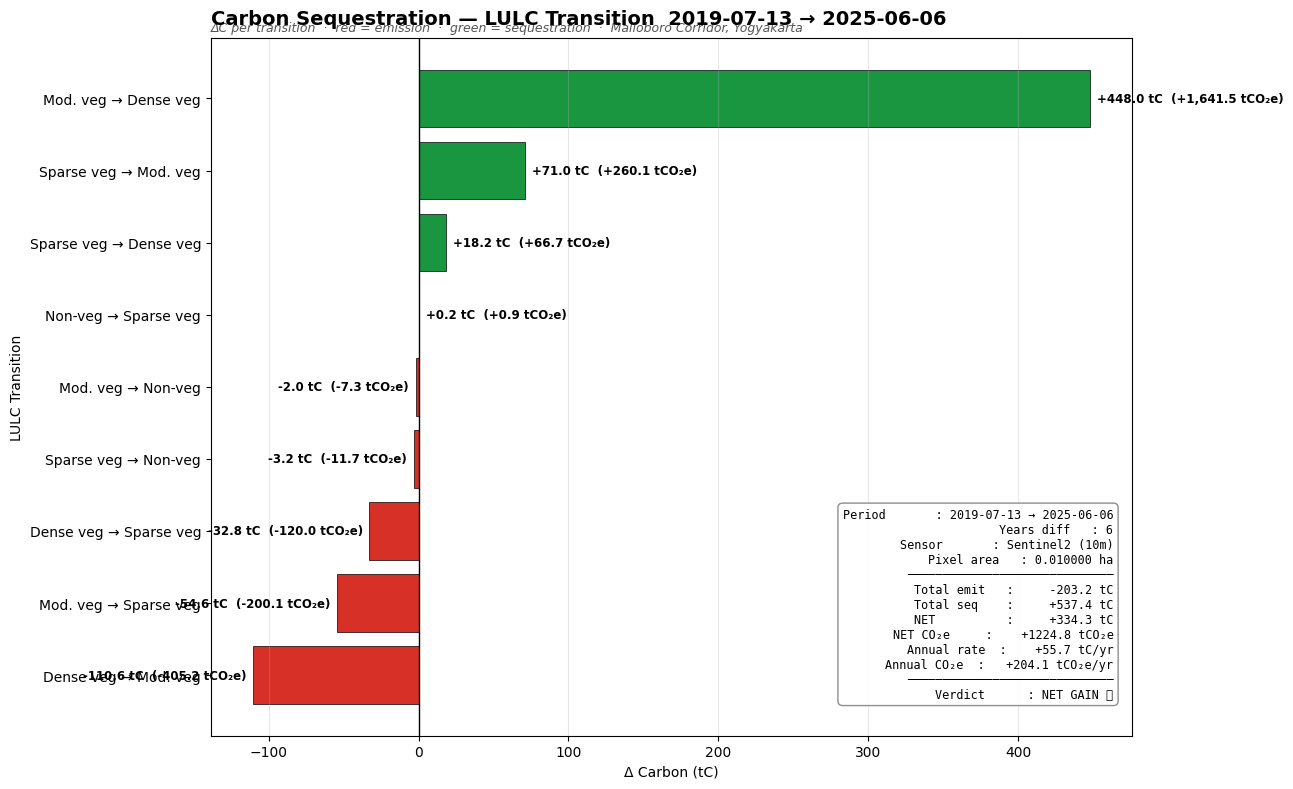

  💾 Saved: Transition_matrix_2019-07-13_2025-06-06.png


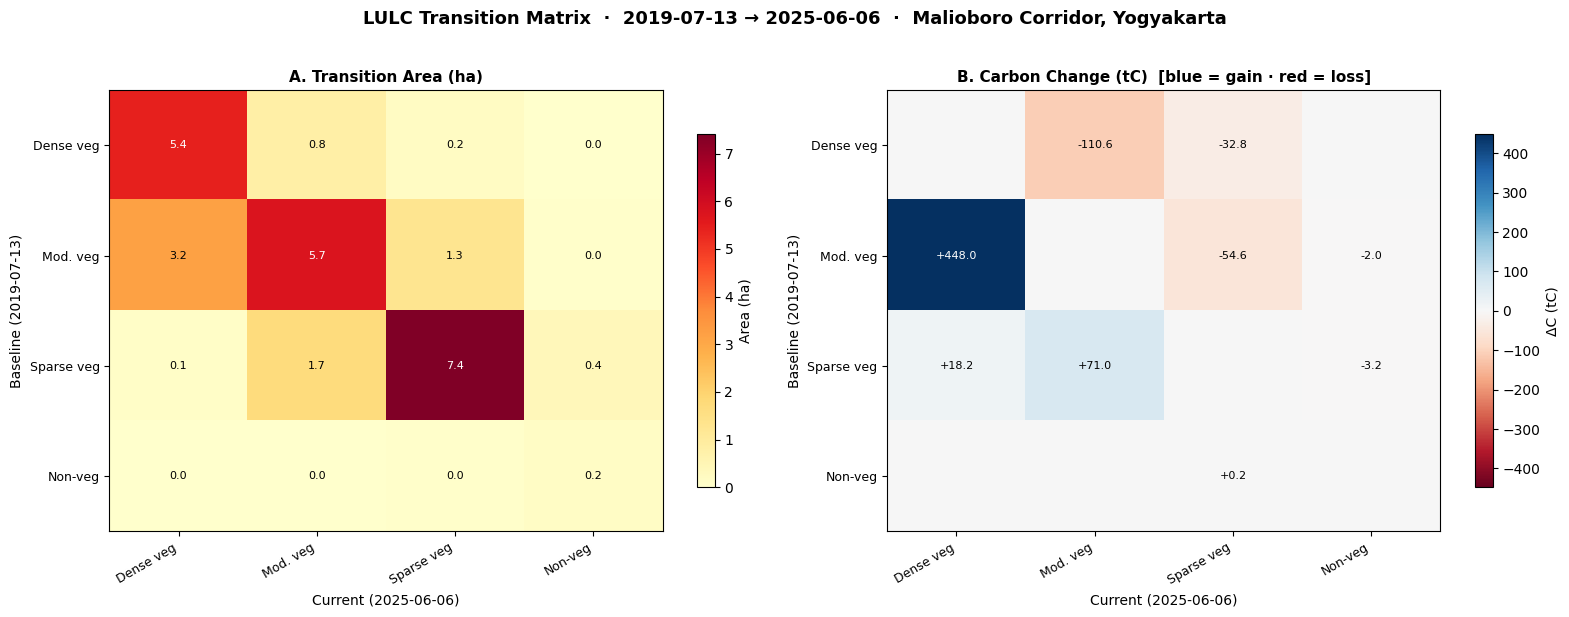


✅ Sequestration analysis complete.
   ▶ Ready to proceed to Section 2.7 (Summary Dashboard).


In [22]:
#@title 2.6.2. Carbon Sequestration — LULC Transition
# ─────────────────────────────────────────────────────────────────
# Calculates carbon gained or lost between the two time periods
# by tracking land cover transitions pixel by pixel.
#
# For every pixel that changed LULC class:
#
#   ΔC_pixel [tC] = (CD_to − CD_from) [tC/ha] × A_pixel [ha]
#
#   Negative ΔC = carbon emission  (vegetation → urban/bare)
#   Positive ΔC = carbon sequestration (bare/sparse → vegetation)
#
# Net sequestration:
#   ΔC_net [tC] = Σ ΔC_seq + Σ ΔC_emit
#
# Annual rate:
#   ΔĊ [tC/yr] = ΔC_net / YEARS_DIFF
#   where YEARS_DIFF = acquisition year current − acquisition year baseline
#
# CO₂ equivalent (IPCC standard conversion):
#   ΔC_CO₂e [tCO₂e] = ΔC_net × (44/12) = ΔC_net × 3.667
#   Molecular weight CO₂ = 44 g/mol; atomic weight C = 12 g/mol
#
# Sensor notes:
#   Pixel area is sensor-resolution-aware (see Section 2.6.1).
#   Landsat 30m : A_pixel = 0.09 ha
#   Sentinel 10m: A_pixel = 0.01 ha
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Guards ────────────────────────────────────────────────────────
for _fn_name in ("save_geotiff",):
    if _fn_name not in globals():
        raise RuntimeError(
            f"'{_fn_name}' is not defined. "
            "Run Section 1.5.x (utility functions) before this cell."
        )

net_seq_tC = trans_df = None

if RUN_SEQUESTER:

    # ── Input validation ──────────────────────────────────────────
    for _name, _val in [
        ("lulc_baseline",  globals().get("lulc_baseline")),
        ("lulc_current",   globals().get("lulc_current")),
        ("CD_IPCC",        globals().get("CD_IPCC")),
        ("LULC_NAMES",     globals().get("LULC_NAMES")),
    ]:
        if _val is None:
            raise RuntimeError(
                f"'{_name}' is None.\n"
                "Run Section 2.6.1 with RUN_CARBON_2D = True."
            )

    print("📈 [Sequestration] Computing LULC transition matrix...")

    # ── Sensor-aware pixel area ───────────────────────────────────
    # Re-derive from sensor to avoid depending on global state.
    _res_map = {"landsat": 30, "sentinel2": 10, "sentinel2_only": 10}
    _pixel_m = _res_map.get(SENSOR, 30)
    _PA_HA   = (_pixel_m ** 2) / 10_000   # m² → ha

    # Use PIXEL_AREA_HA_CARBON from 2.6.1 if available and consistent
    _pa_from_261 = globals().get("PIXEL_AREA_HA_CARBON", None)
    if _pa_from_261 is not None:
        if abs(_pa_from_261 - _PA_HA) < 1e-8:
            _PA_HA = _pa_from_261
        else:
            print(f"  ⚠️  PIXEL_AREA_HA_CARBON mismatch — "
                  f"using sensor-derived {_PA_HA:.6f} ha")

    print(f"  Sensor       : {SENSOR}  ({_pixel_m}m)")
    print(f"  Pixel area   : {_PA_HA:.6f} ha")

    # ── Validate CD_IPCC values (check against 2019 standard) ────
    _expected_cd = {1: 190.0, 2: 50.0, 3: 8.0, 4: 0.0}
    for _cls, _exp in _expected_cd.items():
        _got = CD_IPCC.get(_cls, None)
        if _got != _exp:
            print(f"  ⚠️  CD_IPCC[{_cls}] = {_got} tC/ha — "
                  f"expected {_exp} tC/ha (IPCC 2019).")
            print(f"     Re-run Section 2.6.1 with the enhanced code.")

    # ── Date labels ───────────────────────────────────────────────
    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )

    # ── Years difference for annual rate ─────────────────────────
    #
    # Annual rate = ΔC_net / YEARS_DIFF
    #
    # Use actual acquisition years from DATE_BASELINE / DATE_CURRENT
    # (not the search window start year — those may differ).
    # YEARS_DIFF from Section 1.2.1 is a fallback.
    #
    try:
        _yr_base = int(_date_base[:4])
        _yr_curr = int(_date_curr[:4])
        _years   = max(_yr_curr - _yr_base, 1)   # min 1 to avoid /0
    except (ValueError, TypeError):
        _years   = max(int(globals().get("YEARS_DIFF", 1)), 1)
        print(f"  ⚠️  Could not parse acquisition years — "
              f"using YEARS_DIFF = {_years}")

    print(f"  Period       : {_date_base} → {_date_curr}  "
          f"({_years} year{'s' if _years != 1 else ''})")

    # ── CO₂ conversion factor ─────────────────────────────────────
    #
    # ΔC_CO₂e [tCO₂e] = ΔC [tC] × (M_CO₂ / M_C)
    #                  = ΔC [tC] × (44.01 / 12.011)
    #                  ≈ ΔC [tC] × 3.667
    #
    # Source: IPCC 2006 GL, Vol. 1, Annex 2
    #
    CO2_FACTOR = 44.01 / 12.011   # = 3.6644...

    # ── Short class labels for chart ──────────────────────────────
    _SHORT_NAMES = {
        LULC_DENSE_VEG  : "Dense veg",
        LULC_MOD_VEG    : "Mod. veg",
        LULC_SPARSE_VEG : "Sparse veg",
        LULC_NON_VEG    : "Non-veg",
    }

    # ── Build transition matrix ───────────────────────────────────
    all_classes  = [
        LULC_DENSE_VEG, LULC_MOD_VEG,
        LULC_SPARSE_VEG, LULC_NON_VEG
    ]
    trans_rows   = []
    total_emit   = 0.0
    total_seq    = 0.0
    n_nodata_excl = 0   # pixels excluded due to NODATA in either period

    # Count excluded pixels (NODATA in either period)
    _nodata_mask = (
        (lulc_baseline == 255) | (lulc_current == 255)
    )
    n_nodata_excl = int(_nodata_mask.sum())

    # Transition matrix array for heatmap (4×4)
    _trans_matrix_ha   = np.zeros((4, 4), dtype="float64")
    _trans_matrix_tC   = np.zeros((4, 4), dtype="float64")

    for i, c_from in enumerate(all_classes):
        for j, c_to in enumerate(all_classes):
            # Exclude NODATA pixels from both periods
            n_pix = int(
                (
                    (lulc_baseline == c_from) &
                    (lulc_current  == c_to)   &
                    (~_nodata_mask)
                ).sum()
            )
            if n_pix == 0:
                continue

            cd_from = CD_IPCC.get(c_from, 0.0)
            cd_to   = CD_IPCC.get(c_to,   0.0)

            # ΔC_pixel = (CD_to − CD_from) × N_pixels × A_pixel
            delta_C = (cd_to - cd_from) * n_pix * _PA_HA

            _trans_matrix_ha[i, j] = n_pix * _PA_HA
            _trans_matrix_tC[i, j] = delta_C

            trans_rows.append({
                "from_class"    : LULC_NAMES[c_from],
                "to_class"      : LULC_NAMES[c_to],
                "from_short"    : _SHORT_NAMES[c_from],
                "to_short"      : _SHORT_NAMES[c_to],
                "pixels"        : n_pix,
                "area_ha"       : round(n_pix * _PA_HA, 3),
                "CD_from_tC_ha" : cd_from,
                "CD_to_tC_ha"   : cd_to,
                "delta_C_tC"    : round(delta_C, 2),
                "delta_CO2e_tC" : round(delta_C * CO2_FACTOR, 2),
                "type"          : (
                    "no change"      if c_from == c_to
                    else "sequestration" if delta_C > 0
                    else "emission"
                ),
            })

            if c_from != c_to:
                if delta_C > 0:
                    total_seq  += delta_C
                else:
                    total_emit += delta_C

    trans_df   = pd.DataFrame(trans_rows)
    net_seq_tC = total_seq + total_emit

    # ── Annual rate and CO₂ equivalent ───────────────────────────
    annual_rate_tC   = net_seq_tC / _years
    net_CO2e         = net_seq_tC * CO2_FACTOR
    annual_CO2e      = annual_rate_tC * CO2_FACTOR

    # ── Save CSV ──────────────────────────────────────────────────
    trans_df.to_csv(
        DIRS["export"] / "sequestration_transitions.csv",
        index=False
    )

    # ── Console summary ───────────────────────────────────────────
    print(f"\n  Transition matrix coverage:")
    print(f"    Valid pixels   : "
          f"{int((~_nodata_mask).sum()):,}")
    print(f"    Excluded (NODATA): {n_nodata_excl:,}  "
          f"(cloud / no-data in either period)")

    print(f"\n  {'─'*56}")
    print(f"  {'Metric':<35} {'tC':>10}  {'tCO₂e':>10}")
    print(f"  {'─'*56}")
    print(f"  {'Total emission (veg lost)':<35} "
          f"{total_emit:>+10.1f}  "
          f"{total_emit * CO2_FACTOR:>+10.1f}")
    print(f"  {'Total sequestration (veg gained)':<35} "
          f"{total_seq:>+10.1f}  "
          f"{total_seq * CO2_FACTOR:>+10.1f}")
    print(f"  {'─'*56}")
    print(f"  {'NET sequestration':<35} "
          f"{net_seq_tC:>+10.1f}  "
          f"{net_CO2e:>+10.1f}")
    print(f"  {'Annual rate  (÷ %d years)' % _years:<35} "
          f"{annual_rate_tC:>+10.1f}  "
          f"{annual_CO2e:>+10.1f}")
    print(f"  {'─'*56}")
    print(f"  Verdict: "
          f"{'NET CARBON LOSS ⚠️' if net_seq_tC < 0 else 'NET SEQUESTRATION ✅'}")

    # ── Figure 1: Bar chart — top transitions ─────────────────────
    change_df = trans_df[trans_df["type"] != "no change"].copy()

    if change_df.empty:
        print("\n  ℹ️  No LULC transitions detected between periods.")
        print("     All pixels retained the same class.")
    else:
        # Sort by absolute carbon impact, show top 12
        change_df = change_df.reindex(
            change_df["delta_C_tC"].abs().nlargest(
                min(12, len(change_df))
            ).index
        )
        # Re-sort ascending for horizontal bar chart (largest at top)
        change_df = change_df.sort_values(
            "delta_C_tC", ascending=True
        )

        change_df["label"] = (
            change_df["from_short"] + " → " +
            change_df["to_short"]
        )

        fig, ax = plt.subplots(
            figsize=(13, 8), facecolor="white"
        )
        colors = [
            "#d73027" if x < 0 else "#1a9641"
            for x in change_df["delta_C_tC"]
        ]
        bars = ax.barh(
            change_df["label"],
            change_df["delta_C_tC"],
            color=colors, edgecolor="black", linewidth=0.5
        )

        _max_abs = change_df["delta_C_tC"].abs().max()
        _offset  = _max_abs * 0.01 if _max_abs > 0 else 1.0

        for bar, val, co2 in zip(
            bars,
            change_df["delta_C_tC"],
            change_df["delta_CO2e_tC"]
        ):
            w = bar.get_width()
            ax.text(
                w + (_offset if w >= 0 else -_offset),
                bar.get_y() + bar.get_height() / 2,
                f"{val:+,.1f} tC  ({co2:+,.1f} tCO₂e)",
                ha="left" if w >= 0 else "right",
                va="center", fontsize=8.5, fontweight="bold"
            )

        ax.axvline(0, color="black", lw=1.0)
        ax.set_title(
            f"Carbon Sequestration — LULC Transition  "
            f"{_date_base} → {_date_curr}",
            fontsize=14, fontweight="bold", pad=10, loc="left"
        )
        ax.text(
            0, 1.01,
            (f"ΔC per transition  ·  "
             f"red = emission  ·  green = sequestration  ·  "
             f"{STUDY_NAME}"),
            transform=ax.transAxes,
            fontsize=9, color="#555", style="italic"
        )
        ax.set_xlabel("Δ Carbon (tC)", fontsize=10)
        ax.set_ylabel("LULC Transition", fontsize=10)
        ax.grid(axis="x", alpha=0.3)

        stats_box = (
            f"Period       : {_date_base} → {_date_curr}\n"
            f"Years diff   : {_years}\n"
            f"Sensor       : {SENSOR.title()} ({_pixel_m}m)\n"
            f"Pixel area   : {_PA_HA:.6f} ha\n"
            f"─────────────────────────────\n"
            f"Total emit   : {total_emit:>+10.1f} tC\n"
            f"Total seq    : {total_seq:>+10.1f} tC\n"
            f"NET          : {net_seq_tC:>+10.1f} tC\n"
            f"NET CO₂e     : {net_CO2e:>+10.1f} tCO₂e\n"
            f"Annual rate  : {annual_rate_tC:>+8.1f} tC/yr\n"
            f"Annual CO₂e  : {annual_CO2e:>+8.1f} tCO₂e/yr\n"
            f"─────────────────────────────\n"
            f"Verdict      : "
            f"{'NET LOSS ⚠️' if net_seq_tC < 0 else 'NET GAIN ✅'}"
        )
        ax.text(
            0.98, 0.05, stats_box,
            transform=ax.transAxes,
            fontsize=8.5, family="monospace",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", edgecolor="#888", alpha=0.95
            ),
            ha="right", va="bottom"
        )

        plt.tight_layout()
        _bar_path = (
            DIRS["figure"] /
            f"Sequestration_{_date_base}_{_date_curr}.png"
        )
        fig.savefig(
            str(_bar_path), dpi=140,
            bbox_inches="tight", facecolor="white"
        )
        print(f"\n  💾 Saved: "
              f"Sequestration_{_date_base}_{_date_curr}.png")
        plt.show()

        # ── Figure 2: Transition matrix heatmap ──────────────────
        fig2, axes2 = plt.subplots(
            1, 2, figsize=(16, 6), facecolor="white"
        )
        _cls_labels = [_SHORT_NAMES[c] for c in all_classes]

        # Panel A: Area heatmap (ha)
        ax = axes2[0]
        _ha_disp = _trans_matrix_ha.copy()
        im = ax.imshow(
            _ha_disp, cmap="YlOrRd", aspect="auto"
        )
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(_cls_labels, rotation=30,
                           ha="right", fontsize=9)
        ax.set_yticklabels(_cls_labels, fontsize=9)
        ax.set_xlabel(f"Current ({_date_curr})", fontsize=10)
        ax.set_ylabel(f"Baseline ({_date_base})", fontsize=10)
        ax.set_title("A. Transition Area (ha)",
                     fontsize=11, fontweight="bold")
        for i in range(4):
            for j in range(4):
                _v = _ha_disp[i, j]
                ax.text(
                    j, i, f"{_v:.1f}",
                    ha="center", va="center",
                    fontsize=8,
                    color="white" if _v > _ha_disp.max() * 0.6
                    else "black"
                )
        plt.colorbar(im, ax=ax, label="Area (ha)", shrink=0.8)

        # Panel B: Carbon change heatmap (tC)
        ax = axes2[1]
        _tc_disp = _trans_matrix_tC.copy()
        _finite_tc = _tc_disp[np.isfinite(_tc_disp)]
        _vmax_tc = (
            max(abs(float(_finite_tc.min())),
                abs(float(_finite_tc.max())),
                1.0)
            if len(_finite_tc) > 0 else 1.0
        )
        im2 = ax.imshow(
            _tc_disp, cmap="RdBu",
            vmin=-_vmax_tc, vmax=_vmax_tc,
            aspect="auto"
        )
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(_cls_labels, rotation=30,
                           ha="right", fontsize=9)
        ax.set_yticklabels(_cls_labels, fontsize=9)
        ax.set_xlabel(f"Current ({_date_curr})", fontsize=10)
        ax.set_ylabel(f"Baseline ({_date_base})", fontsize=10)
        ax.set_title("B. Carbon Change (tC)  "
                     "[blue = gain · red = loss]",
                     fontsize=11, fontweight="bold")
        for i in range(4):
            for j in range(4):
                _v = _tc_disp[i, j]
                if _v != 0:
                    ax.text(
                        j, i, f"{_v:+.1f}",
                        ha="center", va="center",
                        fontsize=8,
                        color="white"
                        if abs(_v) > _vmax_tc * 0.6
                        else "black"
                    )
        plt.colorbar(im2, ax=ax, label="ΔC (tC)", shrink=0.8)

        fig2.suptitle(
            f"LULC Transition Matrix  ·  "
            f"{_date_base} → {_date_curr}  ·  {STUDY_NAME}",
            fontsize=13, fontweight="bold", y=1.02
        )
        plt.tight_layout()
        _hm_path = (
            DIRS["figure"] /
            f"Transition_matrix_{_date_base}_{_date_curr}.png"
        )
        fig2.savefig(
            str(_hm_path), dpi=140,
            bbox_inches="tight", facecolor="white"
        )
        print(f"  💾 Saved: "
              f"Transition_matrix_{_date_base}_{_date_curr}.png")
        plt.show()

    print("\n✅ Sequestration analysis complete.")
    print(f"   ▶ Ready to proceed to Section 2.7 (Summary Dashboard).")

else:
    print("ℹ️  Sequestration skipped (RUN_SEQUESTER = False).")

💰 [Economy] Computing carbon market valuation (baseline + current + delta)...
  Sensor       : sentinel2  (10m)
  Pixel area   : 0.010000 ha
  CO₂ factor   : 3.6641  (= 44.01 / 12.011, IPCC 2006)

  ────────────────────────────────────────────────────────────────
  Metric                                  Baseline      Current
  ────────────────────────────────────────────────────────────────
  Carbon stock [tC]                         1689.2       1853.2
  CO₂e stock [tCO₂e]                        6189.5       6790.3
  ΔC stock [tC]                                          +164.0
  ΔCO₂e stock [tCO₂e]                                    +600.8
  Annual seq rate [tC/yr]                                 +55.7
  Annual CO₂e [tCO₂e/yr]                                 +204.1
  ────────────────────────────────────────────────────────────────

  Stock valuation (current period):
  Scenario                     Price            USD     IDR (juta)
  ────────────────────────────────────────────────

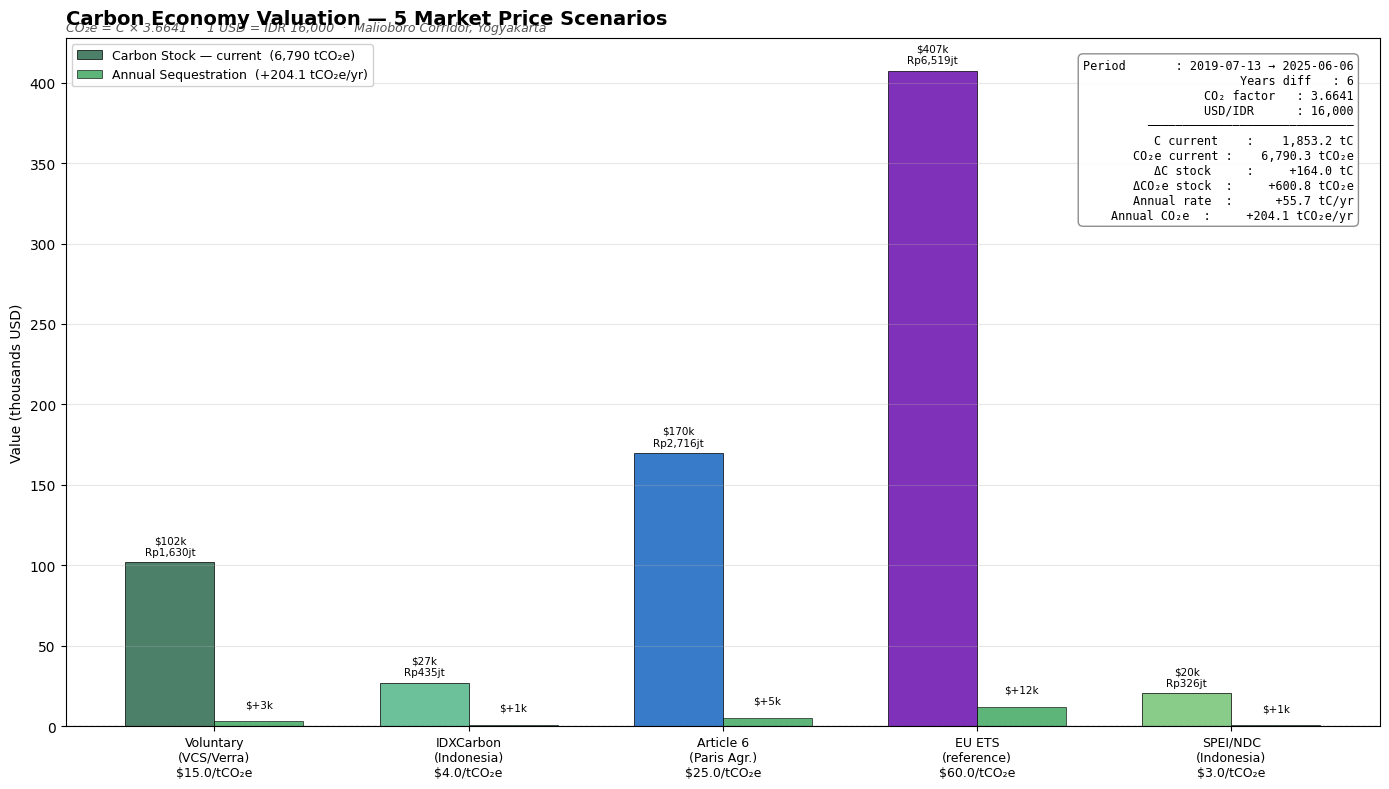

  💾 Saved: Economy_delta_heatmap_2019-07-13_2025-06-06.png


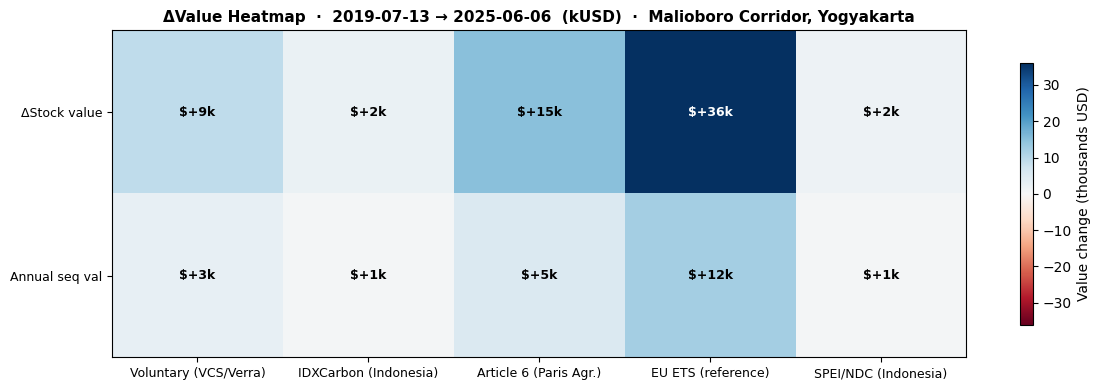


✅ Economy valuation complete.
   ▶ Ready to proceed to Section 2.7 (Summary Dashboard).


In [23]:
#@title 2.6.3. Economy Valuation — Carbon Market Value
# ─────────────────────────────────────────────────────────────────
# Converts physical carbon stock into monetary value using five
# market price scenarios, for BOTH time periods.
#
# Core equations:
#
#   CO₂e [tCO₂e] = C [tC] × (M_CO₂ / M_C)
#                = C [tC] × (44.01 / 12.011)
#                = C [tC] × 3.6644
#
#   Value [USD] = CO₂e [tCO₂e] × price [USD/tCO₂e]
#
#   Value [IDR] = Value [USD] × USD_TO_IDR
#
#   ΔValue [USD] = ΔCO₂e × price
#               = (CO₂e_current − CO₂e_baseline) × price
#
#   Annual sequestration value:
#   V̇ [USD/yr] = (ΔC_net / YEARS_DIFF) × CO₂_factor × price
#
# Five price scenarios (2025–2026 reference prices):
#   Voluntary (VCS/Verra)    : ~$10/tCO₂e
#     International voluntary offset projects; Indonesian forestry
#     projects typically trade at $5–15/tCO₂e (Ecosystem Marketplace)
#   IDXCarbon (Indonesia)    : ~$4/tCO₂e
#     Indonesia Carbon Exchange (IDXCarbon), 2024–2026 average
#   Article 6 (Paris Agr.)  : ~$25/tCO₂e
#     Bilateral carbon trading under Paris Agreement Art. 6.2/6.4
#     Increasingly relevant for Indonesian forest carbon
#   EU ETS                   : ~$65/tCO₂e
#     EU compliance market; shown for reference only —
#     not directly applicable to Indonesian projects
#   Indonesia SPEI/NDC       : ~$3/tCO₂e
#     Indonesia's domestic Sistem Perdagangan Emisi (SPE-I)
#     and NDC carbon pricing floor (Perpres 98/2021)
#
# Note: All prices are approximate 2025–2026 reference values.
#       Update PRICE_* constants in Section 1.2.1 for current rates.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Guards ────────────────────────────────────────────────────────
for _var in ("DIRS",):
    if globals().get(_var) is None:
        raise RuntimeError(
            f"'{_var}' not defined. "
            "Run Section 1.2.2 (folder setup) before this cell."
        )

economy_results = None

if RUN_ECONOMY:

    # ── Input validation ──────────────────────────────────────────
    if globals().get("carbon_2d_current") is None and \
       globals().get("carbon_2d_arr") is None:
        print("❌ Carbon 2D arrays not found.")
        print("   Run Section 2.6.1 with RUN_CARBON_2D = True.")

    else:
        print("💰 [Economy] Computing carbon market valuation "
              "(baseline + current + delta)...")

        # ── CO₂ conversion factor (IPCC 2006 GL, Annex 2) ────────
        #
        # CO₂e = C × (M_CO₂ / M_C) = C × (44.01 / 12.011)
        #
        # Using exact molecular weights — NOT the rounded 3.67.
        # 3.67 overestimates by +0.15% vs the IPCC standard value.
        # Consistent with Section 2.6.2.
        #
        CO2_FACTOR = 44.01 / 12.011   # = 3.6644...

        # ── Sensor-aware pixel area ───────────────────────────────
        _res_map = {"landsat": 30, "sentinel2": 10,
                    "sentinel2_only": 10}
        _pixel_m = _res_map.get(SENSOR, 30)
        _PA_HA   = (_pixel_m ** 2) / 10_000

        # Use PIXEL_AREA_HA_CARBON from 2.6.1 if available
        _pa_261 = globals().get("PIXEL_AREA_HA_CARBON", None)
        if _pa_261 is not None and abs(_pa_261 - _PA_HA) < 1e-8:
            _PA_HA = _pa_261

        print(f"  Sensor       : {SENSOR}  ({_pixel_m}m)")
        print(f"  Pixel area   : {_PA_HA:.6f} ha")
        print(f"  CO₂ factor   : {CO2_FACTOR:.4f}  "
              f"(= 44.01 / 12.011, IPCC 2006)")

        # ── Resolve carbon arrays ─────────────────────────────────
        # Use canonical names from enhanced 2.6.1;
        # fall back to legacy alias if needed.
        _c2d_current  = globals().get(
            "carbon_2d_current",
            globals().get("carbon_2d_arr")
        )
        _c2d_baseline = globals().get("carbon_2d_baseline", None)

        # ── Carbon stock totals (NaN-safe) ────────────────────────
        #
        # C_total [tC] = Σ CD_i [tC/ha] × A_pixel [ha]
        # np.nansum excludes nodata pixels.
        #
        C_current_tC  = float(np.nansum(_c2d_current)  * _PA_HA)
        C_baseline_tC = float(np.nansum(_c2d_baseline) * _PA_HA) \
            if _c2d_baseline is not None else None

        CO2e_current  = C_current_tC  * CO2_FACTOR
        CO2e_baseline = C_baseline_tC * CO2_FACTOR \
            if C_baseline_tC is not None else None

        # ── Annual sequestration rate ─────────────────────────────
        #
        # Annual rate = ΔC_net / YEARS_DIFF
        # Uses actual acquisition years — NOT hardcoded /6.
        #
        _date_base = globals().get(
            "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
        )
        _date_curr = globals().get(
            "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
        )
        try:
            _yr_base = int(_date_base[:4])
            _yr_curr = int(_date_curr[:4])
            _years   = max(_yr_curr - _yr_base, 1)
        except (ValueError, TypeError):
            _years   = max(int(globals().get("YEARS_DIFF", 1)), 1)
            print(f"  ⚠️  Using YEARS_DIFF = {_years} for annual rate.")

        _net_seq = globals().get("net_seq_tC", None)
        if _net_seq is not None:
            annual_seq_tC   = _net_seq / _years
            annual_seq_CO2e = annual_seq_tC * CO2_FACTOR
        else:
            annual_seq_tC   = 0.0
            annual_seq_CO2e = 0.0
            print("  ⚠️  net_seq_tC not found — annual rate set to 0.")
            print("     Run Section 2.6.2 for sequestration analysis.")

        # ── Carbon change between periods ─────────────────────────
        if C_baseline_tC is not None:
            delta_C_tC   = C_current_tC - C_baseline_tC
            delta_CO2e   = delta_C_tC * CO2_FACTOR
        else:
            delta_C_tC   = None
            delta_CO2e   = None
            print("  ℹ️  carbon_2d_baseline not found — "
                  "stock change valuation skipped.")

        # ── Market price scenarios ────────────────────────────────
        #
        # Prices from Section 1.2.1 globals.
        # Labels are dynamically built from the actual price values
        # so they stay correct if the user changes prices in 1.2.1.
        #
        _p_voluntary = globals().get("PRICE_VOLUNTARY_USD", 10.0)
        _p_idx       = globals().get("PRICE_IDX_USD",        4.0)
        _p_art6      = globals().get("PRICE_ART6_USD",       25.0)
        _p_eu        = globals().get("PRICE_EU_ETS_USD",     65.0)
        _p_spei      = globals().get("PRICE_SPEI_USD",        3.0)

        SCENARIOS = [
            {
                "name"     : "Voluntary\n(VCS/Verra)",
                "price"    : _p_voluntary,
                "color"    : "#2d6a4f",
                "note"     : "Intl voluntary market"
            },
            {
                "name"     : "IDXCarbon\n(Indonesia)",
                "price"    : _p_idx,
                "color"    : "#52b788",
                "note"     : "IDXCarbon exchange"
            },
            {
                "name"     : "Article 6\n(Paris Agr.)",
                "price"    : _p_art6,
                "color"    : "#1565c0",
                "note"     : "Paris Agreement Art. 6"
            },
            {
                "name"     : "EU ETS\n(reference)",
                "price"    : _p_eu,
                "color"    : "#6a0dad",
                "note"     : "EU compliance (ref only)"
            },
            {
                "name"     : "SPEI/NDC\n(Indonesia)",
                "price"    : _p_spei,
                "color"    : "#74c476",
                "note"     : "Indonesia domestic SPE-I"
            },
        ]

        # ── Valuation function ────────────────────────────────────
        def value_usd_idr(co2e_tons, price_usd):
            """
            Value [USD] = CO₂e [tCO₂e] × price [USD/tCO₂e]
            Value [IDR] = Value [USD] × USD_TO_IDR
            Value [IDR_million] = Value [IDR] / 1,000,000
            """
            usd        = co2e_tons * price_usd
            idr_million = usd * USD_TO_IDR / 1_000_000
            return {
                "USD"        : round(usd, 0),
                "IDR_million": round(idr_million, 2),
                "IDR_miliar" : round(idr_million / 1000, 4),
            }

        # ── Compute all valuations ────────────────────────────────
        economy_results = {
            "C_current_tC"          : round(C_current_tC, 2),
            "C_baseline_tC"         : round(C_baseline_tC, 2)
                                      if C_baseline_tC is not None else None,
            "CO2e_current_tCO2e"    : round(CO2e_current, 2),
            "CO2e_baseline_tCO2e"   : round(CO2e_baseline, 2)
                                      if CO2e_baseline is not None else None,
            "delta_C_tC"            : round(delta_C_tC, 2)
                                      if delta_C_tC is not None else None,
            "delta_CO2e_tCO2e"      : round(delta_CO2e, 2)
                                      if delta_CO2e is not None else None,
            "annual_seq_tC_per_yr"  : round(annual_seq_tC, 2),
            "annual_CO2e_per_yr"    : round(annual_seq_CO2e, 2),
            "years_diff"            : _years,
            "CO2_factor"            : round(CO2_FACTOR, 4),
            "scenarios"             : {},
        }

        for sc in SCENARIOS:
            _p    = sc["price"]
            _name = sc["name"].replace("\n", " ")
            economy_results["scenarios"][_name] = {
                "price_usd_tCO2e"    : _p,
                "stock_current"      : value_usd_idr(CO2e_current, _p),
                "stock_baseline"     : value_usd_idr(CO2e_baseline, _p)
                                       if CO2e_baseline is not None else None,
                "stock_delta"        : value_usd_idr(delta_CO2e, _p)
                                       if delta_CO2e is not None else None,
                "annual_seq"         : value_usd_idr(
                                           abs(annual_seq_CO2e), _p
                                       ),
                "annual_direction"   : (
                    "sequestration" if annual_seq_CO2e >= 0
                    else "emission"
                ),
            }

        # ── Console summary ───────────────────────────────────────
        print(f"\n  {'─'*64}")
        print(f"  {'Metric':<35} {'Baseline':>12} {'Current':>12}")
        print(f"  {'─'*64}")
        print(f"  {'Carbon stock [tC]':<35} "
              f"{C_baseline_tC if C_baseline_tC else '—':>12.1f} "
              f"{C_current_tC:>12.1f}")
        print(f"  {'CO₂e stock [tCO₂e]':<35} "
              f"{CO2e_baseline if CO2e_baseline else '—':>12.1f} "
              f"{CO2e_current:>12.1f}")
        if delta_C_tC is not None:
            print(f"  {'ΔC stock [tC]':<35} "
                  f"{'':>12} {delta_C_tC:>+12.1f}")
            print(f"  {'ΔCO₂e stock [tCO₂e]':<35} "
                  f"{'':>12} {delta_CO2e:>+12.1f}")
        print(f"  {'Annual seq rate [tC/yr]':<35} "
              f"{'':>12} {annual_seq_tC:>+12.1f}")
        print(f"  {'Annual CO₂e [tCO₂e/yr]':<35} "
              f"{'':>12} {annual_seq_CO2e:>+12.1f}")
        print(f"  {'─'*64}")

        print(f"\n  Stock valuation (current period):")
        print(f"  {'Scenario':<25} {'Price':>8} "
              f"{'USD':>14} {'IDR (juta)':>14}")
        print(f"  {'─'*64}")
        for sc in SCENARIOS:
            _p    = sc["price"]
            _name = sc["name"].replace("\n", " ")
            _v    = economy_results["scenarios"][_name]["stock_current"]
            print(f"  {_name:<25} "
                  f"${_p:>6.0f}/tCO₂e  "
                  f"USD {_v['USD']:>10,.0f}  "
                  f"Rp {_v['IDR_million']:>10,.1f} juta")

        if delta_CO2e is not None:
            print(f"\n  Change in stock value "
                  f"({_date_base} → {_date_curr}):")
            print(f"  {'Scenario':<25} {'ΔValue USD':>14} "
                  f"{'ΔIDR (juta)':>14}")
            print(f"  {'─'*56}")
            for sc in SCENARIOS:
                _p    = sc["price"]
                _name = sc["name"].replace("\n", " ")
                _dv   = economy_results["scenarios"][_name]["stock_delta"]
                print(f"  {_name:<25} "
                      f"USD {_dv['USD']:>+10,.0f}  "
                      f"Rp {_dv['IDR_million']:>+10,.1f} juta")

        # ── Figure 1: Stock + Annual value by scenario ────────────
        _n_sc     = len(SCENARIOS)
        _prices   = [sc["price"] for sc in SCENARIOS]
        _sc_names = [sc["name"] for sc in SCENARIOS]
        _sc_cols  = [sc["color"] for sc in SCENARIOS]

        # Stock values in thousands USD
        _stock_vals_k = [CO2e_current * p / 1_000 for p in _prices]

        # Annual values — preserve sign for direction
        _annual_vals_k = [annual_seq_CO2e * p / 1_000 for p in _prices]

        _x = np.arange(_n_sc)
        _w = 0.35

        fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")

        b1 = ax.bar(
            _x - _w/2, _stock_vals_k, _w,
            label=f"Carbon Stock — current  "
                  f"({CO2e_current:,.0f} tCO₂e)",
            color=_sc_cols, edgecolor="black", linewidth=0.6,
            alpha=0.85
        )

        # Annual bars: green if sequestration, red if emission
        _annual_color = (
            "#1a9641" if annual_seq_CO2e >= 0 else "#d73027"
        )
        b2 = ax.bar(
            _x + _w/2, _annual_vals_k, _w,
            label=(
                f"Annual {'Sequestration' if annual_seq_CO2e >= 0 else 'Emission'}  "
                f"({annual_seq_CO2e:+,.1f} tCO₂e/yr)"
            ),
            color=_annual_color, edgecolor="black",
            linewidth=0.6, alpha=0.7
        )

        # Annotations
        for bar, sv, av, p in zip(
            b1, _stock_vals_k, _annual_vals_k, _prices
        ):
            h = bar.get_height()
            _idr_m = h * 1_000 * USD_TO_IDR / 1_000_000
            ax.annotate(
                f"${h:,.0f}k\nRp{_idr_m:,.0f}jt",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=7.5
            )

        for bar, av in zip(b2, _annual_vals_k):
            h = bar.get_height()
            if abs(h) > 0:
                _idr_m = abs(h) * 1_000 * USD_TO_IDR / 1_000_000
                ax.annotate(
                    f"${h:+,.0f}k",
                    xy=(bar.get_x() + bar.get_width() / 2,
                        h + (0.01 * max(_stock_vals_k))
                        if h >= 0 else h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7.5
                )

        ax.axhline(0, color="black", lw=0.8, linestyle="--")
        ax.set_xticks(_x)
        ax.set_xticklabels(
            [f"{sc['name']}\n${sc['price']}/tCO₂e"
             for sc in SCENARIOS],
            fontsize=9
        )
        ax.set_ylabel("Value (thousands USD)", fontsize=10)
        ax.set_title(
            "Carbon Economy Valuation — 5 Market Price Scenarios",
            fontsize=14, fontweight="bold", pad=10, loc="left"
        )
        ax.text(
            0, 1.01,
            (f"CO₂e = C × {CO2_FACTOR:.4f}  ·  "
             f"1 USD = IDR {USD_TO_IDR:,}  ·  {STUDY_NAME}"),
            transform=ax.transAxes,
            fontsize=9, color="#555", style="italic"
        )
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(axis="y", alpha=0.3)

        stats_box = (
            f"Period       : {_date_base} → {_date_curr}\n"
            f"Years diff   : {_years}\n"
            f"CO₂ factor   : {CO2_FACTOR:.4f}\n"
            f"USD/IDR      : {USD_TO_IDR:,}\n"
            f"─────────────────────────────\n"
            f"C current    : {C_current_tC:>10,.1f} tC\n"
            f"CO₂e current : {CO2e_current:>10,.1f} tCO₂e\n"
        )
        if delta_C_tC is not None:
            stats_box += (
                f"ΔC stock     : {delta_C_tC:>+10,.1f} tC\n"
                f"ΔCO₂e stock  : {delta_CO2e:>+10,.1f} tCO₂e\n"
            )
        stats_box += (
            f"Annual rate  : {annual_seq_tC:>+10,.1f} tC/yr\n"
            f"Annual CO₂e  : {annual_seq_CO2e:>+10,.1f} tCO₂e/yr"
        )

        ax.text(
            0.98, 0.97, stats_box,
            transform=ax.transAxes,
            fontsize=8.5, family="monospace",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white", edgecolor="#888", alpha=0.95
            ),
            ha="right", va="top"
        )

        plt.tight_layout()
        _bar_path = (
            DIRS["figure"] /
            f"Economy_valuation_{_date_curr}.png"
        )
        fig.savefig(
            str(_bar_path), dpi=140,
            bbox_inches="tight", facecolor="white"
        )
        print(f"\n  💾 Saved: Economy_valuation_{_date_curr}.png")
        plt.show()

        # ── Figure 2: ΔValue heatmap (scenario × metric) ─────────
        if delta_CO2e is not None:
            _metrics = [
                ("ΔStock value",   delta_CO2e),
                ("Annual seq val", annual_seq_CO2e),
            ]
            _hm_data = np.array([
                [m_co2e * sc["price"] / 1_000
                 for sc in SCENARIOS]
                for _, m_co2e in _metrics
            ])   # shape: (2 metrics × 5 scenarios), kUSD

            _finite_hm = _hm_data[np.isfinite(_hm_data)]
            _vmax_hm = (
                max(abs(float(_finite_hm.min())),
                    abs(float(_finite_hm.max())),
                    1.0)
                if len(_finite_hm) > 0 else 1.0
            )

            fig2, ax2 = plt.subplots(
                figsize=(12, 4), facecolor="white"
            )
            im = ax2.imshow(
                _hm_data, cmap="RdBu",
                vmin=-_vmax_hm, vmax=_vmax_hm,
                aspect="auto"
            )
            ax2.set_xticks(range(_n_sc))
            ax2.set_xticklabels(
                [sc["name"].replace("\n", " ")
                 for sc in SCENARIOS],
                fontsize=9
            )
            ax2.set_yticks(range(len(_metrics)))
            ax2.set_yticklabels(
                [m[0] for m in _metrics], fontsize=9
            )
            ax2.set_title(
                f"ΔValue Heatmap  ·  "
                f"{_date_base} → {_date_curr}  "
                f"(kUSD)  ·  {STUDY_NAME}",
                fontsize=11, fontweight="bold"
            )
            for i in range(len(_metrics)):
                for j in range(_n_sc):
                    _v = _hm_data[i, j]
                    ax2.text(
                        j, i, f"${_v:+,.0f}k",
                        ha="center", va="center",
                        fontsize=9, fontweight="bold",
                        color="white"
                        if abs(_v) > _vmax_hm * 0.6
                        else "black"
                    )
            plt.colorbar(
                im, ax=ax2,
                label="Value change (thousands USD)",
                shrink=0.8
            )
            plt.tight_layout()
            _hm_path = (
                DIRS["figure"] /
                f"Economy_delta_heatmap_"
                f"{_date_base}_{_date_curr}.png"
            )
            fig2.savefig(
                str(_hm_path), dpi=140,
                bbox_inches="tight", facecolor="white"
            )
            print(f"  💾 Saved: Economy_delta_heatmap_"
                  f"{_date_base}_{_date_curr}.png")
            plt.show()

        print("\n✅ Economy valuation complete.")
        print(f"   ▶ Ready to proceed to Section 2.7 "
              f"(Summary Dashboard).")

else:
    print("ℹ️  Economy valuation skipped (RUN_ECONOMY = False).")

## **3. Summary Dashboard**

In [24]:
# 3. Summary Dashboard — All Results
# ─────────────────────────────────────────────────────────────────
# Compiles key indicators from every completed module into a single
# structured table. Only modules that were actually run appear.
# Exported as CSV and styled HTML for reporting.
#
# All statistics are NaN-safe (np.nanmean, np.nansum).
# All pixel-area calculations use sensor-aware PIXEL_AREA_HA_CARBON.
# Annual rates use actual acquisition year difference (YEARS_DIFF).
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

# ── Helpers ───────────────────────────────────────────────────────
def _nm(arr):
    """NaN-safe mean. Returns np.nan if arr is None or all-NaN."""
    if arr is None:
        return np.nan
    return float(np.nanmean(arr))

def _pct_valid(condition_arr, total_arr):
    """
    Percentage of VALID (non-NaN) pixels satisfying condition.
    Excludes NaN pixels from denominator.
    """
    if condition_arr is None or total_arr is None:
        return np.nan
    valid = ~np.isnan(total_arr.astype("float32"))
    n_valid = valid.sum()
    if n_valid == 0:
        return np.nan
    return float(condition_arr[valid].sum() / n_valid * 100)

def _pct_class(cls_arr, cls_id):
    """
    Percentage of valid pixels (class != 255) in a given class.
    """
    if cls_arr is None:
        return np.nan
    n_valid = (cls_arr != 255).sum()
    if n_valid == 0:
        return np.nan
    return float((cls_arr == cls_id).sum() / n_valid * 100)

rows = []

def add_row(module, metric, baseline_val, current_val,
            delta_val="", unit=""):
    rows.append({
        "Module"  : module,
        "Metric"  : metric,
        "Baseline": baseline_val,
        "Current" : current_val,
        "Δ Change": delta_val,
        "Unit"    : unit,
    })

# ── Date labels ───────────────────────────────────────────────────
_date_base = globals().get(
    "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
)
_date_curr = globals().get(
    "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
)

# ── Years difference ──────────────────────────────────────────────
try:
    _yr_base = int(_date_base[:4])
    _yr_curr = int(_date_curr[:4])
    _years   = max(_yr_curr - _yr_base, 1)
except (ValueError, TypeError):
    _years   = max(int(globals().get("YEARS_DIFF", 1)), 1)

# ── CO₂ factor (IPCC 2006, consistent with 2.6.2 and 2.6.3) ──────
_CO2_FACTOR = 44.01 / 12.011   # = 3.6644

# ── Sensor-aware pixel area ───────────────────────────────────────
_res_map = {"landsat": 30, "sentinel2": 10, "sentinel2_only": 10}
_pixel_m = _res_map.get(SENSOR, 30)
_PA_HA   = globals().get(
    "PIXEL_AREA_HA_CARBON",
    (_pixel_m ** 2) / 10_000
)

print("=" * 70)
print("  SPATIOTEMPORAL ANALYSIS — SUMMARY DASHBOARD")
print(f"  {_date_base}  →  {_date_curr}  "
      f"({_years} year{'s' if _years != 1 else ''})")
print("=" * 70)

# ── AOI ──────────────────────────────────────────────────────────
add_row("AOI", "Study area",  STUDY_NAME, STUDY_NAME, "", "")
add_row("AOI", "Area",
        "—", round(globals().get("area_km2", np.nan), 3), "", "km²")
add_row("AOI", "Pixel size",
        "—", PIXEL_SIZE_M, "", "m")
add_row("AOI", "Grid size",
        "—", f"{globals().get('NY','?')} × {globals().get('NX','?')}",
        "", "rows × cols")
add_row("AOI", "CRS",         "—", CRS_TARGET, "", "")
add_row("AOI", "Sensor",      "—", SENSOR, "", "")

# ── NDVI ─────────────────────────────────────────────────────────
_ndvi_b = globals().get("ndvi_baseline")
_ndvi_c = globals().get("ndvi_current")
_ndvi_d = globals().get("ndvi_delta")

if _ndvi_b is not None and _ndvi_c is not None:
    _ndvi_mean_b = round(_nm(_ndvi_b), 3)
    _ndvi_mean_c = round(_nm(_ndvi_c), 3)
    _ndvi_delta  = round(_nm(_ndvi_d), 4) if _ndvi_d is not None \
                   else round(_ndvi_mean_c - _ndvi_mean_b, 4)

    add_row("NDVI", "Mean NDVI",
            _ndvi_mean_b, _ndvi_mean_c,
            f"{_ndvi_delta:+.4f}", "")
    add_row("NDVI", "% healthy veg (NDVI > 0.3)",
            f"{_pct_valid(_ndvi_b > 0.3, _ndvi_b):.1f}",
            f"{_pct_valid(_ndvi_c > 0.3, _ndvi_c):.1f}",
            f"{_pct_valid(_ndvi_c > 0.3, _ndvi_c) - _pct_valid(_ndvi_b > 0.3, _ndvi_b):+.1f}",
            "%")
    add_row("NDVI", "% area NDVI declining",
            "—",
            f"{_pct_valid(_ndvi_d < 0, _ndvi_d):.1f}"
            if _ndvi_d is not None else "—",
            "", "%")

# ── FVC ──────────────────────────────────────────────────────────
_fvc_b = globals().get("fvc_baseline")
_fvc_c = globals().get("fvc_arr",
         globals().get("fvc_current"))
_lse_b = globals().get("lse_baseline")
_lse_c = globals().get("lse_arr",
         globals().get("lse_current"))

if _fvc_c is not None:
    _fvc_mean_b = round(_nm(_fvc_b), 3) if _fvc_b is not None else "—"
    _fvc_mean_c = round(_nm(_fvc_c), 3)
    _fvc_delta  = (
        f"{_nm(_fvc_c) - _nm(_fvc_b):+.3f}"
        if _fvc_b is not None else "—"
    )
    add_row("FVC", "Mean FVC",
            _fvc_mean_b, _fvc_mean_c, _fvc_delta, "0–1")

if _lse_c is not None:
    _lse_mean_b = round(_nm(_lse_b), 4) if _lse_b is not None else "—"
    _lse_mean_c = round(_nm(_lse_c), 4)
    _lse_delta  = (
        f"{_nm(_lse_c) - _nm(_lse_b):+.4f}"
        if _lse_b is not None else "—"
    )
    add_row("LSE", "Mean LSE",
            _lse_mean_b, _lse_mean_c, _lse_delta, "ε")

# ── LST ──────────────────────────────────────────────────────────
_lst_b = globals().get("lst_baseline")
_lst_c = globals().get("lst_current")
_lst_d = globals().get("lst_delta")

if _lst_b is not None and _lst_c is not None:
    _lst_mean_b = round(_nm(_lst_b), 2)
    _lst_mean_c = round(_nm(_lst_c), 2)
    _lst_delta  = round(_nm(_lst_d), 2) if _lst_d is not None \
                  else round(_lst_mean_c - _lst_mean_b, 2)

    add_row("LST", "Mean LST",
            f"{_lst_mean_b:.2f}", f"{_lst_mean_c:.2f}",
            f"{_lst_delta:+.2f}", "°C")
    add_row("LST", "% area warming (ΔLST > 0)",
            "—",
            f"{_pct_valid(_lst_d > 0, _lst_d):.1f}"
            if _lst_d is not None else "—",
            "", "%")
    _lst_max_b = float(np.nanmax(_lst_b)) \
        if np.any(np.isfinite(_lst_b)) else np.nan
    _lst_max_c = float(np.nanmax(_lst_c)) \
        if np.any(np.isfinite(_lst_c)) else np.nan
    _lst_max_d = (
        f"{_lst_max_c - _lst_max_b:+.2f}"
        if not (np.isnan(_lst_max_b) or np.isnan(_lst_max_c))
        else "—"
    )
    add_row("LST", "Max LST",
            f"{_lst_max_b:.2f}" if not np.isnan(_lst_max_b) else "—",
            f"{_lst_max_c:.2f}" if not np.isnan(_lst_max_c) else "—",
            _lst_max_d, "°C")

# ── UTFVI ────────────────────────────────────────────────────────
_utfvi_b  = globals().get("utfvi_baseline_arr")
_utfvi_c  = globals().get("utfvi_arr")
_utfvi_cb = globals().get("utfvi_class_baseline")
_utfvi_cc = globals().get("utfvi_class_arr")

if _utfvi_b is not None and _utfvi_c is not None:
    _utfvi_mean_b = _nm(_utfvi_b)
    _utfvi_mean_c = _nm(_utfvi_c)

    add_row("UTFVI", "Mean UTFVI",
            f"{_utfvi_mean_b:+.5f}",
            f"{_utfvi_mean_c:+.5f}",
            f"{_utfvi_mean_c - _utfvi_mean_b:+.5f}", "")
    add_row("UTFVI", "% Worst class (≥ 0.020)",
            f"{_pct_class(_utfvi_cb, 5):.1f}",
            f"{_pct_class(_utfvi_cc, 5):.1f}",
            f"{_pct_class(_utfvi_cc, 5) - _pct_class(_utfvi_cb, 5):+.1f}",
            "%")
    add_row("UTFVI", "% Excellent class (< 0.000)",
            f"{_pct_class(_utfvi_cb, 0):.1f}",
            f"{_pct_class(_utfvi_cc, 0):.1f}",
            f"{_pct_class(_utfvi_cc, 0) - _pct_class(_utfvi_cb, 0):+.1f}",
            "%")

# ── UHI ──────────────────────────────────────────────────────────
_uhi_int_b = globals().get("uhi_intensity_baseline")
_uhi_int_c = globals().get("uhi_intensity_current")
_delta_uhi = globals().get("delta_uhi")
_stats_b   = globals().get("_stats_base")
_stats_c   = globals().get("_stats_curr")

if _uhi_int_b is not None and _uhi_int_c is not None:
    _d_uhi = (
        _delta_uhi if _delta_uhi is not None
        else _uhi_int_c - _uhi_int_b
    )
    add_row("UHI", "UHI Intensity (LST̄_urban − LST̄_rural)",
            f"{_uhi_int_b:.2f}",
            f"{_uhi_int_c:.2f}",
            f"{_d_uhi:+.2f}", "°C")

    if _stats_b is not None and _stats_c is not None:
        add_row("UHI", "Mean LST — Urban",
                f"{_stats_b.get('mean_urban', np.nan):.2f}",
                f"{_stats_c.get('mean_urban', np.nan):.2f}",
                f"{_stats_c.get('mean_urban', np.nan) - _stats_b.get('mean_urban', np.nan):+.2f}",
                "°C")
        add_row("UHI", "Mean LST — Rural reference",
                f"{_stats_b.get('mean_rural', np.nan):.2f}",
                f"{_stats_c.get('mean_rural', np.nan):.2f}",
                f"{_stats_c.get('mean_rural', np.nan) - _stats_b.get('mean_rural', np.nan):+.2f}",
                "°C")
        _uhi_ar_b = _stats_b.get("uhi_area_ratio", np.nan)
        _uhi_ar_c = _stats_c.get("uhi_area_ratio", np.nan)
        _uhi_ar_both_valid = (
            not np.isnan(_uhi_ar_b) and not np.isnan(_uhi_ar_c)
        )
        add_row("UHI", "UHI Area Ratio (LST > rural + 2σ)",
                f"{_uhi_ar_b * 100:.1f}"
                if not np.isnan(_uhi_ar_b) else "—",
                f"{_uhi_ar_c * 100:.1f}"
                if not np.isnan(_uhi_ar_c) else "—",
                f"{(_uhi_ar_c - _uhi_ar_b) * 100:+.1f}"
                if _uhi_ar_both_valid else "—",
                "%")

    _verdict_uhi = (
        "intensifying 🔴" if _d_uhi > 0.3
        else "reducing 🟢"  if _d_uhi < -0.3
        else "stable ⚪"
    )
    add_row("UHI", "UHI trend",
            "—", _verdict_uhi, f"{_d_uhi:+.2f}°C", "")

# ── Carbon 2D ────────────────────────────────────────────────────
_c2d_b = globals().get("carbon_2d_baseline")
_c2d_c = globals().get("carbon_2d_current",
         globals().get("carbon_2d_arr"))

if _c2d_c is not None:
    # Use pre-computed totals from 2.6.3 if available
    _C_curr = globals().get(
        "C_current_tC",
        float(np.nansum(_c2d_c) * _PA_HA)
    )
    _C_base = globals().get(
        "C_baseline_tC",
        float(np.nansum(_c2d_b) * _PA_HA)
        if _c2d_b is not None else None
    )
    _dC     = globals().get(
        "delta_C_tC",
        (_C_curr - _C_base) if _C_base is not None else None
    )

    add_row("Carbon 2D",
            "Total carbon stock (AGB+BGB, edge-corrected)",
            f"{_C_base:.1f}" if _C_base is not None else "—",
            f"{_C_curr:.1f}",
            f"{_dC:+.1f}" if _dC is not None else "—",
            "tC")
    add_row("Carbon 2D", "CO₂e equivalent",
            f"{_C_base * _CO2_FACTOR:.1f}"
            if _C_base is not None else "—",
            f"{_C_curr * _CO2_FACTOR:.1f}",
            f"{_dC * _CO2_FACTOR:+.1f}"
            if _dC is not None else "—",
            "tCO₂e")

# ── Sequestration ─────────────────────────────────────────────────
_net_seq = globals().get("net_seq_tC")

if _net_seq is not None:
    _annual_tC  = _net_seq / _years
    _annual_co2 = _annual_tC * _CO2_FACTOR

    add_row("Sequestration",
            f"Net ΔC  ({_date_base} → {_date_curr})",
            "—", f"{_net_seq:+.1f}",
            f"{_net_seq:+.1f}", "tC")
    add_row("Sequestration",
            f"Net ΔCO₂e",
            "—", f"{_net_seq * _CO2_FACTOR:+.1f}",
            f"{_net_seq * _CO2_FACTOR:+.1f}", "tCO₂e")
    add_row("Sequestration",
            f"Annual rate  (÷ {_years} yr)",
            "—", f"{_annual_tC:+.1f}",
            "", "tC/yr")
    add_row("Sequestration",
            f"Annual CO₂e rate",
            "—", f"{_annual_co2:+.1f}",
            "", "tCO₂e/yr")
    add_row("Sequestration", "Verdict",
            "—",
            "NET LOSS ⚠️" if _net_seq < 0 else "NET GAIN ✅",
            "", "")

# ── Economy ───────────────────────────────────────────────────────
_econ = globals().get("economy_results")

if _econ is not None:
    _sc_data = _econ.get("scenarios", {})
    for _sc_name, _sc_vals in _sc_data.items():
        _p   = _sc_vals.get("price_usd_tCO2e", "?")
        _sv  = _sc_vals.get("stock_current",  {})
        _svb = _sc_vals.get("stock_baseline", {})
        _sdv = _sc_vals.get("stock_delta",    {})

        _usd_c = _sv.get("USD",  np.nan)
        _usd_b = _svb.get("USD", np.nan) if _svb else np.nan
        _usd_d = _sdv.get("USD", np.nan) if _sdv else np.nan

        add_row(
            "Economy",
            f"Stock value — {_sc_name}  (${_p}/tCO₂e)",
            f"USD {_usd_b:,.0f}" if not np.isnan(_usd_b) else "—",
            f"USD {_usd_c:,.0f}",
            f"USD {_usd_d:+,.0f}" if not np.isnan(_usd_d) else "—",
            "USD"
        )

    # Annual sequestration value (best scenario = highest price)
    _best_sc = max(
        _sc_data.items(),
        key=lambda x: x[1].get("price_usd_tCO2e", 0)
    )
    _best_name = _best_sc[0]
    _best_ann  = _best_sc[1].get("annual_seq", {})
    add_row(
        "Economy",
        f"Annual seq value — {_best_name} (best scenario)",
        "—",
        f"USD {_best_ann.get('USD', 0):,.0f}",
        "", "USD/yr"
    )

# ── Build and display DataFrame ───────────────────────────────────
summary_df = pd.DataFrame(rows)

if summary_df.empty:
    print("⚠️  No results yet. Run the analysis modules first.")
else:
    print(f"\n  {len(summary_df)} indicators collected "
          f"from {summary_df['Module'].nunique()} modules.\n")

    try:
        # Styled display for Colab / Jupyter
        styled = (
            summary_df.style
            .set_properties(**{
                "text-align"  : "left",
                "font-size"   : "12px",
                "font-family" : "monospace",
            })
            .set_table_styles([{
                "selector": "th",
                "props"   : [
                    ("background-color", "#2d6a4f"),
                    ("color",            "white"),
                    ("font-weight",      "bold"),
                    ("text-align",       "left"),
                    ("padding",          "6px 10px"),
                ]
            }])
            .apply(
                lambda col: [
                    "background-color: #f0f7f4"
                    if i % 2 == 0 else ""
                    for i in range(len(col))
                ],
                axis=0
            )
        )
        display(styled)
    except Exception:
        display(summary_df)

    # ── Export ────────────────────────────────────────────────────
    _csv_path = (
        DIRS["export"] /
        f"summary_dashboard_{_date_base}_{_date_curr}.csv"
    )
    summary_df.to_csv(str(_csv_path), index=False)
    print(f"\n  💾 CSV saved: "
          f"summary_dashboard_{_date_base}_{_date_curr}.csv")

    # Excel export with column formatting
    try:
        import openpyxl
        _xlsx_path = (
            DIRS["export"] /
            f"summary_dashboard_{_date_base}_{_date_curr}.xlsx"
        )
        with pd.ExcelWriter(str(_xlsx_path), engine="openpyxl") as _xw:
            summary_df.to_excel(
                _xw, sheet_name="Summary", index=False
            )
            _ws = _xw.sheets["Summary"]
            # Auto-width columns
            for _col in _ws.columns:
                _max_len = max(
                    len(str(_cell.value or ""))
                    for _cell in _col
                )
                _ws.column_dimensions[
                    _col[0].column_letter
                ].width = min(_max_len + 4, 50)
        print(f"  💾 Excel saved: "
              f"summary_dashboard_{_date_base}_{_date_curr}.xlsx")
    except ImportError:
        print("  ℹ️  openpyxl not installed — Excel export skipped.")

    print(f"\n{'=' * 70}")
    print(f"  ✅ Summary complete — "
          f"{len(summary_df)} indicators across "
          f"{summary_df['Module'].nunique()} modules.")
    print(f"  Period : {_date_base} → {_date_curr}  "
          f"({_years} year{'s' if _years != 1 else ''})")
    print(f"  Sensor : {SENSOR}  ({_pixel_m}m, "
          f"pixel area = {_PA_HA:.6f} ha)")
    print(f"  CO₂ factor : {_CO2_FACTOR:.4f}  "
          f"(IPCC 2006, 44.01 / 12.011)")
    print(f"{'=' * 70}")

  SPATIOTEMPORAL ANALYSIS — SUMMARY DASHBOARD
  2019-07-13  →  2025-06-06  (6 years)

  35 indicators collected from 10 modules.



,Module,Metric,Baseline,Current,Δ Change,Unit
0,AOI,Study area,"Malioboro Corridor, Yogyakarta","Malioboro Corridor, Yogyakarta",,
1,AOI,Area,—,2.299000,,km²
2,AOI,Pixel size,—,30.000000,,m
3,AOI,Grid size,—,42 × 63,,rows × cols
4,AOI,CRS,—,EPSG:32749,,
5,AOI,Sensor,—,sentinel2,,
6,NDVI,Mean NDVI,0.378000,0.408000,+0.0305,
7,NDVI,% healthy veg (NDVI > 0.3),63.0,64.0,+1.0,%
8,NDVI,% area NDVI declining,—,36.0,,%
9,FVC,Mean FVC,0.433000,0.486000,+0.053,0–1



  💾 CSV saved: summary_dashboard_2019-07-13_2025-06-06.csv
  💾 Excel saved: summary_dashboard_2019-07-13_2025-06-06.xlsx

  ✅ Summary complete — 35 indicators across 10 modules.
  Period : 2019-07-13 → 2025-06-06  (6 years)
  Sensor : sentinel2  (10m, pixel area = 0.010000 ha)
  CO₂ factor : 3.6641  (IPCC 2006, 44.01 / 12.011)


## **4. Export Result**

### 4.1. Export Settings

In [25]:
# 4.1. Export Settings — Choose What to Save
# ─────────────────────────────────────────────────────────────────
# Set each flag to True / False to control what gets exported.
# All outputs are saved to the OUTPUT_DIR defined in Section 1.2.2.
# Run this cell, then run Section 4.2 to execute the exports.
# ─────────────────────────────────────────────────────────────────

EXPORT_GEOTIFFS      = True   #@param {type:"boolean"}
# Saves all analysis rasters (NDVI, FVC, LST, UTFVI, UHI, Carbon)
# as GeoTIFF files. Open in QGIS, ArcGIS, or any GIS software.
# Target: OUTPUT_DIR / raster /

EXPORT_FIGURES       = True   #@param {type:"boolean"}
# Figures are saved automatically during analysis (plot_map calls).
# Set True to perform a re-save pass in Section 4.2, ensuring all
# figures are present even if a plot_map call was interrupted.
# Target: OUTPUT_DIR / figure /

EXPORT_TABLES        = True   #@param {type:"boolean"}
# Saves summary tables, transition matrix, and per-class stats
# as CSV files for use in Excel, R, or other tools.
# Target: OUTPUT_DIR / export /

EXPORT_EXCEL_REPORT  = True   #@param {type:"boolean"}
# Saves a multi-sheet Excel report (.xlsx) with all results,
# including summary dashboard, transition matrix, and economy
# valuation. Requires openpyxl (auto-installed if missing).
# Target: OUTPUT_DIR / export /

EXPORT_JSON_METADATA = True   #@param {type:"boolean"}
# Saves a JSON file with all run parameters and key scalar results.
# Useful for reproducibility, logging, and sharing with
# collaborators who do not have GIS software.
# Target: OUTPUT_DIR / export /

EXPORT_ZIP           = True   #@param {type:"boolean"}
# Packages all OUTPUT_DIR contents into a single ZIP file
# for easy download from Colab or transfer to cloud storage.
# ⚠️  Large AOIs at 10m resolution can produce ZIPs > 500 MB.
# Target: OUTPUT_DIR / .. / <study_name>_export.zip

# ── Validation ────────────────────────────────────────────────────
_output_dir = globals().get("OUTPUT_DIR", None)
_dirs       = globals().get("DIRS",       None)

_date_base  = globals().get(
    "DATE_BASELINE",
    globals().get("PERIOD_BASELINE", "?").split("/")[0]
)
_date_curr  = globals().get(
    "DATE_CURRENT",
    globals().get("PERIOD_CURRENT",  "?").split("/")[0]
)
_sensor     = globals().get("SENSOR", "?")
_study      = globals().get("STUDY_NAME", "?")

# ── Check which result arrays are available ───────────────────────
_available = {
    "NDVI"          : globals().get("ndvi_current")          is not None,
    "FVC / LSE"     : globals().get("fvc_arr")               is not None,
    "LST"           : globals().get("lst_current")           is not None,
    "UTFVI"         : globals().get("utfvi_arr")             is not None,
    "UHI"           : globals().get("uhi_intensity_current") is not None,
    "Carbon 2D"     : globals().get("carbon_2d_current",
                      globals().get("carbon_2d_arr"))        is not None,
    "Sequestration" : globals().get("net_seq_tC")            is not None,
    "Economy"       : globals().get("economy_results")       is not None,
    "Summary table" : globals().get("summary_df")            is not None,
}

_n_ready    = sum(_available.values())
_n_total    = len(_available)

# ── Estimate GeoTIFF count ────────────────────────────────────────
# Each module produces ~3–5 GeoTIFFs (baseline, current, delta).
_gtiff_est  = 0
_gtiff_map  = {
    "NDVI": 3, "FVC / LSE": 4, "LST": 3,
    "UTFVI": 5, "UHI": 3, "Carbon 2D": 3,
}
for _mod, _cnt in _gtiff_map.items():
    if _available.get(_mod, False):
        _gtiff_est += _cnt

# ── Estimate pixel count for size warning ────────────────────────
_nx       = globals().get("NX", 0)
_ny       = globals().get("NY", 0)
_res_map  = {"landsat": 30, "sentinel2": 10, "sentinel2_only": 10}
_pixel_m  = _res_map.get(_sensor, 30)
_px_total = _nx * _ny
_mb_per_gtiff = (_px_total * 4) / (1024 ** 2)   # float32 = 4 bytes
_total_mb_est = _gtiff_est * _mb_per_gtiff

# ── Print confirmation ────────────────────────────────────────────
print("=" * 65)
print("  4.1. EXPORT SETTINGS")
print("=" * 65)
print(f"  Study        : {_study}")
print(f"  Period       : {_date_base}  →  {_date_curr}")
print(f"  Sensor       : {_sensor}  ({_pixel_m}m)")
print(f"  Output dir   : "
      f"{str(_output_dir) if _output_dir else '⚠️  OUTPUT_DIR not set'}")
print()

print("  Export flags:")
print(f"    GeoTIFFs       [{' raster/ ':>12}] : "
      f"{'✅ ON' if EXPORT_GEOTIFFS else '⬜ off'}")
print(f"    Figures        [{' figure/ ':>12}] : "
      f"{'✅ ON' if EXPORT_FIGURES else '⬜ off'}")
print(f"    Tables (CSV)   [{' export/ ':>12}] : "
      f"{'✅ ON' if EXPORT_TABLES else '⬜ off'}")
print(f"    Excel report   [{' export/ ':>12}] : "
      f"{'✅ ON' if EXPORT_EXCEL_REPORT else '⬜ off'}")
print(f"    JSON metadata  [{' export/ ':>12}] : "
      f"{'✅ ON' if EXPORT_JSON_METADATA else '⬜ off'}")
print(f"    ZIP package    [{'  root/ ':>12}] : "
      f"{'✅ ON' if EXPORT_ZIP else '⬜ off'}")
print()

print(f"  Modules ready to export  : "
      f"{_n_ready} / {_n_total}")
for _mod, _ready in _available.items():
    _icon = "✅" if _ready else "⬜"
    print(f"    {_icon}  {_mod}")

print()

# ── Warnings ──────────────────────────────────────────────────────
_warnings = []

if _output_dir is None:
    _warnings.append(
        "OUTPUT_DIR is not set — run Section 1.2.2 before exporting."
    )

if _dirs is None:
    _warnings.append(
        "DIRS sub-directories not found — run Section 1.2.2 "
        "to create raster/, figure/, export/ folders."
    )

if _n_ready == 0:
    _warnings.append(
        "No analysis results found. "
        "Run Section 2.x modules before exporting."
    )
elif EXPORT_GEOTIFFS and _gtiff_est == 0:
    _warnings.append(
        "EXPORT_GEOTIFFS = True but no raster arrays found. "
        "Run analysis modules first."
    )

if EXPORT_ZIP and _total_mb_est > 500:
    _warnings.append(
        f"Estimated GeoTIFF size: ~{_total_mb_est:.0f} MB "
        f"({_gtiff_est} files × {_mb_per_gtiff:.1f} MB each). "
        f"ZIP may be large — consider setting EXPORT_GEOTIFFS = False "
        f"if only figures/tables are needed."
    )

if EXPORT_EXCEL_REPORT:
    try:
        import openpyxl
    except ImportError:
        _warnings.append(
            "openpyxl not installed. "
            "Excel export will auto-install it in Section 4.2, "
            "or run: !pip install openpyxl"
        )

if _warnings:
    print(f"  ⚠️  Warnings ({len(_warnings)}):")
    for _w in _warnings:
        print(f"    • {_w}")
    print()
else:
    print("  ✅ All checks passed. Ready to run Section 4.2.")

print("=" * 65)

  4.1. EXPORT SETTINGS
  Study        : Malioboro Corridor, Yogyakarta
  Period       : 2019-07-13  →  2025-06-06
  Sensor       : sentinel2  (10m)
  Output dir   : /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal

  Export flags:
    GeoTIFFs       [    raster/ ] : ✅ ON
    Figures        [    figure/ ] : ✅ ON
    Tables (CSV)   [    export/ ] : ✅ ON
    Excel report   [    export/ ] : ✅ ON
    JSON metadata  [    export/ ] : ✅ ON
    ZIP package    [      root/ ] : ✅ ON

  Modules ready to export  : 9 / 9
    ✅  NDVI
    ✅  FVC / LSE
    ✅  LST
    ✅  UTFVI
    ✅  UHI
    ✅  Carbon 2D
    ✅  Sequestration
    ✅  Economy
    ✅  Summary table

  ✅ All checks passed. Ready to run Section 4.2.


### 4.2. Export to GeoTIFF Raster

In [ ]:
# Export GeoTIFF Rasters
# ─────────────────────────────────────────────────────────────────
# Re-saves all computed raster layers as GeoTIFF files.
# Rasters are already saved during analysis — this cell performs
# a complete re-save pass to ensure nothing is missing.
#
# All filenames use actual acquisition dates (DATE_BASELINE /
# DATE_CURRENT), not search window years.
#
# Sensor notes:
#   landsat        : all rasters at 30m
#   sentinel2      : NDVI/FVC at 10m, LST/UTFVI/UHI at 30m
#   sentinel2_only : NDVI/FVC at 10m; LST/UTFVI/UHI not available
# ─────────────────────────────────────────────────────────────────

import os

if not globals().get("EXPORT_GEOTIFFS", False):
    print("ℹ️  GeoTIFF export skipped (EXPORT_GEOTIFFS = False).")

else:
    # ── Guards ────────────────────────────────────────────────────
    if "save_geotiff" not in globals():
        raise RuntimeError(
            "'save_geotiff' is not defined. "
            "Run Section 1.5.x (utility functions) before exporting."
        )
    if globals().get("DIRS") is None:
        raise RuntimeError(
            "'DIRS' is not defined. "
            "Run Section 1.2.2 (folder setup) before exporting."
        )

    print("🗺️  Exporting GeoTIFF rasters...")

    # ── Date labels ───────────────────────────────────────────────
    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )

    # ── Resolve canonical vs legacy variable names ────────────────
    # Each tuple: (array_variable, filename, human_label, module)
    # globals().get() prevents NameError if variable was never set.
    raster_exports = [

        # ── NDVI ──────────────────────────────────────────────────
        (globals().get("ndvi_baseline"),
         f"NDVI_{_date_base}_baseline.tif",
         "NDVI Baseline", "NDVI"),

        (globals().get("ndvi_current"),
         f"NDVI_{_date_curr}_current.tif",
         "NDVI Current", "NDVI"),

        (globals().get("ndvi_delta"),
         f"NDVI_delta_{_date_base}_{_date_curr}.tif",
         "NDVI Change (Δ)", "NDVI"),

        # ── FVC ───────────────────────────────────────────────────
        (globals().get("fvc_baseline"),
         f"FVC_{_date_base}_baseline.tif",
         "FVC Baseline", "FVC"),

        (globals().get("fvc_current",
          globals().get("fvc_arr")),
         f"FVC_{_date_curr}_current.tif",
         "FVC Current", "FVC"),

        (globals().get("fvc_delta"),
         f"FVC_delta_{_date_base}_{_date_curr}.tif",
         "FVC Change (Δ)", "FVC"),

        # ── LSE ───────────────────────────────────────────────────
        (globals().get("lse_baseline"),
         f"LSE_{_date_base}_baseline.tif",
         "LSE Baseline", "LSE"),

        (globals().get("lse_current",
          globals().get("lse_arr")),
         f"LSE_{_date_curr}_current.tif",
         "LSE Current", "LSE"),

        # ── LST ───────────────────────────────────────────────────
        (globals().get("lst_baseline"),
         f"LST_{_date_base}_baseline.tif",
         "LST Baseline", "LST"),

        (globals().get("lst_current"),
         f"LST_{_date_curr}_current.tif",
         "LST Current", "LST"),

        (globals().get("lst_delta"),
         f"LST_delta_{_date_base}_{_date_curr}.tif",
         "LST Change (Δ)", "LST"),

        # ── UTFVI ─────────────────────────────────────────────────
        (globals().get("utfvi_baseline_arr"),
         f"UTFVI_{_date_base}_baseline.tif",
         "UTFVI Baseline (continuous)", "UTFVI"),

        (globals().get("utfvi_arr"),
         f"UTFVI_{_date_curr}_current.tif",
         "UTFVI Current (continuous)", "UTFVI"),

        (globals().get("utfvi_delta"),
         f"UTFVI_delta_{_date_base}_{_date_curr}.tif",
         "UTFVI Change (Δ)", "UTFVI"),

        (globals().get("utfvi_class_baseline"),
         f"UTFVI_{_date_base}_class_baseline.tif",
         "UTFVI Classified Baseline", "UTFVI"),

        (globals().get("utfvi_class_arr"),
         f"UTFVI_{_date_curr}_class_current.tif",
         "UTFVI Classified Current", "UTFVI"),

        # ── UHI ───────────────────────────────────────────────────
        (globals().get("uhii_baseline"),
         f"UHII_{_date_base}_baseline.tif",
         "UHI Index Baseline", "UHI"),

        (globals().get("uhii_current"),
         f"UHII_{_date_curr}_current.tif",
         "UHI Index Current", "UHI"),

        (globals().get("uhii_delta"),
         f"UHII_delta_{_date_base}_{_date_curr}.tif",
         "UHI Index Change (Δ)", "UHI"),

        (globals().get("_mask_base_raster"),
         f"UHI_mask_{_date_base}_baseline.tif",
         "UHI Urban/Rural Mask Baseline", "UHI"),

        (globals().get("_mask_curr_raster"),
         f"UHI_mask_{_date_curr}_current.tif",
         "UHI Urban/Rural Mask Current", "UHI"),

        # ── Carbon 2D ─────────────────────────────────────────────
        (globals().get("carbon_2d_baseline"),
         f"Carbon_2D_{_date_base}_baseline.tif",
         "Carbon Stock Baseline", "Carbon"),

        (globals().get("carbon_2d_current",
          globals().get("carbon_2d_arr")),
         f"Carbon_2D_{_date_curr}_current.tif",
         "Carbon Stock Current", "Carbon"),

        (globals().get("carbon_2d_delta"),
         f"Carbon_2D_delta_{_date_base}_{_date_curr}.tif",
         "Carbon Stock Change (Δ)", "Carbon"),

    ]

    # ── Export loop ───────────────────────────────────────────────
    saved      = 0
    skipped    = 0
    failed     = 0
    total_mb   = 0.0
    _last_mod  = None

    for arr, filename, label, module in raster_exports:

        # Module section header
        if module != _last_mod:
            print(f"\n  ── {module} ──")
            _last_mod = module

        if arr is None:
            print(f"  ⏭️  {label:<40} skipped (not computed)")
            skipped += 1
            continue

        out_path = DIRS["raster"] / filename

        # Check if already exists
        _exists = out_path.exists()

        try:
            save_geotiff(arr, out_path)

            # File size
            _size_mb = out_path.stat().st_size / (1024 ** 2)
            total_mb += _size_mb

            _tag = "↺ re-saved" if _exists else "💾 saved"
            print(f"  {_tag}  {label:<38} "
                  f"→ {filename}  "
                  f"({_size_mb:.2f} MB)")
            saved += 1

        except Exception as _e:
            print(f"  ❌ FAILED  {label:<38} "
                  f"→ {filename}")
            print(f"     Error: {_e}")
            failed += 1

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n{'─' * 60}")
    print(f"  GeoTIFF export summary:")
    print(f"    Saved   : {saved}")
    print(f"    Skipped : {skipped}  (module not run)")
    print(f"    Failed  : {failed}")
    print(f"    Total   : {saved + skipped + failed} entries")
    print(f"    Size    : {total_mb:.1f} MB  "
          f"({total_mb / 1024:.2f} GB)")
    print(f"    Target  : {DIRS['raster']}")

    if failed > 0:
        print(f"\n  ⚠️  {failed} raster(s) failed to save.")
        print(f"     Check disk space and write permissions.")
        print(f"     Path: {DIRS['raster']}")
    elif skipped == len(raster_exports):
        print(f"\n  ⚠️  All rasters skipped — "
              f"no analysis modules were run.")
        print(f"     Run Section 2.x modules before exporting.")
    else:
        print(f"\n  ✅ GeoTIFF export complete.")
        print(f"     Open in QGIS / ArcGIS: {DIRS['raster']}")

### 4.3. Export to Tables

In [26]:
#@title 4.3.1. Export CSV Tables
# ─────────────────────────────────────────────────────────────────
# Saves all tabular results as CSV files.
# Open in Excel, Google Sheets, R, or any spreadsheet tool.
#
# All filenames include acquisition dates for traceability.
# Each table is saved independently — one failure does not
# abort the rest.
# ─────────────────────────────────────────────────────────────────

import numpy as np

if not globals().get("EXPORT_TABLES", False):
    print("ℹ️  CSV export skipped (EXPORT_TABLES = False).")

else:
    # ── Guards ────────────────────────────────────────────────────
    if globals().get("DIRS") is None:
        raise RuntimeError(
            "'DIRS' is not defined. "
            "Run Section 1.2.2 (folder setup) before exporting."
        )
    try:
        import pandas as pd
    except ImportError:
        raise RuntimeError("pandas is required. Run: !pip install pandas")

    print("📊 Exporting CSV tables...")

    # ── Date labels ───────────────────────────────────────────────
    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )
    _period_tag = f"{_date_base}_{_date_curr}"

    # ── CO₂ factor (consistent with upstream cells) ───────────────
    _CO2_FACTOR = 44.01 / 12.011

    # ── Helper: safe save ─────────────────────────────────────────
    saved   = 0
    skipped = 0
    failed  = 0
    _last_module = None

    def _save_csv(df_obj, filename, label, module,
                  index=False):
        """Save a DataFrame as CSV with error handling."""
        global saved, skipped, failed, _last_module

        if module != _last_module:
            print(f"\n  ── {module} ──")
            _last_module = module

        if df_obj is None or (
            hasattr(df_obj, "empty") and df_obj.empty
        ):
            print(f"  ⏭️  {label:<42} skipped (not computed)")
            skipped += 1
            return

        out_path = DIRS["export"] / filename
        try:
            df_obj.to_csv(str(out_path), index=index)
            _size_kb = out_path.stat().st_size / 1024
            print(f"  💾 {label:<42} → {filename}  "
                  f"({_size_kb:.1f} KB)")
            saved += 1
        except Exception as _e:
            print(f"  ❌ FAILED  {label:<42} → {filename}")
            print(f"     Error: {_e}")
            failed += 1

    # ── 1. Master summary dashboard ───────────────────────────────
    _save_csv(
        globals().get("summary_df"),
        f"summary_dashboard_{_period_tag}.csv",
        "Master summary dashboard",
        "Summary",
        index=False   # integer index is meaningless
    )

    # ── 2. NDVI statistics ────────────────────────────────────────
    _ndvi_b = globals().get("ndvi_baseline")
    _ndvi_c = globals().get("ndvi_current")
    _ndvi_d = globals().get("ndvi_delta")

    if _ndvi_b is not None and _ndvi_c is not None:
        def _ndvi_row(arr, period, date):
            _fin = arr[np.isfinite(arr)]
            _n   = len(_fin)
            return {
                "period"    : period,
                "date"      : date,
                "mean_ndvi" : float(np.nanmean(arr)),
                "std_ndvi"  : float(np.nanstd(arr)),
                "min_ndvi"  : float(_fin.min()) if _n > 0 else np.nan,
                "max_ndvi"  : float(_fin.max()) if _n > 0 else np.nan,
                "pct_gt_0p3": float(
                    (_fin > 0.3).sum() / _n * 100
                ) if _n > 0 else np.nan,
            }
        _ndvi_stats = pd.DataFrame([
            _ndvi_row(_ndvi_b, "baseline", _date_base),
            _ndvi_row(_ndvi_c, "current",  _date_curr),
        ])
        _save_csv(
            _ndvi_stats,
            f"NDVI_statistics_{_period_tag}.csv",
            "NDVI statistics (baseline + current)",
            "NDVI"
        )

    # ── 3. LST statistics ─────────────────────────────────────────
    _lst_b = globals().get("lst_baseline")
    _lst_c = globals().get("lst_current")

    if _lst_b is not None and _lst_c is not None:
        def _lst_row(arr, period, date):
            _fin = arr[np.isfinite(arr)]
            _n   = len(_fin)
            return {
                "period"   : period,
                "date"     : date,
                "mean_lst_C": float(np.nanmean(arr)),
                "std_lst_C" : float(np.nanstd(arr)),
                "min_lst_C" : float(_fin.min()) if _n > 0 else np.nan,
                "max_lst_C" : float(_fin.max()) if _n > 0 else np.nan,
            }
        _lst_stats = pd.DataFrame([
            _lst_row(_lst_b, "baseline", _date_base),
            _lst_row(_lst_c, "current",  _date_curr),
        ])
        _save_csv(
            _lst_stats,
            f"LST_statistics_{_period_tag}.csv",
            "LST statistics (baseline + current)",
            "LST"
        )

    # ── 4. UTFVI class distribution ───────────────────────────────
    _utfvi_cb = globals().get("utfvi_class_baseline")
    _utfvi_cc = globals().get("utfvi_class_arr")
    _UTFVI_LABELS = globals().get(
        "UTFVI_LABELS",
        ["Excellent", "Good", "Normal", "Bad", "Worse", "Worst"]
    )

    if _utfvi_cb is not None and _utfvi_cc is not None:
        _n_valid_b = (_utfvi_cb != 255).sum()
        _n_valid_c = (_utfvi_cc != 255).sum()

        _res_map  = {
            "landsat": 30, "sentinel2": 30,
            "sentinel2_only": 30
        }
        _pixel_m_lst = _res_map.get(
            globals().get("SENSOR", "landsat"), 30
        )
        _pa_lst = (_pixel_m_lst ** 2) / 10_000

        _utfvi_rows = []
        for _i, _lbl in enumerate(_UTFVI_LABELS):
            _b_cnt = (_utfvi_cb == _i).sum()
            _c_cnt = (_utfvi_cc == _i).sum()
            _utfvi_rows.append({
                "class_id"       : _i,
                "class_name"     : _lbl,
                "baseline_pixels": int(_b_cnt),
                "baseline_pct"   : round(
                    _b_cnt / _n_valid_b * 100
                    if _n_valid_b > 0 else 0, 2
                ),
                "baseline_km2"   : round(
                    _b_cnt * _pa_lst / 100, 4
                ),
                "current_pixels" : int(_c_cnt),
                "current_pct"    : round(
                    _c_cnt / _n_valid_c * 100
                    if _n_valid_c > 0 else 0, 2
                ),
                "current_km2"    : round(
                    _c_cnt * _pa_lst / 100, 4
                ),
                "delta_pp"       : round(
                    (_c_cnt / _n_valid_c -
                     _b_cnt / _n_valid_b) * 100
                    if (_n_valid_b > 0 and _n_valid_c > 0)
                    else 0, 2
                ),
            })
        _save_csv(
            pd.DataFrame(_utfvi_rows),
            f"UTFVI_class_distribution_{_period_tag}.csv",
            "UTFVI class distribution (baseline + current)",
            "UTFVI"
        )

    # ── 5. UHI statistics ─────────────────────────────────────────
    _uhi_int_b = globals().get("uhi_intensity_baseline")
    _uhi_int_c = globals().get("uhi_intensity_current")
    _stats_b   = globals().get("_stats_base", {}) or {}
    _stats_c   = globals().get("_stats_curr", {}) or {}
    _delta_uhi = globals().get("delta_uhi")

    if _uhi_int_b is not None and _uhi_int_c is not None:
        _uhi_df = pd.DataFrame([
            {
                "period"           : "baseline",
                "date"             : _date_base,
                "uhi_intensity_C"  : round(_uhi_int_b, 3),
                "mean_lst_urban_C" : round(
                    _stats_b.get("mean_urban", np.nan), 3
                ),
                "mean_lst_rural_C" : round(
                    _stats_b.get("mean_rural", np.nan), 3
                ),
                "std_lst_urban_C"  : round(
                    _stats_b.get("std_urban", np.nan), 3
                ),
                "std_lst_rural_C"  : round(
                    _stats_b.get("std_rural", np.nan), 3
                ),
                "uhi_area_ratio_pct": round(
                    _stats_b.get("uhi_area_ratio", np.nan) * 100, 2
                ),
                "n_urban_pixels"   : _stats_b.get("n_urban", ""),
                "n_rural_pixels"   : _stats_b.get("n_rural", ""),
            },
            {
                "period"           : "current",
                "date"             : _date_curr,
                "uhi_intensity_C"  : round(_uhi_int_c, 3),
                "mean_lst_urban_C" : round(
                    _stats_c.get("mean_urban", np.nan), 3
                ),
                "mean_lst_rural_C" : round(
                    _stats_c.get("mean_rural", np.nan), 3
                ),
                "std_lst_urban_C"  : round(
                    _stats_c.get("std_urban", np.nan), 3
                ),
                "std_lst_rural_C"  : round(
                    _stats_c.get("std_rural", np.nan), 3
                ),
                "uhi_area_ratio_pct": round(
                    _stats_c.get("uhi_area_ratio", np.nan) * 100, 2
                ),
                "n_urban_pixels"   : _stats_c.get("n_urban", ""),
                "n_rural_pixels"   : _stats_c.get("n_rural", ""),
            },
        ])
        if _delta_uhi is not None:
            _uhi_df["delta_uhi_intensity_C"] = [
                "", round(_delta_uhi, 3)
            ]
        _save_csv(
            _uhi_df,
            f"UHI_statistics_{_period_tag}.csv",
            "UHI statistics (baseline + current)",
            "UHI"
        )

    # ── 6. Carbon per LULC class ──────────────────────────────────
    _class_carbon = globals().get("class_carbon")

    if _class_carbon:
        # Enhanced class_carbon has baseline + current columns
        _cc_rows = []
        for _cls_id, _d in _class_carbon.items():
            _row = {"class_id": _cls_id}
            _row.update(_d)
            _cc_rows.append(_row)
        _save_csv(
            pd.DataFrame(_cc_rows),
            f"carbon_per_class_{_period_tag}.csv",
            "Carbon per LULC class (baseline + current)",
            "Carbon"
        )

    # ── 7. Carbon stock summary ───────────────────────────────────
    _C_curr = globals().get("C_current_tC")
    _C_base = globals().get("C_baseline_tC")
    _dC     = globals().get("delta_C_tC")

    if _C_curr is not None:
        _carbon_summary = pd.DataFrame([
            {
                "metric"         : "Carbon stock (tC)",
                "baseline"       : _C_base,
                "current"        : _C_curr,
                "delta"          : _dC,
            },
            {
                "metric"         : "CO₂e stock (tCO₂e)",
                "baseline"       : round(_C_base * _CO2_FACTOR, 2)
                                   if _C_base is not None else None,
                "current"        : round(_C_curr * _CO2_FACTOR, 2),
                "delta"          : round(_dC * _CO2_FACTOR, 2)
                                   if _dC is not None else None,
            },
        ])
        _save_csv(
            _carbon_summary,
            f"carbon_stock_summary_{_period_tag}.csv",
            "Carbon stock summary (baseline + current)",
            "Carbon"
        )

    # ── 8. Sequestration transitions ──────────────────────────────
    _trans_df = globals().get("trans_df")
    _save_csv(
        _trans_df,
        f"sequestration_transitions_{_period_tag}.csv",
        "Sequestration LULC transitions",
        "Sequestration"
    )

    # ── 9. Economy valuation (flattened) ─────────────────────────
    _econ = globals().get("economy_results")

    if _econ is not None:
        _sc_data = _econ.get("scenarios", {})
        _econ_rows = []

        for _sc_name, _sc_vals in _sc_data.items():
            _p   = _sc_vals.get("price_usd_tCO2e", np.nan)
            _sv  = _sc_vals.get("stock_current",  {}) or {}
            _svb = _sc_vals.get("stock_baseline", {}) or {}
            _sdv = _sc_vals.get("stock_delta",    {}) or {}
            _ann = _sc_vals.get("annual_seq",     {}) or {}

            _econ_rows.append({
                "scenario"              : _sc_name,
                "price_usd_tCO2e"       : _p,
                "stock_current_USD"     : _sv.get("USD"),
                "stock_current_IDR_juta": _sv.get("IDR_million"),
                "stock_baseline_USD"    : _svb.get("USD"),
                "stock_delta_USD"       : _sdv.get("USD"),
                "stock_delta_IDR_juta"  : _sdv.get("IDR_million"),
                "annual_seq_USD"        : _ann.get("USD"),
                "annual_direction"      : _sc_vals.get(
                    "annual_direction", ""
                ),
            })

        # Add scalar metadata rows
        _econ_meta = pd.DataFrame([{
            "C_current_tC"       : _econ.get("C_current_tC"),
            "C_baseline_tC"      : _econ.get("C_baseline_tC"),
            "CO2e_current_tCO2e" : _econ.get("CO2e_current_tCO2e"),
            "delta_C_tC"         : _econ.get("delta_C_tC"),
            "annual_seq_tC_yr"   : _econ.get("annual_seq_tC_per_yr"),
            "annual_CO2e_yr"     : _econ.get("annual_CO2e_per_yr"),
            "years_diff"         : _econ.get("years_diff"),
            "CO2_factor"         : _econ.get("CO2_factor"),
        }])

        _save_csv(
            pd.DataFrame(_econ_rows),
            f"economy_valuation_scenarios_{_period_tag}.csv",
            "Economy valuation by scenario",
            "Economy"
        )
        _save_csv(
            _econ_meta,
            f"economy_metadata_{_period_tag}.csv",
            "Economy metadata (scalars)",
            "Economy"
        )

    # ── Final summary ─────────────────────────────────────────────
    print(f"\n{'─' * 60}")
    print(f"  CSV export summary:")
    print(f"    Saved   : {saved}")
    print(f"    Skipped : {skipped}  (module not run)")
    print(f"    Failed  : {failed}")
    print(f"    Target  : {DIRS['export']}")

    if failed > 0:
        print(f"\n  ⚠️  {failed} table(s) failed to save.")
        print(f"     Check disk space and write permissions.")
    else:
        print(f"\n  ✅ CSV export complete.")

📊 Exporting CSV tables...

  ── Summary ──
  💾 Master summary dashboard                   → summary_dashboard_2019-07-13_2025-06-06.csv  (2.0 KB)

  ── NDVI ──
  💾 NDVI statistics (baseline + current)       → NDVI_statistics_2019-07-13_2025-06-06.csv  (0.3 KB)

  ── LST ──
  💾 LST statistics (baseline + current)        → LST_statistics_2019-07-13_2025-06-06.csv  (0.2 KB)

  ── UTFVI ──
  💾 UTFVI class distribution (baseline + current) → UTFVI_class_distribution_2019-07-13_2025-06-06.csv  (0.4 KB)

  ── UHI ──
  💾 UHI statistics (baseline + current)        → UHI_statistics_2019-07-13_2025-06-06.csv  (0.3 KB)

  ── Carbon ──
  💾 Carbon per LULC class (baseline + current) → carbon_per_class_2019-07-13_2025-06-06.csv  (0.4 KB)
  💾 Carbon stock summary (baseline + current)  → carbon_stock_summary_2019-07-13_2025-06-06.csv  (0.1 KB)

  ── Sequestration ──
  💾 Sequestration LULC transitions             → sequestration_transitions_2019-07-13_2025-06-06.csv  (1.6 KB)

  ── Economy ──
  💾 Econom

In [27]:
#@title 4.3.2. Export Excel Report
# ─────────────────────────────────────────────────────────────────
# Creates a multi-sheet Excel workbook with all results.
#
# Sheets:
#   01_Summary       Master dashboard (all modules)
#   02_Parameters    All run parameters + actual values used
#   03_NDVI          NDVI statistics (baseline + current + delta)
#   04_FVC_LSE       FVC and LSE statistics
#   05_LST           LST statistics (baseline + current + delta)
#   06_UTFVI         UTFVI class distribution (both periods)
#   07_UHI           UHI intensity + area statistics
#   08_Carbon        Carbon stock (baseline + current + delta)
#   09_Sequestration LULC transition matrix + net sequestration
#   10_Economy       Economy valuation by scenario (flattened)
# ─────────────────────────────────────────────────────────────────

import numpy as np

if not globals().get("EXPORT_EXCEL_REPORT", False):
    print("ℹ️  Excel export skipped (EXPORT_EXCEL_REPORT = False).")

else:
    # ── Guards ────────────────────────────────────────────────────
    if globals().get("DIRS") is None:
        raise RuntimeError(
            "'DIRS' not defined. "
            "Run Section 1.2.2 before exporting."
        )
    try:
        import pandas as pd
    except ImportError:
        raise RuntimeError(
            "pandas not installed. Run: !pip install pandas"
        )
    try:
        import openpyxl
        from openpyxl.styles import (
            PatternFill, Font, Alignment, Border, Side
        )
        from openpyxl.utils import get_column_letter
    except ImportError:
        print("  ℹ️  openpyxl not found — installing...")
        import subprocess, sys
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install",
             "openpyxl", "-q"]
        )
        import openpyxl
        from openpyxl.styles import (
            PatternFill, Font, Alignment, Border, Side
        )
        from openpyxl.utils import get_column_letter

    print("📑 Building Excel report...")

    # ── Date labels ───────────────────────────────────────────────
    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )
    _period_tag = f"{_date_base}_{_date_curr}"

    # ── CO₂ factor (IPCC 2006, consistent with upstream) ─────────
    _CO2_FACTOR = 44.01 / 12.011

    # ── Sensor-aware pixel area ───────────────────────────────────
    _res_map = {"landsat": 30, "sentinel2": 10,
                "sentinel2_only": 10}
    _pixel_m = _res_map.get(globals().get("SENSOR", "landsat"), 30)
    _PA_HA   = globals().get(
        "PIXEL_AREA_HA_CARBON", (_pixel_m ** 2) / 10_000
    )

    # ── NaN-safe stat helpers ─────────────────────────────────────
    def _nm(a):
        return float(np.nanmean(a)) if a is not None else np.nan
    def _ns(a):
        return float(np.nanstd(a))  if a is not None else np.nan
    def _nmin(a):
        if a is None:
            return np.nan
        _f = a[np.isfinite(a)]
        return float(_f.min()) if len(_f) > 0 else np.nan
    def _nmax(a):
        if a is None:
            return np.nan
        _f = a[np.isfinite(a)]
        return float(_f.max()) if len(_f) > 0 else np.nan
    def _pct_valid(cond, ref):
        """% of non-NaN pixels satisfying condition."""
        if ref is None:
            return np.nan
        _v = ~np.isnan(ref.astype("float32"))
        _n = _v.sum()
        return float(cond[_v].sum() / _n * 100) if _n > 0 else np.nan
    def _pct_cls(cls_arr, cls_id):
        """% of valid (non-255) pixels in class cls_id."""
        if cls_arr is None:
            return np.nan
        _n = (cls_arr != 255).sum()
        return float((cls_arr == cls_id).sum() / _n * 100) \
            if _n > 0 else np.nan

    # ── Excel styling helper ──────────────────────────────────────
    _HEADER_FILL  = PatternFill(
        "solid", fgColor="2D6A4F"
    )
    _HEADER_FONT  = Font(
        bold=True, color="FFFFFF", size=10
    )
    _ALT_FILL     = PatternFill(
        "solid", fgColor="F0F7F4"
    )
    _BORDER_THIN  = Border(
        bottom=Side(style="thin", color="CCCCCC")
    )

    def _style_sheet(ws):
        """
        Apply header formatting and auto-width to a worksheet.
        - Row 1: green header, white bold text
        - Alternating row fill
        - Auto-width columns (capped at 50)
        """
        # Header row
        for cell in ws[1]:
            cell.fill      = _HEADER_FILL
            cell.font      = _HEADER_FONT
            cell.alignment = Alignment(
                horizontal="left", vertical="center"
            )

        # Alternating rows
        for i, row in enumerate(
            ws.iter_rows(min_row=2), start=2
        ):
            for cell in row:
                if i % 2 == 0:
                    cell.fill = _ALT_FILL
                cell.alignment = Alignment(
                    horizontal="left", wrap_text=False
                )

        # Auto-width
        for col in ws.columns:
            _max = max(
                len(str(c.value or "")) for c in col
            )
            ws.column_dimensions[
                col[0].column_letter
            ].width = min(_max + 4, 52)

        # Freeze header row
        ws.freeze_panes = "A2"

    # ── File path ─────────────────────────────────────────────────
    _proj = globals().get(
        "PROJECT_NAME",
        globals().get("STUDY_NAME", "report")
    ).replace(" ", "_")
    xlsx_path = (
        DIRS["export"] /
        f"{_proj}_report_{_period_tag}.xlsx"
    )

    try:
        with pd.ExcelWriter(
            str(xlsx_path), engine="openpyxl"
        ) as writer:

            # ── Sheet 01: Summary ─────────────────────────────────
            _sdf = globals().get("summary_df")
            if _sdf is not None and not _sdf.empty:
                _sdf.to_excel(
                    writer, sheet_name="01_Summary",
                    index=False
                )
                _style_sheet(
                    writer.sheets["01_Summary"]
                )
                print("  ✅ 01_Summary")
            else:
                print("  ⏭️  01_Summary  (not computed)")

            # ── Sheet 02: Parameters ──────────────────────────────
            _cd   = globals().get("CD_IPCC", {})
            _years = globals().get(
                "YEARS_DIFF",
                abs(int(_date_curr[:4]) -
                    int(_date_base[:4]))
                if _date_base[:4].isdigit() and
                   _date_curr[:4].isdigit() else "?"
            )
            _params = pd.DataFrame([
                # ── Study setup ───────────────────────────────────
                {"Section": "Study",
                 "Parameter": "Project name",
                 "Value": globals().get(
                     "PROJECT_NAME",
                     globals().get("STUDY_NAME", ""))},
                {"Section": "Study",
                 "Parameter": "Study area",
                 "Value": globals().get("STUDY_NAME", "")},
                {"Section": "Study",
                 "Parameter": "Sensor",
                 "Value": globals().get("SENSOR", "")},
                {"Section": "Study",
                 "Parameter": "Sensor resolution (m)",
                 "Value": _pixel_m},
                {"Section": "Study",
                 "Parameter": "Data mode",
                 "Value": globals().get("DATA_MODE", "")},
                {"Section": "Study",
                 "Parameter": "CRS",
                 "Value": globals().get("CRS_TARGET", "")},
                {"Section": "Study",
                 "Parameter": "Pixel size (m)",
                 "Value": globals().get("PIXEL_SIZE_M", "")},
                {"Section": "Study",
                 "Parameter": "Pixel area (ha)",
                 "Value": round(_PA_HA, 6)},
                # ── Periods ───────────────────────────────────────
                {"Section": "Periods",
                 "Parameter": "Baseline search window",
                 "Value": globals().get("PERIOD_BASELINE", "")},
                {"Section": "Periods",
                 "Parameter": "Current search window",
                 "Value": globals().get("PERIOD_CURRENT", "")},
                {"Section": "Periods",
                 "Parameter": "Baseline acquisition date",
                 "Value": _date_base},
                {"Section": "Periods",
                 "Parameter": "Current acquisition date",
                 "Value": _date_curr},
                {"Section": "Periods",
                 "Parameter": "Years difference",
                 "Value": _years},
                {"Section": "Periods",
                 "Parameter": "Max cloud cover (%)",
                 "Value": globals().get("MAX_CLOUD_PCT", "")},
                # ── Carbon ────────────────────────────────────────
                {"Section": "Carbon",
                 "Parameter": "IPCC Dense veg CD (tC/ha)",
                 "Value": _cd.get(1, "not set")},
                {"Section": "Carbon",
                 "Parameter": "IPCC Mod veg CD (tC/ha)",
                 "Value": _cd.get(2, "not set")},
                {"Section": "Carbon",
                 "Parameter": "IPCC Sparse veg CD (tC/ha)",
                 "Value": _cd.get(3, "not set")},
                {"Section": "Carbon",
                 "Parameter": "IPCC source",
                 "Value": "IPCC 2019 Refinement, Tropical Asia, "
                           "AGB+BGB"},
                {"Section": "Carbon",
                 "Parameter": "Edge buffer (m)",
                 "Value": globals().get("EDGE_BUFFER_M", 100)},
                {"Section": "Carbon",
                 "Parameter": "Edge loss factor",
                 "Value": globals().get("EDGE_FACTOR", 0.85)},
                {"Section": "Carbon",
                 "Parameter": "CO₂/C factor",
                 "Value": round(_CO2_FACTOR, 4)},
                {"Section": "Carbon",
                 "Parameter": "CO₂ factor source",
                 "Value": "44.01 / 12.011 (IPCC 2006 GL Annex 2)"},
                # ── Economy ───────────────────────────────────────
                {"Section": "Economy",
                 "Parameter": "Price Voluntary (USD/tCO₂e)",
                 "Value": globals().get(
                     "PRICE_VOLUNTARY_USD", "")},
                {"Section": "Economy",
                 "Parameter": "Price IDXCarbon (USD/tCO₂e)",
                 "Value": globals().get("PRICE_IDX_USD", "")},
                {"Section": "Economy",
                 "Parameter": "Price Article 6 (USD/tCO₂e)",
                 "Value": globals().get("PRICE_ART6_USD", "")},
                {"Section": "Economy",
                 "Parameter": "Price EU ETS (USD/tCO₂e)",
                 "Value": globals().get(
                     "PRICE_EU_ETS_USD", "")},
                {"Section": "Economy",
                 "Parameter": "Price SPEI/NDC (USD/tCO₂e)",
                 "Value": globals().get("PRICE_SPEI_USD", "")},
                {"Section": "Economy",
                 "Parameter": "USD to IDR rate",
                 "Value": globals().get("USD_TO_IDR", "")},
            ])
            _params.to_excel(
                writer, sheet_name="02_Parameters",
                index=False
            )
            _style_sheet(writer.sheets["02_Parameters"])
            print("  ✅ 02_Parameters")

            # ── Sheet 03: NDVI ────────────────────────────────────
            _nb = globals().get("ndvi_baseline")
            _nc = globals().get("ndvi_current")
            _nd = globals().get("ndvi_delta")

            if _nb is not None and _nc is not None:
                _ndvi_df = pd.DataFrame([
                    {
                        "Period"   : "Baseline",
                        "Date"     : _date_base,
                        "Mean"     : round(_nm(_nb), 4),
                        "Std"      : round(_ns(_nb), 4),
                        "Min"      : round(_nmin(_nb), 4),
                        "Max"      : round(_nmax(_nb), 4),
                        "% > 0.3"  : round(
                            _pct_valid(_nb > 0.3, _nb), 2
                        ),
                    },
                    {
                        "Period"   : "Current",
                        "Date"     : _date_curr,
                        "Mean"     : round(_nm(_nc), 4),
                        "Std"      : round(_ns(_nc), 4),
                        "Min"      : round(_nmin(_nc), 4),
                        "Max"      : round(_nmax(_nc), 4),
                        "% > 0.3"  : round(
                            _pct_valid(_nc > 0.3, _nc), 2
                        ),
                    },
                    {
                        "Period"   : "Delta",
                        "Date"     : f"{_date_base}→{_date_curr}",
                        "Mean"     : round(_nm(_nd), 4)
                                     if _nd is not None else "",
                        "Std"      : "",
                        "Min"      : round(_nmin(_nd), 4)
                                     if _nd is not None else "",
                        "Max"      : round(_nmax(_nd), 4)
                                     if _nd is not None else "",
                        "% > 0.3"  : "",
                    },
                ])
                _ndvi_df.to_excel(
                    writer, sheet_name="03_NDVI", index=False
                )
                _style_sheet(writer.sheets["03_NDVI"])
                print("  ✅ 03_NDVI")
            else:
                print("  ⏭️  03_NDVI  (not computed)")

            # ── Sheet 04: FVC / LSE ───────────────────────────────
            _fb = globals().get("fvc_baseline")
            _fc = globals().get("fvc_current",
                  globals().get("fvc_arr"))
            _lb = globals().get("lse_baseline")
            _lc = globals().get("lse_current",
                  globals().get("lse_arr"))

            if _fc is not None or _lc is not None:
                _fvc_rows = []
                for _arr, _lbl, _date in [
                    (_fb, "FVC Baseline",  _date_base),
                    (_fc, "FVC Current",   _date_curr),
                    (_lb, "LSE Baseline",  _date_base),
                    (_lc, "LSE Current",   _date_curr),
                ]:
                    if _arr is not None:
                        _fvc_rows.append({
                            "Layer" : _lbl,
                            "Date"  : _date,
                            "Mean"  : round(_nm(_arr),   4),
                            "Std"   : round(_ns(_arr),   4),
                            "Min"   : round(_nmin(_arr), 4),
                            "Max"   : round(_nmax(_arr), 4),
                        })
                if _fvc_rows:
                    pd.DataFrame(_fvc_rows).to_excel(
                        writer, sheet_name="04_FVC_LSE",
                        index=False
                    )
                    _style_sheet(writer.sheets["04_FVC_LSE"])
                    print("  ✅ 04_FVC_LSE")
            else:
                print("  ⏭️  04_FVC_LSE  (not computed)")

            # ── Sheet 05: LST ─────────────────────────────────────
            _lb2 = globals().get("lst_baseline")
            _lc2 = globals().get("lst_current")
            _ld2 = globals().get("lst_delta")

            if _lb2 is not None and _lc2 is not None:
                _lst_df = pd.DataFrame([
                    {
                        "Period" : "Baseline",
                        "Date"   : _date_base,
                        "Mean_C" : round(_nm(_lb2),   3),
                        "Std_C"  : round(_ns(_lb2),   3),
                        "Min_C"  : round(_nmin(_lb2), 2),
                        "Max_C"  : round(_nmax(_lb2), 2),
                    },
                    {
                        "Period" : "Current",
                        "Date"   : _date_curr,
                        "Mean_C" : round(_nm(_lc2),   3),
                        "Std_C"  : round(_ns(_lc2),   3),
                        "Min_C"  : round(_nmin(_lc2), 2),
                        "Max_C"  : round(_nmax(_lc2), 2),
                    },
                    {
                        "Period" : "Delta",
                        "Date"   : f"{_date_base}→{_date_curr}",
                        "Mean_C" : round(_nm(_ld2),   3)
                                   if _ld2 is not None else "",
                        "Std_C"  : "",
                        "Min_C"  : round(_nmin(_ld2), 2)
                                   if _ld2 is not None else "",
                        "Max_C"  : round(_nmax(_ld2), 2)
                                   if _ld2 is not None else "",
                    },
                ])
                _lst_df.to_excel(
                    writer, sheet_name="05_LST", index=False
                )
                _style_sheet(writer.sheets["05_LST"])
                print("  ✅ 05_LST")
            else:
                print("  ⏭️  05_LST  (not computed)")

            # ── Sheet 06: UTFVI ───────────────────────────────────
            _ucb = globals().get("utfvi_class_baseline")
            _ucc = globals().get("utfvi_class_arr")
            _LABELS = globals().get(
                "UTFVI_LABELS",
                ["Excellent","Good","Normal",
                 "Bad","Worse","Worst"]
            )

            if _ucc is not None:
                _utfvi_rows = []
                for _i, _lbl in enumerate(_LABELS):
                    _utfvi_rows.append({
                        "Class_ID"       : _i,
                        "Class_Name"     : _lbl,
                        "Baseline_%"     : round(
                            _pct_cls(_ucb, _i), 2
                        ) if _ucb is not None else "",
                        "Current_%"      : round(
                            _pct_cls(_ucc, _i), 2
                        ),
                        "Delta_pp"       : round(
                            _pct_cls(_ucc, _i) -
                            _pct_cls(_ucb, _i), 2
                        ) if _ucb is not None else "",
                    })
                pd.DataFrame(_utfvi_rows).to_excel(
                    writer, sheet_name="06_UTFVI", index=False
                )
                _style_sheet(writer.sheets["06_UTFVI"])
                print("  ✅ 06_UTFVI")
            else:
                print("  ⏭️  06_UTFVI  (not computed)")

            # ── Sheet 07: UHI ─────────────────────────────────────
            _uhi_b  = globals().get("uhi_intensity_baseline")
            _uhi_c  = globals().get("uhi_intensity_current")
            _sb     = globals().get("_stats_base", {}) or {}
            _sc2    = globals().get("_stats_curr",  {}) or {}
            _d_uhi  = globals().get("delta_uhi")

            if _uhi_b is not None and _uhi_c is not None:
                _uhi_df = pd.DataFrame([
                    {
                        "Period"             : "Baseline",
                        "Date"               : _date_base,
                        "UHI_Intensity_C"    : round(_uhi_b, 3),
                        "LST_Urban_mean_C"   : round(
                            _sb.get("mean_urban", np.nan), 3
                        ),
                        "LST_Rural_mean_C"   : round(
                            _sb.get("mean_rural", np.nan), 3
                        ),
                        "LST_Urban_std_C"    : round(
                            _sb.get("std_urban",  np.nan), 3
                        ),
                        "LST_Rural_std_C"    : round(
                            _sb.get("std_rural",  np.nan), 3
                        ),
                        "UHI_Area_Ratio_%"   : (
                            round(_sb.get("uhi_area_ratio") * 100, 2)
                            if _sb.get("uhi_area_ratio") is not None
                            else np.nan
                        ),
                        "N_Urban_pixels"     : _sb.get(
                            "n_urban", ""
                        ),
                        "N_Rural_pixels"     : _sb.get(
                            "n_rural", ""
                        ),
                    },
                    {
                        "Period"             : "Current",
                        "Date"               : _date_curr,
                        "UHI_Intensity_C"    : round(_uhi_c, 3),
                        "LST_Urban_mean_C"   : round(
                            _sc2.get("mean_urban", np.nan), 3
                        ),
                        "LST_Rural_mean_C"   : round(
                            _sc2.get("mean_rural", np.nan), 3
                        ),
                        "LST_Urban_std_C"    : round(
                            _sc2.get("std_urban",  np.nan), 3
                        ),
                        "LST_Rural_std_C"    : round(
                            _sc2.get("std_rural",  np.nan), 3
                        ),
                        "UHI_Area_Ratio_%"   : (
                            round(_sc2.get("uhi_area_ratio") * 100, 2)
                            if _sc2.get("uhi_area_ratio") is not None
                            else np.nan
                        ),
                        "N_Urban_pixels"     : _sc2.get(
                            "n_urban", ""
                        ),
                        "N_Rural_pixels"     : _sc2.get(
                            "n_rural", ""
                        ),
                    },
                    {
                        "Period"             : "Delta",
                        "Date"               : (
                            f"{_date_base}→{_date_curr}"
                        ),
                        "UHI_Intensity_C"    : round(
                            _d_uhi, 3
                        ) if _d_uhi is not None else "",
                        "LST_Urban_mean_C"   : "",
                        "LST_Rural_mean_C"   : "",
                        "LST_Urban_std_C"    : "",
                        "LST_Rural_std_C"    : "",
                        "UHI_Area_Ratio_%"   : round(
                            (_sc2.get("uhi_area_ratio", np.nan)
                             - _sb.get("uhi_area_ratio", np.nan)
                             ) * 100, 2
                        ) if (
                            _sb.get("uhi_area_ratio") is not None
                            and
                            _sc2.get("uhi_area_ratio") is not None
                        ) else "",
                        "N_Urban_pixels"     : "",
                        "N_Rural_pixels"     : "",
                    },
                ])
                _uhi_df.to_excel(
                    writer, sheet_name="07_UHI", index=False
                )
                _style_sheet(writer.sheets["07_UHI"])
                print("  ✅ 07_UHI")
            else:
                print("  ⏭️  07_UHI  (not computed)")

            # ── Sheet 08: Carbon ──────────────────────────────────
            _C_b  = globals().get("C_baseline_tC")
            _C_c  = globals().get(
                "C_current_tC",
                float(np.nansum(
                    globals().get("carbon_2d_current",
                    globals().get("carbon_2d_arr",
                    np.array([np.nan])))
                ) * _PA_HA)
            )
            _dC   = globals().get("delta_C_tC")
            _cc   = globals().get("class_carbon")

            if _C_c is not None and not np.isnan(_C_c):
                # Stock summary
                _c_summary = pd.DataFrame([
                    {
                        "Metric"   : "Carbon stock (tC)",
                        "Baseline" : round(_C_b, 2)
                                     if _C_b is not None else "",
                        "Current"  : round(_C_c, 2),
                        "Delta"    : round(_dC, 2)
                                     if _dC is not None else "",
                    },
                    {
                        "Metric"   : "CO₂e stock (tCO₂e)",
                        "Baseline" : round(
                            _C_b * _CO2_FACTOR, 2
                        ) if _C_b is not None else "",
                        "Current"  : round(
                            _C_c * _CO2_FACTOR, 2
                        ),
                        "Delta"    : round(
                            _dC * _CO2_FACTOR, 2
                        ) if _dC is not None else "",
                    },
                ])
                _c_summary.to_excel(
                    writer, sheet_name="08_Carbon",
                    index=False, startrow=0
                )

                # Per-class breakdown below summary
                if _cc:
                    _cc_rows = [
                        {"class_id": _k, **_v}
                        for _k, _v in _cc.items()
                    ]
                    _cc_df = pd.DataFrame(_cc_rows)
                    _cc_df.to_excel(
                        writer, sheet_name="08_Carbon",
                        index=False,
                        startrow=len(_c_summary) + 3
                    )

                _style_sheet(writer.sheets["08_Carbon"])
                print("  ✅ 08_Carbon")
            else:
                print("  ⏭️  08_Carbon  (not computed)")

            # ── Sheet 09: Sequestration ───────────────────────────
            _tdf = globals().get("trans_df")
            if _tdf is not None and not _tdf.empty:
                _tdf.to_excel(
                    writer, sheet_name="09_Sequestration",
                    index=False
                )
                _style_sheet(
                    writer.sheets["09_Sequestration"]
                )
                print("  ✅ 09_Sequestration")
            else:
                print("  ⏭️  09_Sequestration  (not computed)")

            # ── Sheet 10: Economy ─────────────────────────────────
            _econ = globals().get("economy_results")
            if _econ is not None:
                _sc_data = _econ.get("scenarios", {})
                _econ_rows = []
                for _sn, _sv in _sc_data.items():
                    _p   = _sv.get("price_usd_tCO2e", "")
                    _stc = _sv.get("stock_current",  {}) or {}
                    _stb = _sv.get("stock_baseline", {}) or {}
                    _std = _sv.get("stock_delta",    {}) or {}
                    _ann = _sv.get("annual_seq",     {}) or {}
                    _econ_rows.append({
                        "Scenario"              : _sn,
                        "Price_USD_tCO2e"       : _p,
                        "Stock_Current_USD"     : _stc.get("USD"),
                        "Stock_Current_IDR_juta": _stc.get(
                            "IDR_million"
                        ),
                        "Stock_Baseline_USD"    : _stb.get("USD"),
                        "Stock_Delta_USD"       : _std.get("USD"),
                        "Annual_Seq_USD"        : _ann.get("USD"),
                        "Annual_Direction"      : _sv.get(
                            "annual_direction", ""
                        ),
                    })
                if _econ_rows:
                    pd.DataFrame(_econ_rows).to_excel(
                        writer, sheet_name="10_Economy",
                        index=False
                    )
                    _style_sheet(
                        writer.sheets["10_Economy"]
                    )
                    print("  ✅ 10_Economy")
            else:
                print("  ⏭️  10_Economy  (not computed)")

        # ── File size ─────────────────────────────────────────────
        _size_mb = xlsx_path.stat().st_size / (1024 ** 2)
        print(f"\n  💾 Saved: {xlsx_path.name}  "
              f"({_size_mb:.2f} MB)")
        print(f"  Path: {xlsx_path}")
        print(f"\n✅ Excel report complete.")

    except Exception as _e:
        print(f"\n❌ Excel export failed: {_e}")
        import traceback
        traceback.print_exc()

📑 Building Excel report...
  ✅ 01_Summary
  ✅ 02_Parameters
  ✅ 03_NDVI
  ✅ 04_FVC_LSE
  ✅ 05_LST
  ✅ 06_UTFVI
  ✅ 07_UHI
  ✅ 08_Carbon
  ✅ 09_Sequestration
  ✅ 10_Economy

  💾 Saved: UrbanVox_Spatiotemporal_report_2019-07-13_2025-06-06.xlsx  (0.02 MB)
  Path: /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal/export/UrbanVox_Spatiotemporal_report_2019-07-13_2025-06-06.xlsx

✅ Excel report complete.


### 4.4. Export Metadata (JSON)

In [28]:
# Export JSON Metadata
# ─────────────────────────────────────────────────────────────────
# Saves all key parameters and scalar results as a structured
# JSON file. Useful for reproducibility, version tracking, and
# sharing results with collaborators who may not use Python.
#
# All numpy scalar types are explicitly converted to Python
# native types (float/int) before serialisation — no silent
# stringification via default=str.
#
# NaN values are converted to JSON null (None) — valid JSON.
# ─────────────────────────────────────────────────────────────────

import json
import numpy as np
from datetime import datetime, timezone

if not globals().get("EXPORT_JSON_METADATA", False):
    print("ℹ️  JSON export skipped "
          "(EXPORT_JSON_METADATA = False).")

else:
    # ── Guards ────────────────────────────────────────────────────
    if globals().get("DIRS") is None:
        raise RuntimeError(
            "'DIRS' not defined. "
            "Run Section 1.2.2 before exporting."
        )

    print("📋 Saving JSON metadata...")

    # ── Date labels ───────────────────────────────────────────────
    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )
    _period_tag = f"{_date_base}_{_date_curr}"

    # ── Years difference ──────────────────────────────────────────
    try:
        _years = max(int(_date_curr[:4]) - int(_date_base[:4]), 1)
    except (ValueError, TypeError):
        _years = max(int(globals().get("YEARS_DIFF", 1)), 1)

    # ── CO₂ factor ────────────────────────────────────────────────
    _CO2_FACTOR = 44.01 / 12.011

    # ── Sensor-aware pixel area ───────────────────────────────────
    _res_map = {"landsat": 30, "sentinel2": 10,
                "sentinel2_only": 10}
    _pixel_m = _res_map.get(
        globals().get("SENSOR", "landsat"), 30
    )
    _PA_HA   = globals().get(
        "PIXEL_AREA_HA_CARBON", (_pixel_m ** 2) / 10_000
    )

    # ── Type-safe scalar conversion ───────────────────────────────
    def _f(v, ndigits=4):
        """
        Convert a value to a JSON-safe Python float.
        numpy scalars, np.nan, np.inf → Python float or None.
        np.nan / np.inf → None (JSON null).
        """
        if v is None:
            return None
        try:
            _v = float(v)
            return None if (
                np.isnan(_v) or np.isinf(_v)
            ) else round(_v, ndigits)
        except (TypeError, ValueError):
            return None

    def _i(v):
        """Convert to JSON-safe Python int, or None."""
        if v is None:
            return None
        try:
            return int(v)
        except (TypeError, ValueError):
            return None

    # ── NaN-safe array statistics ─────────────────────────────────
    def _nm(arr, nd=4):
        return _f(np.nanmean(arr), nd) if arr is not None else None
    def _ns(arr, nd=4):
        return _f(np.nanstd(arr),  nd) if arr is not None else None
    def _nmin(arr, nd=4):
        if arr is None:
            return None
        _fin = arr[np.isfinite(arr)]
        return _f(float(_fin.min()), nd) if len(_fin) > 0 else None
    def _nmax(arr, nd=4):
        if arr is None:
            return None
        _fin = arr[np.isfinite(arr)]
        return _f(float(_fin.max()), nd) if len(_fin) > 0 else None

    def _pct_valid(cond_arr, ref_arr, nd=2):
        """% of non-NaN pixels satisfying condition → float or None."""
        if cond_arr is None or ref_arr is None:
            return None
        _v = ~np.isnan(ref_arr.astype("float32"))
        _n = int(_v.sum())
        if _n == 0:
            return None
        return _f(float(cond_arr[_v].sum()) / _n * 100, nd)

    def _pct_cls(cls_arr, cls_id, nd=2):
        """% of valid (non-255) pixels in class cls_id."""
        if cls_arr is None:
            return None
        _n = int((cls_arr != 255).sum())
        if _n == 0:
            return None
        return _f(float((cls_arr == cls_id).sum()) / _n * 100, nd)

    # ── AOI bounds → JSON-safe list ───────────────────────────────
    def _bounds_to_list(bounds):
        """
        Convert aoi_bounds_wgs84 to a JSON-safe list.
        Handles: list/tuple, dict with 'coordinates',
                 shapely geometry, or fallback to str.
        """
        if bounds is None:
            return None
        if isinstance(bounds, (list, tuple)):
            return [
                [_f(c, 6) for c in pt]
                if hasattr(pt, "__iter__") else _f(pt, 6)
                for pt in bounds
            ]
        if isinstance(bounds, dict):
            return bounds   # already GeoJSON-like
        try:
            # shapely geometry
            return list(bounds.bounds)
        except AttributeError:
            pass
        return str(bounds)

    # ── Resolve variables safely ──────────────────────────────────
    _ndvi_b   = globals().get("ndvi_baseline")
    _ndvi_c   = globals().get("ndvi_current")
    _ndvi_d   = globals().get("ndvi_delta")
    _fvc_b    = globals().get("fvc_baseline")
    _fvc_c    = globals().get("fvc_current",
                globals().get("fvc_arr"))
    _lse_b    = globals().get("lse_baseline")
    _lse_c    = globals().get("lse_current",
                globals().get("lse_arr"))
    _lst_b    = globals().get("lst_baseline")
    _lst_c    = globals().get("lst_current")
    _lst_d    = globals().get("lst_delta")
    _utfvi_b  = globals().get("utfvi_baseline_arr")
    _utfvi_c  = globals().get("utfvi_arr")
    _utfvi_d  = globals().get("utfvi_delta")
    _utfvi_cb = globals().get("utfvi_class_baseline")
    _utfvi_cc = globals().get("utfvi_class_arr")
    _uhi_b    = globals().get("uhi_intensity_baseline")
    _uhi_c    = globals().get("uhi_intensity_current")
    _d_uhi    = globals().get("delta_uhi")
    _sb       = globals().get("_stats_base", {}) or {}
    _sc2      = globals().get("_stats_curr",  {}) or {}
    _C_b      = globals().get("C_baseline_tC")
    _C_c      = globals().get("C_current_tC")
    _dC       = globals().get("delta_C_tC")
    _c2d_c    = globals().get("carbon_2d_current",
                globals().get("carbon_2d_arr"))
    _net_seq  = globals().get("net_seq_tC")
    _econ     = globals().get("economy_results")
    _cd       = globals().get("CD_IPCC", {})
    _LABELS   = globals().get(
        "UTFVI_LABELS",
        ["Excellent","Good","Normal","Bad","Worse","Worst"]
    )

    # Resolve C_current from array if not pre-computed
    if _C_c is None and _c2d_c is not None:
        _C_c = _f(float(np.nansum(_c2d_c) * _PA_HA), 2)

    # ── Economy results → JSON-safe dict ──────────────────────────
    def _safe_econ(econ):
        """
        Flatten economy_results into a JSON-safe dict.
        Converts all numpy scalars to Python floats/ints.
        Handles the enhanced nested structure from Section 2.6.3.
        """
        if econ is None:
            return None
        _out = {}
        for _k, _v in econ.items():
            if _k == "scenarios":
                _out["scenarios"] = {}
                for _sn, _sv in _v.items():
                    _out["scenarios"][_sn] = {}
                    for _sk, _sval in _sv.items():
                        if isinstance(_sval, dict):
                            _out["scenarios"][_sn][_sk] = {
                                _dk: _f(_dv)
                                if isinstance(
                                    _dv, (int, float,
                                          np.floating,
                                          np.integer)
                                ) else _dv
                                for _dk, _dv in _sval.items()
                            }
                        elif isinstance(
                            _sval, (np.floating, np.integer)
                        ):
                            _out["scenarios"][_sn][_sk] = _f(_sval)
                        else:
                            _out["scenarios"][_sn][_sk] = _sval
            elif isinstance(_v, (np.floating, np.integer)):
                _out[_k] = _f(_v)
            elif isinstance(_v, dict):
                _out[_k] = {
                    _dk: _f(_dv)
                    if isinstance(
                        _dv, (int, float,
                               np.floating, np.integer)
                    ) else _dv
                    for _dk, _dv in _v.items()
                }
            else:
                _out[_k] = _v
        return _out

    # ── Build metadata dict ───────────────────────────────────────
    metadata = {

        # ── Provenance ────────────────────────────────────────────
        "generated_at"  : datetime.now(
            timezone.utc
        ).isoformat(),
        "notebook_version": globals().get(
            "NOTEBOOK_VERSION", "unknown"
        ),

        # ── Project ───────────────────────────────────────────────
        "project": {
            "name"       : globals().get(
                "PROJECT_NAME",
                globals().get("STUDY_NAME", "unknown")
            ),
            "study_area" : globals().get("STUDY_NAME", ""),
        },

        # ── Configuration ─────────────────────────────────────────
        "configuration": {
            "data_mode"          : globals().get("DATA_MODE", ""),
            "sensor"             : globals().get("SENSOR", ""),
            "sensor_resolution_m": _i(_pixel_m),
            "pixel_area_ha"      : _f(_PA_HA, 6),
            "period_baseline"    : globals().get(
                "PERIOD_BASELINE", ""
            ),
            "period_current"     : globals().get(
                "PERIOD_CURRENT", ""
            ),
            "date_baseline"      : _date_base,
            "date_current"       : _date_curr,
            "years_diff"         : _i(_years),
            "max_cloud_pct"      : _f(
                globals().get("MAX_CLOUD_PCT"), 1
            ),
            "crs_target"         : globals().get(
                "CRS_TARGET", ""
            ),
            "pixel_size_m"       : _f(
                globals().get("PIXEL_SIZE_M"), 1
            ),
            "aoi_bounds_wgs84"   : _bounds_to_list(
                globals().get("aoi_bounds_wgs84")
            ),
            "area_km2"           : _f(
                globals().get("area_km2"), 4
            ),
        },

        # ── Carbon parameters ─────────────────────────────────────
        "carbon_parameters": {
            "ipcc_source"        : "IPCC 2019 Refinement, "
                                   "Tropical Asia, AGB+BGB",
            "cd_dense_veg_tC_ha" : _f(_cd.get(1), 1),
            "cd_mod_veg_tC_ha"   : _f(_cd.get(2), 1),
            "cd_sparse_veg_tC_ha": _f(_cd.get(3), 1),
            "cd_non_veg_tC_ha"   : _f(_cd.get(4), 1),
            "edge_buffer_m"      : _f(
                globals().get("EDGE_BUFFER_M", 100), 0
            ),
            "edge_loss_pct"      : _f(
                globals().get("EDGE_LOSS_PCT", 0.15), 2
            ),
            "co2_factor"         : _f(_CO2_FACTOR, 4),
            "co2_factor_source"  : "44.01/12.011 "
                                   "(IPCC 2006 GL Annex 2)",
        },

        # ── Economy parameters ────────────────────────────────────
        "economy_parameters": {
            "usd_to_idr"           : _i(
                globals().get("USD_TO_IDR")
            ),
            "price_voluntary_usd"  : _f(
                globals().get("PRICE_VOLUNTARY_USD"), 2
            ),
            "price_idx_usd"        : _f(
                globals().get("PRICE_IDX_USD"), 2
            ),
            "price_article6_usd"   : _f(
                globals().get("PRICE_ART6_USD"), 2
            ),
            "price_eu_ets_usd"     : _f(
                globals().get("PRICE_EU_ETS_USD"), 2
            ),
            "price_spei_usd"       : _f(
                globals().get("PRICE_SPEI_USD"), 2
            ),
        },

        # ── Results ───────────────────────────────────────────────
        "results": {

            # ── NDVI ──────────────────────────────────────────────
            "ndvi": {
                "mean_baseline"    : _nm(_ndvi_b),
                "mean_current"     : _nm(_ndvi_c),
                "mean_delta"       : _nm(_ndvi_d),
                "std_baseline"     : _ns(_ndvi_b),
                "std_current"      : _ns(_ndvi_c),
                "min_baseline"     : _nmin(_ndvi_b),
                "max_baseline"     : _nmax(_ndvi_b),
                "min_current"      : _nmin(_ndvi_c),
                "max_current"      : _nmax(_ndvi_c),
                "pct_gt_0p3_base"  : _pct_valid(
                    _ndvi_b > 0.3, _ndvi_b
                ) if _ndvi_b is not None else None,
                "pct_gt_0p3_curr"  : _pct_valid(
                    _ndvi_c > 0.3, _ndvi_c
                ) if _ndvi_c is not None else None,
            },

            # ── FVC / LSE ─────────────────────────────────────────
            "fvc": {
                "mean_baseline": _nm(_fvc_b),
                "mean_current" : _nm(_fvc_c),
                "std_baseline" : _ns(_fvc_b),
                "std_current"  : _ns(_fvc_c),
            },
            "lse": {
                "mean_baseline": _nm(_lse_b, 5),
                "mean_current" : _nm(_lse_c, 5),
                "std_baseline" : _ns(_lse_b, 5),
                "std_current"  : _ns(_lse_c, 5),
            },

            # ── LST ───────────────────────────────────────────────
            "lst": {
                "mean_baseline_C"  : _nm(_lst_b, 2),
                "mean_current_C"   : _nm(_lst_c, 2),
                "mean_delta_C"     : _nm(_lst_d, 2),
                "std_baseline_C"   : _ns(_lst_b, 2),
                "std_current_C"    : _ns(_lst_c, 2),
                "min_baseline_C"   : _nmin(_lst_b, 2),
                "max_baseline_C"   : _nmax(_lst_b, 2),
                "min_current_C"    : _nmin(_lst_c, 2),
                "max_current_C"    : _nmax(_lst_c, 2),
                "pct_warming"      : _pct_valid(
                    _lst_d > 0, _lst_d
                ) if _lst_d is not None else None,
            },

            # ── UTFVI ─────────────────────────────────────────────
            "utfvi": {
                "mean_baseline"    : _nm(_utfvi_b, 5),
                "mean_current"     : _nm(_utfvi_c, 5),
                "mean_delta"       : _nm(_utfvi_d, 5),
                "class_distribution": {
                    _LABELS[_i]: {
                        "baseline_pct": _pct_cls(
                            _utfvi_cb, _i
                        ),
                        "current_pct" : _pct_cls(
                            _utfvi_cc, _i
                        ),
                    }
                    for _i in range(6)
                },
            },

            # ── UHI ───────────────────────────────────────────────
            "uhi": {
                "intensity_baseline_C"  : _f(_uhi_b, 3),
                "intensity_current_C"   : _f(_uhi_c, 3),
                "delta_intensity_C"     : _f(_d_uhi, 3),
                "trend"                 : (
                    "intensifying" if (
                        _d_uhi is not None and _d_uhi > 0.3
                    )
                    else "reducing" if (
                        _d_uhi is not None and _d_uhi < -0.3
                    )
                    else "stable"
                ),
                "mean_lst_urban_base_C" : _f(
                    _sb.get("mean_urban"), 2
                ),
                "mean_lst_rural_base_C" : _f(
                    _sb.get("mean_rural"), 2
                ),
                "mean_lst_urban_curr_C" : _f(
                    _sc2.get("mean_urban"), 2
                ),
                "mean_lst_rural_curr_C" : _f(
                    _sc2.get("mean_rural"), 2
                ),
                "uhi_area_ratio_base_pct": (
                    _f(_sb.get("uhi_area_ratio") * 100, 2)
                    if _sb.get("uhi_area_ratio") is not None
                    else None
                ),
                "uhi_area_ratio_curr_pct": (
                    _f(_sc2.get("uhi_area_ratio") * 100, 2)
                    if _sc2.get("uhi_area_ratio") is not None
                    else None
                ),
            },

            # ── Carbon ────────────────────────────────────────────
            "carbon": {
                "C_stock_baseline_tC"   : _f(_C_b, 2),
                "C_stock_current_tC"    : _f(_C_c, 2),
                "C_stock_delta_tC"      : _f(_dC, 2),
                "CO2e_baseline_tCO2e"   : _f(
                    _C_b * _CO2_FACTOR, 2
                ) if _C_b is not None else None,
                "CO2e_current_tCO2e"    : _f(
                    _C_c * _CO2_FACTOR, 2
                ) if _C_c is not None else None,
                "CO2e_delta_tCO2e"      : _f(
                    _dC * _CO2_FACTOR, 2
                ) if _dC is not None else None,
                "net_seq_tC"            : _f(_net_seq, 2),
                "net_seq_CO2e"          : _f(
                    _net_seq * _CO2_FACTOR, 2
                ) if _net_seq is not None else None,
                "annual_rate_tC_yr"     : _f(
                    _net_seq / _years, 2
                ) if _net_seq is not None else None,
                "annual_rate_CO2e_yr"   : _f(
                    _net_seq / _years * _CO2_FACTOR, 2
                ) if _net_seq is not None else None,
                "period_years"          : _i(_years),
                "pixel_area_ha"         : _f(_PA_HA, 6),
                "ipcc_source"           : "IPCC 2019 Refinement,"
                                          " Tropical Asia, AGB+BGB",
            },

            # ── Economy ───────────────────────────────────────────
            "economy": _safe_econ(_econ),
        },
    }

    # ── Serialise ─────────────────────────────────────────────────
    #
    # Custom encoder: converts remaining numpy scalars to Python
    # native types. np.nan / np.inf → None (JSON null).
    # This is a safety net — all values above should already be
    # Python native types via _f() / _i().
    #
    class _NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.floating):
                v = float(obj)
                return None if (
                    np.isnan(v) or np.isinf(v)
                ) else v
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            return super().default(obj)

    # ── Save ──────────────────────────────────────────────────────
    _proj = globals().get(
        "PROJECT_NAME",
        globals().get("STUDY_NAME", "report")
    ).replace(" ", "_")

    meta_path = (
        DIRS["export"] /
        f"{_proj}_metadata_{_period_tag}.json"
    )

    try:
        with open(str(meta_path), "w", encoding="utf-8") as _f_out:
            json.dump(
                metadata, _f_out,
                indent=2,
                cls=_NumpyEncoder,
                ensure_ascii=False
            )

        _size_kb = meta_path.stat().st_size / 1024
        print(f"  💾 Saved: {meta_path.name}  "
              f"({_size_kb:.1f} KB)")
        print(f"  Path: {meta_path}")
        print(f"\n✅ JSON metadata saved.")

    except Exception as _e:
        print(f"\n❌ JSON export failed: {_e}")
        import traceback
        traceback.print_exc()

📋 Saving JSON metadata...
  💾 Saved: UrbanVox_Spatiotemporal_metadata_2019-07-13_2025-06-06.json  (7.4 KB)
  Path: /content/drive/MyDrive/UrbanVox_Output/SpatioTemporal/export/UrbanVox_Spatiotemporal_metadata_2019-07-13_2025-06-06.json

✅ JSON metadata saved.


### 4.5. Export to ZIP (Packaged)

In [ ]:
# Package All Outputs into ZIP
# ─────────────────────────────────────────────────────────────────
# Creates a single ZIP archive of all saved outputs.
# In Google Colab, auto-downloads if size < 500 MB.
# For larger archives, prints a manual download path.
#
# Self-exclusion: the ZIP file itself is never included inside
# the archive (compared by resolved path, not filename).
# ─────────────────────────────────────────────────────────────────

import os
import zipfile
from pathlib import Path
from datetime import datetime

if not globals().get("EXPORT_ZIP", False):
    print("ℹ️  ZIP packaging skipped (EXPORT_ZIP = False).")

else:
    # ── Guards ────────────────────────────────────────────────────
    _out_dir = globals().get(
        "OUTPUT_DIR",
        globals().get("OUT")
    )
    if _out_dir is None:
        raise RuntimeError(
            "'OUTPUT_DIR' is not defined. "
            "Run Section 1.2.2 before packaging."
        )
    _out_dir = Path(_out_dir)

    if not _out_dir.exists():
        raise RuntimeError(
            f"Output directory does not exist: {_out_dir}\n"
            "Run Section 1.2.2 and the analysis cells first."
        )

    # ── Pre-scan: inventory files by subdirectory ─────────────────
    print("📦 Scanning output directory...")

    _subdirs   = {}
    _total_raw = 0

    for _root, _, _files in os.walk(str(_out_dir)):
        for _file in _files:
            _fp = Path(_root) / _file
            _sub = _fp.parent.name
            _sz  = _fp.stat().st_size
            _subdirs[_sub] = _subdirs.get(_sub, 0) + 1
            _total_raw += _sz

    _total_raw_mb = _total_raw / (1024 ** 2)
    _total_files  = sum(_subdirs.values())

    print(f"\n  Contents of {_out_dir.name}/:")
    for _sub, _cnt in sorted(_subdirs.items()):
        print(f"    {_sub:<20} {_cnt:>4} file(s)")
    print(f"  {'Total':<20} {_total_files:>4} file(s)  "
          f"({_total_raw_mb:.1f} MB uncompressed)")

    # ── Size warning ──────────────────────────────────────────────
    _WARN_MB     = 500
    _COLAB_LIM   = 500   # browser download limit (practical)

    if _total_raw_mb > _WARN_MB:
        print(f"\n  ⚠️  Large output: {_total_raw_mb:.0f} MB "
              f"uncompressed.")
        print(f"     ZIP will be smaller after DEFLATE compression,")
        print(f"     but may still exceed the Colab browser "
              f"download limit ({_COLAB_LIM} MB).")
        print(f"     Consider setting EXPORT_GEOTIFFS = False "
              f"in Section 4.1 if only figures/tables are needed.")

    # ── Build ZIP ─────────────────────────────────────────────────
    _proj = globals().get(
        "PROJECT_NAME",
        globals().get("STUDY_NAME", "export")
    ).replace(" ", "_")

    _date_base = globals().get(
        "DATE_BASELINE", PERIOD_BASELINE.split("/")[0]
    )
    _date_curr = globals().get(
        "DATE_CURRENT",  PERIOD_CURRENT.split("/")[0]
    )

    _zip_name = (
        f"{_proj}_{_date_base}_{_date_curr}_"
        f"{datetime.now().strftime('%Y%m%d_%H%M')}.zip"
    )
    _zip_path = _out_dir.parent / _zip_name

    print(f"\n  Building: {_zip_name}")

    _saved   = 0
    _skipped = 0
    _failed  = 0
    _zip_err = []

    with zipfile.ZipFile(
        str(_zip_path), "w",
        zipfile.ZIP_DEFLATED,
        compresslevel=6
    ) as _zf:
        for _root, _, _files in os.walk(str(_out_dir)):
            for _file in _files:
                _fp  = Path(_root) / _file

                # Exclude the ZIP itself (by resolved path)
                if _fp.resolve() == _zip_path.resolve():
                    _skipped += 1
                    continue

                # Exclude any pre-existing ZIPs in the root
                if (
                    _fp.suffix.lower() == ".zip" and
                    _fp.parent == _out_dir.parent
                ):
                    _skipped += 1
                    continue

                _arcname = str(_fp.relative_to(_out_dir))

                try:
                    _zf.write(str(_fp), _arcname)
                    _saved += 1
                except Exception as _e:
                    _zip_err.append((_arcname, str(_e)))
                    _failed += 1

    # ── ZIP stats ─────────────────────────────────────────────────
    _zip_size_mb  = _zip_path.stat().st_size / (1024 ** 2)
    _compress_pct = (
        (1 - _zip_size_mb / _total_raw_mb) * 100
        if _total_raw_mb > 0 else 0
    )

    print(f"\n  ✅ ZIP created:")
    print(f"     Files archived : {_saved}")
    print(f"     Files skipped  : {_skipped}")
    print(f"     Files failed   : {_failed}")
    print(f"     Compressed size: {_zip_size_mb:.1f} MB  "
          f"({_compress_pct:.0f}% reduction)")
    print(f"     Path           : {_zip_path}")

    if _zip_err:
        print(f"\n  ⚠️  {_failed} file(s) failed to archive:")
        for _arc, _err in _zip_err:
            print(f"     • {_arc}: {_err}")

    # ── Auto-download (Colab only) ────────────────────────────────
    _in_colab = globals().get("IN_COLAB", False)

    if _in_colab:
        if _zip_size_mb > _COLAB_LIM:
            print(f"\n  ⚠️  ZIP is {_zip_size_mb:.0f} MB — "
                  f"too large for browser auto-download "
                  f"(limit ~{_COLAB_LIM} MB).")
            print(f"     Options:")
            print(f"     1. Copy to Google Drive:")
            print(f"        import shutil")
            print(f"        shutil.copy('{_zip_path}', "
                  f"'/content/drive/MyDrive/')")
            print(f"     2. Download with gdown from another "
                  f"machine.")
            print(f"     3. Re-run with EXPORT_GEOTIFFS = False "
                  f"to reduce size.")
        else:
            try:
                from google.colab import files as _colab_files
                _colab_files.download(str(_zip_path))
                print(f"\n  ⬇️  Download started automatically.")
                print(f"     File: {_zip_name}  "
                      f"({_zip_size_mb:.1f} MB)")
            except Exception as _e:
                print(f"\n  ⚠️  Auto-download failed: {_e}")
                print(f"     Manually download from Files panel:")
                print(f"     {_zip_path}")
    else:
        print(f"\n  📂 Saved locally: {_zip_path}")

    print(f"\n✅ ZIP packaging complete.")

### 4.6. Export Summaries (Output File Inventory)

In [ ]:
#  Output File Inventory
# ─────────────────────────────────────────────────────────────────
# Lists every file currently saved in the output folder,
# grouped by subdirectory with per-type and total summaries.
# Run at any time to confirm what has been exported.
# ─────────────────────────────────────────────────────────────────

from pathlib import Path
from collections import defaultdict

# ── Resolve output directory ──────────────────────────────────────
_out_dir = globals().get(
    "OUTPUT_DIR",
    globals().get("OUT")
)
if _out_dir is None:
    print("⚠️  OUTPUT_DIR is not defined. "
          "Run Section 1.2.2 first.")
else:
    _out_dir = Path(_out_dir)

    # ── pandas / display guard ────────────────────────────────────
    try:
        import pandas as pd
        _HAS_PD = True
    except ImportError:
        _HAS_PD = False

    def _display(df):
        """Render DataFrame — falls back to print outside Colab."""
        try:
            display(df)
        except NameError:
            print(df.to_string(index=False))

    # ── Extension → type label ────────────────────────────────────
    _EXT_TYPE = {
        ".tif"  : "GeoTIFF Raster",
        ".tiff" : "GeoTIFF Raster",
        ".png"  : "Map / Chart",
        ".jpg"  : "Map / Chart",
        ".svg"  : "Map / Chart",
        ".csv"  : "Data Table",
        ".xlsx" : "Excel Report",
        ".json" : "JSON Metadata",
        ".zip"  : "ZIP Archive",
        ".log"  : "Log File",
    }

    # ── Size formatter ────────────────────────────────────────────
    def _fmt_size(n_bytes):
        """Auto-scale bytes → KB / MB / GB string."""
        if n_bytes >= 1024 ** 3:
            return f"{n_bytes / 1024**3:.2f} GB"
        if n_bytes >= 1024 ** 2:
            return f"{n_bytes / 1024**2:.1f} MB"
        if n_bytes >= 1024:
            return f"{n_bytes / 1024:.1f} KB"
        return f"{n_bytes} B"

    # ── Expected file types per export flag ───────────────────────
    _EXPECTED = {
        "EXPORT_GEOTIFFS"     : ".tif",
        "EXPORT_FIGURES"      : ".png",
        "EXPORT_TABLES"       : ".csv",
        "EXPORT_EXCEL_REPORT" : ".xlsx",
        "EXPORT_JSON_METADATA": ".json",
        "EXPORT_ZIP"          : ".zip",
    }

    print("=" * 65)
    print("  OUTPUT FILE INVENTORY")
    print("=" * 65)

    if not _out_dir.exists():
        print(f"⚠️  Output folder not found: {_out_dir}")
        print(f"   Run Section 1.2.2 to create it.")

    else:
        # ── Scan all files ────────────────────────────────────────
        _inventory   = []
        _type_totals = defaultdict(lambda: {"count": 0,
                                            "bytes": 0})
        _sub_totals  = defaultdict(lambda: {"count": 0,
                                            "bytes": 0})
        _total_bytes = 0
        _total_count = 0

        for _fp in sorted(_out_dir.rglob("*")):
            if not _fp.is_file():
                continue

            _ext     = _fp.suffix.lower()
            _ftype   = _EXT_TYPE.get(_ext, "Other")
            _bytes   = _fp.stat().st_size
            _rel     = str(_fp.relative_to(_out_dir))
            _sub     = _fp.parent.name   # immediate parent folder
            _is_zip  = _ext == ".zip"

            _inventory.append({
                "Subdirectory" : _sub,
                "File"         : _fp.name,
                "Type"         : _ftype,
                "Size"         : _fmt_size(_bytes),
                "_bytes"       : _bytes,   # for sorting/summing
                "_is_zip"      : _is_zip,
            })

            _type_totals[_ftype]["count"] += 1
            _type_totals[_ftype]["bytes"] += _bytes
            _sub_totals[_sub]["count"]    += 1
            _sub_totals[_sub]["bytes"]    += _bytes

            # Exclude ZIPs from content total
            # (they duplicate all other files)
            if not _is_zip:
                _total_bytes += _bytes
                _total_count += 1

        _total_with_zip = sum(
            e["_bytes"] for e in _inventory
        )

        if not _inventory:
            print(f"  ℹ️  No files found in {_out_dir}")
            print(f"     Run Section 2.x analysis and "
                  f"Section 4.x export cells first.")

        else:
            # ── Per-subdirectory grouped table ────────────────────
            print(f"\n  📁 {_out_dir}")
            print()

            for _sub in sorted(_sub_totals.keys()):
                _sub_files = [
                    e for e in _inventory
                    if e["Subdirectory"] == _sub
                ]
                _s_bytes = _sub_totals[_sub]["bytes"]
                _s_count = _sub_totals[_sub]["count"]

                print(f"  ┌─ {_sub}/  "
                      f"({_s_count} files, "
                      f"{_fmt_size(_s_bytes)})")

                for _e in _sub_files:
                    _icon = {
                        "GeoTIFF Raster" : "🗺️ ",
                        "Map / Chart"    : "📊",
                        "Data Table"     : "📋",
                        "Excel Report"   : "📑",
                        "JSON Metadata"  : "🔧",
                        "ZIP Archive"    : "📦",
                    }.get(_e["Type"], "📄")

                    print(f"  │  {_icon} "
                          f"{_e['File']:<45} "
                          f"{_e['Size']:>10}")
                print(f"  └{'─' * 55}")
                print()

            # ── Summary by file type ──────────────────────────────
            print(f"  {'─' * 55}")
            print(f"  Summary by type:")
            print()

            if _HAS_PD:
                _type_rows = [
                    {
                        "Type"    : _t,
                        "Files"   : _v["count"],
                        "Size"    : _fmt_size(_v["bytes"]),
                    }
                    for _t, _v in sorted(_type_totals.items())
                ]
                _type_df = pd.DataFrame(_type_rows)
                _display(_type_df)
            else:
                for _t, _v in sorted(_type_totals.items()):
                    print(f"    {_t:<22} "
                          f"{_v['count']:>4} file(s)  "
                          f"{_fmt_size(_v['bytes']):>10}")

            print()

            # ── Completeness check ────────────────────────────────
            print(f"  {'─' * 55}")
            print(f"  Completeness check:")
            print()

            _ext_found = {
                _fp.suffix.lower()
                for _fp in _out_dir.rglob("*")
                if _fp.is_file()
            }

            for _flag, _ext in _EXPECTED.items():
                _flag_on = globals().get(_flag, False)
                _present = _ext in _ext_found

                if not _flag_on:
                    _status = "⬜ flag off"
                elif _present:
                    _status = "✅ found"
                else:
                    _status = "⚠️  missing"

                print(f"    {_flag:<28} "
                      f"[{_ext:<6}]  {_status}")

            print()

            # ── Totals ────────────────────────────────────────────
            print(f"  {'─' * 55}")
            print(f"  Total (excl. ZIP) : "
                  f"{_total_count} files  "
                  f"({_fmt_size(_total_bytes)})")
            print(f"  Total (incl. ZIP) : "
                  f"{len(_inventory)} files  "
                  f"({_fmt_size(_total_with_zip)})")
            print(f"  Location          : {_out_dir}")

    print()
    print("=" * 65)